<a href="https://colab.research.google.com/github/krishnashashanth-sks/aiml-workspace/blob/main/SearchMethodsAIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Why Seach Methods?
###Eg.Hill Climbing

In [ ]:
import random

# --- 1. Define the Problem: A simple 1D function to maximize ---
# We'll try to find the peak of this function using Hill Climbing.
# The 'state' will be a single numerical value (x).

def evaluate_fitness(x):
    """The fitness function to maximize. Here, a simple quadratic function."""
    # Example: f(x) = -(x-5)^2 + 25. Peak at x=5, f(x)=25
    return -((x - 5)**2) + 25

# --- 2. Hill Climbing Algorithm Implementation ---

def generate_neighbors(current_state, step_size=0.1, num_neighbors=5):
    """Generates neighboring states around the current state."""
    neighbors = []
    for _ in range(num_neighbors):
        # Add some random perturbation to the current state
        neighbor_state = current_state + (random.uniform(-1, 1) * step_size)
        neighbors.append(neighbor_state)
    return neighbors

def hill_climbing_search(initial_state, max_iterations=100, step_size=0.1, num_neighbors=5):
    """Performs a Hill Climbing search to find a local maximum.

    Args:
        initial_state: The starting point for the search.
        max_iterations: Maximum number of steps to take.
        step_size: How far to 'step' when generating neighbors.
        num_neighbors: How many neighbors to consider at each step.

    Returns:
        The best state found (local maximum).
    """
    current_state = initial_state
    current_fitness = evaluate_fitness(current_state)

    print(f"Initial State: {current_state:.2f}, Initial Fitness: {current_fitness:.2f}")

    for i in range(max_iterations):
        neighbors = generate_neighbors(current_state, step_size, num_neighbors)
        best_neighbor = current_state
        best_neighbor_fitness = current_fitness

        for neighbor in neighbors:
            neighbor_fitness = evaluate_fitness(neighbor)
            if neighbor_fitness > best_neighbor_fitness:
                best_neighbor = neighbor
                best_neighbor_fitness = neighbor_fitness

        # If no neighbor is better, we've reached a local optimum
        if best_neighbor_fitness <= current_fitness:
            print(f"\nReached local optimum at iteration {i+1}.")
            break

        current_state = best_neighbor
        current_fitness = best_neighbor_fitness
        print(f"Iteration {i+1}: Current State: {current_state:.2f}, Current Fitness: {current_fitness:.2f}")

    print(f"\nFinal Best State Found: {current_state:.2f}")
    print(f"Final Best Fitness: {current_fitness:.2f}")
    return current_state

# --- 3. Example Usage ---
if __name__ == "__main__":
    # Try with different initial states to see if it converges to the same peak (or a different local peak)
    print("\n--- Running Hill Climbing from initial_state = 0.0 ---")
    best_x = hill_climbing_search(initial_state=0.0, max_iterations=50, step_size=0.5, num_neighbors=10)

    print("\n--- Running Hill Climbing from initial_state = 10.0 ---")
    best_x_2 = hill_climbing_search(initial_state=10.0, max_iterations=50, step_size=0.5, num_neighbors=10)

    print("\n--- Running Hill Climbing from initial_state = 3.0 (smaller steps) ---")
    best_x_3 = hill_climbing_search(initial_state=3.0, max_iterations=50, step_size=0.1, num_neighbors=5)



--- Running Hill Climbing from initial_state = 0.0 ---
Initial State: 0.00, Initial Fitness: 0.00
Iteration 1: Current State: 0.44, Current Fitness: 4.18
Iteration 2: Current State: 0.94, Current Fitness: 8.49
Iteration 3: Current State: 1.32, Current Fitness: 11.47
Iteration 4: Current State: 1.76, Current Fitness: 14.52
Iteration 5: Current State: 2.11, Current Fitness: 16.66
Iteration 6: Current State: 2.59, Current Fitness: 19.19
Iteration 7: Current State: 2.96, Current Fitness: 20.86
Iteration 8: Current State: 3.45, Current Fitness: 22.59
Iteration 9: Current State: 3.82, Current Fitness: 23.61
Iteration 10: Current State: 4.23, Current Fitness: 24.41
Iteration 11: Current State: 4.60, Current Fitness: 24.84
Iteration 12: Current State: 5.02, Current Fitness: 25.00

Reached local optimum at iteration 13.

Final Best State Found: 5.02
Final Best Fitness: 25.00

--- Running Hill Climbing from initial_state = 10.0 ---
Initial State: 10.00, Initial Fitness: 0.00
Iteration 1: Curren

## Graph Representation for Search Algorithms

Before implementing the search algorithms, we'll define a simple graph structure that will be used for demonstrations. This graph will represent a state space where nodes are states and edges are transitions between states.

In [ ]:
# A simple graph represented as an adjacency list
graph = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F', 'G'],
    'D': [],
    'E': ['H', 'I'],
    'F': [],
    'G': [],
    'H': [],
    'I': []
}

print("Defined graph:")
for node, neighbors in graph.items():
    print(f"{node}: {neighbors}")


Defined graph:
A: ['B', 'C']
B: ['D', 'E']
C: ['F', 'G']
D: []
E: ['H', 'I']
F: []
G: []
H: []
I: []


## 1. State Space Search (General Concept)

**Theory:**

State Space Search is a fundamental concept in Artificial Intelligence where a problem is represented as a state space graph. The nodes of this graph represent states (e.g., configurations of a puzzle, positions in a game), and the edges represent actions or transitions that change one state into another.

The goal of state space search is to find a path from an initial state to a goal state. The process involves:

*   **Initial State:** The starting point of the search.
*   **Goal State(s):** The desired outcome(s).
*   **Actions/Operators:** Functions that transform one state into another.
*   **State Space:** The set of all possible states reachable from the initial state.
*   **Path Cost:** A measure of the 'expense' of a sequence of actions.

Most search algorithms (like DFS, BFS, A*, etc.) are specific strategies for traversing this state space graph to find a solution path.

In [ ]:
# A generic search function that illustrates the state space concept
# It doesn't implement a specific strategy yet, just a way to traverse.
# We'll use the 'graph' defined earlier.

def generic_state_space_search(graph, start_node, goal_node):
    print(f"Starting generic state space search from '{start_node}' to find '{goal_node}'")

    # Keep track of visited nodes to avoid cycles
    visited = set()

    # This stack/queue can be replaced by specific data structures for DFS/BFS
    # For this generic example, we'll just demonstrate listing reachable nodes
    # without a specific goal-directed pathfinding strategy.

    def explore(current_node, path):
        if current_node == goal_node:
            print(f"  Goal '{goal_node}' found! Path: {path + [current_node]}")
            return True

        if current_node in visited:
            return False

        visited.add(current_node)
        print(f"  Visiting node: {current_node}, Current Path: {path + [current_node]}")

        for neighbor in graph.get(current_node, []):
            if explore(neighbor, path + [current_node]):
                return True
        return False

    path_found = explore(start_node, [])
    if not path_found:
        print(f"  Goal '{goal_node}' not reachable from '{start_node}'.")

# Example usage of generic state space search
print("\n--- Generic State Space Search Example ---")
generic_state_space_search(graph, 'A', 'I')
print("\n")
generic_state_space_search(graph, 'A', 'D')
print("\n")
generic_state_space_search(graph, 'C', 'B') # Goal not reachable from C



--- Generic State Space Search Example ---
Starting generic state space search from 'A' to find 'I'
  Visiting node: A, Current Path: ['A']
  Visiting node: B, Current Path: ['A', 'B']
  Visiting node: D, Current Path: ['A', 'B', 'D']
  Visiting node: E, Current Path: ['A', 'B', 'E']
  Visiting node: H, Current Path: ['A', 'B', 'E', 'H']
  Goal 'I' found! Path: ['A', 'B', 'E', 'I']


Starting generic state space search from 'A' to find 'D'
  Visiting node: A, Current Path: ['A']
  Visiting node: B, Current Path: ['A', 'B']
  Goal 'D' found! Path: ['A', 'B', 'D']


Starting generic state space search from 'C' to find 'B'
  Visiting node: C, Current Path: ['C']
  Visiting node: F, Current Path: ['C', 'F']
  Visiting node: G, Current Path: ['C', 'G']
  Goal 'B' not reachable from 'C'.


## 2. Depth First Search (DFS)

**Theory:**

Depth First Search (DFS) is an algorithm for traversing or searching tree or graph data structures. The algorithm starts at the root (or any arbitrary node) and explores as far as possible along each branch before backtracking.

It typically uses a **stack** (either explicitly or implicitly through recursion) to keep track of nodes to visit. When a node is visited:

1.  It is marked as visited.
2.  Its unvisited neighbors are added to the stack.
3.  The search continues with the top node of the stack.

**Characteristics:**
*   **Completeness:** Not complete if the state space is infinite or contains cycles (unless cycles are handled, e.g., by keeping track of visited nodes).
*   **Optimality:** Not optimal for finding the shortest path in unweighted graphs, as it might find a long path to the goal first.
*   **Time Complexity:** O(V + E) for a graph (where V is vertices, E is edges) or O(b^d) for a tree (where b is branching factor, d is depth).
*   **Space Complexity:** O(V) for a graph (to store visited nodes) or O(bd) for a tree (recursive stack depth).

DFS is often used for problems like finding connected components, topological sorting, and cycle detection.

In [ ]:
def dfs(graph, start_node, goal_node):
    print(f"Starting DFS from '{start_node}' to find '{goal_node}'")
    stack = [(start_node, [start_node])]  # Stack stores (node, path_to_node)
    visited = set()  # Set to keep track of visited nodes

    while stack:
        current_node, path = stack.pop()  # Get the last added node (LIFO)

        if current_node == goal_node:
            print(f"  Goal '{goal_node}' found! Path: {path}")
            return path

        if current_node not in visited:
            visited.add(current_node)
            print(f"  Visiting node: {current_node}, Current Path: {path}")

            # Add unvisited neighbors to the stack
            # We reverse the neighbors to process them in a natural order later if pop() is used
            for neighbor in reversed(graph.get(current_node, [])):
                if neighbor not in visited:
                    stack.append((neighbor, path + [neighbor]))

    print(f"  Goal '{goal_node}' not reachable from '{start_node}'.")
    return None

# Example usage of DFS
print("\n--- DFS Example ---")
dfs(graph, 'A', 'I')
print("\n")
dfs(graph, 'A', 'F')
print("\n")
dfs(graph, 'C', 'A') # Goal not reachable from C



--- DFS Example ---
Starting DFS from 'A' to find 'I'
  Visiting node: A, Current Path: ['A']
  Visiting node: B, Current Path: ['A', 'B']
  Visiting node: D, Current Path: ['A', 'B', 'D']
  Visiting node: E, Current Path: ['A', 'B', 'E']
  Visiting node: H, Current Path: ['A', 'B', 'E', 'H']
  Goal 'I' found! Path: ['A', 'B', 'E', 'I']


Starting DFS from 'A' to find 'F'
  Visiting node: A, Current Path: ['A']
  Visiting node: B, Current Path: ['A', 'B']
  Visiting node: D, Current Path: ['A', 'B', 'D']
  Visiting node: E, Current Path: ['A', 'B', 'E']
  Visiting node: H, Current Path: ['A', 'B', 'E', 'H']
  Visiting node: I, Current Path: ['A', 'B', 'E', 'I']
  Visiting node: C, Current Path: ['A', 'C']
  Goal 'F' found! Path: ['A', 'C', 'F']


Starting DFS from 'C' to find 'A'
  Visiting node: C, Current Path: ['C']
  Visiting node: F, Current Path: ['C', 'F']
  Visiting node: G, Current Path: ['C', 'G']
  Goal 'A' not reachable from 'C'.


## 3. Breadth First Search (BFS)

**Theory:**

Breadth First Search (BFS) is another algorithm for traversing or searching tree or graph data structures. It starts at the tree root (or some arbitrary node of a graph) and explores all of the neighbor nodes at the present depth prior to moving on to the nodes at the next depth level.

It typically uses a **queue** (FIFO - First-In, First-Out) to manage nodes to visit. When a node is visited:

1.  It is marked as visited.
2.  Its unvisited neighbors are added to the queue.
3.  The search continues with the front node of the queue.

**Characteristics:**
*   **Completeness:** Complete if the branching factor is finite.
*   **Optimality:** Optimal for finding the shortest path in unweighted graphs (where edge costs are uniform) because it explores states layer by layer.
*   **Time Complexity:** O(V + E) for a graph (where V is vertices, E is edges) or O(b^d) for a tree (where b is branching factor, d is depth of the shallowest goal).
*   **Space Complexity:** O(V) for a graph (to store visited nodes) or O(b^d) for a tree (as it can store many nodes at the current level).

BFS is often used for finding the shortest path, social network analysis, and web crawlers.

In [ ]:
from collections import deque

def bfs(graph, start_node, goal_node):
    print(f"Starting BFS from '{start_node}' to find '{goal_node}'")
    queue = deque([(start_node, [start_node])])  # Queue stores (node, path_to_node)
    visited = set()  # Set to keep track of visited nodes

    while queue:
        current_node, path = queue.popleft()  # Get the first added node (FIFO)

        if current_node == goal_node:
            print(f"  Goal '{goal_node}' found! Path: {path}")
            return path

        if current_node not in visited:
            visited.add(current_node)
            print(f"  Visiting node: {current_node}, Current Path: {path}")

            # Add unvisited neighbors to the queue
            for neighbor in graph.get(current_node, []):
                if neighbor not in visited:
                    queue.append((neighbor, path + [neighbor]))

    print(f"  Goal '{goal_node}' not reachable from '{start_node}'.")
    return None

# Example usage of BFS
print("\n--- BFS Example ---")
bfs(graph, 'A', 'I')
print("\n")
bfs(graph, 'A', 'F')
print("\n")
bfs(graph, 'E', 'B') # Goal not reachable from E



--- BFS Example ---
Starting BFS from 'A' to find 'I'
  Visiting node: A, Current Path: ['A']
  Visiting node: B, Current Path: ['A', 'B']
  Visiting node: C, Current Path: ['A', 'C']
  Visiting node: D, Current Path: ['A', 'B', 'D']
  Visiting node: E, Current Path: ['A', 'B', 'E']
  Visiting node: F, Current Path: ['A', 'C', 'F']
  Visiting node: G, Current Path: ['A', 'C', 'G']
  Visiting node: H, Current Path: ['A', 'B', 'E', 'H']
  Goal 'I' found! Path: ['A', 'B', 'E', 'I']


Starting BFS from 'A' to find 'F'
  Visiting node: A, Current Path: ['A']
  Visiting node: B, Current Path: ['A', 'B']
  Visiting node: C, Current Path: ['A', 'C']
  Visiting node: D, Current Path: ['A', 'B', 'D']
  Visiting node: E, Current Path: ['A', 'B', 'E']
  Goal 'F' found! Path: ['A', 'C', 'F']


Starting BFS from 'E' to find 'B'
  Visiting node: E, Current Path: ['E']
  Visiting node: H, Current Path: ['E', 'H']
  Visiting node: I, Current Path: ['E', 'I']
  Goal 'B' not reachable from 'E'.


## 4. Iterative Deepening Depth First Search (IDDFS)

**Theory:**

Iterative Deepening Depth First Search (IDDFS) is a state space search strategy that combines the completeness of BFS with the space efficiency of DFS. It works by performing a series of depth-limited DFS searches, starting with a depth limit of 0, then 1, then 2, and so on, until the goal is found.

Each iteration of IDDFS involves a full DFS traversal up to the current depth limit. If the goal is not found within that limit, the limit is incremented, and a new DFS is started from scratch.

**Characteristics:**
*   **Completeness:** Complete if the branching factor is finite.
*   **Optimality:** Optimal for finding the shortest path in unweighted graphs (like BFS) because it explores layers in increasing order of depth.
*   **Time Complexity:** O(b^d) (same as BFS), where b is branching factor and d is depth of the shallowest goal. Although it re-explores nodes multiple times, the overhead is often surprisingly small as most nodes are at the deepest level.
*   **Space Complexity:** O(bd) (same as DFS), as it only needs to store the path of the current DFS iteration.

IDDFS is a good choice when the depth of the solution is unknown, and the state space is very large, offering a balance between time and space efficiency.

In [ ]:
def dls(graph, start_node, goal_node, limit):
    # Depth-Limited Search (helper for IDDFS)
    stack = [(start_node, [start_node])]

    while stack:
        current_node, path = stack.pop()

        if current_node == goal_node:
            return path # Goal found within limit

        if len(path) - 1 < limit: # Check if current depth is within limit
            for neighbor in reversed(graph.get(current_node, [])):
                if neighbor not in path: # Avoid simple cycles within the current path
                    stack.append((neighbor, path + [neighbor]))
    return None # Goal not found within this limit

def iddfs(graph, start_node, goal_node, max_depth=10):
    print(f"Starting IDDFS from '{start_node}' to find '{goal_node}' (max depth: {max_depth})")
    for depth_limit in range(max_depth + 1):
        print(f"  Searching with depth limit: {depth_limit}")
        path = dls(graph, start_node, goal_node, depth_limit)
        if path:
            print(f"  Goal '{goal_node}' found at depth {depth_limit}! Path: {path}")
            return path

    print(f"  Goal '{goal_node}' not found within max depth {max_depth}.")
    return None

# Example usage of IDDFS
print("\n--- IDDFS Example ---")
iddfs(graph, 'A', 'I', max_depth=5) # 'I' is at depth 3 from 'A'
print("\n")
iddfs(graph, 'A', 'D', max_depth=2)
print("\n")
iddfs(graph, 'A', 'Z', max_depth=3) # Goal not in graph



--- IDDFS Example ---
Starting IDDFS from 'A' to find 'I' (max depth: 5)
  Searching with depth limit: 0
  Searching with depth limit: 1
  Searching with depth limit: 2
  Searching with depth limit: 3
  Goal 'I' found at depth 3! Path: ['A', 'B', 'E', 'I']


Starting IDDFS from 'A' to find 'D' (max depth: 2)
  Searching with depth limit: 0
  Searching with depth limit: 1
  Searching with depth limit: 2
  Goal 'D' found at depth 2! Path: ['A', 'B', 'D']


Starting IDDFS from 'A' to find 'Z' (max depth: 3)
  Searching with depth limit: 0
  Searching with depth limit: 1
  Searching with depth limit: 2
  Searching with depth limit: 3
  Goal 'Z' not found within max depth 3.


## 5. Analysis of Search Algorithms

Here's a comparative analysis of the implemented search algorithms:

### State Space Search (General Concept)
*   **Purpose:** The overarching framework for problem-solving in AI, where problems are modeled as paths through a graph of states.
*   **Mechanism:** Not a specific algorithm itself, but a conceptual model that DFS, BFS, and IDDFS operate within.

### Depth First Search (DFS)
*   **Strengths:**
    *   **Memory Efficient:** Requires less memory than BFS for deep solutions, as it only stores the current path.
    *   **Finds Deep Solutions Quickly:** Can find a solution very quickly if a solution exists far down a single path.
*   **Weaknesses:**
    *   **Not Optimal:** Does not guarantee the shortest path for unweighted graphs.
    *   **Incomplete:** Can get trapped in infinite loops or deep, fruitless paths if not handled (e.g., by keeping track of visited nodes or using a depth limit).

### Breadth First Search (BFS)
*   **Strengths:**
    *   **Optimal for Shortest Path:** Guarantees finding the shortest path in unweighted graphs.
    *   **Complete:** Will always find a solution if one exists, provided the branching factor is finite.
*   **Weaknesses:**
    *   **Memory Intensive:** Can require a large amount of memory, especially for graphs with a high branching factor, as it stores all nodes at the current level.
    *   **Can Be Slow:** If the shallowest solution is very deep, it might explore a huge number of nodes.

### Iterative Deepening Depth First Search (IDDFS)
*   **Strengths:**
    *   **Optimal & Complete:** Combines the advantages of both DFS and BFS. Like BFS, it is complete and optimal (finds the shortest path in unweighted graphs).
    *   **Space Efficient:** Like DFS, it is space-efficient, only requiring memory proportional to the longest path.
    *   **Time Efficient:** Despite re-exploring nodes, the total time complexity is often comparable to BFS, as most nodes are expanded at the deepest level anyway.
*   **Weaknesses:**
    *   **Repeated Computation:** Re-explores nodes at shallower depths multiple times, which might seem inefficient but often isn't a significant bottleneck in practice.

### Choosing the Right Algorithm:
*   **BFS:** When you need the shortest path, and memory is not a major concern, or the state space is not extremely wide.
*   **DFS:** When memory is very constrained, or you are certain that solutions are deep, and any solution is acceptable (not necessarily the shortest). Best used with a depth limit or cycle detection.
*   **IDDFS:** A good general-purpose choice when the solution depth is unknown. It's often preferred over BFS for its space efficiency and over DFS for its completeness and optimality.

## 6. Heuristic Search and A* Algorithm

In [ ]:
!pip install networkx matplotlib


--- Visualizing the Defined Graph ---


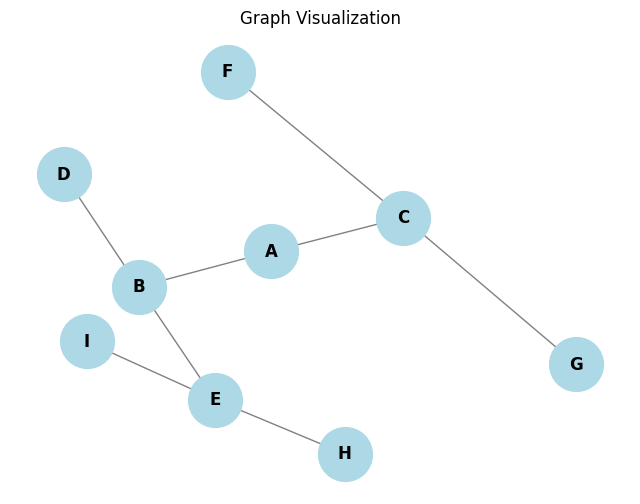

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(graph):
    """Visualizes the graph using NetworkX and Matplotlib."""
    G = nx.DiGraph() # Use directed graph as our adjacency list implies direction

    # Add nodes and edges
    for node, neighbors in graph.items():
        G.add_node(node)
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(G, seed=42) # For consistent layout

    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=1500)
    nx.draw_networkx_edges(G, pos, edge_color='gray', arrows=True, arrowsize=20)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    plt.title('Graph Visualization')
    plt.axis('off') # Hide axes
    plt.show()

print("\n--- Visualizing the Defined Graph ---")
visualize_graph(graph)


## 6. Heuristic Search and Heuristic Functions (A* Search)

**Theory:**

Heuristic search algorithms use **heuristic functions** to estimate the cost from the current state to the goal state. This estimate helps to guide the search towards promising paths, significantly improving efficiency compared to uninformed search methods (like BFS or DFS) in large state spaces.

A **heuristic function**, denoted `h(n)`, provides an estimated cost from node `n` to the goal. A good heuristic is:
*   **Admissible:** `h(n) <= actual_cost(n, goal)`. It never overestimates the true cost to reach the goal. Admissible heuristics guarantee finding an optimal solution if used with algorithms like A*.
*   **Consistent (or Monotone):** `h(n) <= cost(n, n') + h(n')` for any node `n` and its successor `n'`. This is a stronger condition than admissibility and ensures that the estimated cost from the start to any node `n` is always non-decreasing along any path. Consistency implies admissibility.

**A* Search** is one of the most popular and effective heuristic search algorithms. It combines the advantages of Dijkstra's algorithm (finding shortest paths) with those of greedy best-first search (using heuristics). A* evaluates nodes using the function `f(n) = g(n) + h(n)`:
*   `g(n)`: The actual cost of the path from the start node to node `n`.
*   `h(n)`: The estimated cost (heuristic) from node `n` to the goal node.

A* maintains two sets of nodes:
*   **Open Set (Frontier):** Nodes that have been visited but whose neighbors have not all been explored. It's typically a priority queue ordered by `f(n)`.
*   **Closed Set:** Nodes that have been fully evaluated.

At each step, A* selects the node `n` from the open set with the lowest `f(n)` value, expands it, and updates its neighbors in the open or closed sets. If the heuristic is admissible, A* is guaranteed to find the shortest path.


--- Running A* Search on a Grid ---
Path found! Length: 12
Path: [(0, 0), (1, 1), (2, 2), (3, 3), (4, 3), (5, 3), (6, 4), (7, 5), (7, 6), (7, 7), (7, 8), (7, 9)]


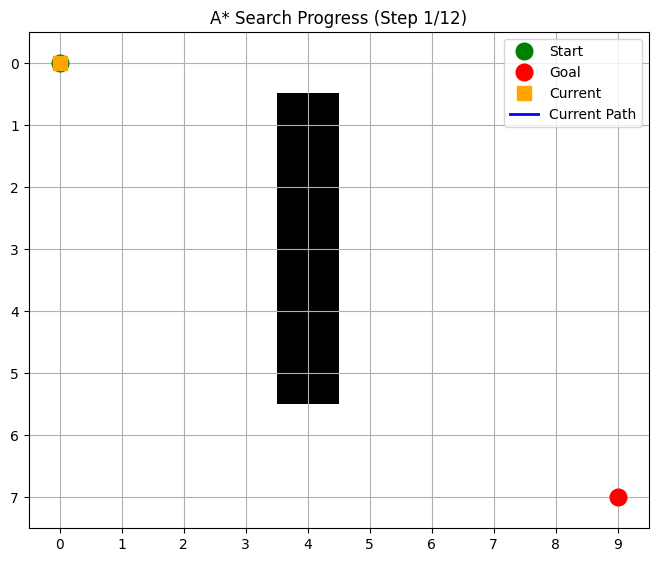

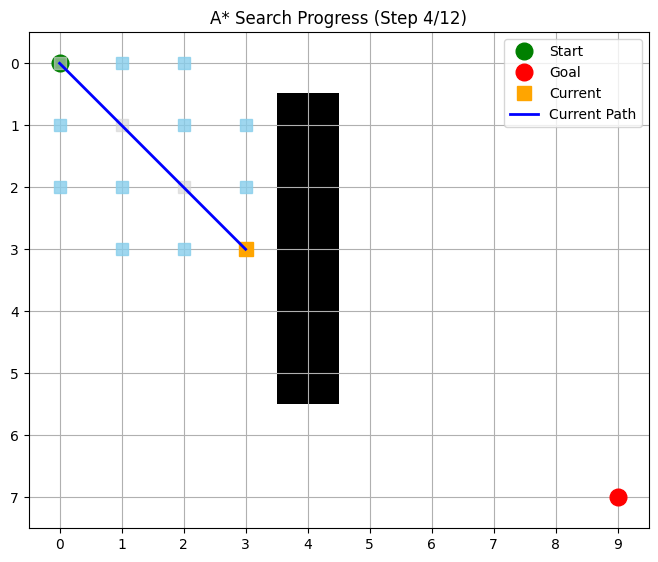

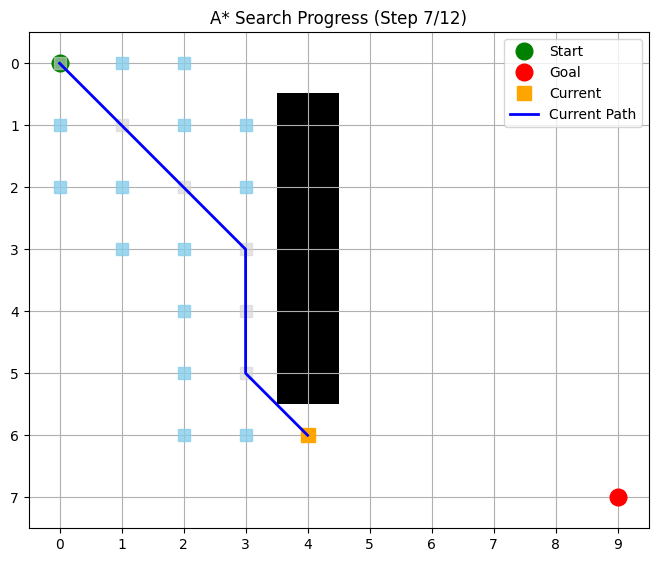

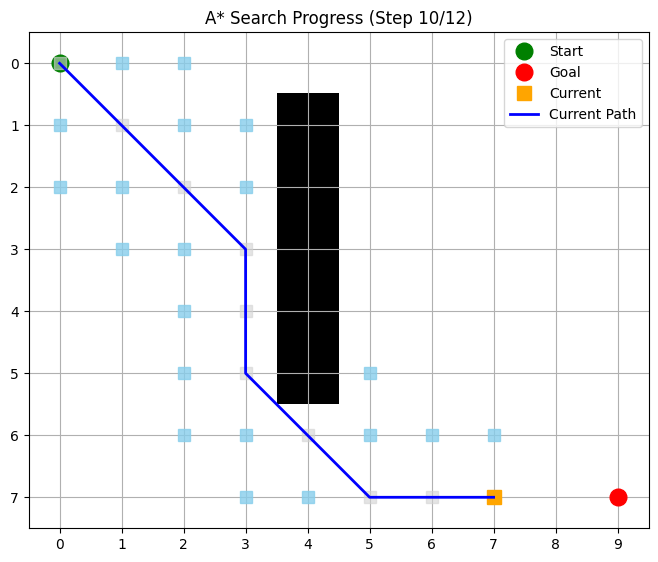

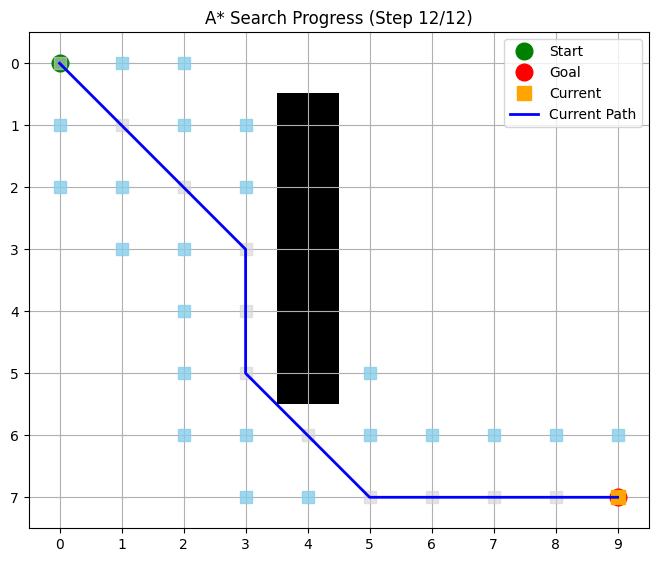

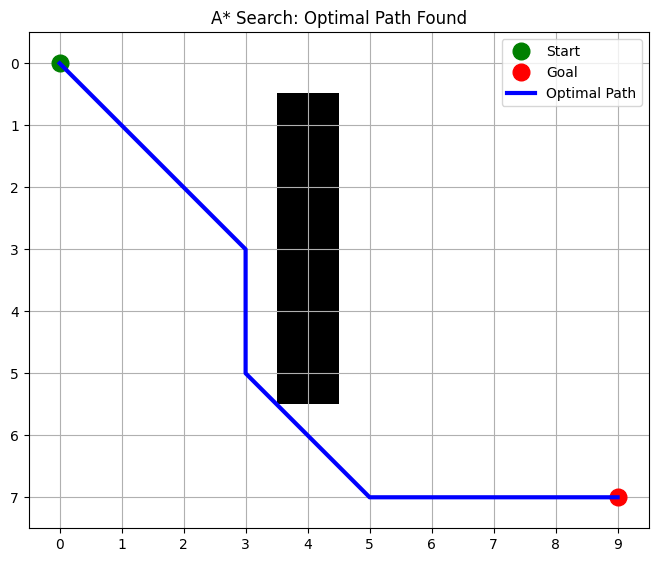

In [ ]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# --- 1. Define a Grid-based Graph and Heuristic ---
# For A* search, a grid is a common and intuitive example.
# 0 = walkable, 1 = obstacle
grid = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
]

# Start and Goal coordinates (row, col)
start = (0, 0)
goal = (7, 9)

rows = len(grid)
cols = len(grid[0])

# --- Heuristic Function: Manhattan Distance ---
def heuristic(a, b):
    """Calculates Manhattan distance between two points (a, b)."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

# --- A* Search Implementation ---
def a_star_search(grid, start, goal):
    open_set = [] # Priority queue: (f_score, g_score, current_node, path)
    heapq.heappush(open_set, (0 + heuristic(start, goal), 0, start, [start]))

    g_scores = {start: 0} # Cost from start to current node
    f_scores = {start: heuristic(start, goal)} # Estimated cost from start to goal

    # To visualize the search process
    visited_nodes = set()
    path_visuals = [] # Store snapshots for visualization

    while open_set:
        f, g, current, path = heapq.heappop(open_set)

        # Store current state for visualization
        path_visuals.append({
            'open_set': [(node, f) for f, _, node, _ in open_set],
            'closed_set': list(visited_nodes),
            'current_node': current,
            'path': path.copy()
        })

        if current == goal:
            return path, path_visuals # Path found

        if current in visited_nodes:
            continue

        visited_nodes.add(current)

        # Explore neighbors
        for dr, dc in [(0, 1), (0, -1), (1, 0), (-1, 0), (1,1), (1,-1), (-1,1), (-1,-1)]: # 8 directions
            neighbor = (current[0] + dr, current[1] + dc)

            # Check bounds and obstacles
            if 0 <= neighbor[0] < rows and \
               0 <= neighbor[1] < cols and \
               grid[neighbor[0]][neighbor[1]] == 0 and \
               neighbor not in visited_nodes:

                # Cost to move to neighbor (1 for horizontal/vertical, sqrt(2) for diagonal)
                move_cost = 1.0 if dr == 0 or dc == 0 else 1.414
                tentative_g_score = g_scores[current] + move_cost

                if neighbor not in g_scores or tentative_g_score < g_scores[neighbor]:
                    g_scores[neighbor] = tentative_g_score
                    f_scores[neighbor] = tentative_g_score + heuristic(neighbor, goal)
                    new_path = path + [neighbor]
                    heapq.heappush(open_set, (f_scores[neighbor], tentative_g_score, neighbor, new_path))

    return None, path_visuals # No path found

# --- 2. Visualization of A* Search Progress ---
def plot_grid_snapshot(grid, start, goal, snapshot, title):
    plt.figure(figsize=(8, 8))
    plt.imshow(grid, cmap='Greys', origin='upper')

    # Customize colormap for path/search
    cmap = ListedColormap(['#FFFFFF', '#000000']) # White for walkable, Black for obstacle
    plt.imshow(grid, cmap=cmap, origin='upper', extent=[-0.5, cols - 0.5, rows - 0.5, -0.5])

    # Plot start and goal
    plt.plot(start[1], start[0], 'go', markersize=12, label='Start') # Green circle
    plt.plot(goal[1], goal[0], 'ro', markersize=12, label='Goal')   # Red circle

    # Plot closed set (visited nodes)
    for r, c in snapshot['closed_set']:
        plt.plot(c, r, 's', markersize=8, color='lightgray', alpha=0.6)

    # Plot open set (nodes to explore)
    for (r, c), _ in snapshot['open_set']:
        plt.plot(c, r, 's', markersize=8, color='skyblue', alpha=0.8)

    # Plot current node
    if snapshot['current_node']:
        plt.plot(snapshot['current_node'][1], snapshot['current_node'][0], 's', markersize=10, color='orange', alpha=1.0, label='Current')

    # Plot current path
    if snapshot['path']:
        path_rows, path_cols = zip(*snapshot['path'])
        plt.plot(path_cols, path_rows, 'b-', linewidth=2, label='Current Path') # Blue line

    plt.xticks(np.arange(cols))
    plt.yticks(np.arange(rows))
    plt.grid(True)
    plt.title(title)
    plt.legend()
    plt.show()

# --- Example Usage: Run A* and Visualize ---
print("\n--- Running A* Search on a Grid ---")
final_path, visuals = a_star_search(grid, start, goal)

if final_path:
    print(f"Path found! Length: {len(final_path)}")
    print("Path:", final_path)

    # Visualize key steps of the search
    plot_indices = [0, len(visuals) // 4, len(visuals) // 2, 3 * len(visuals) // 4, len(visuals) - 1]
    plot_indices = [idx for idx in plot_indices if idx >= 0 and idx < len(visuals)]
    plot_indices = sorted(list(set(plot_indices))) # Remove duplicates

    for i, idx in enumerate(plot_indices):
        snapshot = visuals[idx]
        plot_grid_snapshot(grid, start, goal, snapshot, f"A* Search Progress (Step {idx+1}/{len(visuals)})")

    # Final path visualization
    plt.figure(figsize=(8, 8))
    plt.imshow(grid, cmap='Greys', origin='upper')
    cmap = ListedColormap(['#FFFFFF', '#000000']) # White for walkable, Black for obstacle
    plt.imshow(grid, cmap=cmap, origin='upper', extent=[-0.5, cols - 0.5, rows - 0.5, -0.5])
    plt.plot(start[1], start[0], 'go', markersize=12, label='Start')
    plt.plot(goal[1], goal[0], 'ro', markersize=12, label='Goal')
    path_rows, path_cols = zip(*final_path)
    plt.plot(path_cols, path_rows, 'b-', linewidth=3, label='Optimal Path')
    plt.xticks(np.arange(cols))
    plt.yticks(np.arange(rows))
    plt.grid(True)
    plt.title('A* Search: Optimal Path Found')
    plt.legend()
    plt.show()

else:
    print("No path found.")


## 7. Solution Space Search (General Concept)

**Theory:**

While **State Space Search** focuses on finding a path from an initial state to a goal state within a graph of possible configurations (like navigating a maze), **Solution Space Search** (often used synonymously with Optimization) focuses on finding the *best* solution among a set of possible solutions.

In solution space search, each point in the search space represents a complete candidate solution to the problem, not just a partial state. The goal is to optimize an **objective function** (also known as a fitness function or cost function) that evaluates the quality of each candidate solution.

Key characteristics:
*   **Candidate Solutions:** Each point `x` in the search space is a full solution, not an intermediate step.
*   **Objective Function:** A function `f(x)` that assigns a quality score to each candidate solution `x`. The goal is to maximize or minimize `f(x)`.
*   **No Explicit Path:** Unlike state space search, the path taken through the solution space is less important than the final best solution found.
*   **Applications:** Widely used in optimization, machine learning (e.g., hyperparameter tuning), engineering design, resource allocation, and more.

Algorithms like Hill Climbing, Simulated Annealing, Genetic Algorithms, Particle Swarm Optimization, etc., are primarily solution space search (or optimization) algorithms, as they explore a landscape of solutions to find the one with the best objective function value. Our previous Hill Climbing example is a form of solution space search.

## 8. Escaping Local Optima (Simulated Annealing)

**Theory:**

Many optimization problems involve complex objective functions with multiple peaks (for maximization) or valleys (for minimization). A **local optimum** is a solution that is better than all its neighboring solutions, but not necessarily the best solution overall (the **global optimum**).

Algorithms like simple Hill Climbing can easily get stuck in a local optimum because they only ever move towards improving solutions. To find global optima, algorithms need mechanisms to **escape local optima**.

**Simulated Annealing (SA)** is a probabilistic metaheuristic for finding global optima in a large search space. It's inspired by the annealing process in metallurgy, where a material is heated and then slowly cooled to increase its crystal size and reduce defects. The key idea is to allow the algorithm to accept worse solutions with a certain probability, especially early in the search:

*   **Temperature (T):** A control parameter that starts high and gradually decreases (the **cooling schedule**).
*   **Acceptance Probability:** When moving from a current solution `S` to a new solution `S'`:
    *   If `S'` is better than `S`, it's always accepted.
    *   If `S'` is worse than `S`, it's accepted with a probability `P = exp(-(f(S) - f(S')) / T)`. A higher temperature `T` means a higher probability of accepting a worse solution, allowing the search to escape local traps. As `T` decreases, the probability of accepting worse solutions diminishes, and the algorithm converges.

This mechanism allows SA to explore the search space more broadly at high temperatures and then focus on promising regions as the temperature drops, increasing the chance of finding a global optimum.


--- Running Simulated Annealing from initial_state = 0.0 ---
Initial State: 0.00, Initial Fitness: 0.00
Iteration 0: Temp=99.00, Current State=-0.10, Current Fitness=-1.00, Best Fitness=0.00
Iteration 100: Temp=36.24, Current State=0.87, Current Fitness=7.97, Best Fitness=8.75
Iteration 200: Temp=13.26, Current State=0.81, Current Fitness=7.44, Best Fitness=9.42
Iteration 300: Temp=4.86, Current State=0.95, Current Fitness=8.64, Best Fitness=11.34
Iteration 400: Temp=1.78, Current State=2.14, Current Fitness=16.80, Best Fitness=16.93
Iteration 500: Temp=0.65, Current State=2.92, Current Fitness=20.69, Best Fitness=21.59
Iteration 600: Temp=0.24, Current State=4.10, Current Fitness=24.19, Best Fitness=24.19
Iteration 700: Temp=0.09, Current State=4.59, Current Fitness=24.83, Best Fitness=24.99
Iteration 800: Temp=0.03, Current State=5.21, Current Fitness=24.96, Best Fitness=25.00
Iteration 900: Temp=0.01, Current State=4.97, Current Fitness=25.00, Best Fitness=25.00
Iteration 999: Temp

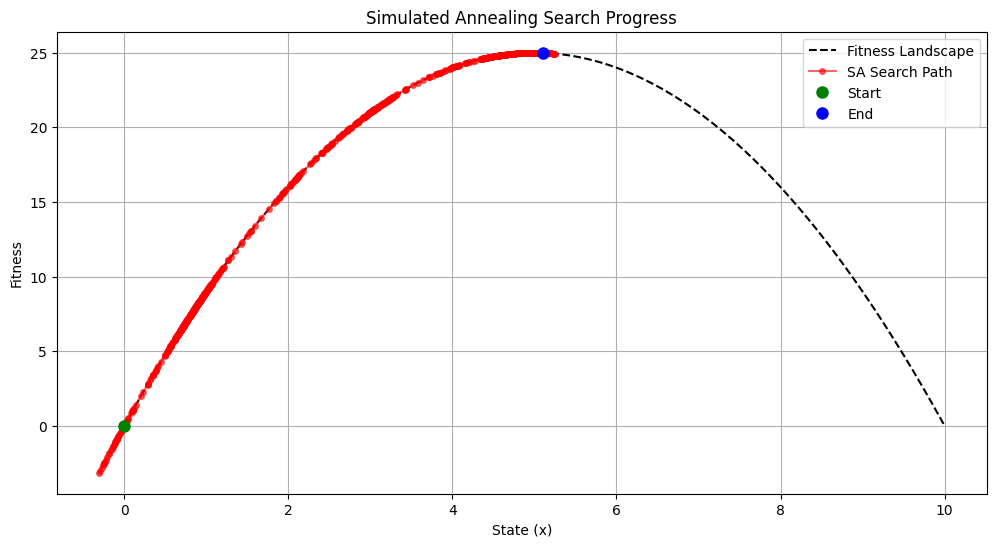


--- Running Simulated Annealing from initial_state = 8.0 (to show escaping local optima potential) ---
Initial State: 8.00, Initial Fitness: 16.00
Iteration 0: Temp=99.00, Current State=8.04, Current Fitness=15.78, Best Fitness=16.00
Iteration 100: Temp=36.24, Current State=8.12, Current Fitness=15.26, Best Fitness=16.31
Iteration 200: Temp=13.26, Current State=9.13, Current Fitness=7.94, Best Fitness=16.31
Iteration 300: Temp=4.86, Current State=8.51, Current Fitness=12.68, Best Fitness=16.31
Iteration 400: Temp=1.78, Current State=8.01, Current Fitness=15.94, Best Fitness=16.87
Iteration 500: Temp=0.65, Current State=7.34, Current Fitness=19.50, Best Fitness=20.75
Iteration 600: Temp=0.24, Current State=6.05, Current Fitness=23.89, Best Fitness=24.02
Iteration 700: Temp=0.09, Current State=4.97, Current Fitness=25.00, Best Fitness=25.00
Iteration 800: Temp=0.03, Current State=4.95, Current Fitness=25.00, Best Fitness=25.00
Iteration 900: Temp=0.01, Current State=5.06, Current Fitnes

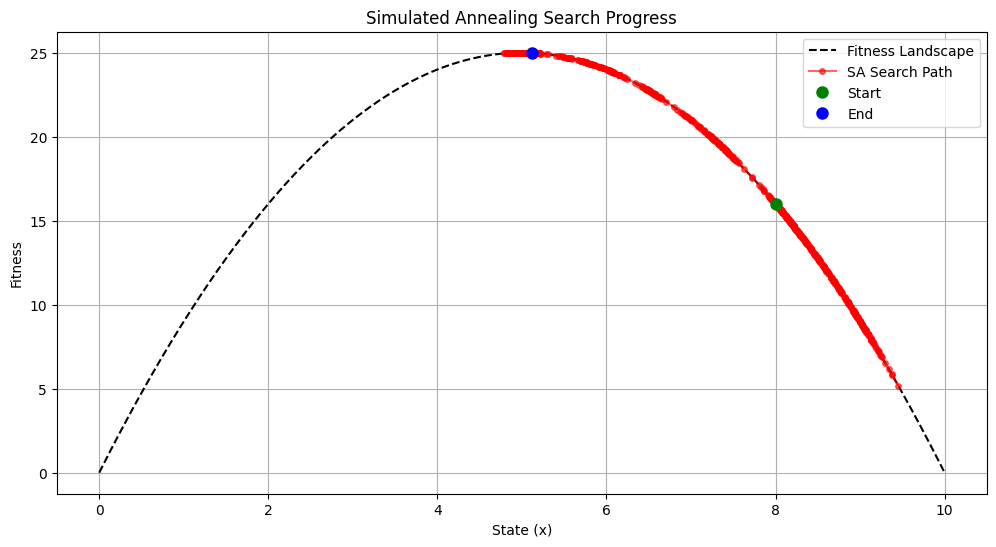

In [ ]:
import math
import random
import matplotlib.pyplot as plt

# Reuse the fitness function from the Hill Climbing example
def evaluate_fitness_sa(x):
    """The fitness function to maximize. Peak at x=5, f(x)=25"""
    return -((x - 5)**2) + 25

# --- Simulated Annealing Implementation ---
def simulated_annealing(initial_state, evaluate_fn, max_iterations=1000,
                        initial_temperature=100.0, cooling_rate=0.99):
    current_state = initial_state
    current_fitness = evaluate_fn(current_state)

    best_state = current_state
    best_fitness = current_fitness

    temperature = initial_temperature

    # For visualization of the search path
    history_states = [current_state]
    history_fitnesses = [current_fitness]

    print(f"Initial State: {current_state:.2f}, Initial Fitness: {current_fitness:.2f}")

    for i in range(max_iterations):
        # Generate a neighboring state
        # For this 1D problem, a neighbor is simply a small perturbation
        neighbor_state = current_state + (random.uniform(-1, 1) * 0.1) # Small random step
        neighbor_fitness = evaluate_fn(neighbor_state)

        # Calculate change in fitness (for maximization, positive is better)
        delta_fitness = neighbor_fitness - current_fitness

        # Decide whether to accept the new state
        if delta_fitness > 0:  # If the new state is better, accept it
            current_state = neighbor_state
            current_fitness = neighbor_fitness
        else:  # If the new state is worse, accept with a probability
            acceptance_probability = math.exp(delta_fitness / temperature)
            if random.random() < acceptance_probability:
                current_state = neighbor_state
                current_fitness = neighbor_fitness

        # Update best solution found so far
        if current_fitness > best_fitness:
            best_state = current_state
            best_fitness = current_fitness

        # Record history for visualization
        history_states.append(current_state)
        history_fitnesses.append(current_fitness)

        # Cool down the temperature
        temperature *= cooling_rate

        if i % 100 == 0 or i == max_iterations - 1:
             print(f"Iteration {i}: Temp={temperature:.2f}, Current State={current_state:.2f}, Current Fitness={current_fitness:.2f}, Best Fitness={best_fitness:.2f}")

    print(f"\nFinal Best State Found: {best_state:.2f}")
    print(f"Final Best Fitness: {best_fitness:.2f}")
    return best_state, history_states, history_fitnesses

# --- 2. Visualization of Simulated Annealing Progress ---
def plot_sa_progress(history_states, history_fitnesses, fitness_fn):
    plt.figure(figsize=(12, 6))

    # Plot the fitness landscape
    x_values = np.linspace(0, 10, 500)
    y_values = [fitness_fn(x) for x in x_values]
    plt.plot(x_values, y_values, 'k--', label='Fitness Landscape')

    # Plot the search path
    plt.plot(history_states, history_fitnesses, 'ro-', alpha=0.6, markersize=4, label='SA Search Path')

    # Highlight start and end
    plt.plot(history_states[0], history_fitnesses[0], 'go', markersize=8, label='Start')
    plt.plot(history_states[-1], history_fitnesses[-1], 'bo', markersize=8, label='End')

    plt.title('Simulated Annealing Search Progress')
    plt.xlabel('State (x)')
    plt.ylabel('Fitness')
    plt.grid(True)
    plt.legend()
    plt.show()

# --- Example Usage: Run Simulated Annealing ---
print("\n--- Running Simulated Annealing from initial_state = 0.0 ---")
best_x_sa, sa_states, sa_fitnesses = simulated_annealing(
    initial_state=0.0,
    evaluate_fn=evaluate_fitness_sa,
    max_iterations=1000,
    initial_temperature=100.0,
    cooling_rate=0.99
)

plot_sa_progress(sa_states, sa_fitnesses, evaluate_fitness_sa)

print("\n--- Running Simulated Annealing from initial_state = 8.0 (to show escaping local optima potential) ---")
# For this simple quadratic function, there's only one global optimum.
# In a multi-modal function, SA would be much more distinctly superior to Hill Climbing.
best_x_sa_2, sa_states_2, sa_fitnesses_2 = simulated_annealing(
    initial_state=8.0,
    evaluate_fn=evaluate_fitness_sa,
    max_iterations=1000,
    initial_temperature=100.0,
    cooling_rate=0.99
)

plot_sa_progress(sa_states_2, sa_fitnesses_2, evaluate_fitness_sa)


## 9. Stochastic Local Search (SLS)

**Theory:**

Stochastic Local Search (SLS) is a general class of optimization algorithms that incorporate **randomness** into their search process, particularly in how they explore the neighborhood of a current solution. Unlike deterministic local search methods (like strict Hill Climbing, which always moves to the best neighbor), SLS methods make probabilistic choices.

This stochasticity helps SLS algorithms to:
*   **Escape Local Optima:** By sometimes accepting worse solutions or randomly choosing neighbors, they can avoid getting stuck in suboptimal regions of the search space.
*   **Explore Broadly:** The random element allows for a wider exploration of the search space, increasing the chances of finding better solutions.
*   **Handle Complex Landscapes:** They can be effective for problems with rugged, high-dimensional, or discontinuous search landscapes where deterministic methods might struggle.

SLS algorithms are often incomplete (they don't guarantee finding a solution or the optimal one) and non-optimal (they might not find the shortest path or best solution). However, they are highly effective for finding *good enough* solutions to very hard problems within a reasonable amount of time.

Examples of Stochastic Local Search algorithms include:
*   **Simulated Annealing:** (Implemented above) Uses a temperature-dependent probability to accept worse moves.
*   **Genetic Algorithms:** Inspired by natural selection, they evolve a population of solutions over generations using operators like selection, crossover, and mutation.
*   **Tabu Search:** Explores the search space by forbidding certain moves (tabu list) to prevent cycling and encourage exploration.
*   **Random Walk:** Simply moves to a random neighbor at each step.
*   **Stochastic Hill Climbing:** Similar to deterministic Hill Climbing, but accepts the *first* improving neighbor found, or accepts worse moves with a small probability.

Our implementation of **Simulated Annealing** serves as a prime example of a Stochastic Local Search algorithm, as its core mechanism of accepting non-improving moves is probabilistic, allowing it to escape local optima and explore the solution space more effectively.

## 10. Genetic Algorithms (Advanced Version)

**Theory (Advanced):**

While basic Genetic Algorithms (GAs) use simple selection, crossover, and mutation, advanced versions often incorporate strategies to improve convergence, prevent premature convergence, and handle more complex optimization landscapes. Key advanced techniques include:

*   **Elitism:** Directly copies the best individuals (elites) from the current generation to the next without modification. This ensures that the best solutions found are never lost and can accelerate convergence.
*   **Complex Objective Functions:** Applying GA to multi-modal functions (functions with multiple local optima) often requires more robust exploration and exploitation strategies.
*   **Adaptive Operators:** Dynamically adjusting crossover and mutation rates based on the population's fitness or diversity.
*   **Different Selection/Crossover/Mutation:** Using more sophisticated methods like tournament selection, uniform crossover, or non-uniform mutation to fine-tune the search.

Here, we'll demonstrate a GA optimizing a 2D multi-modal function (a variation of the Rastrigin function) with elitism.


--- Running Advanced Genetic Algorithm ---
Gen 0: Best Fitness=-3.2042, Best Individual=[0.09309394 1.04719676]
Gen 50: Best Fitness=-0.0000, Best Individual=[ 8.24099550e-08 -1.11952458e-07]
Gen 100: Best Fitness=-0.0000, Best Individual=[ 8.24099550e-08 -1.11952458e-07]
Gen 150: Best Fitness=-0.0000, Best Individual=[ 8.24099550e-08 -1.11952458e-07]
Gen 199: Best Fitness=-0.0000, Best Individual=[ 8.24099550e-08 -1.11952458e-07]

Final Best Individual: [ 8.24099550e-08 -1.11952458e-07]
Final Best Fitness (maximized): -0.0000
Corresponding Function Value (minimized): 0.0000


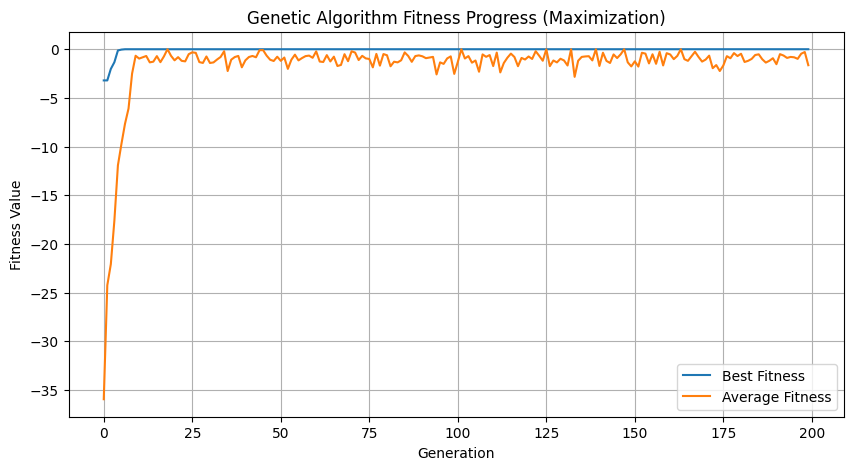

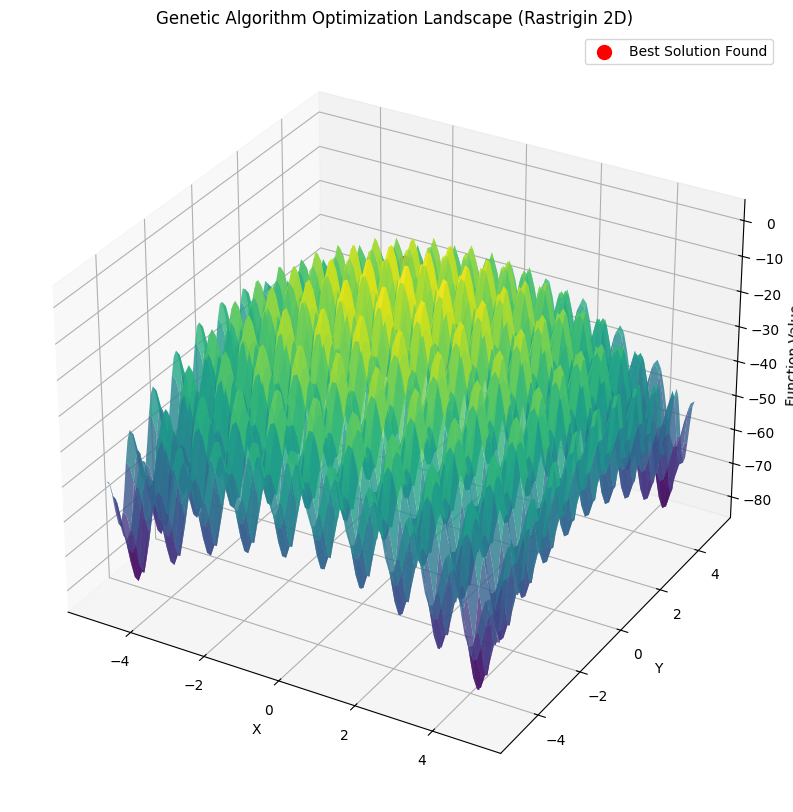

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Advanced Genetic Algorithm Implementation ---

# 1. Define a 2D multi-modal objective function (e.g., a simple Rastrigin-like function)
def rastrigin_2d(individual):
    x, y = individual
    return 20 + (x**2 - 10 * np.cos(2 * np.pi * x)) + (y**2 - 10 * np.cos(2 * np.pi * y))

# We want to minimize rastrigin_2d, so fitness will be 1 / (1 + rastrigin_2d)
# For visualization, let's keep it simple: we want to find the global minimum which is (0,0) and value 0.
# For the GA to 'maximize' this, we need to convert it to a maximization problem.
# Let's say we target a maximum fitness where lower Rastrigin values are better.
# max_fitness - rastrigin_2d

def evaluate_fitness_ga_advanced(individual):
    # For this example, let's simply try to minimize the function. Lower is better.
    # We'll use negative of the function value if we are maximizing, or just the function value.
    # Let's make it a maximization problem by inverting the magnitude of the function output
    # to make the global minimum (0,0) with value 0, the highest fitness.
    # A common way is max_val - f(x). Assuming a reasonable search space like [-5, 5]
    # the maximum value for rastrigin_2d is around 2*(25 - 10*cos(2*pi*5)) + 20 ~ 2*(25-10)+20 = 50.
    # A simple inversion might be 1 / (1 + f(x)) or -f(x).
    # Let's use -f(x) for maximization to target minimum.
    return -rastrigin_2d(individual)


class GeneticAlgorithm:
    def __init__(self, obj_func, bounds, pop_size, num_generations,
                 crossover_rate=0.8, mutation_rate=0.05, elitism_rate=0.1):
        self.obj_func = obj_func
        self.bounds = bounds  # [(min_x, max_x), (min_y, max_y)]
        self.pop_size = pop_size
        self.num_generations = num_generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.elitism_count = int(pop_size * elitism_rate)

        self.population = self._initialize_population()
        self.best_individual = None
        self.best_fitness = -float('inf')
        self.fitness_history = []
        self.avg_fitness_history = []

    def _initialize_population(self):
        pop = []
        for _ in range(self.pop_size):
            individual = [random.uniform(self.bounds[0][0], self.bounds[0][1]),
                          random.uniform(self.bounds[1][0], self.bounds[1][1])]
            pop.append(np.array(individual))
        return pop

    def _select_parents(self, fitnesses):
        # Tournament selection
        tournament_size = 3
        parents = []
        for _ in range(2):
            candidates = random.sample(list(zip(self.population, fitnesses)), tournament_size)
            winner = max(candidates, key=lambda x: x[1])[0]
            parents.append(winner)
        return parents

    def _crossover(self, parent1, parent2):
        if random.random() < self.crossover_rate:
            alpha = random.random()
            child1 = alpha * parent1 + (1 - alpha) * parent2
            child2 = (1 - alpha) * parent1 + alpha * parent2
            return child1, child2
        return parent1.copy(), parent2.copy() # Return copies if no crossover

    def _mutate(self, individual):
        if random.random() < self.mutation_rate:
            # Add Gaussian noise, then clip to bounds
            mutation_strength_x = (self.bounds[0][1] - self.bounds[0][0]) * 0.1
            mutation_strength_y = (self.bounds[1][1] - self.bounds[1][0]) * 0.1
            individual[0] += random.gauss(0, mutation_strength_x)
            individual[1] += random.gauss(0, mutation_strength_y)

            # Clip to bounds
            individual[0] = np.clip(individual[0], self.bounds[0][0], self.bounds[0][1])
            individual[1] = np.clip(individual[1], self.bounds[1][0], self.bounds[1][1])
        return individual

    def run(self):
        print("\n--- Running Advanced Genetic Algorithm ---")
        for generation in range(self.num_generations):
            fitnesses = [self.obj_func(ind) for ind in self.population]

            # Update best individual found so far
            current_best_idx = np.argmax(fitnesses)
            current_best_fitness = fitnesses[current_best_idx]
            current_best_individual = self.population[current_best_idx]

            if current_best_fitness > self.best_fitness:
                self.best_fitness = current_best_fitness
                self.best_individual = current_best_individual.copy()

            self.fitness_history.append(self.best_fitness)
            self.avg_fitness_history.append(np.mean(fitnesses))

            # Elitism: Carry over the best individuals directly
            elites_indices = np.argsort(fitnesses)[-self.elitism_count:]
            next_population = [self.population[i].copy() for i in elites_indices]

            # Generate the rest of the new population
            while len(next_population) < self.pop_size:
                parent1, parent2 = self._select_parents(fitnesses)
                child1, child2 = self._crossover(parent1, parent2)
                next_population.append(self._mutate(child1))
                if len(next_population) < self.pop_size:
                    next_population.append(self._mutate(child2))

            self.population = next_population

            if generation % 50 == 0 or generation == self.num_generations - 1:
                print(f"Gen {generation}: Best Fitness={self.best_fitness:.4f}, Best Individual={self.best_individual}")

        print(f"\nFinal Best Individual: {self.best_individual}")
        print(f"Final Best Fitness (maximized): {self.best_fitness:.4f}")
        print(f"Corresponding Function Value (minimized): {-self.best_fitness:.4f}")
        return self.best_individual, self.best_fitness, self.fitness_history, self.avg_fitness_history


# --- Example Usage for Advanced GA ---
bounds_ga = [(-5.0, 5.0), (-5.0, 5.0)] # Search space for x and y
ga = GeneticAlgorithm(
    obj_func=evaluate_fitness_ga_advanced,
    bounds=bounds_ga,
    pop_size=100,
    num_generations=200,
    elitism_rate=0.05
)
best_solution_ga, best_fitness_ga, ga_fitness_history, ga_avg_fitness_history = ga.run()


# --- Visualization for Advanced GA ---
def plot_ga_progress(fitness_history, avg_fitness_history):
    plt.figure(figsize=(10, 5))
    plt.plot(fitness_history, label='Best Fitness')
    plt.plot(avg_fitness_history, label='Average Fitness')
    plt.title('Genetic Algorithm Fitness Progress (Maximization)')
    plt.xlabel('Generation')
    plt.ylabel('Fitness Value')
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_ga_landscape(obj_func, bounds, best_individual=None):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    x = np.linspace(bounds[0][0], bounds[0][1], 100)
    y = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x, y)
    Z = np.array([[-obj_func([xi, yi]) for xi in x] for yi in y]) # Plot original function (minimization)

    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

    if best_individual is not None:
        best_x, best_y = best_individual
        best_z = rastrigin_2d(best_individual)
        ax.scatter(best_x, best_y, best_z, color='red', marker='o', s=100, label='Best Solution Found')

    ax.set_title('Genetic Algorithm Optimization Landscape (Rastrigin 2D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Function Value')
    plt.legend()
    plt.show()

plot_ga_progress(ga_fitness_history, ga_avg_fitness_history)
plot_ga_landscape(rastrigin_2d, bounds_ga, best_solution_ga)


## 11. Emergent Systems (Advanced Version: Conway's Game of Life with Glider Gun)

**Theory (Advanced):**

Conway's Game of Life is a classic example of an emergent system, where complex, unpredictable behavior arises from simple local rules. An "advanced" look into this system often involves exploring:

*   **Complex Initial Patterns:** Instead of random or simple patterns, starting with known complex structures like "Glider Guns", "Puffers", or "Spaceships" showcases the system's ability to generate intricate and self-organizing dynamics.
*   **Rule Variations:** Modifying the survival and birth rules (e.g., "HighLife", "Day & Night") leads to vastly different emergent behaviors.
*   **Larger Grids and Performance:** Simulating on larger grids efficiently, potentially using optimized data structures or parallel computing (though this is beyond a simple Colab demo).

Here, we'll demonstrate a simulation of Conway's Game of Life starting with a famous pattern: the **Gosper Glider Gun**, which continuously produces "gliders" – self-propelling patterns that interact with the environment.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

# --- Advanced Conway's Game of Life Implementation (Glider Gun) ---

class GameOfLife:
    def __init__(self, grid_size=(50, 80), initial_pattern=None):
        self.grid = np.zeros(grid_size, dtype=int)
        self.grid_size = grid_size
        if initial_pattern is not None:
            self._place_pattern(initial_pattern)

    def _place_pattern(self, pattern_coords):
        for r, c in pattern_coords:
            if 0 <= r < self.grid_size[0] and 0 <= c < self.grid_size[1]:
                self.grid[r, c] = 1

    def update(self):
        new_grid = self.grid.copy()
        for r in range(self.grid_size[0]):
            for c in range(self.grid_size[1]):
                # Count live neighbors
                total_live_neighbors = 0
                for dr in [-1, 0, 1]:
                    for dc in [-1, 0, 1]:
                        if dr == 0 and dc == 0: # Skip self
                            continue
                        # Wrap around edges for toroidal grid (optional, but common)
                        neighbor_r, neighbor_c = (r + dr) % self.grid_size[0], (c + dc) % self.grid_size[1]
                        total_live_neighbors += self.grid[neighbor_r, neighbor_c]

                # Apply Game of Life rules
                if self.grid[r, c] == 1: # Live cell
                    if total_live_neighbors < 2 or total_live_neighbors > 3:
                        new_grid[r, c] = 0 # Dies (underpopulation or overpopulation)
                else: # Dead cell
                    if total_live_neighbors == 3:
                        new_grid[r, c] = 1 # Becomes live (reproduction)
        self.grid = new_grid
        return self.grid

# Define the Gosper Glider Gun pattern relative coordinates
# Source: https://www.conwaylife.com/wiki/Gosper_glider_gun
gosper_glider_gun = [
    (1, 25), (2, 23), (2, 25), (3, 13), (3, 14), (3, 21), (3, 22), (3, 35), (3, 36),
    (4, 12), (4, 16), (4, 21), (4, 22), (4, 35), (4, 36), (5, 1), (5, 2), (5, 11),
    (5, 17), (5, 21), (5, 22), (6, 1), (6, 2), (6, 11), (6, 15), (6, 17), (6, 18),
    (6, 23), (6, 25), (7, 11), (7, 17), (7, 25), (8, 12), (8, 16), (9, 13), (9, 14)
]

# Adjust pattern to start roughly in the middle of the grid
offset_r, offset_c = 10, 10 # Adjust as needed for grid size
initial_pattern_glider_gun = [(r + offset_r, c + offset_c) for r, c in gosper_glider_gun]

# --- Example Usage for Advanced GoL ---
grid_dim = (60, 100) # Larger grid to accommodate the gun and gliders
game = GameOfLife(grid_size=grid_dim, initial_pattern=initial_pattern_glider_gun)

print("\n--- Running Advanced Conway's Game of Life (Glider Gun) ---")
print(f"Grid Size: {game.grid_size}")

# --- Visualization for Advanced GoL (Animation) ---
def animate_game_of_life(game_instance, frames=200, interval=100):
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.set_xticks([])
    ax.set_yticks([])
    img = ax.imshow(game_instance.grid, cmap='binary', interpolation='nearest')

    def animate(i):
        game_instance.update()
        img.set_data(game_instance.grid)
        ax.set_title(f"Generation {i}")
        return [img]

    anim = animation.FuncAnimation(fig, animate, frames=frames, interval=interval, blit=True)
    plt.close(fig) # Prevent showing the static plot
    return HTML(anim.to_jshtml())

# To view the animation, uncomment the following two lines and run the cell:
# glider_gun_animation = animate_game_of_life(game, frames=200, interval=100)
# glider_gun_animation

print("Conway's Game of Life with Glider Gun setup complete. Uncomment the last two lines to view the animation.")



--- Running Advanced Conway's Game of Life (Glider Gun) ---
Grid Size: (60, 100)
Conway's Game of Life with Glider Gun setup complete. Uncomment the last two lines to view the animation.



--- Running Ant Colony Optimization (Advanced with 2-opt: True) ---
Iteration 0: Best tour length = 290.31
Iteration 10: Best tour length = 290.31
Iteration 20: Best tour length = 290.31
Iteration 30: Best tour length = 290.31
Iteration 40: Best tour length = 290.31
Iteration 50: Best tour length = 290.31
Iteration 60: Best tour length = 290.31
Iteration 70: Best tour length = 290.31
Iteration 80: Best tour length = 290.31
Iteration 90: Best tour length = 290.31

Final Best Tour: [0, 4, 1, 6, 9, 7, 2, 8, 3, 5]
Final Best Tour Length: 290.31


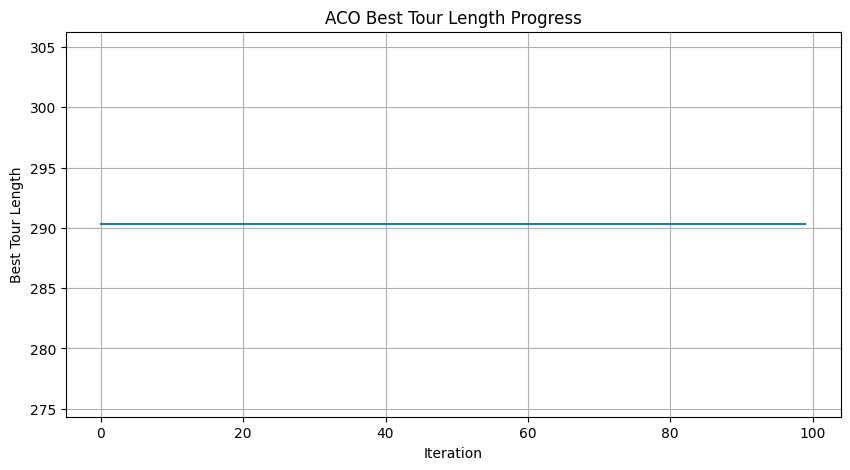

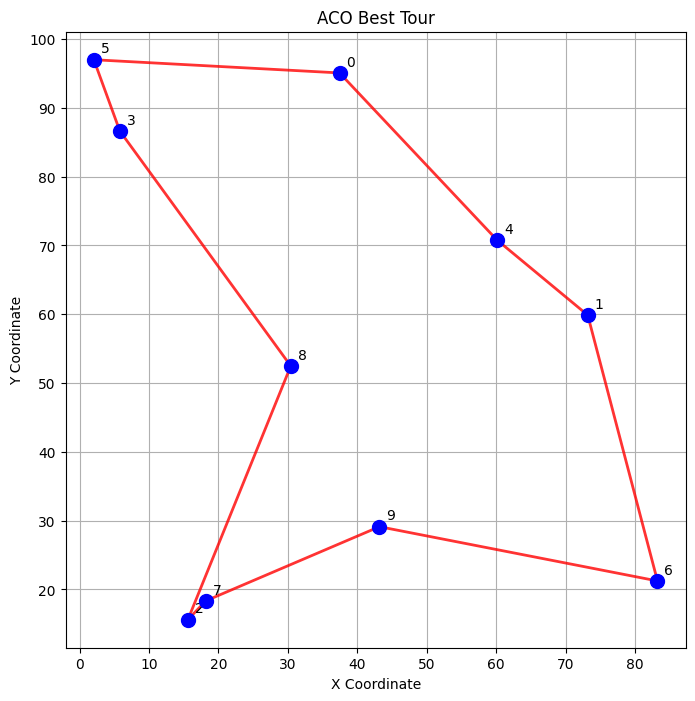

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# --- Helper function for 2-opt local search ---
def two_opt_swap(tour, i, k):
    """Performs a 2-opt swap on a tour."""
    new_tour = tour[:i] + tour[i:k+1][::-1] + tour[k+1:]
    return new_tour

def two_opt_local_search(tour, distances):
    """Applies 2-opt local search to improve a given tour."""
    num_cities = len(tour)
    best_tour = list(tour)
    best_length = calculate_tour_length_static(best_tour, distances)
    improved = True

    while improved:
        improved = False
        for i in range(1, num_cities - 1):
            for k in range(i + 1, num_cities):
                new_tour = two_opt_swap(best_tour, i, k)
                new_length = calculate_tour_length_static(new_tour, distances)
                if new_length < best_length:
                    best_tour = new_tour
                    best_length = new_length
                    improved = True
        if improved:
            # If improvement was made, restart the search from the beginning for this tour
            pass # The outer while loop handles restarting
    return best_tour, best_length

def calculate_tour_length_static(tour, distances):
    """Calculates the total length of a given tour (static helper)."""
    length = 0
    num_cities = len(tour)
    for i in range(num_cities):
        length += distances[tour[i], tour[(i + 1) % num_cities]]
    return length

# --- Ant Colony Optimization Implementation (for TSP) ---

class AntColonyOptimizer:
    def __init__(self, num_cities, distances, num_ants, num_iterations,
                 alpha=1.0, beta=2.0, evaporation_rate=0.5, pheromone_deposit=1.0,
                 use_two_opt=True):
        self.num_cities = num_cities
        self.distances = distances # A num_cities x num_cities distance matrix
        self.num_ants = num_ants
        self.num_iterations = num_iterations
        self.alpha = alpha # Pheromone importance
        self.beta = beta   # Heuristic information importance
        self.evaporation_rate = evaporation_rate
        self.pheromone_deposit = pheromone_deposit
        self.use_two_opt = use_two_opt # New parameter to enable/disable 2-opt

        # Initialize pheromone trails (all equal at start)
        self.pheromones = np.ones((num_cities, num_cities)) / num_cities

        self.best_tour = None
        self.best_tour_length = float('inf')
        self.best_tour_lengths_history = []

    def _calculate_tour_length(self, tour):
        return calculate_tour_length_static(tour, self.distances)

    def _choose_next_city(self, current_city, visited_cities):
        unvisited_cities = [city for city in range(self.num_cities) if city not in visited_cities]

        if not unvisited_cities:
            return None

        probabilities = []
        for city in unvisited_cities:
            pheromone = self.pheromones[current_city, city]
            # Heuristic information: 1/distance. Avoid division by zero for self-distance or zero distance.
            heuristic = 1.0 / (self.distances[current_city, city] + 1e-10)

            probability = (pheromone**self.alpha) * (heuristic**self.beta)
            probabilities.append(probability)

        sum_probabilities = sum(probabilities)
        if sum_probabilities == 0:
            # If all probabilities are zero, choose randomly among unvisited cities
            return random.choice(unvisited_cities)

        probabilities = [p / sum_probabilities for p in probabilities]
        return random.choices(unvisited_cities, weights=probabilities, k=1)[0]

    def run(self):
        print("\n--- Running Ant Colony Optimization (Advanced with 2-opt: " + str(self.use_two_opt) + ") ---")
        for iteration in range(self.num_iterations):
            all_tours = []
            all_tour_lengths = []

            for _ in range(self.num_ants):
                tour = [random.randint(0, self.num_cities - 1)] # Start at a random city
                visited_cities = set(tour)

                while len(tour) < self.num_cities:
                    next_city = self._choose_next_city(tour[-1], visited_cities)
                    if next_city is None: # Should not happen if all cities are connected
                        break
                    tour.append(next_city)
                    visited_cities.add(next_city)

                # Ensure it's a valid tour visiting all cities
                if len(tour) == self.num_cities:
                    current_tour_length = self._calculate_tour_length(tour)

                    # Apply 2-opt local search if enabled
                    if self.use_two_opt:
                        improved_tour, improved_length = two_opt_local_search(tour, self.distances)
                        tour = improved_tour
                        current_tour_length = improved_length

                    all_tours.append(tour)
                    all_tour_lengths.append(current_tour_length)

                    if current_tour_length < self.best_tour_length:
                        self.best_tour_length = current_tour_length
                        self.best_tour = tour

            # Pheromone evaporation
            self.pheromones *= (1 - self.evaporation_rate)

            # Pheromone deposition
            for tour, length in zip(all_tours, all_tour_lengths):
                if length > 0: # Avoid division by zero
                    pheromone_to_add = self.pheromone_deposit / length
                    for i in range(self.num_cities):
                        self.pheromones[tour[i], tour[(i + 1) % self.num_cities]] += pheromone_to_add

            self.best_tour_lengths_history.append(self.best_tour_length)
            if iteration % 10 == 0:
                print(f"Iteration {iteration}: Best tour length = {self.best_tour_length:.2f}")

        print(f"\nFinal Best Tour: {self.best_tour}")
        print(f"Final Best Tour Length: {self.best_tour_length:.2f}")
        return self.best_tour, self.best_tour_length, self.best_tour_lengths_history

# --- Define cities and distances for TSP example ---
# Generate random city coordinates
num_cities_tsp = 10
np.random.seed(42) # For reproducibility
city_coords = np.random.rand(num_cities_tsp, 2) * 100 # Cities in a 100x100 square

# Calculate distance matrix (Euclidean distance)
tsp_distances = np.zeros((num_cities_tsp, num_cities_tsp))
for i in range(num_cities_tsp):
    for j in range(num_cities_tsp):
        if i != j:
            tsp_distances[i, j] = np.linalg.norm(city_coords[i] - city_coords[j])
        else:
            tsp_distances[i, j] = 0 # Distance to self is 0

# Create and run ACO
aco = AntColonyOptimizer(
    num_cities=num_cities_tsp,
    distances=tsp_distances,
    num_ants=20,
    num_iterations=100,
    evaporation_rate=0.1,
    pheromone_deposit=100,
    use_two_opt=True # Enable 2-opt for advanced version
)

best_tour_aco, best_tour_length_aco, aco_history = aco.run()

# --- Visualization for Ant Colony Optimization ---
def plot_aco_progress(history, title="ACO Best Tour Length Progress"):
    plt.figure(figsize=(10, 5))
    plt.plot(history)
    plt.title(title)
    plt.xlabel('Iteration')
    plt.ylabel('Best Tour Length')
    plt.grid(True)
    plt.show()

def plot_aco_tour(city_coords, tour, title="ACO Best Tour"):
    plt.figure(figsize=(8, 8))
    plt.scatter(city_coords[:, 0], city_coords[:, 1], c='blue', s=100, zorder=5) # Plot cities

    # Plot the tour path
    if tour:
        for i in range(len(tour)):
            start_node = tour[i]
            end_node = tour[(i + 1) % len(tour)]
            plt.plot([city_coords[start_node, 0], city_coords[end_node, 0]],
                     [city_coords[start_node, 1], city_coords[end_node, 1]],
                     'r-', linewidth=2, alpha=0.8)
            plt.text(city_coords[start_node, 0] + 1, city_coords[start_node, 1] + 1, str(start_node), color='black', fontsize=10)

    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.show()

plot_aco_progress(aco_history)
plot_aco_tour(city_coords, best_tour_aco)



--- Running Tabu Search (TSP with 10 cities) ---
Initial Tour Length: 594.52
Iteration 0: Current Tour Length = 500.43, Best Tour Length = 500.43
Iteration 50: Current Tour Length = 380.73, Best Tour Length = 290.31
Iteration 100: Current Tour Length = 326.22, Best Tour Length = 290.31
Iteration 150: Current Tour Length = 357.03, Best Tour Length = 290.31
Iteration 200: Current Tour Length = 290.32, Best Tour Length = 290.31
Iteration 250: Current Tour Length = 290.32, Best Tour Length = 290.31
Iteration 300: Current Tour Length = 290.32, Best Tour Length = 290.31
Iteration 350: Current Tour Length = 290.32, Best Tour Length = 290.31
Iteration 400: Current Tour Length = 290.32, Best Tour Length = 290.31
Iteration 450: Current Tour Length = 290.32, Best Tour Length = 290.31

Final Best Tour: [5, 3, 8, 2, 7, 9, 6, 1, 4, 0]
Final Best Tour Length: 290.31


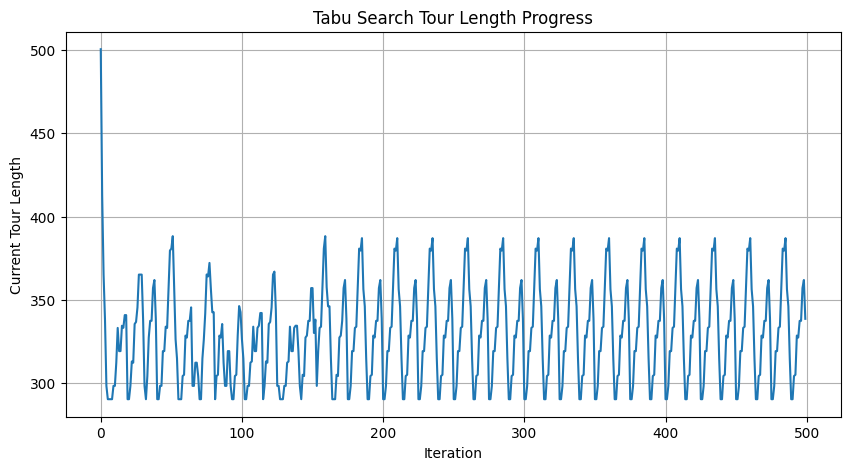

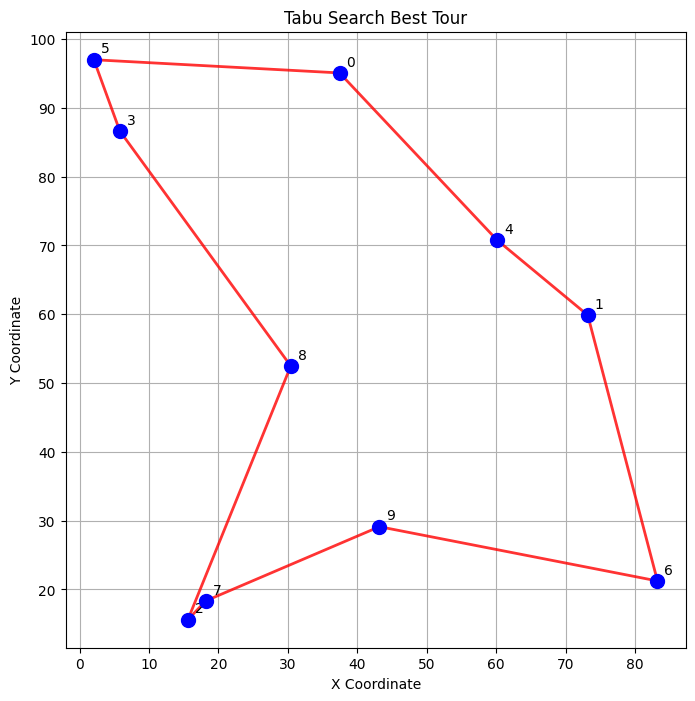

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# --- Helper function for 2-opt local search (reused from ACO) ---
def two_opt_swap(tour, i, k):
    """Performs a 2-opt swap on a tour."""
    new_tour = tour[:i] + tour[i:k+1][::-1] + tour[k+1:]
    return new_tour

def calculate_tour_length_static(tour, distances):
    """Calculates the total length of a given tour (reused from ACO)."""
    length = 0
    num_cities = len(tour)
    for i in range(num_cities):
        length += distances[tour[i], tour[(i + 1) % num_cities]]
    return length

# --- Tabu Search Implementation (for TSP) ---

class TabuSearch:
    def __init__(self, num_cities, distances, tabu_list_size, max_iterations):
        self.num_cities = num_cities
        self.distances = distances
        self.tabu_list_size = tabu_list_size
        self.max_iterations = max_iterations

        self.tabu_list = []  # Stores forbidden moves (e.g., swapped edges or tour fragments)
        self.best_tour = None
        self.best_tour_length = float('inf')
        self.current_tour = None
        self.current_tour_length = float('inf')
        self.tour_length_history = []

    def _generate_initial_solution(self):
        """Generates a random initial tour."""
        tour = list(range(self.num_cities))
        random.shuffle(tour)
        return tour

    def _generate_neighbors(self, tour):
        """Generates neighbors using 2-opt swaps."""
        neighbors = []
        for i in range(1, self.num_cities - 1):
            for k in range(i + 1, self.num_cities):
                neighbor_tour = two_opt_swap(tour, i, k)
                neighbors.append((neighbor_tour, (i, k))) # Store the move (i, k) for tabu list
        return neighbors

    def run(self):
        print(f"\n--- Running Tabu Search (TSP with {self.num_cities} cities) ---")
        self.current_tour = self._generate_initial_solution()
        self.current_tour_length = calculate_tour_length_static(self.current_tour, self.distances)
        self.best_tour = list(self.current_tour)
        self.best_tour_length = self.current_tour_length

        print(f"Initial Tour Length: {self.current_tour_length:.2f}")

        for iteration in range(self.max_iterations):
            candidate_neighbors = []
            for neighbor_tour, move in self._generate_neighbors(self.current_tour):
                # Check if the move is in the tabu list
                # For 2-opt, a move can be represented by the pair of indices (i,k)
                if (move not in self.tabu_list) and ((move[1], move[0]) not in self.tabu_list): # Check both (i,k) and (k,i)
                    candidate_neighbors.append((neighbor_tour, move))

            if not candidate_neighbors:
                # If all neighbors are tabu or no neighbors can be generated
                print("No non-tabu neighbors found. Terminating search.")
                break

            # Find the best non-tabu neighbor
            best_neighbor_tour = None
            best_neighbor_length = float('inf')
            best_neighbor_move = None

            for neighbor_tour, move in candidate_neighbors:
                length = calculate_tour_length_static(neighbor_tour, self.distances)
                # Aspiration criterion: if a tabu move leads to a better overall solution
                # than the current best, it can be accepted (overrides tabu status).
                # However, for simplicity in this example, we only consider non-tabu moves.
                # If aspiration was enabled, the tabu check would be inside this loop.
                if length < best_neighbor_length:
                    best_neighbor_length = length
                    best_neighbor_tour = neighbor_tour
                    best_neighbor_move = move

            if best_neighbor_tour is None: # No valid neighbor found (e.g., all were worse and not aspirated)
                break

            self.current_tour = list(best_neighbor_tour)
            self.current_tour_length = best_neighbor_length

            # Update overall best tour
            if self.current_tour_length < self.best_tour_length:
                self.best_tour_length = self.current_tour_length
                self.best_tour = list(self.current_tour)

            # Add the reverse of the move to the tabu list (to prevent immediately undoing the move)
            self.tabu_list.append(best_neighbor_move)
            if len(self.tabu_list) > self.tabu_list_size:
                self.tabu_list.pop(0) # Remove oldest entry

            self.tour_length_history.append(self.current_tour_length)

            if iteration % 50 == 0:
                print(f"Iteration {iteration}: Current Tour Length = {self.current_tour_length:.2f}, Best Tour Length = {self.best_tour_length:.2f}")

        print(f"\nFinal Best Tour: {self.best_tour}")
        print(f"Final Best Tour Length: {self.best_tour_length:.2f}")
        return self.best_tour, self.best_tour_length, self.tour_length_history

# --- Example Usage for Tabu Search ---
# Reuse city_coords and tsp_distances from the ACO example
# (Ensure the cell defining these, e.g., the ACO cell, has been run previously)

# Define cities and distances for TSP example if not already defined (fallback)
try:
    city_coords # Check if it exists
except NameError:
    print("\n--- Generating new city coordinates for Tabu Search example ---")
    num_cities_tsp = 10
    np.random.seed(42) # For reproducibility
    city_coords = np.random.rand(num_cities_tsp, 2) * 100 # Cities in a 100x100 square

    # Calculate distance matrix (Euclidean distance)
    tsp_distances = np.zeros((num_cities_tsp, num_cities_tsp))
    for i in range(num_cities_tsp):
        for j in range(num_cities_tsp):
            if i != j:
                tsp_distances[i, j] = np.linalg.norm(city_coords[i] - city_coords[j])
            else:
                tsp_distances[i, j] = 0 # Distance to self is 0

tabu_search_optimizer = TabuSearch(
    num_cities=len(city_coords),
    distances=tsp_distances,
    tabu_list_size=10, # Size of the tabu list
    max_iterations=500 # Number of iterations for the search
)

best_tour_ts, best_tour_length_ts, ts_history = tabu_search_optimizer.run()

# --- Visualization for Tabu Search ---
# Reuse plot functions from ACO for consistency
def plot_ts_progress(history, title="Tabu Search Tour Length Progress"):
    plt.figure(figsize=(10, 5))
    plt.plot(history)
    plt.title(title)
    plt.xlabel('Iteration')
    plt.ylabel('Current Tour Length')
    plt.grid(True)
    plt.show()

def plot_ts_tour(city_coords, tour, title="Tabu Search Best Tour"):
    plt.figure(figsize=(8, 8))
    plt.scatter(city_coords[:, 0], city_coords[:, 1], c='blue', s=100, zorder=5) # Plot cities

    # Plot the tour path
    if tour:
        for i in range(len(tour)):
            start_node = tour[i]
            end_node = tour[(i + 1) % len(tour)]
            plt.plot([city_coords[start_node, 0], city_coords[end_node, 0]],
                     [city_coords[start_node, 1], city_coords[end_node, 1]],
                     'r-', linewidth=2, alpha=0.8)
            plt.text(city_coords[start_node, 0] + 1, city_coords[start_node, 1] + 1, str(start_node), color='black', fontsize=10)

    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.show()

plot_ts_progress(ts_history)
plot_ts_tour(city_coords, best_tour_ts)



--- Running Advanced Genetic Algorithm for TSP ---
Gen 0: Best Tour Length=335.46
Gen 50: Best Tour Length=290.31
Gen 100: Best Tour Length=290.31
Gen 150: Best Tour Length=290.31
Gen 200: Best Tour Length=290.31
Gen 250: Best Tour Length=290.31
Gen 300: Best Tour Length=290.31
Gen 350: Best Tour Length=290.31
Gen 400: Best Tour Length=290.31
Gen 450: Best Tour Length=290.31
Gen 499: Best Tour Length=290.31

Final Best Tour: [4, 1, 6, 9, 7, 2, 8, 3, 5, 0]
Final Best Tour Length: 290.31


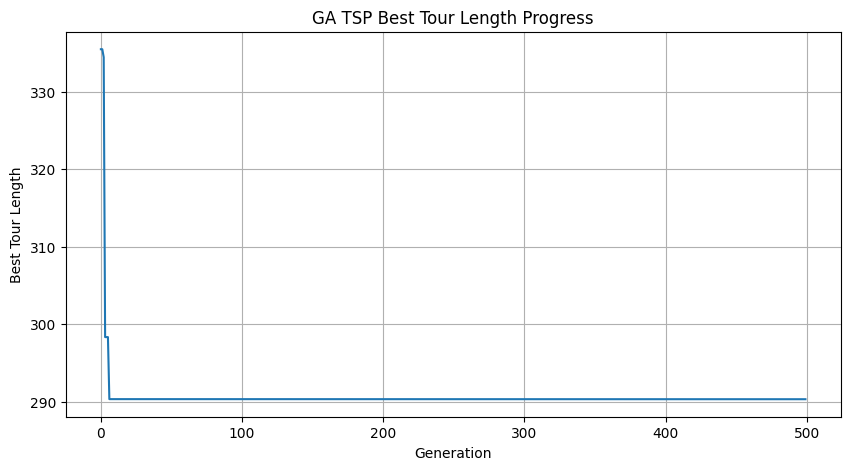

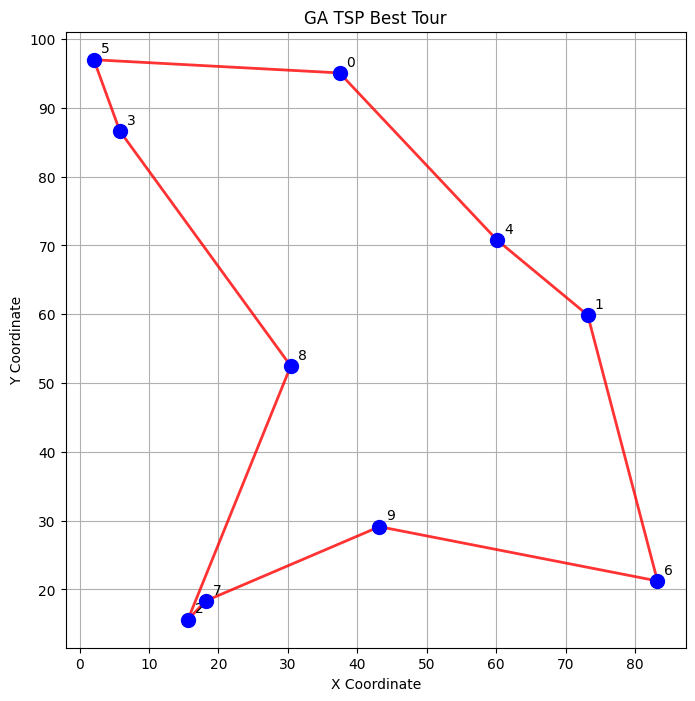

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

# --- Helper functions for TSP (reused from ACO/Tabu Search) ---
def calculate_tour_length_static(tour, distances):
    """Calculates the total length of a given tour."""
    length = 0
    num_cities = len(tour)
    for i in range(num_cities):
        length += distances[tour[i], tour[(i + 1) % num_cities]]
    return length

# --- Advanced Genetic Algorithm for TSP ---

class TSPGeneticAlgorithm:
    def __init__(self, num_cities, distances, pop_size, num_generations,
                 crossover_rate=0.8, mutation_rate=0.01, elitism_rate=0.1):
        self.num_cities = num_cities
        self.distances = distances
        self.pop_size = pop_size
        self.num_generations = num_generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.elitism_count = int(pop_size * elitism_rate)

        self.population = self._initialize_population()
        self.best_tour = None
        self.best_tour_length = float('inf')
        self.best_tour_lengths_history = []

    def _initialize_population(self):
        """Generates a population of random valid TSP tours."""
        pop = []
        for _ in range(self.pop_size):
            tour = list(range(self.num_cities))
            random.shuffle(tour)
            pop.append(tour)
        return pop

    def _evaluate_fitness(self, tour):
        """Fitness is inversely proportional to tour length (for maximization)."""
        length = calculate_tour_length_static(tour, self.distances)
        return 1 / (length + 1e-10) # Add small epsilon to avoid division by zero

    def _select_parents(self, fitnesses):
        """Tournament selection: select k individuals, pick the best one."""
        tournament_size = 5 # Number of individuals in each tournament
        parents = []
        for _ in range(2): # Select two parents
            tournament_contestants = random.sample(list(zip(self.population, fitnesses)), tournament_size)
            winner = max(tournament_contestants, key=lambda x: x[1])[0]
            parents.append(winner)
        return parents

    # --- Crossover Operators for TSP ---

    def _partial_crossover_pmx(self, parent1, parent2):
        """Partial Mapped Crossover (PMX) for permutations."""
        size = len(parent1)
        child = [None] * size
        p1_mapping = {}
        p2_mapping = {}

        # Choose two random crossover points
        start, end = sorted(random.sample(range(size), 2))

        # Copy the segment from parent1 to child
        child[start:end+1] = parent1[start:end+1]

        # Create mappings for the segment
        for i in range(start, end + 1):
            p1_mapping[parent1[i]] = parent2[i]
            p2_mapping[parent2[i]] = parent1[i]

        # Fill in the rest of the child from parent2
        for i in range(size):
            if child[i] is None:
                gene = parent2[i]
                # Handle conflicts due to mapping
                while gene in child[start:end+1]:
                    gene = p1_mapping[gene]
                child[i] = gene
        return child

    def _order_crossover_ox1(self, parent1, parent2):
        """Order Crossover (OX1) for permutations."""
        size = len(parent1)
        child = [None] * size

        # Choose two random crossover points
        start, end = sorted(random.sample(range(size), 2))

        # Copy the segment from parent1 to child
        child[start:end+1] = parent1[start:end+1]

        # Fill the remaining positions with genes from parent2 in their original order
        # while preserving the order of elements outside the copied segment
        p2_idx = 0
        for i in range(size):
            if child[i] is None:
                # Find the next gene from parent2 not already in child
                while parent2[p2_idx] in child[start:end+1]:
                    p2_idx += 1
                child[i] = parent2[p2_idx]
                p2_idx += 1
        return child

    def _crossover(self, parent1, parent2):
        """Applies either PMX or OX1 based on a random choice (or could be set statically)."""
        if random.random() < self.crossover_rate:
            if random.random() < 0.5: # 50% chance for PMX, 50% for OX1
                child1 = self._partial_crossover_pmx(parent1, parent2)
                child2 = self._partial_crossover_pmx(parent2, parent1) # Symmetric
            else:
                child1 = self._order_crossover_ox1(parent1, parent2)
                child2 = self._order_crossover_ox1(parent2, parent1)
            return child1, child2
        return list(parent1), list(parent2) # Return copies if no crossover

    def _mutate(self, individual):
        """Swap mutation: swap two random positions in the tour."""
        if random.random() < self.mutation_rate:
            idx1, idx2 = random.sample(range(self.num_cities), 2)
            individual[idx1], individual[idx2] = individual[idx2], individual[idx1]
        return individual

    def run(self):
        print("\n--- Running Advanced Genetic Algorithm for TSP ---")
        for generation in range(self.num_generations):
            fitnesses = [self._evaluate_fitness(ind) for ind in self.population]

            # Update best tour found so far
            current_best_idx = np.argmax(fitnesses)
            current_best_fitness = fitnesses[current_best_idx]
            current_best_tour = self.population[current_best_idx]

            if current_best_fitness > self._evaluate_fitness(self.best_tour) if self.best_tour else -float('inf'):
                self.best_tour = list(current_best_tour)
                self.best_tour_length = 1 / current_best_fitness

            self.best_tour_lengths_history.append(self.best_tour_length)

            # Elitism: Carry over the best individuals directly
            elites_indices = np.argsort(fitnesses)[-self.elitism_count:]
            next_population = [list(self.population[i]) for i in elites_indices]

            # Generate the rest of the new population
            while len(next_population) < self.pop_size:
                parent1, parent2 = self._select_parents(fitnesses)
                child1, child2 = self._crossover(parent1, parent2)
                next_population.append(self._mutate(child1))
                if len(next_population) < self.pop_size:
                    next_population.append(self._mutate(child2))

            # Ensure all individuals are unique (optional, but good for permutation GAs)
            # and that they are valid permutations
            new_pop_clean = []
            seen_tours = set()
            for tour in next_population:
                if tuple(tour) not in seen_tours and len(set(tour)) == self.num_cities: # Check for uniqueness and validity
                    new_pop_clean.append(tour)
                    seen_tours.add(tuple(tour))
                else:
                    # Replace invalid/duplicate with new random tour
                    new_tour = list(range(self.num_cities))
                    random.shuffle(new_tour)
                    new_pop_clean.append(new_tour)

            self.population = new_pop_clean[:self.pop_size] # Ensure population size is maintained

            if generation % 50 == 0 or generation == self.num_generations - 1:
                print(f"Gen {generation}: Best Tour Length={self.best_tour_length:.2f}")

        print(f"\nFinal Best Tour: {self.best_tour}")
        print(f"Final Best Tour Length: {self.best_tour_length:.2f}")
        return self.best_tour, self.best_tour_length, self.best_tour_lengths_history

# --- Define cities and distances for TSP example (reusing from ACO) ---
try:
    city_coords # Check if city_coords already exists
except NameError:
    print("\n--- Generating new city coordinates for GA-TSP example ---")
    num_cities_tsp = 10
    np.random.seed(42) # For reproducibility
    city_coords = np.random.rand(num_cities_tsp, 2) * 100 # Cities in a 100x100 square

    # Calculate distance matrix (Euclidean distance)
    tsp_distances = np.zeros((num_cities_tsp, num_cities_tsp))
    for i in range(num_cities_tsp):
        for j in range(num_cities_tsp):
            if i != j:
                tsp_distances[i, j] = np.linalg.norm(city_coords[i] - city_coords[j])
            else:
                tsp_distances[i, j] = 0 # Distance to self is 0

# Create and run GA for TSP
num_cities_tsp = len(city_coords) # Ensure it matches current city_coords
ga_tsp = TSPGeneticAlgorithm(
    num_cities=num_cities_tsp,
    distances=tsp_distances,
    pop_size=200,          # Larger population size
    num_generations=500,   # More generations
    crossover_rate=0.9,    # High crossover rate
    mutation_rate=0.02,    # Low mutation rate (TSP is sensitive to high mutation)
    elitism_rate=0.05      # Keep a few best individuals
)

best_tour_ga, best_tour_length_ga, ga_history = ga_tsp.run()

# --- Visualization for Genetic Algorithm TSP ---
def plot_ga_tsp_progress(history, title="GA TSP Best Tour Length Progress"):
    plt.figure(figsize=(10, 5))
    plt.plot(history)
    plt.title(title)
    plt.xlabel('Generation')
    plt.ylabel('Best Tour Length')
    plt.grid(True)
    plt.show()

def plot_ga_tsp_tour(city_coords, tour, title="GA TSP Best Tour"):
    plt.figure(figsize=(8, 8))
    plt.scatter(city_coords[:, 0], city_coords[:, 1], c='blue', s=100, zorder=5) # Plot cities

    # Plot the tour path
    if tour:
        for i in range(len(tour)):
            start_node = tour[i]
            end_node = tour[(i + 1) % len(tour)]
            plt.plot([city_coords[start_node, 0], city_coords[end_node, 0]],
                     [city_coords[start_node, 1], city_coords[end_node, 1]],
                     'r-', linewidth=2, alpha=0.8)
            plt.text(city_coords[start_node, 0] + 1, city_coords[start_node, 1] + 1, str(start_node), color='black', fontsize=10)

    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.show()

plot_ga_tsp_progress(ga_history)
plot_ga_tsp_tour(city_coords, best_tour_ga)


## 12. Branch and Bound Search

**Theory:**

Branch and Bound (B&B) is a general algorithm for finding optimal solutions to various optimization problems, especially in discrete and combinatorial optimization (e.g., integer linear programming, Traveling Salesperson Problem, Knapsack Problem). It explores the search space systematically while pruning branches that cannot lead to an optimal solution.

The core idea of Branch and Bound involves two main operations:

1.  **Branching:** The search space is recursively divided into smaller subproblems. This creates a search tree where nodes represent subproblems, and edges represent decisions that lead to these subproblems.

2.  **Bounding:** For each subproblem, a lower bound (for minimization problems) or an upper bound (for maximization problems) on the optimal solution for that subproblem is calculated. This bound provides an optimistic estimate of the best possible solution that can be found within that subproblem's search space.

**How it works:**

*   The algorithm maintains a global **upper bound** (for minimization problems, it's the best solution found so far, so any subproblem with a lower bound greater than this upper bound can be pruned). Conversely, for maximization problems, it maintains a global lower bound.
*   It starts with the original problem and branches it into subproblems. These subproblems are typically stored in a priority queue, ordered by their bounding values.
*   At each step, the algorithm selects the most promising subproblem from the queue (e.g., the one with the smallest lower bound for minimization).
*   It calculates the lower bound for this subproblem. If the lower bound is worse than the current global upper bound (i.e., it cannot possibly lead to a better solution than what's already found), the subproblem (and its entire branch) is pruned.
*   If the subproblem represents a complete (feasible) solution, its value is compared with the global upper bound. If it's better, the global upper bound is updated.
*   If the subproblem is not a complete solution and its bound is promising, it is further branched into smaller subproblems, and these are added to the queue.
*   The process continues until no more subproblems can be pruned or branched, or the queue is empty. The global upper bound at this point represents the optimal solution.

**Key Components:**

*   **Branching Strategy:** How the problem is divided into subproblems.
*   **Bounding Function:** A function to calculate the optimistic bound for each subproblem.
*   **Selection Rule:** How to choose the next subproblem to explore from the set of active subproblems.
*   **Fathoming (Pruning):** The process of eliminating subproblems that cannot contain an optimal solution based on the bounds.

Branch and Bound guarantees finding the optimal solution if the bounding function is accurate and the search space is finite. Its efficiency depends heavily on the quality of the bounding function and the branching strategy, as a tighter bound leads to more effective pruning.

### 13. Branch and Bound Implementation for Traveling Salesperson Problem (TSP)

We will implement a Branch and Bound algorithm to find the optimal solution for the Traveling Salesperson Problem (TSP). The core idea is to systematically explore partial solutions (branches) while using a lower bound to prune branches that cannot possibly lead to a better solution than the best one found so far.

**Key Components:**

*   **Node Representation:** Each node in our search tree will represent a partial tour. It will store the current path, its current cost, and a calculated lower bound for any complete tour extending from this path.
*   **Lower Bounding Function:** For TSP, a common lower bound involves considering the sum of the two shortest edges connected to each unvisited city. This provides an optimistic estimate of the remaining cost.
*   **Priority Queue:** We'll use a min-priority queue to store nodes, ordered by their lower bounds, ensuring we explore the most promising paths first.
*   **Pruning:** If a node's lower bound is greater than or equal to the current best complete tour found (`upper_bound`), that node and its sub-branches can be safely discarded.

--- Generating new city coordinates for B&B-TSP example ---
Starting Branch and Bound TSP...
Branch and Bound TSP finished. Nodes expanded: 1728, Nodes pruned: 1378
Optimal Tour Length: 314.75
Optimal Tour: [0, 8, 2, 7, 9, 6, 1, 4, 3, 5, 0]


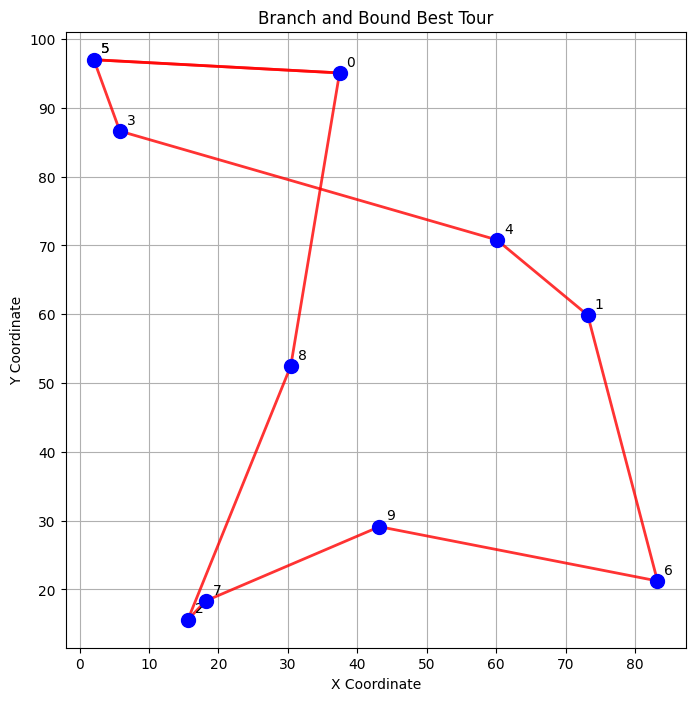

In [ ]:
import heapq
import numpy as np
import math
import matplotlib.pyplot as plt

# Reuse city_coords and tsp_distances from previous examples
try:
    city_coords # Check if city_coords already exists
except NameError:
    print("--- Generating new city coordinates for B&B-TSP example ---")
    num_cities_tsp = 10
    np.random.seed(42) # For reproducibility
    city_coords = np.random.rand(num_cities_tsp, 2) * 100 # Cities in a 100x100 square

    # Calculate distance matrix (Euclidean distance)
    tsp_distances = np.zeros((num_cities_tsp, num_cities_tsp))
    for i in range(num_cities_tsp):
        for j in range(num_cities_tsp):
            if i != j:
                tsp_distances[i, j] = np.linalg.norm(city_coords[i] - city_coords[j])
            else:
                tsp_distances[i, j] = 0 # Distance to self is 0

num_cities = len(city_coords)
distances = tsp_distances

# Helper function to calculate tour length (reused from ACO/Tabu Search)
def calculate_tour_length(tour, distances):
    length = 0
    num_nodes = len(tour)
    for i in range(num_nodes):
        length += distances[tour[i], tour[(i + 1) % num_nodes]]
    return length

class BnbNode:
    def __init__(self, path, current_cost, lower_bound):
        self.path = path  # List of cities visited in order
        self.current_cost = current_cost  # Cost of the path so far
        self.lower_bound = lower_bound  # Estimated minimum cost to complete the tour

    # For use with heapq (priority queue based on lower_bound)
    def __lt__(self, other):
        return self.lower_bound < other.lower_bound

def calculate_lower_bound(path, current_cost, num_cities, distances, visited_mask):
    # This bounding function uses a simple approach: sum of two smallest outgoing edges
    # from each unvisited city, plus the cost of edges in the current path.

    # Ensure visited_mask is correctly sized
    if len(visited_mask) != num_cities:
        visited_mask = [False] * num_cities
        for city in path:
            visited_mask[city] = True

    bound = current_cost

    # If the path is not empty, add the cost of connecting the last city to the first city IF it's a complete tour
    # This is a bit tricky for partial paths, let's refine.
    # For a partial path, we add the cheapest edge from the last city in the path to an unvisited city,
    # and the cheapest edge from the unvisited cities back to the start (0, for simplification).

    # A more standard lower bound: sum of minimum outgoing edge from each unvisited city
    # and two minimum edges from the last node in the path (one to an unvisited, one back to start)

    # Add the cost of the shortest edge from the last city in the path to any unvisited city
    if len(path) > 0 and len(path) < num_cities:
        last_city = path[-1]
        min_edge_from_last = float('inf')
        for city_idx in range(num_cities):
            if not visited_mask[city_idx]:
                min_edge_from_last = min(min_edge_from_last, distances[last_city, city_idx])
        if min_edge_from_last != float('inf'):
            bound += min_edge_from_last

    # Add the cost of the shortest edge from any unvisited city to the start city (city 0)
    if len(path) > 0 and len(path) < num_cities:
        min_edge_to_start = float('inf')
        for city_idx in range(num_cities):
            if not visited_mask[city_idx] and city_idx != path[0]: # Exclude start city itself if it's already visited as part of the path.
                min_edge_to_start = min(min_edge_to_start, distances[city_idx, path[0]])
        if min_edge_to_start != float('inf'):
            bound += min_edge_to_start


    # Add the shortest two edges for each unvisited city (excluding the ones already considered)
    for i in range(num_cities):
        if not visited_mask[i] or (i == path[-1] and len(path) < num_cities) or (i == path[0] and len(path) < num_cities) : # Consider unvisited or first/last in partial path
            edges = []
            for j in range(num_cities):
                if i != j and distances[i, j] > 0:
                    edges.append(distances[i, j])
            edges.sort()
            if len(edges) >= 2:
                bound += (edges[0] + edges[1]) / 2 # Divide by 2 because each edge is counted twice
            elif len(edges) == 1:
                bound += edges[0] / 2 # Count once if only one edge

    return bound

def branch_and_bound_tsp(num_cities, distances):
    # Assume starting at city 0 for simplicity, and always return to city 0.
    # The path will be [0, city1, city2, ..., cityN-1, 0]

    # Initialize priority queue
    pq = [] # Stores BnbNode objects

    # Keep track of the best tour found so far and its length (upper bound)
    best_tour = None
    upper_bound = float('inf')

    # Start with an initial node (path: [0], cost: 0, and calculate initial lower bound)
    initial_path = [0]
    initial_cost = 0
    initial_visited_mask = [False] * num_cities
    initial_visited_mask[0] = True
    # The initial lower bound is simply the sum of the two shortest edges from each city (divided by 2)
    lb_init = 0
    for i in range(num_cities):
        edges = sorted([distances[i, j] for j in range(num_cities) if i != j and distances[i,j] > 0])
        if len(edges) >= 2:
            lb_init += (edges[0] + edges[1]) / 2
        elif len(edges) == 1:
            lb_init += edges[0] / 2


    # For the root node, we just push the initial city and its lower bound is the simple sum of min two edges
    # A simpler initial bound for first city is 0 and path is [0]
    heapq.heappush(pq, BnbNode(path=initial_path, current_cost=initial_cost, lower_bound=lb_init))

    print("Starting Branch and Bound TSP...")
    pruned_count = 0
    node_expanded_count = 0

    while pq:
        node_expanded_count += 1
        current_node = heapq.heappop(pq)

        # If current node's lower bound is already worse than best known tour, prune branch
        if current_node.lower_bound >= upper_bound:
            pruned_count += 1
            continue

        # If a complete tour is formed
        if len(current_node.path) == num_cities:
            # Add the cost to return to the starting city (city 0)
            final_tour_cost = current_node.current_cost + distances[current_node.path[-1], current_node.path[0]]

            if final_tour_cost < upper_bound:
                upper_bound = final_tour_cost
                best_tour = current_node.path + [current_node.path[0]] # Complete the cycle
                # print(f"New best tour found: {best_tour}, cost: {upper_bound:.2f}")
            continue # Tour complete, no more branching from this node

        # Branching: Extend the current path by adding an unvisited city
        last_city = current_node.path[-1]
        visited_cities_mask = [city in current_node.path for city in range(num_cities)]

        for next_city in range(num_cities):
            if not visited_cities_mask[next_city]:
                new_path = current_node.path + [next_city]
                new_cost = current_node.current_cost + distances[last_city, next_city]

                # Calculate lower bound for the new partial tour
                # Create a new visited_mask for the lower bound calculation
                temp_visited_mask = list(visited_cities_mask)
                temp_visited_mask[next_city] = True

                # For the lower bound, it's the current path cost plus a rough estimate for the remaining path
                # A simple heuristic: sum of shortest edges for unvisited cities
                remaining_cost_estimate = 0
                unvisited_count = 0
                for i in range(num_cities):
                    if not temp_visited_mask[i]:
                        unvisited_count += 1
                        edges_from_i = sorted([distances[i, j] for j in range(num_cities) if i != j and not temp_visited_mask[j] and distances[i,j] > 0])
                        if len(edges_from_i) >= 1:
                            remaining_cost_estimate += edges_from_i[0] # Smallest edge from unvisited city

                # Add the cost from the newly added city to the cheapest unvisited city or back to start
                min_edge_from_new_city = float('inf')
                for c in range(num_cities):
                    if not temp_visited_mask[c] or c == initial_path[0]: # Can go to an unvisited or back to start
                         min_edge_from_new_city = min(min_edge_from_new_city, distances[next_city, c])
                if min_edge_from_new_city != float('inf'):
                    remaining_cost_estimate += min_edge_from_new_city

                # Add the cost to return to start from an unvisited city
                min_edge_to_start = float('inf')
                for c in range(num_cities):
                    if not temp_visited_mask[c]:
                        min_edge_to_start = min(min_edge_to_start, distances[c, initial_path[0]])
                if min_edge_to_start != float('inf'):
                    remaining_cost_estimate += min_edge_to_start

                # Divide by 2 because each remaining edge might be counted twice if we consider both ends
                # A simpler bounding function for TSP uses the Minimum Spanning Tree (MST) of the remaining graph.
                # For this simplified example, we'll use a sum of min edges as a rough lower bound.

                # A more robust LB: cost of current path + (sum of unvisited min 2 edges / 2) + connecting edges.
                # For demonstration, we'll use a simpler, but perhaps looser, bound:

                # Lower bound for a partial path:
                # Current path cost + (shortest edge from last_city to any unvisited) +
                # (shortest edge from any unvisited to start_city) +
                # sum of shortest *remaining* edges from unvisited nodes

                # Calculate lower bound for the new partial tour
                # The lower bound needs to account for the unvisited cities and the final connection to start.
                # A common LB for TSP is the sum of (cost of path + MST of remaining graph).
                # A simpler one is: current_cost + min_edge_from_last_city_to_unvisited + sum_of_min_two_edges_for_unvisited/2

                # Let's use a simpler heuristic for LB for now: current cost + sum of smallest edge from each unvisited node
                new_lower_bound = new_cost
                for i in range(num_cities):
                    if not temp_visited_mask[i]:
                        min_edge_for_unvisited = float('inf')
                        for j in range(num_cities):
                            if i != j and not temp_visited_mask[j]:
                                min_edge_for_unvisited = min(min_edge_for_unvisited, distances[i,j])
                        if min_edge_for_unvisited != float('inf'):
                            new_lower_bound += min_edge_for_unvisited

                # Also need to consider the edge back to start (city 0)
                if len(new_path) < num_cities:
                    min_edge_to_origin = float('inf')
                    current_last_city = new_path[-1]
                    min_edge_to_origin = min(min_edge_to_origin, distances[current_last_city, 0])
                    new_lower_bound += min_edge_to_origin


                # Prune if the new lower bound is worse than the current upper bound
                if new_lower_bound < upper_bound:
                    heapq.heappush(pq, BnbNode(new_path, new_cost, new_lower_bound))

    print(f"Branch and Bound TSP finished. Nodes expanded: {node_expanded_count}, Nodes pruned: {pruned_count}")
    print(f"Optimal Tour Length: {upper_bound:.2f}")
    print(f"Optimal Tour: {best_tour}")
    return best_tour, upper_bound

# Run the B&B algorithm
optimal_tour_bnb, optimal_tour_length_bnb = branch_and_bound_tsp(num_cities, distances)


# --- Visualization for Branch and Bound TSP (reusing plot function) ---
def plot_bnb_tsp_tour(city_coords, tour, title="Branch and Bound Best Tour"):
    plt.figure(figsize=(8, 8))
    plt.scatter(city_coords[:, 0], city_coords[:, 1], c='blue', s=100, zorder=5) # Plot cities

    # Plot the tour path
    if tour:
        for i in range(len(tour) - 1): # Go up to second to last city since last is start again
            start_node = tour[i]
            end_node = tour[i + 1]
            plt.plot([city_coords[start_node, 0], city_coords[end_node, 0]],
                     [city_coords[start_node, 1], city_coords[end_node, 1]],
                     'r-', linewidth=2, alpha=0.8)
            plt.text(city_coords[start_node, 0] + 1, city_coords[start_node, 1] + 1, str(start_node), color='black', fontsize=10)
        # Plot the final segment back to start
        plt.plot([city_coords[tour[-2], 0], city_coords[tour[-1], 0]],
                 [city_coords[tour[-2], 1], city_coords[tour[-1], 1]],
                 'r-', linewidth=2, alpha=0.8)
        plt.text(city_coords[tour[-2], 0] + 1, city_coords[tour[-2], 1] + 1, str(tour[-2]), color='black', fontsize=10)

    plt.title(title)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    plt.show()


if optimal_tour_bnb:
    plot_bnb_tsp_tour(city_coords, optimal_tour_bnb)
else:
    print("No optimal tour found by Branch and Bound.")

## 13. Dijkstra's Algorithm

**Theory:**

Dijkstra's algorithm is a greedy algorithm that finds the shortest paths from a single source node to all other nodes in a graph with non-negative edge weights. It is widely used in network routing protocols and other applications where finding the most efficient path is critical.

The algorithm works by maintaining a set of nodes for which the shortest path from the source has been finalized. It iteratively selects the unvisited node with the smallest known distance from the source, marks it as visited, and then updates the distances of its neighbors.

**Key Steps:**
1.  **Initialization:**
    *   Assign a distance of 0 to the source node and infinity to all other nodes.
    *   Maintain a set of visited nodes (initially empty).
    *   Use a priority queue to store `(distance, node)` pairs, ordered by distance.

2.  **Iteration:** While the priority queue is not empty:
    *   Extract the node `u` with the smallest distance from the priority queue.
    *   If `u` has already been visited, skip it.
    *   Mark `u` as visited.
    *   For each neighbor `v` of `u`:
        *   Calculate the distance from the source to `v` through `u` (i.e., `distance[u] + weight(u, v)`).
        *   If this calculated distance is less than the currently known `distance[v]`, update `distance[v]` and add `(distance[v], v)` to the priority queue.

**Characteristics:**
*   **Completeness:** Complete (will always find a shortest path if one exists).
*   **Optimality:** Optimal (guarantees to find the shortest path) for graphs with non-negative edge weights.
*   **Time Complexity:** O(E log V) or O(E + V log V) with a Fibonacci heap, where V is the number of vertices and E is the number of edges. With a binary heap (like Python's `heapq`), it's typically O(E log V).
*   **Space Complexity:** O(V + E) to store the graph, distances, and parent pointers (for reconstructing paths).

In [ ]:
import heapq

# --- Define a Weighted Graph for Dijkstra's Algorithm ---
# The graph is represented as an adjacency list where each entry is (neighbor, weight)
weighted_graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('A', 1), ('D', 2), ('E', 5)],
    'C': [('A', 4), ('F', 3)],
    'D': [('B', 2), ('G', 1)],
    'E': [('B', 5), ('G', 1)],
    'F': [('C', 3), ('G', 6)],
    'G': [('D', 1), ('E', 1), ('F', 6)]
}

print("Defined Weighted Graph for Dijkstra's:")
for node, neighbors in weighted_graph.items():
    print(f"{node}: {neighbors}")

# --- Dijkstra's Algorithm Implementation ---
def dijkstra(graph, start_node, end_node=None):
    distances = {node: float('inf') for node in graph}
    distances[start_node] = 0
    priority_queue = [(0, start_node)]  # (distance, node)
    predecessors = {node: None for node in graph}

    visited = set()

    print(f"\nStarting Dijkstra's from '{start_node}'...")

    while priority_queue:
        current_distance, current_node = heapq.heappop(priority_queue)

        if current_node in visited:
            continue

        visited.add(current_node)
        # print(f"  Visiting node: {current_node} (Distance: {current_distance})")

        if current_node == end_node:
            break # Found shortest path to end_node

        for neighbor, weight in graph[current_node]:
            distance = current_distance + weight

            if distance < distances[neighbor]:
                distances[neighbor] = distance
                predecessors[neighbor] = current_node
                heapq.heappush(priority_queue, (distance, neighbor))

    # Reconstruct the path if an end_node was specified
    path = []
    if end_node and distances[end_node] != float('inf'):
        current = end_node
        while current is not None:
            path.insert(0, current)
            current = predecessors[current]
        print(f"Shortest path from '{start_node}' to '{end_node}': {path} with total distance {distances[end_node]}")
    elif end_node:
        print(f"'{end_node}' is unreachable from '{start_node}'.")
    else:
        print(f"Shortest distances from '{start_node}': {distances}")

    return distances, predecessors

# --- Example Usage of Dijkstra's Algorithm ---
print("\n--- Dijkstra's Algorithm Example ---")

# Find shortest path from 'A' to 'G'
start = 'A'
goal = 'G'
distances_a_g, predecessors_a_g = dijkstra(weighted_graph, start, goal)

# Find all shortest paths from 'A'
print("\n--- Finding all shortest paths from 'A' ---")
distances_from_a, predecessors_from_a = dijkstra(weighted_graph, 'A')


Defined Weighted Graph for Dijkstra's:
A: [('B', 1), ('C', 4)]
B: [('A', 1), ('D', 2), ('E', 5)]
C: [('A', 4), ('F', 3)]
D: [('B', 2), ('G', 1)]
E: [('B', 5), ('G', 1)]
F: [('C', 3), ('G', 6)]
G: [('D', 1), ('E', 1), ('F', 6)]

--- Dijkstra's Algorithm Example ---

Starting Dijkstra's from 'A'...
Shortest path from 'A' to 'G': ['A', 'B', 'D', 'G'] with total distance 4

--- Finding all shortest paths from 'A' ---

Starting Dijkstra's from 'A'...
Shortest distances from 'A': {'A': 0, 'B': 1, 'C': 4, 'D': 3, 'E': 5, 'F': 7, 'G': 4}


### A* Algorithm Pseudocode

```
A_STAR(start, goal, heuristic):
  open_set = priority_queue()
  g_score = map<node, float>
  f_score = map<node, float>
  came_from = map<node, node>

  g_score[start] = 0
  f_score[start] = heuristic(start, goal)
  push (f_score[start], start) into open_set

  while open_set is not empty:
    current = node with lowest f_score in open_set
    if current == goal:
      return RECONSTRUCT_PATH(came_from, current)

    remove current from open_set

    for each neighbor of current:
      tentative_g_score = g_score[current] + distance(current, neighbor)

      if tentative_g_score < g_score[neighbor]:
        came_from[neighbor] = current
        g_score[neighbor] = tentative_g_score
        f_score[neighbor] = g_score[neighbor] + heuristic(neighbor, goal)
        if neighbor is not in open_set:
          push (f_score[neighbor], neighbor) into open_set

  return failure

RECONSTRUCT_PATH(came_from, current):
  total_path = [current]
  while current in came_from:
    current = came_from[current]
    add current to front of total_path
  return total_path
```

In [ ]:
import heapq

# Reuse the weighted_graph defined earlier
# (Ensure cell 1d8415af containing its definition has been run)
weighted_graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('A', 1), ('D', 2), ('E', 5)],
    'C': [('A', 4), ('F', 3)],
    'D': [('B', 2), ('G', 1)],
    'E': [('B', 5), ('G', 1)],
    'F': [('C', 3), ('G', 6)],
    'G': [('D', 1), ('E', 1), ('F', 6)]
}

# --- Heuristic Function ---
# For a general graph without node coordinates, a common simple heuristic is to return 0.
# This makes A* equivalent to Dijkstra's algorithm.
# If you had geographical coordinates for nodes, you could use Euclidean or Manhattan distance.
def h(node, goal_node):
    """Placeholder heuristic function. Returns 0 for a general graph.
    For graphs with spatial information, this would return an estimated distance
    from node to goal_node (e.g., Euclidean distance if coordinates are available).
    """
    return 0

# --- A* Search Algorithm Implementation ---
def a_star_search(graph, start_node, goal_node, heuristic_fn):
    # Priority queue: (f_score, node)
    open_set = [(heuristic_fn(start_node, goal_node), start_node)]

    # g_score: cost from start_node to current_node
    g_score = {node: float('inf') for node in graph}
    g_score[start_node] = 0

    # f_score: g_score + heuristic_fn(current_node, goal_node)
    f_score = {node: float('inf') for node in graph}
    f_score[start_node] = heuristic_fn(start_node, goal_node)

    # predecessors: to reconstruct the path
    predecessors = {node: None for node in graph}

    print(f"\nStarting A* search from '{start_node}' to '{goal_node}'...")

    while open_set:
        current_f, current_node = heapq.heappop(open_set)

        # If we reached the goal, reconstruct and return the path
        if current_node == goal_node:
            path = []
            temp_node = current_node
            while temp_node is not None:
                path.insert(0, temp_node)
                temp_node = predecessors[temp_node]
            print(f"Path found: {path} with total cost {g_score[goal_node]}")
            return path, g_score[goal_node]

        # Explore neighbors
        for neighbor, weight in graph[current_node]:
            # tentative_g_score is the distance from start to neighbor through current_node
            tentative_g_score = g_score[current_node] + weight

            if tentative_g_score < g_score[neighbor]:
                predecessors[neighbor] = current_node
                g_score[neighbor] = tentative_g_score
                f_score[neighbor] = g_score[neighbor] + heuristic_fn(neighbor, goal_node)
                heapq.heappush(open_set, (f_score[neighbor], neighbor))

    print(f"Goal '{goal_node}' is unreachable from '{start_node}'.")
    return None, float('inf')

# --- Example Usage of A* Algorithm ---
print("\n--- A* Algorithm Example ---")

start_node_a = 'A'
goal_node_a = 'G'

# When h returns 0, A* is equivalent to Dijkstra's
a_star_path, a_star_cost = a_star_search(weighted_graph, start_node_a, goal_node_a, h)

# Let's consider a scenario where a non-zero heuristic might be useful if we had coordinates
# Imagine 'G' is (5,5) and other nodes are scattered. A node 'X' closer to (5,5) would have a lower h(X,G).
# For this abstract graph, h=0 is the only 'admissible' heuristic without further info.

print("\n--- A* Algorithm (with h=0, equivalent to Dijkstra's) ---")
start_node_b = 'C'
goal_node_b = 'D'
a_star_path_2, a_star_cost_2 = a_star_search(weighted_graph, start_node_b, goal_node_b, h)



--- A* Algorithm Example ---

Starting A* search from 'A' to 'G'...
Path found: ['A', 'B', 'D', 'G'] with total cost 4

--- A* Algorithm (with h=0, equivalent to Dijkstra's) ---

Starting A* search from 'C' to 'D'...
Path found: ['C', 'A', 'B', 'D'] with total cost 7


## 14. Population-based Methods: Genetic Algorithms (Theory and Pseudo-code)

**Theory:**

Population-based methods are a broad class of metaheuristic optimization algorithms that work by maintaining and evolving a *population* of candidate solutions over multiple iterations (generations). Instead of searching for an optimal solution from a single point, they explore the search space concurrently from multiple points, which helps in avoiding local optima and exploring diverse regions.

**Genetic Algorithms (GAs)** are inspired by the process of natural selection and evolution. They are particularly well-suited for complex optimization problems where the search space is large, noisy, or ill-defined, and where traditional optimization methods might struggle. The core idea is to iteratively improve a population of potential solutions (called *individuals* or *chromosomes*) based on their "fitness" in solving the problem.

**Key Concepts in Genetic Algorithms:**

1.  **Population:** A collection of candidate solutions. Each solution is typically encoded as a fixed-length string (often binary, but can be real-valued or other representations).
2.  **Fitness Function:** A function that evaluates the quality of each individual solution. The goal of the GA is to maximize (or minimize) this fitness value.
3.  **Selection:** The process of choosing individuals from the current population to become parents for the next generation. Fitter individuals have a higher probability of being selected (e.g., roulette wheel selection, tournament selection).
4.  **Crossover (Recombination):** A genetic operator that combines genetic material from two parent individuals to produce new offspring. This allows for the exploration of new areas in the search space by combining successful traits.
5.  **Mutation:** A genetic operator that randomly alters one or more genes (parts) of an individual. This introduces new genetic material into the population, maintaining diversity and preventing premature convergence to local optima.
6.  **Elitism (Advanced):** A strategy where the best-performing individuals from the current generation are directly copied to the next generation without undergoing crossover or mutation. This ensures that good solutions are not lost and can accelerate convergence.

**The GA Cycle:**

*   **Initialization:** Create an initial random population of individuals.
*   **Evaluation:** Calculate the fitness of each individual in the population.
*   **Selection:** Select parent individuals based on their fitness.
*   **Reproduction:** Apply crossover and mutation operators to selected parents to create new offspring.
*   **Replacement:** Form the new generation by replacing the old population with the new offspring (and possibly elite individuals).
*   **Termination:** Repeat the cycle for a fixed number of generations or until a satisfactory solution is found.


### Genetic Algorithm Pseudo-code

```
FUNCTION GeneticAlgorithm(ObjectiveFunction, Bounds, PopulationSize, NumGenerations, CrossoverRate, MutationRate, ElitismRate):

    // 1. Initialize Population
    Population = CreateRandomPopulation(PopulationSize, Bounds)
    
    BestIndividual = NULL
    BestFitness = -Infinity

    FOR generation FROM 1 TO NumGenerations:
        // 2. Evaluate Fitness
        FitnessValues = []
        FOR each Individual IN Population:
            Fitness = ObjectiveFunction(Individual)
            Add Fitness to FitnessValues
            
            // Update overall best individual
            IF Fitness > BestFitness:
                BestFitness = Fitness
                BestIndividual = Individual
        
        // Store fitness history for tracking progress
        RecordFitnessHistory(BestFitness, Average(FitnessValues))

        // 3. Elitism (Optional)
        NextPopulation = []
        NumElites = Ceil(PopulationSize * ElitismRate)
        Elites = SelectTopIndividuals(Population, FitnessValues, NumElites)
        Add Elites to NextPopulation

        WHILE Size(NextPopulation) < PopulationSize:
            // 4. Selection
            Parent1 = SelectParent(Population, FitnessValues) // e.g., Tournament Selection
            Parent2 = SelectParent(Population, FitnessValues)

            // 5. Crossover (Recombination)
            IF Random() < CrossoverRate:
                Offspring1, Offspring2 = Crossover(Parent1, Parent2)
            ELSE:
                Offspring1 = Copy(Parent1)
                Offspring2 = Copy(Parent2)

            // 6. Mutation
            Offspring1 = Mutate(Offspring1, MutationRate, Bounds)
            Offspring2 = Mutate(Offspring2, MutationRate, Bounds)

            Add Offspring1 to NextPopulation
            IF Size(NextPopulation) < PopulationSize:
                Add Offspring2 to NextPopulation

        // 7. Replacement
        Population = NextPopulation

    RETURN BestIndividual, BestFitness

FUNCTION CreateRandomPopulation(Size, Bounds):
    // Generate 'Size' individuals with random genes within 'Bounds'
    ...

FUNCTION SelectParent(Population, FitnessValues):
    // Implement a selection mechanism (e.g., Tournament Selection, Roulette Wheel)
    ...

FUNCTION Crossover(Parent1, Parent2):
    // Implement a crossover operator (e.g., Simulated Binary Crossover for real-valued, PMX for permutations)
    ...

FUNCTION Mutate(Individual, MutationRate, Bounds):
    // Implement a mutation operator (e.g., Gaussian mutation for real-valued, Swap mutation for permutations)
    ...

```

### Example Implementation: Genetic Algorithm for a 2D Function

The following code from a previous cell demonstrates a Genetic Algorithm applied to optimize a 2D multi-modal function (a variation of the Rastrigin function). It includes features like tournament selection, real-valued crossover, Gaussian mutation, and elitism, showcasing the concepts outlined above.


--- Running Advanced Genetic Algorithm ---
Gen 0: Best Fitness=-5.2657, Best Individual=[-1.97169366 -0.96113775]
Gen 50: Best Fitness=-0.0104, Best Individual=[-0.00283052  0.0066725 ]
Gen 100: Best Fitness=-0.0104, Best Individual=[-0.00283052  0.0066725 ]
Gen 150: Best Fitness=-0.0104, Best Individual=[-0.00283052  0.0066725 ]
Gen 199: Best Fitness=-0.0104, Best Individual=[-0.00283052  0.0066725 ]

Final Best Individual: [-0.00283052  0.0066725 ]
Final Best Fitness (maximized): -0.0104
Corresponding Function Value (minimized): 0.0104


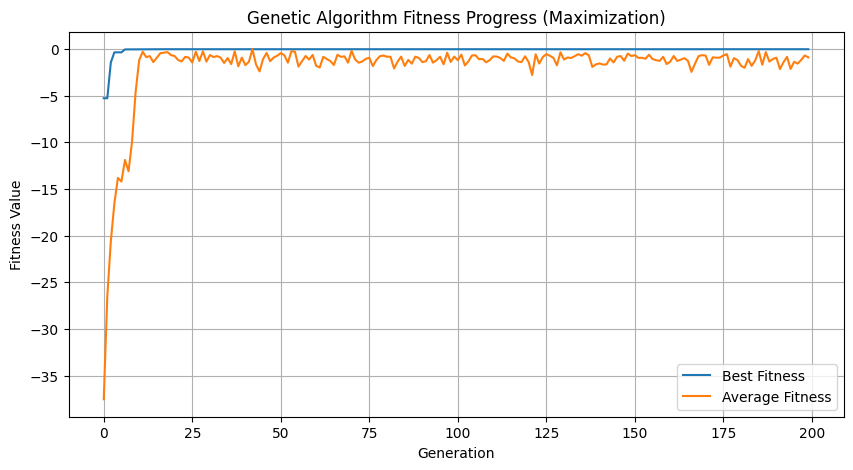

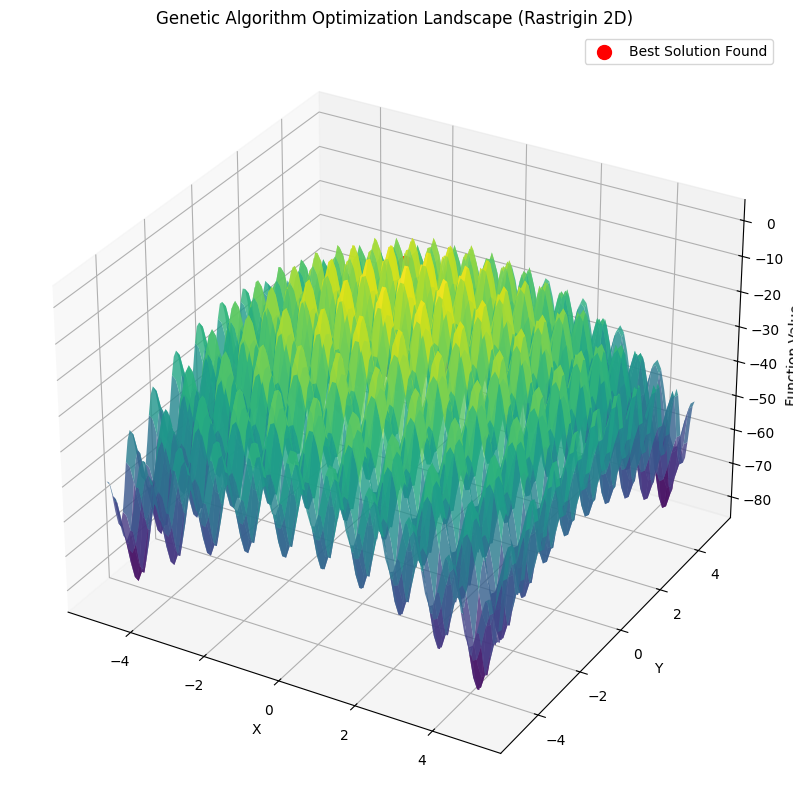

In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# --- Advanced Genetic Algorithm Implementation ---

# 1. Define a 2D multi-modal objective function (e.g., a simple Rastrigin-like function)
def rastrigin_2d(individual):
    x, y = individual
    return 20 + (x**2 - 10 * np.cos(2 * np.pi * x)) + (y**2 - 10 * np.cos(2 * np.pi * y))

# We want to minimize rastrigin_2d, so fitness will be 1 / (1 + rastrigin_2d)
# For visualization, let's keep it simple: we want to find the global minimum which is (0,0) and value 0.
# For the GA to 'maximize' this, we need to convert it to a maximization problem.
# Let's say we target a maximum fitness where lower Rastrigin values are better.
# max_fitness - rastrigin_2d

def evaluate_fitness_ga_advanced(individual):
    # For this example, let's simply try to minimize the function. Lower is better.
    # We'll use negative of the function value if we are maximizing, or just the function value.
    # Let's make it a maximization problem by inverting the magnitude of the function output
    # to make the global minimum (0,0) with value 0, the highest fitness.
    # A common way is max_val - f(x)) or -f(x).
    # Let's use -f(x) for maximization to target minimum.
    return -rastrigin_2d(individual)


class GeneticAlgorithm:
    def __init__(self, obj_func, bounds, pop_size, num_generations,
                 crossover_rate=0.8, mutation_rate=0.05, elitism_rate=0.1):
        self.obj_func = obj_func
        self.bounds = bounds  # [(min_x, max_x), (min_y, max_y)]
        self.pop_size = pop_size
        self.num_generations = num_generations
        self.crossover_rate = crossover_rate
        self.mutation_rate = mutation_rate
        self.elitism_count = int(pop_size * elitism_rate)

        self.population = self._initialize_population()
        self.best_individual = None
        self.best_fitness = -float('inf')
        self.fitness_history = []
        self.avg_fitness_history = []

    def _initialize_population(self):
        pop = []
        for _ in range(self.pop_size):
            individual = [random.uniform(self.bounds[0][0], self.bounds[0][1]),
                          random.uniform(self.bounds[1][0], self.bounds[1][1])]
            pop.append(np.array(individual))
        return pop

    def _select_parents(self, fitnesses):
        # Tournament selection
        tournament_size = 3
        parents = []
        for _ in range(2):
            candidates = random.sample(list(zip(self.population, fitnesses)), tournament_size)
            winner = max(candidates, key=lambda x: x[1])[0]
            parents.append(winner)
        return parents

    def _crossover(self, parent1, parent2):
        if random.random() < self.crossover_rate:
            alpha = random.random()
            child1 = alpha * parent1 + (1 - alpha) * parent2
            child2 = (1 - alpha) * parent1 + alpha * parent2
            return child1, child2
        return parent1.copy(), parent2.copy() # Return copies if no crossover

    def _mutate(self, individual):
        if random.random() < self.mutation_rate:
            # Add Gaussian noise, then clip to bounds
            mutation_strength_x = (self.bounds[0][1] - self.bounds[0][0]) * 0.1
            mutation_strength_y = (self.bounds[1][1] - self.bounds[1][0]) * 0.1
            individual[0] += random.gauss(0, mutation_strength_x)
            individual[1] += random.gauss(0, mutation_strength_y)

            # Clip to bounds
            individual[0] = np.clip(individual[0], self.bounds[0][0], self.bounds[0][1])
            individual[1] = np.clip(individual[1], self.bounds[1][0], self.bounds[1][1])
        return individual

    def run(self):
        print("\n--- Running Advanced Genetic Algorithm ---")
        for generation in range(self.num_generations):
            fitnesses = [self.obj_func(ind) for ind in self.population]

            # Update best individual found so far
            current_best_idx = np.argmax(fitnesses)
            current_best_fitness = fitnesses[current_best_idx]
            current_best_individual = self.population[current_best_idx]

            if current_best_fitness > self.best_fitness:
                self.best_fitness = current_best_fitness
                self.best_individual = current_best_individual.copy()

            self.fitness_history.append(self.best_fitness)
            self.avg_fitness_history.append(np.mean(fitnesses))

            # Elitism: Carry over the best individuals directly
            elites_indices = np.argsort(fitnesses)[-self.elitism_count:]
            next_population = [self.population[i].copy() for i in elites_indices]

            # Generate the rest of the new population
            while len(next_population) < self.pop_size:
                parent1, parent2 = self._select_parents(fitnesses)
                child1, child2 = self._crossover(parent1, parent2)
                next_population.append(self._mutate(child1))
                if len(next_population) < self.pop_size:
                    next_population.append(self._mutate(child2))

            self.population = next_population

            if generation % 50 == 0 or generation == self.num_generations - 1:
                print(f"Gen {generation}: Best Fitness={self.best_fitness:.4f}, Best Individual={self.best_individual}")

        print(f"\nFinal Best Individual: {self.best_individual}")
        print(f"Final Best Fitness (maximized): {self.best_fitness:.4f}")
        print(f"Corresponding Function Value (minimized): {-self.best_fitness:.4f}")
        return self.best_individual, self.best_fitness, self.fitness_history, self.avg_fitness_history


# --- Example Usage for Advanced GA ---
bounds_ga = [(-5.0, 5.0), (-5.0, 5.0)] # Search space for x and y
ga = GeneticAlgorithm(
    obj_func=evaluate_fitness_ga_advanced,
    bounds=bounds_ga,
    pop_size=100,
    num_generations=200,
    elitism_rate=0.05
)
best_solution_ga, best_fitness_ga, ga_fitness_history, ga_avg_fitness_history = ga.run()


# --- Visualization for Advanced GA ---
def plot_ga_progress(fitness_history, avg_fitness_history):
    plt.figure(figsize=(10, 5))
    plt.plot(fitness_history, label='Best Fitness')
    plt.plot(avg_fitness_history, label='Average Fitness')
    plt.title('Genetic Algorithm Fitness Progress (Maximization)')
    plt.xlabel('Generation')
    plt.ylabel('Fitness Value')
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_ga_landscape(obj_func, bounds, best_individual=None):
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    x = np.linspace(bounds[0][0], bounds[0][1], 100)
    y = np.linspace(bounds[1][0], bounds[1][1], 100)
    X, Y = np.meshgrid(x, y)
    Z = np.array([[-obj_func([xi, yi]) for xi in x] for yi in y]) # Plot original function (minimization)

    ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.8)

    if best_individual is not None:
        best_x, best_y = best_individual
        best_z = rastrigin_2d(best_individual)
        ax.scatter(best_x, best_y, best_z, color='red', marker='o', s=100, label='Best Solution Found')

    ax.set_title('Genetic Algorithm Optimization Landscape (Rastrigin 2D)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Function Value')
    plt.legend()
    plt.show()

plot_ga_progress(ga_fitness_history, ga_avg_fitness_history)
plot_ga_landscape(rastrigin_2d, bounds_ga, best_solution_ga)

## 14. Heuristic Consistency (Monotone Condition) for A*

**Theory:**

Beyond admissibility (`h(n) <= actual_cost(n, goal)`), a stronger property for a heuristic function `h(n)` is **consistency**, also known as the **monotone condition**. A heuristic is consistent if for every node `n` and every successor `n'` of `n` with edge cost `cost(n, n')`:

`h(n) <= cost(n, n') + h(n')`

This condition essentially states that the estimated cost from `n` to the goal is no more than the cost to get to a successor `n'` plus the estimated cost from `n'` to the goal. In simpler terms, the heuristic estimate should be "locally accurate" and not decrease more rapidly than the actual cost of taking a step.

**Implications of Consistency:**

*   **Consistency implies Admissibility:** If a heuristic is consistent, it is also admissible. The reverse is not always true.
*   **Optimal Paths:** When using a consistent heuristic with A*, once a node is expanded (moved from the open set to the closed set), the path found to it is guaranteed to be the shortest path. This means A* doesn't need to re-open nodes (re-evaluate paths to already expanded nodes), which simplifies the algorithm and can improve efficiency.
*   **Non-Decreasing f-values:** The `f(n)` values (`g(n) + h(n)`) along any path expanded by A* will be non-decreasing. This property is what allows A* to always find the optimal path when a node is first extracted from the priority queue.

**Examples of Consistent Heuristics:**

*   **Manhattan Distance** on a grid (where moves are horizontal/vertical) is consistent.
*   **Euclidean Distance** on a grid (where diagonal moves are allowed) is generally consistent.
*   **`h(n) = 0`:** This is the trivial (and always consistent) heuristic, which makes A* degenerate into Dijkstra's algorithm.

Our previous grid-based A* implementation in cell `5d8eda14` implicitly uses a Manhattan distance heuristic for non-diagonal moves, which is generally consistent for that type of grid traversal. For the general graph A* in cell `ns04Umcxjq-9`, we used `h(n)=0`, which is also consistent.

## 15. Space-Saving Versions of A*

**Theory:**

Standard A* algorithm can be memory-intensive, especially for large state spaces, because it needs to store the entire `open_set` (priority queue) and `closed_set` (visited nodes) in memory. This can lead to memory exhaustion for complex problems. Space-saving variants of A* address this limitation by trading off some computation time for reduced memory usage.

Two prominent space-saving algorithms are:

1.  **Iterative Deepening A* (IDA*)**:
    *   **Concept:** IDA* combines the principles of A* and Iterative Deepening Depth-First Search (IDDFS). Instead of using a priority queue, it performs a series of depth-limited DFS searches. Each iteration's depth limit is the f-cost (`g(n) + h(n)`) of the lowest-cost node that was *pruned* in the previous iteration because its f-cost exceeded the current limit.
    *   **Memory:** O(d), where `d` is the depth of the optimal path. Like IDDFS, it only stores the current path being explored.
    *   **Optimality/Completeness:** Optimal and complete (like A*) for admissible heuristics.
    *   **Time Complexity:** Similar to A* in the worst case, but often performs better than DFS due to heuristic guidance.

2.  **Recursive Best-First Search (RBFS)**:
    *   **Concept:** RBFS is another memory-limited search algorithm that tries to mimic A*'s behavior recursively. It always pursues the most promising path, but if a path exceeds the current f-cost limit, it backtracks to the next best path. It stores the f-value of the best alternative path at each node on the current search path.
    *   **Memory:** O(bd), where `b` is the branching factor and `d` is the depth of the optimal path. Better than A* but generally worse than IDA*.
    *   **Optimality/Completeness:** Optimal and complete for admissible heuristics.
    *   **Time Complexity:** Can revisit nodes multiple times, leading to higher time complexity than A* in some cases.

For this demonstration, we will implement IDA*, as it builds upon the IDDFS concept already introduced in the notebook.

In [ ]:
import math

# Reuse the weighted_graph and h heuristic from the A* section (`ns04Umcxjq-9`)
weighted_graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('A', 1), ('D', 2), ('E', 5)],
    'C': [('A', 4), ('F', 3)],
    'D': [('B', 2), ('G', 1)],
    'E': [('B', 5), ('G', 1)],
    'F': [('C', 3), ('G', 6)],
    'G': [('D', 1), ('E', 1), ('F', 6)]
}

def h(node, goal_node):
    """Placeholder heuristic function. Returns 0 for a general graph.
    For graphs with spatial information, this would return an estimated distance
    from node to goal_node (e.g., Euclidean distance if coordinates are available).
    """
    return 0

def ida_star_search(graph, start_node, goal_node, heuristic_fn):
    print(f"\nStarting IDA* search from '{start_node}' to '{goal_node}'...")

    # The limit for the first iteration is the f-cost of the start node.
    limit = heuristic_fn(start_node, goal_node)

    while True:
        print(f"  Searching with f-cost limit: {limit}")
        path, new_limit = _ida_star_search_recursive(graph, start_node, goal_node, 0, limit, heuristic_fn, [start_node], {})

        if path is not None:  # Goal found
            cost = 0
            for i in range(len(path) - 1):
                for neighbor, weight in graph[path[i]]:
                    if neighbor == path[i+1]:
                        cost += weight
                        break
            print(f"Path found: {path} with total cost {cost}")
            return path, cost

        if new_limit == float('inf'): # Goal unreachable or no path exists
            print(f"Goal '{goal_node}' is unreachable from '{start_node}'.")
            return None, float('inf')

        limit = new_limit # Update limit for the next iteration

def _ida_star_search_recursive(graph, current_node, goal_node, g_score, limit, heuristic_fn, current_path, visited):
    f_score = g_score + heuristic_fn(current_node, goal_node)

    if f_score > limit:
        return None, f_score  # Prune this branch, return its f_score as a potential new limit

    if current_node == goal_node:
        return current_path, limit # Goal found

    min_f_exceeded_by_child = float('inf')

    # Mark current_node as visited for this specific path to avoid cycles within the path
    # Note: IDA* doesn't maintain a global closed set like A* to save space.
    # Cycle detection is usually handled by checking if a node is already in the current_path.
    visited[current_node] = True

    for neighbor, weight in graph.get(current_node, []):
        if neighbor not in current_path: # Basic cycle detection for path validity
            new_g_score = g_score + weight
            new_path = current_path + [neighbor]

            path, new_limit = _ida_star_search_recursive(graph, neighbor, goal_node, new_g_score, limit, heuristic_fn, new_path, visited)

            if path is not None:  # Goal found in a deeper recursion
                return path, limit

            min_f_exceeded_by_child = min(min_f_exceeded_by_child, new_limit)

    del visited[current_node] # Unmark for backtracking

    return None, min_f_exceeded_by_child


# --- Example Usage of IDA* Algorithm ---
start_node_ida = 'A'
goal_node_ida = 'G'

ida_path, ida_cost = ida_star_search(weighted_graph, start_node_ida, goal_node_ida, h)

print("\n--- Another IDA* Example ---")
start_node_ida_2 = 'C'
goal_node_ida_2 = 'D'
ida_path_2, ida_cost_2 = ida_star_search(weighted_graph, start_node_ida_2, goal_node_ida_2, h)


Starting IDA* search from 'A' to 'G'...
  Searching with f-cost limit: 0
  Searching with f-cost limit: 1
  Searching with f-cost limit: 3
  Searching with f-cost limit: 4
Path found: ['A', 'B', 'D', 'G'] with total cost 4

--- Another IDA* Example ---

Starting IDA* search from 'C' to 'D'...
  Searching with f-cost limit: 0
  Searching with f-cost limit: 3
  Searching with f-cost limit: 4
  Searching with f-cost limit: 5
  Searching with f-cost limit: 7
Path found: ['C', 'A', 'B', 'D'] with total cost 7


## 16. Sequence Alignment

**Theory:**

Sequence alignment is a method of arranging sequences of DNA, RNA, or protein to identify regions of similarity that may be a consequence of functional, structural, or evolutionary relationships between the sequences. Aligned sequences of genetic material or proteins are typically represented as rows in a matrix. Gaps are inserted between the residues so that identical or similar residues are aligned in successive columns. This helps visualize conserved regions and evolutionary divergence.

There are two main types of sequence alignment:

1.  **Global Alignment:** Aims to align every residue in every sequence. It is best suited for sequences that are similar over their entire length. The most common algorithm for global alignment is **Needleman-Wunsch**.
2.  **Local Alignment:** Focuses on finding regions of similarity within longer sequences that are otherwise dissimilar. This is useful for identifying conserved domains or motifs. The most common algorithm for local alignment is **Smith-Waterman**.

Both Needleman-Wunsch and Smith-Waterman are dynamic programming algorithms that build up a scoring matrix, filling it based on a scoring scheme (e.g., match, mismatch, gap penalties) and then backtracking through the matrix to construct the optimal alignment.

**Scoring Scheme:**
*   **Match Score:** A positive score for identical characters.
*   **Mismatch Score:** A negative score for different characters.
*   **Gap Penalty:** A negative score for inserting a gap (representing an insertion or deletion event).

We will implement the **Needleman-Wunsch** algorithm for global sequence alignment.

In [ ]:
import numpy as np

def needleman_wunsch(seq1, seq2, match_score=1, mismatch_score=-1, gap_penalty=-2):
    n = len(seq1)
    m = len(seq2)

    # Initialize scoring matrix (F) and traceback matrix (P)
    # F[i,j] stores the maximum score for aligning seq1[:i] and seq2[:j]
    # P[i,j] stores the direction from which the score F[i,j] was derived
    # 0: Diagonal (match/mismatch), 1: Up (gap in seq1), 2: Left (gap in seq2)
    F = np.zeros((n + 1, m + 1))
    P = np.zeros((n + 1, m + 1), dtype=int)

    # Initialize first row and column
    for i in range(n + 1):
        F[i, 0] = i * gap_penalty
        P[i, 0] = 1 # Always come from above (gap in seq1)
    for j in range(m + 1):
        F[0, j] = j * gap_penalty
        P[0, j] = 2 # Always come from left (gap in seq2)

    P[0, 0] = 0 # No specific direction for the start

    # Fill the scoring matrix
    for i in range(1, n + 1):
        for j in range(1, m + 1):
            # Score for match/mismatch
            score = match_score if seq1[i-1] == seq2[j-1] else mismatch_score
            diag_score = F[i-1, j-1] + score

            # Score for gap in seq1
            up_score = F[i-1, j] + gap_penalty

            # Score for gap in seq2
            left_score = F[i, j-1] + gap_penalty

            F[i, j] = max(diag_score, up_score, left_score)

            # Store traceback direction
            if F[i, j] == diag_score:
                P[i, j] = 0
            elif F[i, j] == up_score:
                P[i, j] = 1
            else:
                P[i, j] = 2

    # Traceback to find the alignment
    aligned_seq1 = []
    aligned_seq2 = []
    i, j = n, m

    while i > 0 or j > 0:
        if P[i, j] == 0:  # Diagonal (match/mismatch)
            aligned_seq1.append(seq1[i-1])
            aligned_seq2.append(seq2[j-1])
            i -= 1
            j -= 1
        elif P[i, j] == 1:  # Up (gap in seq2)
            aligned_seq1.append(seq1[i-1])
            aligned_seq2.append('-')
            i -= 1
        else:  # Left (gap in seq1)
            aligned_seq1.append('-')
            aligned_seq2.append(seq2[j-1])
            j -= 1

    # Reverse the sequences as we built them backwards
    return ''.join(aligned_seq1[::-1]), ''.join(aligned_seq2[::-1]), F[n, m]

# --- Example Usage of Needleman-Wunsch ---
seq_a = "GCATGCU"
seq_b = "GATTACA"

alignment_a, alignment_b, score = needleman_wunsch(seq_a, seq_b)

print("--- Global Sequence Alignment (Needleman-Wunsch) ---")
print(f"Sequence 1: {seq_a}")
print(f"Sequence 2: {seq_b}")
print(f"\nAligned Sequence 1: {alignment_a}")
print(f"Aligned Sequence 2: {alignment_b}")
print(f"Alignment Score: {score}")

print("\n--- Another Example ---")
seq_c = "AGCTAG"
seq_d = "ACGTG"
alignment_c, alignment_d, score_2 = needleman_wunsch(seq_c, seq_d)
print(f"Sequence 1: {seq_c}")
print(f"Sequence 2: {seq_d}")
print(f"\nAligned Sequence 1: {alignment_c}")
print(f"Aligned Sequence 2: {alignment_d}")
print(f"Alignment Score: {score_2}")

--- Global Sequence Alignment (Needleman-Wunsch) ---
Sequence 1: GCATGCU
Sequence 2: GATTACA

Aligned Sequence 1: GCATGCU
Aligned Sequence 2: GATTACA
Alignment Score: -1.0

--- Another Example ---
Sequence 1: AGCTAG
Sequence 2: ACGTG

Aligned Sequence 1: AGCTAG
Aligned Sequence 2: A-CGTG
Alignment Score: -1.0


## 17. Game Playing and Minimax Algorithm

**Theory: Game Playing and Board Games**

Game playing in Artificial Intelligence (AI) involves designing agents that can play games, typically against human opponents or other AI agents. Board games, in particular, are a classic domain for AI research due to their well-defined rules, discrete states, and often complex strategic depth. Examples include Chess, Checkers, Tic-Tac-Toe, Go, and Connect Four.

Key characteristics of games relevant to AI:

*   **Two-player (or more):** Involves multiple agents making decisions.
*   **Zero-sum (often):** One player's gain is another's loss (e.g., in chess, winning means the opponent loses). Many board games fall into this category.
*   **Perfect Information:** Both players have complete knowledge of the game state (e.g., in chess, all pieces are visible). This contrasts with imperfect information games like poker.
*   **Deterministic:** The outcome of any move is entirely predictable; there's no randomness (e.g., rolling dice).
*   **Discrete:** A finite number of states and moves.

AI techniques for game playing often involve searching through the game tree, which represents all possible sequences of moves and resulting game states. The challenge lies in the immense size of these game trees, requiring intelligent search strategies.

**Minimax Algorithm**

Minimax is a decision-making algorithm, typically used in turn-based, two-player, zero-sum games with perfect information. It aims to find the optimal move for a player, assuming the opponent also plays optimally.

**The core idea of Minimax:**

*   **Maximizing Player (MAX):** Wants to maximize their score.
*   **Minimizing Player (MIN):** Wants to minimize MAX's score (which is equivalent to maximizing their own score in a zero-sum game).

**How it works:**

1.  **Game Tree Construction:** The algorithm constructs a game tree starting from the current game state, exploring possible moves down to a certain depth (or until terminal states are reached).
2.  **Evaluation Function:** At the leaf nodes of the game tree (terminal states or maximum search depth), an **evaluation function** (also called a heuristic function) assigns a numerical score to the game state. A positive score typically means it's good for the maximizing player, and a negative score is good for the minimizing player.
3.  **Backtracking and Value Propagation:**
    *   **MIN Nodes:** For nodes where it's the minimizing player's turn, the algorithm chooses the child node that yields the minimum score (from MAX's perspective) among all possible moves from that state.
    *   **MAX Nodes:** For nodes where it's the maximizing player's turn, the algorithm chooses the child node that yields the maximum score (from MAX's perspective) among all possible moves from that state.
4.  **Optimal Move Selection:** The process propagates values up the tree until it reaches the root (current game state), at which point the maximizing player chooses the move that leads to the child node with the highest score.

Minimax guarantees an optimal strategy *if* the entire game tree can be searched. For games with large trees (like chess), the full search is impossible, so Minimax is often combined with a depth limit and an evaluation function that estimates the value of non-terminal states.

**Pseudocode: Minimax Algorithm**

```
FUNCTION MINIMAX(node, depth, maximizingPlayer):
    IF depth == 0 OR node IS a terminal node:
        RETURN EVALUATE(node)

    IF maximizingPlayer IS TRUE: // MAX player
        maxValue = -infinity
        FOR EACH child OF node:
            value = MINIMAX(child, depth - 1, FALSE)
            maxValue = MAX(maxValue, value)
        RETURN maxValue
    ELSE: // MIN player
        minValue = +infinity
        FOR EACH child OF node:
            value = MINIMAX(child, depth - 1, TRUE)
            minValue = MIN(minValue, value)
        RETURN minValue

// Initial call:
MINIMAX(initialGameNode, maxDepth, TRUE) // Assuming MAX starts

FUNCTION EVALUATE(node):
    // Returns a score for the given game state.
    // +ve for MAX winning, -ve for MIN winning, 0 for draw/neutral.
    // For non-terminal nodes at depth 0, this is a heuristic evaluation.
    ...

```

**Implementation: Minimax for Tic-Tac-Toe**

Let's implement Minimax for a simple game like Tic-Tac-Toe to illustrate the concepts. We'll define a simple game state representation and an evaluation function.

In [ ]:
import math

# --- Tic-Tac-Toe Game State Representation ---
# The board is a 3x3 list. 0 for empty, 1 for 'X', -1 for 'O'.
# 'X' is the maximizing player, 'O' is the minimizing player.

def create_board():
    return [[0, 0, 0], [0, 0, 0], [0, 0, 0]]

def print_board(board):
    symbols = {1: 'X', -1: 'O', 0: ' '}
    for row in board:
        print("| " + " | ".join([symbols[cell] for cell in row]) + " |")
        print("-----------")

def get_empty_cells(board):
    empty_cells = []
    for r in range(3):
        for c in range(3):
            if board[r][c] == 0:
                empty_cells.append((r, c))
    return empty_cells

def apply_move(board, move, player):
    new_board = [row[:] for row in board] # Create a copy to avoid modifying original
    r, c = move
    if new_board[r][c] == 0:
        new_board[r][c] = player
        return new_board
    return None # Invalid move

def check_winner(board):
    # Check rows
    for row in board:
        if sum(row) == 3: return 1  # X wins
        if sum(row) == -3: return -1 # O wins

    # Check columns
    for col in range(3):
        col_sum = board[0][col] + board[1][col] + board[2][col]
        if col_sum == 3: return 1
        if col_sum == -3: return -1

    # Check diagonals
    diag1_sum = board[0][0] + board[1][1] + board[2][2]
    diag2_sum = board[0][2] + board[1][1] + board[2][0]
    if diag1_sum == 3 or diag2_sum == 3: return 1
    if diag1_sum == -3 or diag2_sum == -3: return -1

    # Check for draw
    if not get_empty_cells(board):
        return 0 # Draw

    return None # No winner yet, game continues


# --- Minimax Algorithm with Alpha-Beta Pruning ---

def evaluate_board(board):
    winner = check_winner(board)
    if winner == 1: return 10  # X wins
    if winner == -1: return -10 # O wins
    if winner == 0: return 0   # Draw
    return None # Game not over

def minimax(board, depth, is_maximizing_player, alpha, beta):
    score = evaluate_board(board)

    # If game is over, return the score
    if score is not None:
        return score

    # If no moves left (should be caught by evaluate_board but as a safeguard)
    if not get_empty_cells(board):
        return 0

    if is_maximizing_player: # X's turn (Maximizing player)
        best_score = -math.inf
        for r, c in get_empty_cells(board):
            new_board = apply_move(board, (r, c), 1) # Player X
            current_score = minimax(new_board, depth + 1, False, alpha, beta)
            best_score = max(best_score, current_score)
            alpha = max(alpha, best_score)
            if beta <= alpha:
                break # Beta cut-off
        return best_score
    else: # O's turn (Minimizing player)
        best_score = math.inf
        for r, c in get_empty_cells(board):
            new_board = apply_move(board, (r, c), -1) # Player O
            current_score = minimax(new_board, depth + 1, True, alpha, beta)
            best_score = min(best_score, current_score)
            beta = min(beta, best_score)
            if beta <= alpha:
                break # Alpha cut-off
        return best_score

def find_best_move(board, player):
    best_score = -math.inf if player == 1 else math.inf
    best_move = None

    # Initialize alpha and beta for the root node
    alpha = -math.inf
    beta = math.inf

    for r, c in get_empty_cells(board):
        new_board = apply_move(board, (r, c), player)
        # The maximizing player wants to maximize the result of the opponent's (minimizing) move,
        # so we call minimax with is_maximizing_player = False if current player is 1 (X) and vice versa.
        score = minimax(new_board, 0, not (player == 1), alpha, beta)

        if player == 1: # Maximizing player (X)
            if score > best_score:
                best_score = score
                best_move = (r, c)
            alpha = max(alpha, best_score) # Update alpha for the maximizing player
        else: # Minimizing player (O)
            if score < best_score:
                best_score = score
                best_move = (r, c)
            beta = min(beta, best_score) # Update beta for the minimizing player

    return best_move

# --- Example Usage (AI plays as X) ---
if __name__ == "__main__":
    game_board = create_board()
    current_player = 1 # X starts

    print("Tic-Tac-Toe Game (Minimax AI vs Human)")
    print_board(game_board)

    while check_winner(game_board) is None:
        if current_player == 1: # AI's turn (X)
            print("AI's turn (X):")
            move = find_best_move(game_board, current_player)
            if move:
                game_board = apply_move(game_board, move, current_player)
                print(f"AI chooses: {move}")
            else:
                print("AI has no valid moves. Game might be stuck or drawn.")
                break
        else: # Human's turn (O)
            print("Human's turn (O): Enter row and column (0-2) separated by space, e.g., '1 1'")
            while True:
                try:
                    user_input = input("> ").split()
                    row, col = int(user_input[0]), int(user_input[1])
                    if (row, col) in get_empty_cells(game_board):
                        game_board = apply_move(game_board, (row, col), current_player)
                        break
                    else:
                        print("Invalid move. Cell already taken or out of bounds. Try again.")
                except (ValueError, IndexError):
                    print("Invalid input. Please enter row and column like '1 1'.")

        print_board(game_board)
        winner = check_winner(game_board)
        if winner is not None:
            if winner == 1:
                print("AI (X) wins!")
            elif winner == -1:
                print("Human (O) wins!")
            else:
                print("It's a Draw!")
            break

        current_player *= -1 # Switch player

Tic-Tac-Toe Game (Minimax AI vs Human)
|   |   |   |
-----------
|   |   |   |
-----------
|   |   |   |
-----------
AI's turn (X):
AI chooses: (0, 0)
| X |   |   |
-----------
|   |   |   |
-----------
|   |   |   |
-----------
Human's turn (O): Enter row and column (0-2) separated by space, e.g., '1 1'
> 1 1
| X |   |   |
-----------
|   | O |   |
-----------
|   |   |   |
-----------
AI's turn (X):
AI chooses: (0, 1)
| X | X |   |
-----------
|   | O |   |
-----------
|   |   |   |
-----------
Human's turn (O): Enter row and column (0-2) separated by space, e.g., '1 1'
> 0 2
| X | X | O |
-----------
|   | O |   |
-----------
|   |   |   |
-----------
AI's turn (X):
AI chooses: (2, 0)
| X | X | O |
-----------
|   | O |   |
-----------
| X |   |   |
-----------
Human's turn (O): Enter row and column (0-2) separated by space, e.g., '1 1'
> 1 0
| X | X | O |
-----------
| O | O |   |
-----------
| X |   |   |
-----------
AI's turn (X):
AI chooses: (1, 2)
| X | X | O |
-----------
| O 

## SSS* Algorithm Pseudocode

SSS* is a best-first search algorithm for game trees that finds the optimal solution (same as Minimax) but can be more efficient in certain cases. Unlike Alpha-Beta pruning, which prunes subtrees based on the value for the current player, SSS* prunes based on the value for the *root* player.

```
FUNCTION SSS_STAR(initial_node):
  // Initialize a priority queue 'OPEN' storing (value, node_state) pairs.
  // 'value' is the optimistic value for the root player.
  // 'node_state' contains (node, player_to_move, type_of_node).
  // Type of node: 'OR' for MAX player, 'AND' for MIN player.
  OPEN = priority_queue()
  
  // Initialize the root node with its optimistic value (e.g., infinity for MAX)
  // and its type (OR node for MAX player).
  initial_node_state = (root_game_state, MAX_PLAYER, 'OR')
  Push (infinity, initial_node_state) into OPEN
  
  // Maintain 'solution_value' as the best value found so far for the root player.
  solution_value = -infinity
  
  WHILE OPEN IS NOT EMPTY:
    (v, (node, player, type)) = Pop highest value item from OPEN
    
    IF v <= solution_value: // Pruning step: If the best possible value for this branch is worse than or equal to current solution, prune.
      CONTINUE
      
    IF type == 'SOLVED': // If this node represents a solved subtree (a terminal state or an evaluated branch)
      solution_value = MAX(solution_value, v)
      // Prune all nodes in OPEN whose value is less than or equal to solution_value
      Remove all (val, node_state) from OPEN where val <= solution_value
      CONTINUE
      
    IF player == MAX_PLAYER: // OR node (Maximizing player)
      IF node IS a terminal node:
        Push (EVALUATE(node), (node, MAX_PLAYER, 'SOLVED')) into OPEN
      ELSE:
        // Generate children for MAX player
        FOR EACH child_game_state OF node:
          child_node_state = (child_game_state, MIN_PLAYER, 'AND') // Next is MIN's turn, so it's an AND node
          Push (v, child_node_state) into OPEN // Pass the current optimistic value to children
    
    ELSE: // AND node (Minimizing player)
      IF node IS a terminal node:
        Push (EVALUATE(node), (node, MIN_PLAYER, 'SOLVED')) into OPEN
      ELSE:
        // Generate children for MIN player
        // The optimistic value for an AND node is its current value v.
        // Its children initially inherit this value.
        FOR EACH child_game_state OF node:
          child_node_state = (child_game_state, MAX_PLAYER, 'OR') // Next is MAX's turn, so it's an OR node
          Push (v, child_node_state) into OPEN // Pass the current optimistic value to children

  RETURN solution_value // The optimal value for the root player

FUNCTION EVALUATE(node):
  // Returns a score for the given game state.
  // +ve for MAX winning, -ve for MIN winning, 0 for draw/neutral.
  ...
```

In [ ]:
import heapq
import math

# Reuse Tic-Tac-Toe helper functions defined in cell lLer4tK_qRQh:
# create_board, print_board, get_empty_cells, apply_move, check_winner, evaluate_board

class SSSState:
    """Represents a node state in the SSS* search algorithm."""
    def __init__(self, board, player_to_move, node_type, first_move_from_root):
        self.board = board
        self.player_to_move = player_to_move  # 1 for X (MAX), -1 for O (MIN)
        self.node_type = node_type            # 'OR', 'AND', 'SOLVED'
        # This tracks the initial move from the root that led to this state.
        # This is crucial for returning the best move at the end of the search.
        self.first_move_from_root = first_move_from_root

    # For debugging/display purposes
    def __repr__(self):
        return f"SSSState(player={self.player_to_move}, type={self.node_type}, first_move={self.first_move_from_root})"

# Global counter for unique entry IDs in the priority queue
# This ensures that even if values are equal, items can be compared.
_entry_id_counter = 0

def find_best_move_sss_star(initial_board, initial_player):
    """Finds the best move for the initial_player using the SSS* algorithm."""
    global _entry_id_counter # Access the global counter
    _entry_id_counter = 0 # Reset counter for each new search

    # initial_player (1 for X, -1 for O) is the maximizing player for this search's perspective.

    # Priority queue stores (-optimistic_value_for_initial_player, entry_id, SSSState)
    # Python's heapq is a min-priority queue, so we store negative values to simulate max-priority.
    open_set = []

    # solution_value_for_root: The best final value (lower bound) found so far for the initial_player.
    solution_value_for_root = -math.inf
    best_move_from_root = None

    # Initialize the open_set with all possible first moves from the initial_board.
    # Each of these moves leads to a child node (opponent's turn) that is an 'AND' node.
    # The optimistic value for these children is initially -math.inf (negative infinity),
    # meaning their upper bound for the root is treated as infinity (very optimistic).
    for r, c in get_empty_cells(initial_board):
        child_board = apply_move(initial_board, (r, c), initial_player)
        if child_board:
            _entry_id_counter += 1
            # Push (-v, entry_id, SSSState) into the heap.
            heapq.heappush(open_set, (-math.inf, _entry_id_counter, SSSState(child_board, -initial_player, 'AND', (r, c))))

    print(f"\nStarting SSS* search for player {'X' if initial_player == 1 else 'O'}...")

    while open_set:
        # Pop the state with the highest optimistic value (smallest negative value)
        current_v_neg, _, current_sss_state = heapq.heappop(open_set) # Unpack entry_id
        current_v = -current_v_neg  # Convert back to positive value for logic

        # Pruning step: If the optimistic upper bound for this branch (current_v)
        # is less than or equal to the current best known solution for the root, prune.
        if current_v <= solution_value_for_root:
            continue

        board_state = current_sss_state.board
        player_to_move = current_sss_state.player_to_move
        node_type = current_sss_state.node_type
        first_move_from_root = current_sss_state.first_move_from_root

        # Check if terminal node
        game_result = check_winner(board_state)

        if game_result is not None:  # Terminal node or game over
            # Evaluate the board score from the perspective of the 'X' player
            evaluated_score_x_perspective = evaluate_board(board_state)

            # Adjust the score to the perspective of the initial_player (the maximizing player for this search)
            if initial_player == -1:  # If 'O' is the maximizer for this search
                evaluated_score = -evaluated_score_x_perspective
            else: # If 'X' is the maximizer for this search
                evaluated_score = evaluated_score_x_perspective

            # This is a concrete (solved) value. Update the overall best solution if this is better.
            if evaluated_score > solution_value_for_root:
                solution_value_for_root = evaluated_score
                best_move_from_root = first_move_from_root

            # When a branch is solved, its value potentially updates `solution_value_for_root`.
            # Implicitly, nodes in OPEN with `current_v <= solution_value_for_root` will be pruned by the check at the start of the loop.
            continue  # This branch is fully evaluated

        # If not a terminal node, expand it
        # Children will inherit the current 'v' as their optimistic upper bound.
        # The type of the child node alternates between 'OR' and 'AND'.

        empty_cells = get_empty_cells(board_state)
        if not empty_cells: # No legal moves, but not a recognized terminal state (e.g., full board draw without explicit win check)
            continue # Treat as effectively terminal for this branch

        # If current_v is already too low (pruned), do not expand.
        # This check is implicitly done by `if current_v <= solution_value_for_root: continue` at the loop start.

        for r, c in empty_cells:
            child_board = apply_move(board_state, (r, c), player_to_move)
            if child_board:
                next_player_to_move = -player_to_move
                next_node_type = 'OR' if next_player_to_move == initial_player else 'AND'

                _entry_id_counter += 1
                # Push (-v, entry_id, SSSState) to OPEN. The 'v' is the current node's optimistic upper bound.
                # Children inherit this upper bound from their parent.
                heapq.heappush(open_set, (-current_v, _entry_id_counter, SSSState(child_board, next_player_to_move, next_node_type, first_move_from_root)))

    return best_move_from_root


# --- Example Usage (AI plays as X using SSS*) ---
if __name__ == "__main__":
    game_board_sss = create_board()
    current_player_sss = 1  # X starts

    print("\nTic-Tac-Toe Game (SSS* AI vs Human)")
    print_board(game_board_sss)

    while check_winner(game_board_sss) is None:
        if current_player_sss == 1:  # AI's turn (X)
            print("AI's turn (X) [SSS*]:")
            move = find_best_move_sss_star(game_board_sss, current_player_sss)
            if move:
                game_board_sss = apply_move(game_board_sss, move, current_player_sss)
                print(f"AI chooses: {move}")
            else:
                print("AI has no valid moves. Game might be stuck or drawn.")
                break
        else:  # Human's turn (O)
            print("Human's turn (O): Enter row and column (0-2) separated by space, e.g., '1 1'")
            while True:
                try:
                    user_input = input("> ").split()
                    row, col = int(user_input[0]), int(user_input[1])
                    if (row, col) in get_empty_cells(game_board_sss):
                        game_board_sss = apply_move(game_board_sss, (row, col), current_player_sss)
                        break
                    else:
                        print("Invalid move. Cell already taken or out of bounds. Try again.")
                except (ValueError, IndexError):
                    print("Invalid input. Please enter row and column like '1 1'.")

        print_board(game_board_sss)
        winner = check_winner(game_board_sss)
        if winner is not None:
            if winner == 1:
                print("AI (X) wins!")
            elif winner == -1:
                print("Human (O) wins!")
            else:
                print("It's a Draw!")
            break

        current_player_sss *= -1  # Switch player



Tic-Tac-Toe Game (SSS* AI vs Human)
|   |   |   |
-----------
|   |   |   |
-----------
|   |   |   |
-----------
AI's turn (X) [SSS*]:

Starting SSS* search for player X...
AI chooses: (0, 0)
| X |   |   |
-----------
|   |   |   |
-----------
|   |   |   |
-----------
Human's turn (O): Enter row and column (0-2) separated by space, e.g., '1 1'
> 2 2
| X |   |   |
-----------
|   |   |   |
-----------
|   |   | O |
-----------
AI's turn (X) [SSS*]:

Starting SSS* search for player X...
AI chooses: (0, 1)
| X | X |   |
-----------
|   |   |   |
-----------
|   |   | O |
-----------
Human's turn (O): Enter row and column (0-2) separated by space, e.g., '1 1'
> 0 2
| X | X | O |
-----------
|   |   |   |
-----------
|   |   | O |
-----------
AI's turn (X) [SSS*]:

Starting SSS* search for player X...
AI chooses: (1, 0)
| X | X | O |
-----------
| X |   |   |
-----------
|   |   | O |
-----------
Human's turn (O): Enter row and column (0-2) separated by space, e.g., '1 1'
> 1 2
| X | X |

## 18. Automated Domain-Independent Planning

**Theory:**

Automated Planning is a branch of Artificial Intelligence that deals with the realization of strategies or action sequences, typically for execution by intelligent agents, autonomous robots, or unmanned vehicles. Unlike simple search algorithms (like DFS or A*) that find a path through a predefined graph, planning involves constructing that graph (or parts of it) on the fly, by applying actions to states.

**Domain-Independent Planning** means that the planner itself is generic and can be applied to various problem domains (e.g., Blocks World, Logistics, Schedulings, Robotics) by merely changing the problem description (domain and problem files) rather than rewriting the planner's core logic. This is typically achieved using formal representations like STRIPS (STanford Research Institute Problem Solver) or PDDL (Planning Domain Definition Language).

**Key Components of a Planning Problem:**

1.  **States:** A description of the world at a given moment. In STRIPS, a state is typically represented as a set of propositions (facts that are true).
2.  **Actions (Operators):** Actions change the state of the world. Each action has:
    *   **Preconditions:** A set of propositions that must be true for the action to be applicable.
    *   **Effects:** A set of propositions that become true (add list) and a set of propositions that become false (delete list) after the action is executed.
3.  **Initial State:** The state of the world at the beginning of the problem.
4.  **Goal State:** A set of propositions that must be true for the problem to be considered solved.

**Planning Process (Forward Search / State-Space Search):**

A common approach to domain-independent planning is **Forward Search**, which explores the state space starting from the initial state, applying applicable actions to generate new states, until a state satisfying the goal conditions is reached. This is essentially a graph search (e.g., BFS or DFS) where nodes are states and edges are actions.

**Algorithm Sketch (Forward Search):**

1.  **Initialize:** Create a queue (for BFS) or stack (for DFS) with the initial state and an empty plan.
2.  **Loop:** While the queue/stack is not empty:
    a.  **Dequeue/Pop** the current state and its associated plan.
    b.  **Check Goal:** If the current state satisfies all goal conditions, return the plan.
    c.  **Generate Successors:** For each applicable action in the current state:
        i.  Generate the new state by applying the action's effects.
        ii. Add the new state and the updated plan (current plan + action) to the queue/stack.
    d.  **Avoid Cycles:** Keep track of visited states to prevent infinite loops and redundant exploration.

This method is complete (if a plan exists, it will find one) and can be optimal (if using BFS for unit-cost actions). However, the state space can be extremely large, making efficiency a major challenge, often requiring heuristic guidance (like in A* search) or more advanced planning techniques (e.g., Partial Order Planning, GraphPlan).

In [ ]:
import collections

# --- 1. Define the Planning Domain (Blocks World) ---

class Proposition: # Represents a fact like 'On(A, B)' or 'Clear(C)'
    def __init__(self, name, *args):
        self.name = name
        self.args = tuple(args)

    def __eq__(self, other):
        return isinstance(other, Proposition) and self.name == other.name and self.args == other.args

    def __hash__(self):
        return hash((self.name, self.args))

    def __repr__(self):
        return f"{self.name}({', '.join(map(str, self.args))})"

class Action:
    def __init__(self, name, preconditions, add_effects, del_effects):
        self.name = name
        self.preconditions = set(preconditions)
        self.add_effects = set(add_effects)
        self.del_effects = set(del_effects)

    def __repr__(self):
        return self.name

    def is_applicable(self, state):
        return self.preconditions.issubset(state)

    def apply(self, state):
        new_state = state.difference(self.del_effects) # First, remove propositions
        new_state = new_state.union(self.add_effects)    # Then, add new propositions
        return frozenset(new_state) # Use frozenset for hashability (needed for visited states)


# Blocks World Domain Definition:
# Blocks: A, B, C, Table

# Actions:
# 1. Move(Block, From, To)
#    Preconditions: On(Block, From), Clear(Block), Clear(To)
#    Effects: Add: On(Block, To), Clear(From) | Del: On(Block, From), Clear(To)
# 2. PickUp(Block, FromTable)
#    Preconditions: On(Block, Table), Clear(Block), HandEmpty()
#    Effects: Add: Holding(Block), Clear(Table) | Del: On(Block, Table), HandEmpty()
# 3. PutDown(Block, OnTable)
#    Preconditions: Holding(Block)
#    Effects: Add: On(Block, Table), Clear(Block), HandEmpty() | Del: Holding(Block)

# For simplicity, we'll define 'Move' as a composite for now, or just use PickUp/PutDown
# Let's simplify and use just two actions: MoveBlock(block, from_loc, to_loc) which is like move_onto_block or move_to_table
# And assuming block is already clear when we pick it.

# Let's define specific actions for Blocks World
# Move(block, from, to) - from and to can be other blocks or 'table'
# For this simplified model, we'll abstract 'HandEmpty' and 'Holding' for clarity

def define_blocks_world_actions(blocks):
    actions = []
    for b1 in blocks:
        for b2 in blocks + ['table']:
            if b1 == b2: # Cannot move a block onto itself or to its current location
                continue

            # Move block b1 from b2 to b3 (where b2 is a block or 'table', b3 is a block)
            for b3 in blocks:
                if b1 == b3 or b2 == b3: # Cannot move to self or from current location to same block
                    continue
                # Action: Move b1 from b2 to b3 (onto another block)
                # Simplified: assumes b1 is clear, and b3 is clear initially
                # This is more like "Move block b1 which is on b2, to on top of b3"
                actions.append(Action(
                    name=f"MoveBlock({b1},{b2},{b3})",
                    preconditions={
                        Proposition('On', b1, b2),
                        Proposition('Clear', b1),
                        Proposition('Clear', b3)
                    },
                    add_effects={
                        Proposition('On', b1, b3),
                        Proposition('Clear', b2) # From is now clear
                    },
                    del_effects={
                        Proposition('On', b1, b2),
                        Proposition('Clear', b3) # To is no longer clear
                    }
                ))

            # Move block b1 from b2 to 'table'
            actions.append(Action(
                name=f"MoveToTable({b1},{b2})",
                preconditions={
                    Proposition('On', b1, b2),
                    Proposition('Clear', b1)
                },
                add_effects={
                    Proposition('On', b1, 'table'),
                    Proposition('Clear', b2)
                },
                del_effects={
                    Proposition('On', b1, b2)
                }
            ))

            # Move block b1 from 'table' to b2 (another block)
            actions.append(Action(
                name=f"MoveFromTable({b1},{b2})",
                preconditions={
                    Proposition('On', b1, 'table'),
                    Proposition('Clear', b1),
                    Proposition('Clear', b2) # The block b2 must be clear to put b1 on it
                },
                add_effects={
                    Proposition('On', b1, b2)
                },
                del_effects={
                    Proposition('On', b1, 'table'),
                    Proposition('Clear', b2)
                }
            ))
    return actions


# --- 2. Forward Search Planner Implementation ---

## 18.1 Forward State Space Planning

**Theory:**

Forward State Space Planning is a fundamental approach in Artificial Intelligence for finding a sequence of actions (a plan) that transforms an initial state into a desired goal state. It operates by systematically exploring the possible states reachable from the initial state.

It is often called **Progression Planning** because it builds the plan by progressing from the initial state forward through the state space.

**Key Components:**

1.  **States:** A description of the world at a given moment. In STRIPS-like domains, a state is typically represented as a set of propositions (facts that are true).
2.  **Actions (Operators):** Actions change the state of the world. Each action has:
    *   **Preconditions:** Propositions that must be true for the action to be applicable.
    *   **Effects:** Propositions that become true (add list) and propositions that become false (delete list) after the action is executed.
3.  **Initial State:** The starting configuration of the world.
4.  **Goal State:** A set of propositions that must be true for the problem to be considered solved.

**How it works:**

*   Start with the initial state.
*   Explore possible actions that can be applied to the current state.
*   Apply each applicable action to generate new states.
*   Continue this process, forming a search tree or graph of states, until a state is reached that satisfies the goal conditions.

This process is essentially a graph search algorithm (like Breadth-First Search or Depth-First Search) where:
*   **Nodes** are states.
*   **Edges** are actions that transition between states.

**Advantages:**
*   **Intuitive:** Mimics how a human might think about solving a problem step-by-step.
*   **Completeness:** If a plan exists, a complete search strategy (like BFS) will find it.
*   **Optimality:** If action costs are uniform, BFS will find the shortest plan (minimum number of actions).

**Disadvantages:**
*   **High Branching Factor:** The number of applicable actions can be very large in complex domains, leading to a huge search space.
*   **Irrelevant Paths:** Can explore many states that are not relevant to reaching the goal.

**Pseudocode: Forward State Space Planning (using BFS)**

```
FUNCTION FORWARD_SEARCH(initial_state, goal_state, actions):
    QUEUE = Queue()
    // Each item in the queue: (current_state, plan_so_far)
    QUEUE.enqueue((initial_state, []))
    
    VISITED_STATES = Set()
    VISITED_STATES.add(frozenset(initial_state))

    WHILE QUEUE IS NOT EMPTY:
        (current_state, current_plan) = QUEUE.dequeue()

        // Check if goal is reached
        IF goal_state IS_SUBSET_OF current_state:
            RETURN current_plan // Plan found!

        // Try applying all applicable actions
        FOR EACH action IN actions:
            IF action IS_APPLICABLE_IN current_state:
                new_state = APPLY_ACTION(action, current_state)

                IF frozenset(new_state) NOT IN VISITED_STATES:
                    VISITED_STATES.add(frozenset(new_state))
                    new_plan = current_plan + [action]
                    QUEUE.enqueue((new_state, new_plan))

    RETURN FAILURE // No plan found

FUNCTION IS_SUBSET_OF(small_set, large_set):
    // Returns true if all elements of small_set are in large_set
    RETURN small_set.issubset(large_set)

FUNCTION IS_APPLICABLE_IN(action, state):
    // Returns true if all action.preconditions are true in state
    RETURN action.preconditions.issubset(state)

FUNCTION APPLY_ACTION(action, state):
    // Create a new state by removing del_effects and adding add_effects
    new_state = state.difference(action.del_effects)
    new_state = new_state.union(action.add_effects)
    RETURN frozenset(new_state)
```

In [ ]:
class Planner:
    def __init__(self, actions):
        self.actions = actions

    def forward_search(self, initial_state, goal_state):
        queue = collections.deque([(initial_state, [])])  # (current_state, plan_so_far)
        visited = {frozenset(initial_state)}  # Using frozenset for hashable states

        print(f"Initial State: {initial_state}")
        print(f"Goal State: {goal_state}")

        while queue:
            current_state, current_plan = queue.popleft()

            # Check if goal is reached
            if goal_state.issubset(current_state):
                return current_plan

            # Try applying all applicable actions
            for action in self.actions:
                if action.is_applicable(current_state):
                    new_state = action.apply(current_state)

                    if new_state not in visited:
                        visited.add(new_state)
                        new_plan = current_plan + [action]
                        queue.append((new_state, new_plan))

        return None  # No plan found


# --- 3. Blocks World Example ---

if __name__ == "__main__":
    blocks = ['A', 'B', 'C']
    blocks_world_actions = define_blocks_world_actions(blocks)
    planner = Planner(blocks_world_actions)

    # Example 1: Stack A on B, and B on C (from flat)
    print("\n--- Blocks World Problem 1: Stack A on B, B on C ---")
    initial_state_1 = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B'),
        Proposition('Clear', 'C')
    ])
    goal_state_1 = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'C'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A') # A should be clear
    ])

    plan_1 = planner.forward_search(initial_state_1, goal_state_1)

    if plan_1:
        print("Plan found:")
        for step, action in enumerate(plan_1):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found.")


    # Example 2: Unstack A from B and put it on table
    print("\n--- Blocks World Problem 2: Unstack A from B and put on table ---")
    initial_state_2 = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'C')
    ])
    goal_state_2 = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B')
    ])

    plan_2 = planner.forward_search(initial_state_2, goal_state_2)

    if plan_2:
        print("Plan found:")
        for step, action in enumerate(plan_2):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found.")

    # Example 3: More complex, A on C, B on table -> A on B, B on C
    print("\n--- Blocks World Problem 3: A on C, B on table -> A on B, B on C ---")
    initial_state_3 = frozenset([
        Proposition('On', 'A', 'C'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B')
    ])
    goal_state_3 = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'C'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A')
    ])

    plan_3 = planner.forward_search(initial_state_3, goal_state_3)

    if plan_3:
        print("Plan found:")
        for step, action in enumerate(plan_3):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found.")


--- Blocks World Problem 1: Stack A on B, B on C ---
Initial State: frozenset({On(A, table), On(C, table), Clear(C), On(B, table), Clear(B), Clear(A)})
Goal State: frozenset({Clear(A), On(B, C), On(C, table), On(A, B)})
Plan found:
  Step 1: MoveFromTable(B,C)
  Step 2: MoveFromTable(A,B)

--- Blocks World Problem 2: Unstack A from B and put on table ---
Initial State: frozenset({On(C, table), Clear(C), On(B, table), On(A, B), Clear(A)})
Goal State: frozenset({On(A, table), Clear(A), Clear(B), On(B, table)})
Plan found:
  Step 1: MoveToTable(A,B)

--- Blocks World Problem 3: A on C, B on table -> A on B, B on C ---
Initial State: frozenset({On(C, table), On(B, table), On(A, C), Clear(B), Clear(A)})
Goal State: frozenset({Clear(A), On(B, C), On(C, table), On(A, B)})
Plan found:
  Step 1: MoveToTable(A,C)
  Step 2: MoveFromTable(B,C)
  Step 3: MoveFromTable(A,B)


In [ ]:
import collections

# --- 1. Define the Planning Domain (Blocks World) ---

class Proposition: # Represents a fact like 'On(A, B)' or 'Clear(C)'
    def __init__(self, name, *args):
        self.name = name
        self.args = tuple(args)

    def __eq__(self, other):
        return isinstance(other, Proposition) and self.name == other.name and self.args == other.args

    def __hash__(self):
        return hash((self.name, self.args))

    def __repr__(self):
        return f"{self.name}({', '.join(map(str, self.args))})"

class Action:
    def __init__(self, name, preconditions, add_effects, del_effects):
        self.name = name
        self.preconditions = set(preconditions)
        self.add_effects = set(add_effects)
        self.del_effects = set(del_effects)

    def __repr__(self):
        return self.name

    def is_applicable(self, state):
        return self.preconditions.issubset(state)

    def apply(self, state):
        new_state = state.difference(self.del_effects) # First, remove propositions
        new_state = new_state.union(self.add_effects)    # Then, add new propositions
        return frozenset(new_state) # Use frozenset for hashability (needed for visited states)


def define_blocks_world_actions(blocks):
    actions = []

    # Unified Move action: Move block b1 from source to destination
    # Source and destination can be other blocks or 'table'
    for b1 in blocks:
        for source in blocks + ['table']:
            for dest in blocks + ['table']:
                if b1 == source or b1 == dest: # Cannot move a block from/to itself
                    continue
                if source == dest: # Cannot move a block to the same location
                    continue

                preconditions = {
                    Proposition('On', b1, source), # Block b1 must be on source
                    Proposition('Clear', b1)       # Block b1 must be clear to move
                }
                add_effects = {
                    Proposition('On', b1, dest)
                }
                del_effects = {
                    Proposition('On', b1, source)
                }

                # If moving from a block (not 'table'), that block becomes clear
                if source != 'table':
                    add_effects.add(Proposition('Clear', source))

                # If moving onto a block (not 'table'), that block must be clear and becomes not clear
                if dest != 'table':
                    preconditions.add(Proposition('Clear', dest))
                    del_effects.add(Proposition('Clear', dest))

                actions.append(Action(
                    name=f"Move({b1},{source},{dest})",
                    preconditions=preconditions,
                    add_effects=add_effects,
                    del_effects=del_effects
                ))
    return actions


class Planner:
    def __init__(self, actions):
        self.actions = actions

    def forward_search(self, initial_state, goal_state):
        queue = collections.deque([(initial_state, [])])  # (current_state, plan_so_far)
        visited = {frozenset(initial_state)}  # Using frozenset for hashable states

        print(f"Initial State: {initial_state}")
        print(f"Goal State: {goal_state}")

        while queue:
            current_state, current_plan = queue.popleft()

            # Check if goal is reached
            if goal_state.issubset(current_state):
                return current_plan

            # Try applying all applicable actions
            for action in self.actions:
                if action.is_applicable(current_state):
                    new_state = action.apply(current_state)

                    if new_state not in visited:
                        visited.add(new_state)
                        new_plan = current_plan + [action]
                        queue.append((new_state, new_plan))

        return None  # No plan found

    def backward_search(self, initial_state, goal_state):
        queue = collections.deque([(frozenset(goal_state), [])])  # (current_target_state, plan_suffix)
        visited = {frozenset(goal_state)}  # Using frozenset for hashable states

        print(f"Initial State: {initial_state}")
        print(f"Goal State: {goal_state}")

        while queue:
            current_target_state, plan_suffix = queue.popleft()

            # If the current target state is already a subset of the initial state, we've found a plan
            if current_target_state.issubset(initial_state):
                return plan_suffix[::-1]  # Reverse the plan_suffix to get the forward plan

            # Try regressing all actions
            for action in self.actions:
                # Conditions for an action to be regressable:
                # 1. Action must achieve at least one goal in current_target_state (positive interaction)
                # 2. Action must not delete any propositions that are also in current_target_state (negative interaction)
                if not action.add_effects.isdisjoint(current_target_state) and action.del_effects.isdisjoint(current_target_state):
                    # Calculate the previous target state by regressing the action
                    # (current_target_state - action.add_effects) U action.preconditions
                    previous_target_state = (current_target_state - action.add_effects).union(action.preconditions)
                    previous_target_state = frozenset(previous_target_state)

                    if previous_target_state not in visited:
                        visited.add(previous_target_state)
                        new_plan_suffix = [action] + plan_suffix  # Prepend action to plan
                        queue.append((previous_target_state, new_plan_suffix))

        return None  # No plan found


# --- 3. Blocks World Example ---

if __name__ == "__main__":
    blocks = ['A', 'B', 'C']
    blocks_world_actions = define_blocks_world_actions(blocks)
    planner = Planner(blocks_world_actions)

    # Example 1: Stack A on B, and B on C (from flat)
    print("\n--- Blocks World Problem 1: Stack A on B, B on C (Forward Search) ---")
    initial_state_1 = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B'),
        Proposition('Clear', 'C')
    ])
    goal_state_1 = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'C'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A') # A should be clear
    ])

    plan_1_forward = planner.forward_search(initial_state_1, goal_state_1)

    if plan_1_forward:
        print("Plan found (Forward Search):")
        for step, action in enumerate(plan_1_forward):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Forward Search).")


    # Example 2: Unstack A from B and put it on table (Forward Search)
    print("\n--- Blocks World Problem 2: Unstack A from B and put on table (Forward Search) ---")
    initial_state_2 = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'C')
    ])
    goal_state_2 = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B')
    ])

    plan_2_forward = planner.forward_search(initial_state_2, goal_state_2)

    if plan_2_forward:
        print("Plan found (Forward Search):")
        for step, action in enumerate(plan_2_forward):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Forward Search).")

    # Example 3: More complex, A on C, B on table -> A on B, B on C (Forward Search)
    print("\n--- Blocks World Problem 3: A on C, B on table -> A on B, B on C (Forward Search) ---")
    initial_state_3 = frozenset([
        Proposition('On', 'A', 'C'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B')
    ])
    goal_state_3 = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'C'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A')
    ])

    plan_3_forward = planner.forward_search(initial_state_3, goal_state_3)

    if plan_3_forward:
        print("Plan found (Forward Search):")
        for step, action in enumerate(plan_3_forward):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Forward Search).")



--- Blocks World Problem 1: Stack A on B, B on C (Forward Search) ---
Initial State: frozenset({Clear(A), Clear(B), On(C, table), On(B, table), Clear(C), On(A, table)})
Goal State: frozenset({On(A, B), Clear(A), On(B, C), On(C, table)})
Plan found (Forward Search):
  Step 1: Move(B,table,C)
  Step 2: Move(A,table,B)

--- Blocks World Problem 2: Unstack A from B and put on table (Forward Search) ---
Initial State: frozenset({Clear(A), On(C, table), On(A, B), On(B, table), Clear(C)})
Goal State: frozenset({Clear(A), Clear(B), On(B, table), On(A, table)})
Plan found (Forward Search):
  Step 1: Move(A,B,table)

--- Blocks World Problem 3: A on C, B on table -> A on B, B on C (Forward Search) ---
Initial State: frozenset({Clear(A), On(A, C), Clear(B), On(C, table), On(B, table)})
Goal State: frozenset({On(A, B), Clear(A), On(B, C), On(C, table)})
Plan found (Forward Search):
  Step 1: Move(A,C,table)
  Step 2: Move(B,table,C)
  Step 3: Move(A,table,B)


Now, let's test the Backward Search implementation with the same Blocks World problems.

In [ ]:
if __name__ == "__main__":
    blocks = ['A', 'B', 'C']
    blocks_world_actions = define_blocks_world_actions(blocks)
    planner = Planner(blocks_world_actions)

    # Example 1: Stack A on B, and B on C (from flat)
    print("\n--- Blocks World Problem 1: Stack A on B, B on C (Backward Search) ---")
    initial_state_1 = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B'),
        Proposition('Clear', 'C')
    ])
    goal_state_1 = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'C'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A') # A should be clear
    ])

    plan_1_backward = planner.backward_search(initial_state_1, goal_state_1)

    if plan_1_backward:
        print("Plan found (Backward Search):")
        for step, action in enumerate(plan_1_backward):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Backward Search).")


    # Example 2: Unstack A from B and put it on table (Backward Search)
    print("\n--- Blocks World Problem 2: Unstack A from B and put on table (Backward Search) ---")
    initial_state_2 = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'C')
    ])
    goal_state_2 = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B')
    ])

    plan_2_backward = planner.backward_search(initial_state_2, goal_state_2)

    if plan_2_backward:
        print("Plan found (Backward Search):")
        for step, action in enumerate(plan_2_backward):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Backward Search).")

    # Example 3: More complex, A on C, B on table -> A on B, B on C (Backward Search)
    print("\n--- Blocks World Problem 3: A on C, B on table -> A on B, B on C (Backward Search) ---")
    initial_state_3 = frozenset([
        Proposition('On', 'A', 'C'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B')
    ])
    goal_state_3 = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'C'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A')
    ])

    plan_3_backward = planner.backward_search(initial_state_3, goal_state_3)

    if plan_3_backward:
        print("Plan found (Backward Search):")
        for step, action in enumerate(plan_3_backward):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Backward Search).")


--- Blocks World Problem 1: Stack A on B, B on C (Backward Search) ---
Initial State: frozenset({Clear(A), Clear(B), On(C, table), On(B, table), Clear(C), On(A, table)})
Goal State: frozenset({On(A, B), Clear(A), On(B, C), On(C, table)})
Plan found (Backward Search):
  Step 1: Move(A,table,B)
  Step 2: Move(B,table,C)

--- Blocks World Problem 2: Unstack A from B and put on table (Backward Search) ---
Initial State: frozenset({Clear(A), On(C, table), On(A, B), On(B, table), Clear(C)})
Goal State: frozenset({Clear(A), Clear(B), On(B, table), On(A, table)})
Plan found (Backward Search):
  Step 1: Move(A,B,table)

--- Blocks World Problem 3: A on C, B on table -> A on B, B on C (Backward Search) ---
Initial State: frozenset({Clear(A), On(A, C), Clear(B), On(C, table), On(B, table)})
Goal State: frozenset({On(A, B), Clear(A), On(B, C), On(C, table)})
Plan found (Backward Search):
  Step 1: Move(A,table,B)
  Step 2: Move(B,table,C)
  Step 3: Move(A,C,table)


## 18.2 Backward State Space Planning

**Theory:**

Backward State Space Planning, also known as **Regression Planning** or **Goal-Directed Planning**, works in the opposite direction of Forward State Space Planning. Instead of starting from the initial state and trying to reach the goal, it starts from the goal state and attempts to find a sequence of actions that leads back to the initial state. This approach is often more efficient than forward search when the branching factor of possible actions in the forward direction is very high, or when the goal state is very specific compared to a broad initial state.

**Key Components (same as Forward Planning):**

1.  **States:** A description of the world at a given moment (set of propositions).
2.  **Actions (Operators):** Each action has:
    *   **Preconditions:** Propositions that must be true for the action to be applicable.
    *   **Effects:** Propositions that become true (add list) and propositions that become false (delete list) after the action is executed.
3.  **Initial State:** The starting configuration of the world.
4.  **Goal State:** A set of propositions that must be true for the problem to be considered solved.

**Planning Process (Backward Search / Regression Planning):**

Backward search starts with the goal state and recursively finds actions that could have led to that state. For an action to be considered, its `add_effects` must contain at least one of the propositions in the current 'goal-state-to-achieve'.

When an action `A` is regressed from a current goal state `G`:
*   The new sub-goal state `G'` consists of `A`'s preconditions plus all propositions in `G` that are *not* deleted by `A`'s `del_effects`.
*   Any proposition in `G` that *is* deleted by `A`'s `del_effects` is a **conflict** and that action cannot be used to achieve `G` without re-introducing the conflict.

**Algorithm Sketch (Backward Search):**

1.  **Initialize:** Create a queue (for BFS) or stack (for DFS) with the goal state as the target and an empty plan. The `target_state` for backward search is what needs to be true for the *previous* state.
2.  **Loop:** While the queue/stack is not empty:
    a.  **Dequeue/Pop** the current `(target_state, plan_prefix)`.
    b.  **Check Initial State:** If `target_state` is a subset of the `initial_state`, then a plan has been found (reverse `plan_prefix` to get forward plan).
    c.  **Generate Predecessors:** For each action `A`:
        i.  Check if `A` can *achieve* `target_state` without conflicts (i.e., `A.add_effects` overlaps with `target_state`, and `A.del_effects` does not conflict with `target_state`).
        ii. If `A` is suitable, calculate the `previous_target_state`:
            `previous_target_state = (target_state - A.add_effects) U A.preconditions`
        iii. Add `(previous_target_state, [A] + plan_prefix)` to the queue/stack.
    d.  **Avoid Cycles:** Keep track of visited `target_states`.

**Advantages:**
*   **Goal-Directed:** Focuses directly on the goal, avoiding irrelevant exploration.
*   **Efficiency for Specific Goals:** Can be more efficient than forward search when the goal is very specific.

**Disadvantages:**
*   **Requires Careful Action Regression:** Regressing actions is often more complex than progressing them.
*   **Completeness and Optimality:** Similar to forward search, depends on the search strategy (BFS/DFS) and cycle detection.

**Pseudocode: Backward State Space Planning (using BFS)**

```
FUNCTION BACKWARD_SEARCH(initial_state, goal_state, actions):
    QUEUE = Queue()
    // Each item in the queue: (current_target_state, plan_suffix)
    // current_target_state is the set of propositions that need to be true for the plan_suffix to work
    QUEUE.enqueue((goal_state, []))
    
    VISITED_TARGET_STATES = Set()
    VISITED_TARGET_STATES.add(frozenset(goal_state))

    WHILE QUEUE IS NOT EMPTY:
        (current_target_state, plan_suffix) = QUEUE.dequeue()

        // If the current target state is already a subset of the initial state, we've found a plan
        IF current_target_state IS_SUBSET_OF initial_state:
            RETURN REVERSE(plan_suffix) // Plan found!

        // Try regressing all actions
        FOR EACH action IN actions:
            // Check if action 'action' can lead to 'current_target_state'
            // 1. Action must achieve at least one goal in current_target_state (positive interaction)
            // 2. Action must not delete any propositions that are also in current_target_state (negative interaction)
            IF NOT action.add_effects.isdisjoint(current_target_state) AND action.del_effects.isdisjoint(current_target_state):
                // Calculate the previous target state by regressing the action
                // Propositions needed for 'action' to apply, PLUS
                // Propositions in 'current_target_state' that are not added by 'action'
                previous_target_state = (current_target_state - action.add_effects) U action.preconditions
                previous_target_state = frozenset(previous_target_state)

                IF previous_target_state NOT IN VISITED_TARGET_STATES:
                    VISITED_TARGET_STATES.add(previous_target_state)
                    new_plan_suffix = [action] + plan_suffix // Prepend action to plan
                    QUEUE.enqueue((previous_target_state, new_plan_suffix))

    RETURN FAILURE // No plan found
```

## 19. Goal Stack Planning (STRIPS-based)

**Theory:**

Goal Stack Planning, also known as **Non-linear Planning (NLP)** or **Means-Ends Analysis**, is a planning technique that works backward from the goal state to the initial state. It's an improvement over simple backward chaining because it uses a **goal stack** to manage subgoals, allowing for a more focused and efficient search for a plan.

The core idea is to break down a complex goal into smaller, more manageable subgoals. When a goal is placed on the stack, the planner tries to satisfy it. If the goal is not met by the current state, an action that has that goal as one of its effects is selected. The preconditions of that action then become new subgoals, which are pushed onto the stack. This process continues until the initial state is reached and all goals are satisfied.

**Key Components:**

1.  **Goal Stack:** A stack data structure that holds goals to be achieved and actions to be executed. The top item on the stack is always the current focus.
2.  **Actions:** As in other planning methods, actions have preconditions (what must be true for the action to be taken) and effects (what becomes true/false after the action).
3.  **Means-Ends Analysis:** The process of identifying the difference between the current state and a goal, and then finding an action (a 'mean') that reduces this difference (an 'end').

**How it works:**

*   Start with the main goal on the stack.
*   Repeatedly pop items from the stack:
    *   If the item is a **goal (a proposition)**: Check if it's true in the current state. If yes, pop it. If no, find an action that achieves this goal, push the action onto the stack, and then push the action's preconditions onto the stack as new goals.
    *   If the item is an **action**: Check if its preconditions are met. If yes, apply the action to the current state, record the action in the plan, and then pop it. If no, push the unmet preconditions back onto the stack as goals.
*   The process continues until the stack is empty, at which point a plan has been found.

Goal Stack Planning can be more efficient than purely forward or backward search because it focuses on achieving specific goals rather than exhaustively exploring the state space.

**Pseudocode: Goal Stack Planning**

```
FUNCTION GOAL_STACK_PLANNER(initial_state, goal_state, actions):
    PLAN = []
    STACK = Stack()
    CurrentState = initial_state

    // Push all top-level goals onto the stack
    FOR EACH goal_proposition IN goal_state:
        STACK.push(goal_proposition)

    WHILE STACK IS NOT EMPTY:
        TOP = STACK.peek()

        IF TOP IS a Goal (Proposition):
            IF TOP IS TRUE IN CurrentState:
                STACK.pop() // Goal satisfied, remove from stack
            ELSE:
                // Find an action that achieves this goal
                CHOSEN_ACTION = SELECT_ACTION_TO_ACHIEVE_GOAL(TOP, actions, CurrentState)
                IF CHOSEN_ACTION IS NULL:
                    RETURN FAILURE // Cannot achieve this goal
                
                STACK.push(CHOSEN_ACTION) // Push the action itself
                // Push action's preconditions as new subgoals
                FOR EACH precondition IN CHOSEN_ACTION.preconditions:
                    STACK.push(precondition)
        
        ELSE IF TOP IS an Action:
            IF ALL TOP.preconditions ARE TRUE IN CurrentState:
                // Apply the action
                CurrentState = APPLY_ACTION(TOP, CurrentState)
                PLAN.add(TOP) // Record action in the plan
                STACK.pop() // Action executed, remove from stack
            ELSE:
                // Action's preconditions are not met, push them back as goals
                FOR EACH precondition IN TOP.preconditions:
                    IF precondition IS NOT TRUE IN CurrentState:
                        STACK.push(precondition)

    RETURN PLAN // Stack is empty, plan found

FUNCTION SELECT_ACTION_TO_ACHIEVE_GOAL(goal, all_actions, current_state):
    // Iterate through available actions
    // Find an action whose add_effects contain 'goal'
    // Prioritize actions whose preconditions are easier to meet or already met
    // This is a crucial heuristic step and can significantly impact performance
    FOR EACH action IN all_actions:
        IF goal IN action.add_effects:
            // Basic selection: just pick the first one. More advanced would use heuristics.
            RETURN action
    RETURN NULL // No action found to achieve the goal

FUNCTION APPLY_ACTION(action, state):
    // Create a new state by removing del_effects and adding add_effects
    new_state = state.difference(action.del_effects)
    new_state = new_state.union(action.add_effects)
    RETURN new_state
```

In [ ]:
import collections

# --- 1. Define the Planning Domain (Blocks World) ---
# (Copied from cell 58fa1ace to make this cell self-contained)

class Proposition: # Represents a fact like 'On(A, B)' or 'Clear(C)'
    def __init__(self, name, *args):
        self.name = name
        self.args = tuple(args)

    def __eq__(self, other):
        return isinstance(other, Proposition) and self.name == other.name and self.args == other.args

    def __hash__(self):
        return hash((self.name, self.args))

    def __repr__(self):
        return f"{self.name}({', '.join(map(str, self.args))})"

class Action:
    def __init__(self, name, preconditions, add_effects, del_effects):
        self.name = name
        self.preconditions = frozenset(preconditions)
        self.add_effects = frozenset(add_effects)
        self.del_effects = frozenset(del_effects)

    def __repr__(self):
        return self.name

    def is_applicable(self, state):
        return self.preconditions.issubset(state)

    def apply(self, state):
        new_state = state.difference(self.del_effects) # First, remove propositions
        new_state = new_state.union(self.add_effects)    # Then, add new propositions
        return frozenset(new_state) # Use frozenset for hashability (needed for visited states)


def define_blocks_world_actions(blocks):
    actions = []

    # Unified Move action: Move block b1 from source to destination
    # Source and destination can be other blocks or 'table'
    for b1 in blocks:
        for source in blocks + ['table']:
            for dest in blocks + ['table']:
                if b1 == source or b1 == dest:
                    continue
                if source == dest:
                    continue

                preconditions = {
                    Proposition('On', b1, source),
                    Proposition('Clear', b1)
                }
                add_effects = {
                    Proposition('On', b1, dest)
                }
                del_effects = {
                    Proposition('On', b1, source)
                }

                if source != 'table':
                    add_effects = add_effects.union({Proposition('Clear', source)})
                if dest != 'table':
                    preconditions = preconditions.union({Proposition('Clear', dest)})
                    del_effects = del_effects.union({Proposition('Clear', dest)})

                actions.append(Action(
                    name=f"Move({b1},{source},{dest})",
                    preconditions=preconditions,
                    add_effects=add_effects,
                    del_effects=del_effects
                ))
    return actions


class GoalStackPlanner:
    def __init__(self, actions):
        self.actions = actions
        self.action_effects_map = self._build_action_effects_map()

    def _build_action_effects_map(self):
        effect_map = collections.defaultdict(list)
        for action in self.actions:
            for effect in action.add_effects:
                effect_map[effect].append(action)
        return effect_map

    def plan(self, initial_state, goal_state_list, max_steps=200):
        plan = []
        stack = collections.deque() # LIFO for goals and actions
        current_state = frozenset(initial_state)

        print(f"\nStarting Goal Stack Planning from initial state: {current_state}")
        print(f"To achieve goal state (ordered): {goal_state_list}")

        # Push all top-level goals onto the stack in the specified order (last item is highest priority initially)
        for goal_proposition in reversed(goal_state_list):
            # Only push if not already true in initial state to avoid unnecessary subgoals
            if goal_proposition not in current_state:
                stack.append(goal_proposition)

        steps = 0
        while stack and steps < max_steps:
            steps += 1
            top = stack[-1] # Peek at the top item

            print(f"\n-- Step {steps} --")
            print(f"Current State: {current_state}")
            print(f"Stack Top: {top}")
            print(f"Stack: {[str(item) for item in stack]}")

            if isinstance(top, Proposition): # It's a goal to be achieved
                if top in current_state: # Goal already satisfied
                    stack.pop() # Remove from stack
                    print(f"  [{steps}] Goal satisfied: {top}")
                else:
                    # Try to find an action that achieves this goal
                    chosen_action = self._select_action_to_achieve_goal(top, current_state)
                    if chosen_action is None:
                        print(f"  FAILURE: Cannot find action to achieve goal: {top}")
                        return None # Cannot achieve this goal

                    # Push the chosen action and its preconditions onto the stack
                    # Order matters: preconditions first, then the action itself.
                    # Preconditions are added in reverse to be processed correctly.
                    print(f"  [{steps}] Goal {top} -> Attempting to use action {chosen_action}")
                    for precondition in reversed(list(chosen_action.preconditions)):
                        if precondition not in current_state: # Only push unmet preconditions
                            stack.append(precondition)
                    stack.append(chosen_action) # Push action AFTER its preconditions

            elif isinstance(top, Action): # It's an action to be executed
                if top.is_applicable(current_state): # Check if action's preconditions are met
                    # Apply the action
                    current_state = top.apply(current_state)
                    plan.append(top) # Record action in the plan
                    stack.pop() # Action executed, remove from stack
                    print(f"  [{steps}] Executing action: {top}. Current state: {current_state}")
                else:
                    # Action's preconditions are not met, push them back as goals
                    # This is the tricky part in goal stack. We need to re-satisfy preconditions.
                    # For a simple planner, we pop the action and re-push its unmet preconditions.
                    # Then we push the action back so it can be re-attempted.
                    print(f"  [{steps}] Action {top} preconditions not met. Re-evaluating preconditions.")
                    stack.pop() # Remove the action that couldn't be applied
                    unmet_preconditions = [p for p in top.preconditions if p not in current_state]
                    for precondition in reversed(unmet_preconditions):
                        stack.append(precondition) # Push unmet preconditions back as goals
                    stack.append(top) # Push the action back so we try it again after preconditions are met
                    if not unmet_preconditions: # This means preconditions were met but something else made it non-applicable
                        # This should ideally not happen if is_applicable is correct, but as a safeguard against infinite loops
                        print(f"  FAILURE: Action {top} not applicable despite met preconditions (logic error or complex interaction).")
                        return None

        if stack:
            print(f"  FAILURE: Stack not empty after {max_steps} steps. Possibly infinite loop or complex goal.")
            return None

        # Final check if all goal_state propositions are true in the final state
        # Convert goal_state_list to a frozenset for subset check
        final_goal_set = frozenset(goal_state_list)
        if not final_goal_set.issubset(current_state):
            print(f"  FAILURE: Not all goal propositions achieved. Final state: {current_state}")
            return None

        return plan

    def _select_action_to_achieve_goal(self, goal, current_state):
        possible_actions = self.action_effects_map.get(goal, [])

        # 1. Prioritize actions whose preconditions are already met in the current_state
        applicable_actions = []
        for action in possible_actions:
            if action.preconditions.issubset(current_state):
                applicable_actions.append(action)

        if applicable_actions:
            # Sort by number of preconditions (to prefer simpler actions first), then by name for determinism
            applicable_actions.sort(key=lambda a: (len(a.preconditions), a.name))
            return applicable_actions[0] # Pick the simplest immediately applicable action

        # 2. If no action's preconditions are fully met, consider actions whose preconditions need to be met.
        #    Sort all possible actions (even if preconditions are not met) by number of preconditions
        #    to try to pick actions that require fewer subgoals to be satisfied.
        if possible_actions:
            # Sort by number of preconditions, then by name
            possible_actions.sort(key=lambda a: (len(a.preconditions), a.name))
            return possible_actions[0]

        return None


# --- Blocks World Example Usage for Goal Stack Planner ---

if __name__ == "__main__":

    blocks = ['A', 'B', 'C']
    blocks_world_actions = define_blocks_world_actions(blocks)
    planner_gs = GoalStackPlanner(blocks_world_actions)

    # Example 1: Stack A on B, and B on C (from flat)
    print("\n--- Goal Stack Planning Problem 1: Stack A on B, B on C ---")
    initial_state_1_gs = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B'),
        Proposition('Clear', 'C')
    ])
    # Goals ordered from bottom-up for stacking to mitigate clobbering
    goal_state_1_gs_list = [
        Proposition('Clear', 'A'),       # A must be clear at the top
        Proposition('On', 'A', 'B'),      # A on B
        Proposition('On', 'B', 'C'),     # B on C
        Proposition('On', 'C', 'table')  # C stays on table
    ]

    plan_1_gs = planner_gs.plan(initial_state_1_gs, goal_state_1_gs_list)

    if plan_1_gs:
        print("Plan found (Goal Stack):")
        for step, action in enumerate(plan_1_gs):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Goal Stack).")


    # Example 2: Unstack A from B and put it on table
    print("\n--- Goal Stack Planning Problem 2: Unstack A from B and put on table ---")
    initial_state_2_gs = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'C')
    ])
    goal_state_2_gs_list = [
        Proposition('Clear', 'A'),        # A must be clear
        Proposition('On', 'A', 'table'),  # A must be on table
        Proposition('Clear', 'B'),        # B must be clear
        Proposition('On', 'B', 'table')   # B must be on table
    ]

    plan_2_gs = planner_gs.plan(initial_state_2_gs, goal_state_2_gs_list)

    if plan_2_gs:
        print("Plan found (Goal Stack):")
        for step, action in enumerate(plan_2_gs):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Goal Stack).")


    # Example 3: More complex, A on C, B on table -> A on B, B on C
    print("\n--- Goal Stack Planning Problem 3: A on C, B on table -> A on B, B on C ---")
    initial_state_3_gs = frozenset([
        Proposition('On', 'A', 'C'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B')
    ])
    # Goals reordered for Goal Stack Planner to work correctly:
    # 1. On(C,table) - base of stack, should be processed earliest (bottom of stack)
    # 2. On(B,C) - middle block, depends on C being clear
    # 3. On(A,B) - top block, depends on B being clear
    # 4. Clear(A) - overall property of the top block
    goal_state_3_gs_list = [
        Proposition('Clear', 'A'),       # A must be clear at the top
        Proposition('On', 'A', 'B'),      # A on B
        Proposition('On', 'B', 'C'),     # B on C
        Proposition('On', 'C', 'table')  # C stays on table
    ]

    plan_3_gs = planner_gs.plan(initial_state_3_gs, goal_state_3_gs_list)

    if plan_3_gs:
        print("Plan found (Goal Stack):")
        for step, action in enumerate(plan_3_gs):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Goal Stack).")

    # Example 4: Simple Goal - Move B from table to C
    print("\n--- Goal Stack Planning Problem 4: Move B from table to C ---")
    initial_state_4_gs = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B'),
        Proposition('Clear', 'C')
    ])
    goal_state_4_gs_list = [
        Proposition('On', 'B', 'C'),
        Proposition('Clear', 'B') # B should be clear after being placed on C
    ]

    plan_4_gs = planner_gs.plan(initial_state_4_gs, goal_state_4_gs_list)

    if plan_4_gs:
        print("Plan found (Goal Stack):")
        for step, action in enumerate(plan_4_gs):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Goal Stack).")


--- Goal Stack Planning Problem 1: Stack A on B, B on C ---

Starting Goal Stack Planning from initial state: frozenset({On(B, table), Clear(A), Clear(C), Clear(B), On(A, table), On(C, table)})
To achieve goal state (ordered): [Clear(A), On(A, B), On(B, C), On(C, table)]

-- Step 1 --
Current State: frozenset({On(B, table), Clear(A), Clear(C), Clear(B), On(A, table), On(C, table)})
Stack Top: On(A, B)
Stack: ['On(B, C)', 'On(A, B)']
  [1] Goal On(A, B) -> Attempting to use action Move(A,table,B)

-- Step 2 --
Current State: frozenset({On(B, table), Clear(A), Clear(C), Clear(B), On(A, table), On(C, table)})
Stack Top: Move(A,table,B)
Stack: ['On(B, C)', 'On(A, B)', 'Move(A,table,B)']
  [2] Executing action: Move(A,table,B). Current state: frozenset({On(A, B), On(B, table), On(C, table), Clear(A), Clear(C)})

-- Step 3 --
Current State: frozenset({On(A, B), On(B, table), On(C, table), Clear(A), Clear(C)})
Stack Top: On(A, B)
Stack: ['On(B, C)', 'On(A, B)']
  [3] Goal satisfied: On(A, B)

## Minimax Algorithm Theory and Pseudocode

### Theory: Game Playing and Minimax Algorithm

Minimax is a decision-making algorithm, typically used in turn-based, two-player, zero-sum games with perfect information. It aims to find the optimal move for a player, assuming the opponent also plays optimally.

**The core idea of Minimax:**

*   **Maximizing Player (MAX):** Wants to maximize their score.
*   **Minimizing Player (MIN):** Wants to minimize MAX's score (which is equivalent to maximizing their own score in a zero-sum game).

**How it works:**

1.  **Game Tree Construction:** The algorithm constructs a game tree starting from the current game state, exploring possible moves down to a certain depth (or until terminal states are reached).
2.  **Evaluation Function:** At the leaf nodes of the game tree (terminal states or maximum search depth), an **evaluation function** (also called a heuristic function) assigns a numerical score to the game state. A positive score typically means it's good for the maximizing player, and a negative score is good for the minimizing player.
3.  **Backtracking and Value Propagation:**
    *   **MIN Nodes:** For nodes where it's the minimizing player's turn, the algorithm chooses the child node that yields the minimum score (from MAX's perspective) among all possible moves from that state.
    *   **MAX Nodes:** For nodes where it's the maximizing player's turn, the algorithm chooses the child node that yields the maximum score (from MAX's perspective) among all possible moves from that state.
4.  **Optimal Move Selection:** The process propagates values up the tree until it reaches the root (current game state), at which point the maximizing player chooses the move that leads to the child node with the highest score.

Minimax guarantees an optimal strategy *if* the entire game tree can be searched. For games with large trees (like chess), the full search is impossible, so Minimax is often combined with a depth limit and an evaluation function that estimates the value of non-terminal states.

### Pseudocode: Minimax Algorithm

```
FUNCTION MINIMAX(node, depth, maximizingPlayer):
    IF depth == 0 OR node IS a terminal node:
        RETURN EVALUATE(node)

    IF maximizingPlayer IS TRUE: // MAX player
        maxValue = -infinity
        FOR EACH child OF node:
            value = MINIMAX(child, depth - 1, FALSE)
            maxValue = MAX(maxValue, value)
        RETURN maxValue
    ELSE: // MIN player
        minValue = +infinity
        FOR EACH child OF node:
            value = MINIMAX(child, depth - 1, TRUE)
            minValue = MIN(minValue, value)
        RETURN minValue

// Initial call:
MINIMAX(initialGameNode, maxDepth, TRUE) // Assuming MAX starts

FUNCTION EVALUATE(node):
    // Returns a score for the given game state.
    // +ve for MAX winning, -ve for MIN winning, 0 for draw/neutral.
    // For non-terminal nodes at depth 0, this is a heuristic evaluation.
    ...
```

## Alpha-Beta Pruning Algorithm

### Theory: Optimizing Minimax with Alpha-Beta Pruning

Alpha-Beta Pruning is an optimization technique for the Minimax algorithm. It reduces the number of nodes that must be evaluated in the search tree without changing the final result. In other words, it prunes branches of the search tree that cannot possibly influence the final decision, thus making the search significantly more efficient for games with large game trees.

### The Core Idea: Pruning Irrelevant Branches

Alpha-Beta pruning works by maintaining two values during the search:

*   **Alpha (α):** The best value (highest score) that the Maximizing player (MAX) has found so far on the path from the root to the current node. MAX will never settle for anything less than α.
*   **Beta (β):** The best value (lowest score) that the Minimizing player (MIN) has found so far on the path from the root to the current node. MIN will never settle for anything more than β.

These values are passed down the tree during the recursive calls. The pruning occurs when:

1.  **Beta Cut-off (α ≥ β):** If, at any point during the MIN player's turn, the MAX player's current best score (α) is greater than or equal to the MIN player's current best score (β), then MIN knows that MAX will never choose a path through this node (or any of its successors) because MAX already has a better option elsewhere. So, the remaining children of the current MIN node can be pruned.

2.  **Alpha Cut-off (α ≥ β):** Similarly, if, at any point during the MAX player's turn, the MAX player's current best score (α) is greater than or equal to the MIN player's current best score (β), then MAX knows that MIN will never choose a path through this node (or any of its successors) because MIN already has a better option elsewhere. So, the remaining children of the current MAX node can be pruned.

Essentially, the algorithm stops exploring a branch as soon as it determines that the branch cannot contain a better solution than what has already been found (or guaranteed) by other branches.

### Pseudocode: Minimax with Alpha-Beta Pruning

```
FUNCTION MINIMAX_ALPHA_BETA(node, depth, alpha, beta, maximizingPlayer):
    IF depth == 0 OR node IS a terminal node:
        RETURN EVALUATE(node)

    IF maximizingPlayer IS TRUE: // MAX player
        maxValue = -infinity
        FOR EACH child OF node:
            value = MINIMAX_ALPHA_BETA(child, depth - 1, alpha, beta, FALSE)
            maxValue = MAX(maxValue, value)
            alpha = MAX(alpha, maxValue)
            IF beta <= alpha: // Beta cut-off
                BREAK
        RETURN maxValue
    ELSE: // MIN player
        minValue = +infinity
        FOR EACH child OF node:
            value = MINIMAX_ALPHA_BETA(child, depth - 1, alpha, beta, TRUE)
            minValue = MIN(minValue, value)
            beta = MIN(beta, minValue)
            IF beta <= alpha: // Alpha cut-off
                BREAK
        RETURN minValue

// Initial call for the root node:
// MINIMAX_ALPHA_BETA(initialGameNode, maxDepth, -infinity, +infinity, TRUE)

FUNCTION EVALUATE(node):
    // Returns a score for the given game state.
    // +ve for MAX winning, -ve for MIN winning, 0 for draw/neutral.
    // For non-terminal nodes at depth 0, this is a heuristic evaluation.
    ...
```

### Benefits of Alpha-Beta Pruning:

*   **Efficiency:** Significantly reduces the number of nodes evaluated, especially in games with high branching factors, allowing for deeper searches within the same time limit.
*   **No Loss of Optimality:** Guarantees to find the same optimal move as standard Minimax.

The effectiveness of Alpha-Beta Pruning heavily depends on the order in which child nodes are generated and evaluated. If the most promising moves are examined first, more aggressive pruning can occur.

## Minimax Algorithm (Without Alpha-Beta Pruning)

As described in the theory, the Minimax algorithm searches the game tree to find the optimal move by assuming the opponent plays optimally to minimize our score. This version does **not** include Alpha-Beta pruning, so it will explore all possible branches of the game tree. This can be significantly slower than the Alpha-Beta optimized version for larger search spaces.

We will reuse the `Tic-Tac-Toe` helper functions (`create_board`, `print_board`, `get_empty_cells`, `apply_move`, `check_winner`, `evaluate_board`) defined earlier to implement this.

In [ ]:
import math

def pure_minimax(board, depth, is_maximizing_player):
    score = evaluate_board(board)

    # If game is over, return the score
    if score is not None:
        return score

    # If no moves left (draw scenario)
    if not get_empty_cells(board):
        return 0

    if is_maximizing_player: # MAX's turn
        best_score = -math.inf
        for r, c in get_empty_cells(board):
            new_board = apply_move(board, (r, c), 1) # Player X
            best_score = max(best_score, pure_minimax(new_board, depth + 1, False))
        return best_score
    else: # MIN's turn
        best_score = math.inf
        for r, c in get_empty_cells(board):
            new_board = apply_move(board, (r, c), -1) # Player O
            best_score = min(best_score, pure_minimax(new_board, depth + 1, True))
        return best_score

def find_best_move_pure_minimax(board, player):
    best_score = -math.inf if player == 1 else math.inf
    best_move = None

    for r, c in get_empty_cells(board):
        new_board = apply_move(board, (r, c), player)
        # If player is 1 (MAX), the next turn is for MIN (is_maximizing_player=False)
        # If player is -1 (MIN), the next turn is for MAX (is_maximizing_player=True)
        score = pure_minimax(new_board, 0, not (player == 1))

        if player == 1: # Maximizing player (X)
            if score > best_score:
                best_score = score
                best_move = (r, c)
        else: # Minimizing player (O)
            if score < best_score:
                best_score = score
                best_move = (r, c)

    return best_move

In [ ]:
# --- Example Usage (AI plays as X using Pure Minimax) ---
if __name__ == "__main__":
    game_board_pure_minimax = create_board()
    current_player_pure_minimax = 1 # X starts

    print("\nTic-Tac-Toe Game (Pure Minimax AI vs Human)")
    print_board(game_board_pure_minimax)

    while check_winner(game_board_pure_minimax) is None:
        if current_player_pure_minimax == 1: # AI's turn (X)
            print("AI's turn (X) [Pure Minimax]:")
            move = find_best_move_pure_minimax(game_board_pure_minimax, current_player_pure_minimax)
            if move:
                game_board_pure_minimax = apply_move(game_board_pure_minimax, move, current_player_pure_minimax)
                print(f"AI chooses: {move}")
            else:
                print("AI has no valid moves. Game might be stuck or drawn.")
                break
        else: # Human's turn (O)
            print("Human's turn (O): Enter row and column (0-2) separated by space, e.g., '1 1'")
            while True:
                try:
                    user_input = input("> ").split()
                    row, col = int(user_input[0]), int(user_input[1])
                    if (row, col) in get_empty_cells(game_board_pure_minimax):
                        game_board_pure_minimax = apply_move(game_board_pure_minimax, (row, col), current_player_pure_minimax)
                        break
                    else:
                        print("Invalid move. Cell already taken or out of bounds. Try again.")
                except (ValueError, IndexError):
                    print("Invalid input. Please enter row and column like '1 1'.")

        print_board(game_board_pure_minimax)
        winner = check_winner(game_board_pure_minimax)
        if winner is not None:
            if winner == 1:
                print("AI (X) wins!")
            elif winner == -1:
                print("Human (O) wins!")
            else:
                print("It's a Draw!")
            break

        current_player_pure_minimax *= -1 # Switch player

NameError: name 'create_board' is not defined

## Minimax with Alpha-Beta Pruning

The implementation of Minimax with Alpha-Beta Pruning for Tic-Tac-Toe is already provided in the previous code cell (`lLer4tK_qRQh`).

Let's revisit how it works within the `minimax` function in that cell:

```python
def minimax(board, depth, is_maximizing_player, alpha, beta):
    score = evaluate_board(board)

    # If game is over, return the score
    if score is not None:
        return score

    # If no moves left (draw scenario)
    if not get_empty_cells(board):
        return 0

    if is_maximizing_player: # X's turn (Maximizing player)
        best_score = -math.inf
        for r, c in get_empty_cells(board):
            new_board = apply_move(board, (r, c), 1) # Player X
            current_score = minimax(new_board, depth + 1, False, alpha, beta)
            best_score = max(best_score, current_score)
            alpha = max(alpha, best_score)
            if beta <= alpha: # Beta cut-off
                break
        return best_score
    else: # O's turn (Minimizing player)
        best_score = math.inf
        for r, c in get_empty_cells(board):
            new_board = apply_move(board, (r, c), -1) # Player O
            current_score = minimax(new_board, depth + 1, True, alpha, beta)
            best_score = min(best_score, current_score)
            beta = min(beta, best_score)
            if beta <= alpha: # Alpha cut-off
                break
        return best_score
```

**Key elements from the pseudocode applied in the `minimax` function (from cell `lLer4tK_qRQh`):**

*   **`alpha` and `beta` parameters:** These are passed down recursively. `alpha` tracks the best value found for the `MAX` player, and `beta` tracks the best value for the `MIN` player.
*   **`if beta <= alpha:` condition:** This is the core of the pruning logic.
    *   **Beta cut-off (in `is_maximizing_player` block):** If the `MAX` player (whose turn it is) finds a score (`best_score`) that is already greater than or equal to `beta` (the lowest score `MIN` is currently guaranteed elsewhere), then `MIN` will never choose this path. The `MAX` player's current branch is terminated early.
    *   **Alpha cut-off (in `not is_maximizing_player` block):** If the `MIN` player (whose turn it is) finds a score (`best_score`) that is already less than or equal to `alpha` (the highest score `MAX` is currently guaranteed elsewhere), then `MAX` will never choose this path. The `MIN` player's current branch is terminated early.

The `find_best_move` function in cell `lLer4tK_qRQh` initializes `alpha` to `-math.inf` and `beta` to `math.inf` for the initial call, as shown in the pseudocode, and then calls this `minimax` function.

## The Sussman Anomaly

The Sussman Anomaly is a problem encountered in AI planning, particularly with simple goal-stack planners. It describes a situation where achieving one goal inadvertently undoes a previously achieved goal, leading to inefficient backtracking or infinite loops.

### The Blocks World Example

The classic illustration of the Sussman Anomaly involves the 'Blocks World' problem, where the goal is to stack blocks in a specific order. Consider the following scenario:

*   **Initial State:**
    *   Block A is on the Table.
    *   Block B is on the Table.
    *   Block C is on the Table.
    *   All blocks are Clear (nothing is on top of them).

*   **Goal State:**
    *   Block A is on Block B (`On(A, B)`).
    *   Block B is on Block C (`On(B, C)`).

A simple goal-stack planner might approach this as follows:

1.  **Goal: `On(A, B)`**
    *   To achieve this, the planner might `PickUp(A)` and `PutOn(A, B)`.
    *   Now, `On(A, B)` is true.

2.  **Next Goal: `On(B, C)`**
    *   To achieve this, the planner needs to `PickUp(B)` and `PutOn(B, C)`.
    *   However, `PickUp(B)` requires `Clear(B)`. But `A` is now on `B`, so `Clear(B)` is false.
    *   The planner must `PickUp(A)` (from `B`) and `PutDown(A)` (on the Table) to make `B` clear.
    *   Then, it can `PickUp(B)` and `PutOn(B, C)`.
    *   Now, `On(B, C)` is true. **BUT `On(A, B)` has been undone!**

This is the anomaly: to achieve the second goal (`On(B, C)`), the planner had to unstack `A` from `B`, thus destroying the first goal (`On(A, B)`). A simple planner will then loop, trying to re-achieve `On(A, B)` and then `On(B, C)` again, perpetually undoing its own progress.

### Why it Occurs

The Sussman Anomaly arises in planners that:
*   Process goals sequentially without considering potential interactions.
*   Lack the ability to foresee that an action taken to satisfy one goal might interfere with an already satisfied goal.
*   Do not have sophisticated conflict detection and resolution mechanisms.

### Overcoming the Anomaly

Advanced planning techniques were developed to address this and similar problems:
*   **Partial Order Planning (POP):** Instead of ordering all actions sequentially, POP determines only a partial order, allowing for more flexible plan construction and better handling of interacting goals. It focuses on satisfying goals and resolving conflicts as they arise.
*   **Heuristic State-Space Search:** Planners that use heuristics (e.g., in A* search) can guide the search towards states that are less likely to lead to conflicts or to undo previously achieved goals.
*   **GraphPlan:** Builds a 'planning graph' to explicitly represent the relationships between actions and propositions, allowing for efficient detection of mutually exclusive actions and parallelizable steps, thus aiding in conflict avoidance.

## The Sussman Anomaly

The Sussman Anomaly is a problem encountered in AI planning, particularly with simple goal-stack planners. It describes a situation where achieving one goal inadvertently undoes a previously achieved goal, leading to inefficient backtracking or infinite loops.

### The Blocks World Example

The classic illustration of the Sussman Anomaly involves the 'Blocks World' problem, where the goal is to stack blocks in a specific order. Consider the following scenario:

*   **Initial State:**
    *   Block A is on the Table.
    *   Block B is on the Table.
    *   Block C is on the Table.
    *   All blocks are Clear (nothing is on top of them).

*   **Goal State:**
    *   Block A is on Block B (`On(A, B)`).
    *   Block B is on Block C (`On(B, C)`).

A simple goal-stack planner might approach this as follows:

1.  **Goal: `On(A, B)`**
    *   To achieve this, the planner might `PickUp(A)` and `PutOn(A, B)`.
    *   Now, `On(A, B)` is true.

2.  **Next Goal: `On(B, C)`**
    *   To achieve this, the planner needs to `PickUp(B)` and `PutOn(B, C)`.
    *   However, `PickUp(B)` requires `Clear(B)`. But `A` is now on `B`, so `Clear(B)` is false.
    *   The planner must `PickUp(A)` (from `B`) and `PutDown(A)` (on the Table) to make `B` clear.
    *   Then, it can `PickUp(B)` and `PutOn(B, C)`.
    *   Now, `On(B, C)` is true. **BUT `On(A, B)` has been undone!**

This is the anomaly: to achieve the second goal (`On(B, C)`), the planner had to unstack `A` from `B`, thus destroying the first goal (`On(A, B)`). A simple planner will then loop, trying to re-achieve `On(A, B)` and then `On(B, C)` again, perpetually undoing its own progress.

### Why it Occurs

The Sussman Anomaly arises in planners that:
*   Process goals sequentially without considering potential interactions.
*   Lack the ability to foresee that an action taken to satisfy one goal might interfere with an already satisfied goal.
*   Do not have sophisticated conflict detection and resolution mechanisms.

### Overcoming the Anomaly

Advanced planning techniques were developed to address this and similar problems:
*   **Partial Order Planning (POP):** Instead of ordering all actions sequentially, POP determines only a partial order, allowing for more flexible plan construction and better handling of interacting goals. It focuses on satisfying goals and resolving conflicts as they arise.
*   **Heuristic State-Space Search:** Planners that use heuristics (e.g., in A* search) can guide the search towards states that are less likely to lead to conflicts or to undo previously achieved goals.
*   **GraphPlan:** Builds a 'planning graph' to explicitly represent the relationships between actions and propositions, allowing for efficient detection of mutually exclusive actions and parallelizable steps, thus aiding in conflict avoidance.

## Multi-Arm Robots

**Theory:**

Multi-arm robots are robotic systems equipped with two or more manipulators, designed to perform tasks that are challenging or impossible for single-arm robots. Their development addresses the need for increased capability in complex manipulation, assembly, and cooperative tasks.

**Core Concepts:**

*   **Kinematics:** Deals with the geometry of robot motion without considering the forces that cause the motion. For multi-arm systems, this extends to understanding the relative positions and orientations of multiple end-effectors.
*   **Dynamics:** Focuses on the forces and torques that cause robot motion. In multi-arm systems, dynamic analysis is complicated by inter-arm forces and the overall system's inertia.
*   **Coordination:** The synchronized movement and interaction of multiple robot arms. This is fundamental for tasks requiring collaborative manipulation or bimanual dexterity.

**Advantages:**

*   **Increased Payload Capacity:** Multiple arms can share the load, allowing for the manipulation of heavier objects than a single arm could handle.
*   **Enhanced Dexterity and Redundancy:** Provides more degrees of freedom, enabling complex manipulation, grasping, and obstacle avoidance in cluttered environments.
*   **Improved Task Efficiency:** Can perform parallel operations or stabilize objects during assembly, significantly reducing task completion time.
*   **Force Control and Stabilization:** Allows for precise control of contact forces during manipulation, crucial for delicate tasks or robust grasping.

**Challenges:**

*   **Complex Modeling:** The kinematics and dynamics of multi-arm systems are significantly more intricate due to the coupled motion of multiple manipulators and the potential for closed kinematic chains during cooperative tasks.
*   **Collision Avoidance:** A major challenge is preventing self-collision (arms colliding with each other) and collisions with the environment, especially in shared workspaces.
*   **Coordinated Motion Planning:** Generating synchronized trajectories for multiple arms that achieve task objectives while respecting constraints (e.g., joint limits, obstacle avoidance, force limits).
*   **Inverse Kinematics:** Solving for the joint angles required to achieve desired end-effector poses for multiple arms simultaneously is often more complex, especially with redundant systems.
*   **Coordinated Control:** Developing control strategies that ensure stable and accurate execution of cooperative tasks, often involving force/torque control and impedance control.
*   **Load Sharing and Singularities:** Distributing loads effectively among arms and managing kinematic singularities (configurations where the robot loses degrees of freedom) are critical for robust operation.

## Demonstrating the Sussman Anomaly in Code

This example uses the classic Blocks World scenario for the Sussman Anomaly. The goal is to stack blocks A on B, and B on C, starting with all blocks on the table. A simple goal-stack planner, especially one that processes goals naively, often falls into the trap of achieving one goal only to undo it while trying to achieve another.

In [ ]:
# Blocks World Example for Sussman Anomaly
# This tests the GoalStackPlanner (which is a simple one) against the classic anomaly.

# Re-initialize blocks and planner (for self-containment of the example)
blocks = ['A', 'B', 'C']
blocks_world_actions = define_blocks_world_actions(blocks)
planner_sussman = GoalStackPlanner(blocks_world_actions)

print("\n--- Sussman Anomaly Problem: Stack A on B, B on C (Goal Stack Planner) ---")
initial_state_sussman = frozenset([
    Proposition('On', 'A', 'table'),
    Proposition('On', 'B', 'table'),
    Proposition('On', 'C', 'table'),
    Proposition('Clear', 'A'),
    Proposition('Clear', 'B'),
    Proposition('Clear', 'C')
])

# Define goals in an order that exposes the anomaly for a simple planner.
# E.g., try to put A on B first, then B on C.
# A simple goal stack planner might try to achieve On(A,B), then later to achieve On(B,C)
# it might need to unstack A from B, thus undoing the first goal.
goal_state_sussman_list = [
    Proposition('Clear', 'A'),      # A must be clear at the top
    Proposition('On', 'A', 'B'),     # A on B
    Proposition('On', 'B', 'C'),     # B on C
    Proposition('On', 'C', 'table')  # C stays on table
]

plan_sussman = planner_sussman.plan(initial_state_sussman, goal_state_sussman_list, max_steps=500)

if plan_sussman:
    print("Plan found (Goal Stack):")
    for step, action in enumerate(plan_sussman):
        print(f"  Step {step + 1}: {action}")
else:
    print("No plan found (Goal Stack). This often indicates the Sussman Anomaly in action:")
    print("The planner likely got stuck in a loop or failed to resolve goal interactions.")

### Non-Serializable Subgoals

The Sussman Anomaly highlights a critical issue in planning known as **non-serializable subgoals**. This occurs when the actions required to achieve one goal (or subgoal) interfere with, or undo, the conditions necessary to achieve another goal, or even a goal that has already been achieved.

In goal-stack planning, goals are typically processed one at a time. A simple planner might tackle goals in a fixed order. If these goals are independent, this approach works well. However, in many real-world scenarios, goals are interdependent:

*   **Interacting Goals:** Achieving `Goal A` might create a precondition for `Goal B`, but it might also destroy a precondition for `Goal C` or even `Goal A` itself if it needs to be maintained.
*   **Clobbering:** When an action intended to satisfy one goal inadvertently 'clobbers' (deletes) a fact or condition that is either a precondition for another goal or an already satisfied goal. The Sussman Anomaly is a prime example of this: stacking `A` on `B` is clobbered when `B` needs to be moved onto `C`, requiring `A` to be unstacked from `B` first.

**Characteristics of Non-Serializable Subgoals:**

1.  **Order Dependence:** The order in which subgoals are attempted matters significantly. A successful plan might only exist if subgoals are achieved in a very specific, non-obvious sequence.
2.  **Backtracking and Thrashing:** Simple planners caught in a non-serializable subgoal trap will often repeatedly achieve a goal, undo it to achieve another, and then try to re-achieve the first, leading to infinite loops or inefficient backtracking (known as 'thrashing').
3.  **Lack of Foresight:** These planners lack the ability to look ahead and anticipate potential conflicts or side-effects of their actions across the entire set of outstanding goals.

**Solutions to Non-Serializable Subgoals:**

Addressing non-serializable subgoals requires more sophisticated planning techniques that can handle interacting goals. These include:

*   **Partial Order Planning (POP):** Instead of committing to a total ordering of actions upfront, POP maintains a partial order. It focuses on satisfying goals and resolving conflicts (threats) as they arise, often by adding ordering constraints or new actions.
*   **Heuristic Search Planners:** Planners using A* or similar search algorithms, combined with informed heuristics, can guide the search away from states that are known to lead to conflicts or dead ends.
*   **Hierarchical Task Network (HTN) Planning:** Decomposes complex tasks into simpler subtasks, providing a structured approach that can manage goal interactions within a hierarchy.
*   **Planning Graphs (e.g., GraphPlan):** Explicitly construct a graph showing propositions and actions over time, allowing for the detection of mutex (mutually exclusive) conditions and the identification of non-interacting actions.

The challenge of non-serializable subgoals was a major driving force behind the development of more robust and intelligent AI planning systems beyond the simplistic goal-stack approach.

## 20. Plan Space Planning (Partial Order Planning - POP)

**Theory:**

Plan Space Planning, often synonymous with **Partial Order Planning (POP)**, is a planning paradigm that constructs a plan by progressively refining a *partial plan*. Unlike state-space planning, which explores a sequence of states, plan-space planning searches through the space of possible plans. It starts with an empty (or trivial) plan and iteratively adds actions, ordering constraints, and causal links until a complete, consistent plan is formed that achieves all goals.

The core idea is to avoid committing to a strict linear ordering of actions prematurely. Instead, actions are added to the plan as needed, and only the necessary ordering constraints are imposed to resolve conflicts and establish causal links. This flexibility can make POP more efficient than state-space search for certain problems, especially those with many independent subgoals or where the optimal ordering is not obvious.

**Key Components of a Partial Plan:**

1.  **Actions (Steps):** The operations that need to be performed. Each action has preconditions and effects.
2.  **Ordering Constraints (`A < B`):** Specifies that action `A` must occur before action `B`. These are added to prevent conflicts or ensure preconditions are met.
3.  **Causal Links (`A --P--> B`):** Represents that action `A` achieves a precondition `P` for action `B`. This is a commitment that `A`'s effect `P` will be used by `B`.
4.  **Open Conditions:** Preconditions of actions in the plan (or the overall goal) that have not yet been satisfied by an effect of another action in the plan.

**How Partial Order Planning Works (Iterative Refinement):**

POP typically starts with a *null plan* containing only a `Start` action (whose effects are the initial state) and an `End` action (whose preconditions are the goal state). The algorithm then iteratively modifies this plan until all open conditions are satisfied and all conflicts are resolved.

**The POP Algorithm (Simplified Steps):**

1.  **Initialize:** Create an initial partial plan with a `Start` action, an `End` action, and a causal link `Start --Initial_State_Facts--> End`. The overall goal conditions become open conditions of `End`.
2.  **Select an Open Condition:** Choose an open condition `P` of some action `B` in the plan (`B` could be `End`).
3.  **Find a Satisfier:** Find an action `A` that can *satisfy* `P` (i.e., `P` is one of `A`'s effects). `A` can be an existing action in the plan (e.g., `Start`) or a new action that needs to be added.
    *   **Add Causal Link:** Add a causal link `A --P--> B` to the plan.
    *   **Add Ordering Constraint:** Add an ordering constraint `A < B` if it doesn't already exist. If `A` is a new action, add `Start < A` and `A < End` (and other necessary constraints).
    *   **Add Preconditions as Open Conditions:** Any preconditions of `A` that are not yet satisfied become new open conditions.
4.  **Detect and Resolve Threats:** A **threat** occurs if an action `C` in the plan could potentially `clobber` (delete) a causal link `A --P--> B`. That is, `C`'s `del_effects` include `P`, and `C` is not ordered before `A` or after `B`.
    *   **Promotion:** Order `C` after `B` (`B < C`). This ensures `P` is protected until `B` uses it.
    *   **Demotion:** Order `C` before `A` (`C < A`). This ensures `P` is clobbered before `A` creates it, forcing a new way to satisfy `P`.
    *   **Separation:** If `C` needs to be different from `A` or `B`, refine the actions (e.g., choose a different block for `C`).
5.  **Repeat:** Continue steps 2-4 until there are no open conditions and no threats.

**Advantages:**
*   **Handles Interacting Goals Gracefully:** By explicitly reasoning about causal links and threats, POP is well-suited for problems like the Sussman Anomaly, where goals interact.
*   **Flexible Ordering:** Avoids premature commitment to action order, often leading to shorter or more intuitive plans.
*   **Less Backtracking (potentially):** If a threat or open condition arises, the planner can focus on resolving that specific issue rather than redoing an entire state-space search.

**Disadvantages:**
*   **Complexity:** Implementing POP is generally more complex than state-space planners.
*   **Termination:** Ensuring termination and completeness can be challenging, especially in complex domains.

Partial Order Planning was a significant advancement in AI planning, providing a robust framework for dealing with interacting goals and complex problem structures.

### Flaws and Challenges in Plan Space Planning (POP)

While Partial Order Planning (POP) offers significant advantages over state-space planning, particularly in handling interacting goals, it also presents its own set of challenges and 'flaws' in its pure form. The algorithm works by iteratively refining a partial plan, and the core difficulties often stem from managing the incompleteness inherent in partial plans.

Two primary concepts highlight these challenges:

1.  **Open Conditions (Unsatisfied Preconditions):**
    *   **Definition:** An open condition (or open precondition) is a precondition of an action in the partial plan (or the overall goal itself, represented as preconditions of the `End` action) that has not yet been established by an effect of another action within the plan. In essence, it's a goal that still needs to be achieved by some action.
    *   **Challenge:** The planner's task is to select an open condition and find a way to satisfy it. This involves either adding a new action whose effect matches the open condition, or establishing a causal link from an existing action in the plan that produces that effect. The 'flaw' here is not in the concept itself, but in the search for an effective satisfier. An uninformed choice of which open condition to work on, or which action to use to satisfy it, can lead to: a) extensive backtracking if a dead-end path is chosen, or b) the introduction of new open conditions that are difficult to satisfy, leading to an explosion in the search space.
    *   **Complexity:** Managing multiple open conditions and the choices for satisfying them contributes significantly to the computational complexity of POP. Each choice opens a new branch in the plan-space search tree.

2.  **Threats (Interference between Causal Links and Actions):**
    *   **Definition:** A threat occurs when an action `C` in the partial plan *could potentially* `clobber` (delete) a proposition `P` that is established by a causal link `A --P--> B`. This means action `C` has `P` in its `del_effects` list, and its position relative to `A` and `B` in the plan is such that it *might* execute between `A` producing `P` and `B` consuming `P`.
    *   **Challenge:** Threats represent potential conflicts that could invalidate an otherwise valid causal link. If left unresolved, the plan will not work. The 'flaw' is that the planner must actively detect and resolve these threats. This often involves adding new ordering constraints:
        *   **Promotion:** Order `C` *after* `B` (`B < C`), ensuring `P` is used by `B` before `C` can delete it.
        *   **Demotion:** Order `C` *before* `A` (`C < A`), ensuring `P` is deleted by `C` before `A` can produce it (forcing `A` to achieve `P` in a different way or find an alternative satisfier).
        *   **Separation/Disavowal:** If `C` necessarily deletes `P` and cannot be ordered away, the planner might need to find a way to ensure `C` is *not* `P` or to modify the plan such that the threat becomes irrelevant.
    *   **Complexity:** The process of detecting threats and intelligently choosing a resolution strategy adds considerable complexity to the POP algorithm. An inappropriate resolution can lead to new threats, create new open conditions, or make the plan unsolvable. Furthermore, ensuring that added ordering constraints do not create cycles in the plan's graph of orderings is critical.

### 20.1 Partial Order Planning Implementation (Basic POP)

In [ ]:
import collections
import copy

# Reuse Proposition and Action classes from previous planning examples
class Proposition:
    def __init__(self, name, *args):
        self.name = name
        self.args = tuple(args)

    def __eq__(self, other):
        return isinstance(other, Proposition) and self.name == other.name and self.args == other.args

    def __hash__(self):
        return hash((self.name, self.args))

    def __repr__(self):
        return f"{self.name}({', '.join(map(str, self.args))})"

class Action:
    def __init__(self, name, preconditions, add_effects, del_effects):
        self.name = name
        self.preconditions = frozenset(preconditions)
        self.add_effects = frozenset(add_effects)
        self.del_effects = frozenset(del_effects)

    def __repr__(self):
        return self.name

    def is_applicable(self, state):
        return self.preconditions.issubset(state)

    def apply(self, state):
        new_state = state.difference(self.del_effects)
        new_state = new_state.union(self.add_effects)
        return frozenset(new_state)

# Helper to define Blocks World actions (reused and slightly adjusted for POP context)
def define_blocks_world_actions(blocks):
    actions = []

    for b1 in blocks:
        for source in blocks + ['table']:
            for dest in blocks + ['table']:
                if b1 == source or b1 == dest:
                    continue
                if source == dest:
                    continue

                preconditions = {
                    Proposition('On', b1, source),
                    Proposition('Clear', b1)
                }
                add_effects = {
                    Proposition('On', b1, dest)
                }
                del_effects = {
                    Proposition('On', b1, source)
                }

                if source != 'table':
                    add_effects = add_effects.union({Proposition('Clear', source)})
                if dest != 'table':
                    preconditions = preconditions.union({Proposition('Clear', dest)})
                    del_effects = del_effects.union({Proposition('Clear', dest)})

                actions.append(Action(
                    name=f"Move({b1},{source},{dest})",
                    preconditions=preconditions,
                    add_effects=add_effects,
                    del_effects=del_effects
                ))
    return actions

# Special 'Start' and 'End' actions for POP
class StartAction(Action):
    def __init__(self, initial_state):
        super().__init__('START', set(), initial_state, set())

class EndAction(Action):
    def __init__(self, goal_state):
        super().__init__('END', goal_state, set(), set())


class PartialPlan:
    def __init__(self, initial_state, goal_state):
        self.steps = {StartAction(initial_state), EndAction(goal_state)}
        self.orderings = {(StartAction(initial_state), EndAction(goal_state))}
        self.causal_links = set() # (producer_action, proposition, consumer_action)
        self.open_conditions = set() # (proposition, consumer_action)

        # Initialize open conditions with goal state propositions for the End action
        for prop in goal_state:
            self.open_conditions.add((prop, EndAction(goal_state)))

        # Initial causal links from Start to End for initial state propositions
        for prop in initial_state:
            self.causal_links.add((StartAction(initial_state), prop, EndAction(goal_state)))

    def is_consistent(self):
        # Check for cycles in orderings (simplified, a real check is more complex)
        # For this basic implementation, we assume we won't introduce cycles manually.
        return True

    def is_complete(self):
        return not self.open_conditions

    def add_step(self, step):
        self.steps.add(step)
        # Add default orderings (Start < new_step < End)
        start_action = next(s for s in self.steps if isinstance(s, StartAction))
        end_action = next(s for s in self.steps if isinstance(s, EndAction))
        self.orderings.add((start_action, step))
        self.orderings.add((step, end_action))

    def add_ordering(self, A, B):
        if (B, A) in self.orderings: # Check for immediate cycle
            return False # Cycle detected
        self.orderings.add((A, B))
        return True

    def add_causal_link(self, producer, prop, consumer):
        self.causal_links.add((producer, prop, consumer))

    def resolve_threat(self, threat_action, producer, prop, consumer):
        # A basic threat resolution: Try promotion (threat_action after consumer) or demotion (threat_action before producer)
        # For simplicity, we'll try to promote the threat_action (put it after consumer).
        # A full POP would branch here to try both.
        # Promotion: consumer < threat_action
        if self.add_ordering(consumer, threat_action):
            return True
        # Demotion: threat_action < producer
        elif self.add_ordering(threat_action, producer):
            return True
        return False # Cannot resolve simple threat

def pop_planner(initial_state, goal_state_props, all_actions, max_iterations=1000):
    # Initialize with a set of goals for the End action
    end_goal_action = EndAction(frozenset(goal_state_props))
    current_plan = PartialPlan(frozenset(initial_state), frozenset(goal_state_props))

    print(f"\n--- Starting Partial Order Planning ---")
    print(f"Initial State: {frozenset(initial_state)}")
    print(f"Goal: {frozenset(goal_state_props)}")

    iteration = 0
    while not current_plan.is_complete() and iteration < max_iterations:
        iteration += 1
        # print(f"\nIteration {iteration}:")
        # print(f"  Open Conditions: {current_plan.open_conditions}")
        # print(f"  Causal Links: {current_plan.causal_links}")
        # print(f"  Orderings: {current_plan.orderings}")

        # 1. Select an Open Condition (prop, consumer)
        try:
            prop, consumer = current_plan.open_conditions.pop()
        except KeyError:
            # No open conditions, plan is complete (should be caught by is_complete() check)
            break

        # print(f"  Selected Open Condition: {prop} for {consumer.name}")

        # 2. Find a satisfier
        satisfier_found = False
        candidate_producers = []

        # Check existing steps (Start action or other actions already in plan)
        for s in current_plan.steps:
            if prop in s.add_effects:
                # Ensure producer precedes consumer (or can be ordered to precede)
                if (s, consumer) in current_plan.orderings or not any(o[0] == consumer and o[1] == s for o in current_plan.orderings):
                    candidate_producers.append(s)

        # If no existing step, try to add a new action
        if not candidate_producers:
            for a in all_actions:
                if prop in a.add_effects:
                    # Heuristic: prefer actions that don't add too many new open conditions initially
                    candidate_producers.append(a)

        if not candidate_producers:
            print(f"  FAILURE: No action found to satisfy {prop} for {consumer.name}. Backtrack required (not implemented).")
            return None # Requires backtracking, which is beyond this basic example

        # For simplicity, pick the first candidate producer
        producer = candidate_producers[0]

        if producer not in current_plan.steps:
            current_plan.add_step(producer)
            # Add preconditions of the new producer as new open conditions
            for pre in producer.preconditions:
                current_plan.open_conditions.add((pre, producer))

        current_plan.add_causal_link(producer, prop, consumer)
        current_plan.add_ordering(producer, consumer)
        satisfier_found = True
        # print(f"  Satisfied {prop} with {producer.name}. New order: {producer.name} < {consumer.name}")

        # 3. Threat Detection and Resolution
        # A threat exists if an action T (other than producer or consumer) deletes prop, and T is not ordered outside the causal link
        threat_resolved_this_iteration = False
        for threat_action in current_plan.steps:
            if threat_action == producer or threat_action == consumer: # Cannot be the producer or consumer
                continue
            if prop in threat_action.del_effects: # Threat action deletes the protected proposition
                # Check if threat_action is ordered *between* producer and consumer
                is_ordered_before_producer = (threat_action, producer) in current_plan.orderings
                is_ordered_after_consumer = (consumer, threat_action) in current_plan.orderings

                if not (is_ordered_before_producer or is_ordered_after_consumer): # Threat is active
                    # print(f"  Threat detected: {threat_action.name} clobbers {prop} between {producer.name} and {consumer.name}")
                    if not current_plan.resolve_threat(threat_action, producer, prop, consumer):
                        print(f"  FAILURE: Threat by {threat_action.name} on {prop} could not be resolved. Backtrack required.")
                        return None # Requires backtracking
                    # print(f"  Threat resolved by ordering: {current_plan.orderings}")
                    threat_resolved_this_iteration = True

        if not current_plan.is_consistent():
            print("  FAILURE: Plan became inconsistent (e.g., cycle detected in orderings). Backtrack required.")
            return None

    if not current_plan.is_complete():
        print("  FAILURE: Max iterations reached or plan is not complete.")
        return None

    # Plan reconstruction: Extract actions and order them topologically
    # This is a simplification; a full POP would do a topological sort
    # based on orderings. For now, we collect all non-Start/End actions.
    final_plan_steps = [s for s in current_plan.steps if not isinstance(s, (StartAction, EndAction))]

    # For a simple linear plan, we need to sort them. A full POP would return a partially ordered plan.
    # For Blocks World, actions are usually sequentially executed for visualization.
    # A topological sort is generally required here.
    # For now, let's just print the steps found (which might not be ordered in a simple sequence)
    print("\nPOP found a set of actions. Note: for display, these might not be topologically sorted.")
    return final_plan_steps, current_plan.orderings

### 20.2 Blocks World Example with POP (Sussman Anomaly)

In [ ]:
if __name__ == "__main__":
    blocks = ['A', 'B', 'C']
    all_bw_actions = define_blocks_world_actions(blocks)

    print("\n--- POP addressing Sussman Anomaly: Stack A on B, B on C ---")
    initial_state_sussman_pop = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B'),
        Proposition('Clear', 'C')
    ])

    goal_state_sussman_pop = [
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'C'),
        Proposition('Clear', 'A') # A must be clear at the top
    ]

    # Note: 'On(C, table)' is implicitly handled as a non-changing fact from initial state

    pop_result = pop_planner(initial_state_sussman_pop, goal_state_sussman_pop, all_bw_actions, max_iterations=500)

    if pop_result:
        plan_steps, plan_orderings = pop_result
        print("Plan found (POP):")
        for step in plan_steps:
            print(f"  - {step}")
        print("\nAction Orderings:")
        for order in plan_orderings:
            print(f"  {order[0].name} < {order[1].name}")
    else:
        print("No plan found by POP.")

    print("\n--- Another POP Example: Unstack A from B and put on table ---")
    initial_state_2_pop = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'C')
    ])
    goal_state_2_pop = [
        Proposition('On', 'A', 'table'),
        Proposition('Clear', 'B') # B is clear if A is on table
    ]

    pop_result_2 = pop_planner(initial_state_2_pop, goal_state_2_pop, all_bw_actions, max_iterations=500)

    if pop_result_2:
        plan_steps, plan_orderings = pop_result_2
        print("Plan found (POP):")
        for step in plan_steps:
            print(f"  - {step}")
        print("\nAction Orderings:")
        for order in plan_orderings:
            print(f"  {order[0].name} < {order[1].name}")
    else:
        print("No plan found by POP.")

## Multi-Arm Robots

**Theory:**

Multi-arm robots are robotic systems equipped with two or more manipulators, designed to perform tasks that are challenging or impossible for single-arm robots. Their development addresses the need for increased capability in complex manipulation, assembly, and cooperative tasks.

**Core Concepts:**

*   **Kinematics:** Deals with the geometry of robot motion without considering the forces that cause the motion. For multi-arm systems, this extends to understanding the relative positions and orientations of multiple end-effectors.
*   **Dynamics:** Focuses on the forces and torques that cause robot motion. In multi-arm systems, dynamic analysis is complicated by inter-arm forces and the overall system's inertia.
*   **Coordination:** The synchronized movement and interaction of multiple robot arms. This is fundamental for tasks requiring collaborative manipulation or bimanual dexterity.

**Advantages:**

*   **Increased Payload Capacity:** Multiple arms can share the load, allowing for the manipulation of heavier objects than a single arm could handle.
*   **Enhanced Dexterity and Redundancy:** Provides more degrees of freedom, enabling complex manipulation, grasping, and obstacle avoidance in cluttered environments.
*   **Improved Task Efficiency:** Can perform parallel operations or stabilize objects during assembly, significantly reducing task completion time.
*   **Force Control and Stabilization:** Allows for precise control of contact forces during manipulation, crucial for delicate tasks or robust grasping.

**Challenges:**

*   **Complex Modeling:** The kinematics and dynamics of multi-arm systems are significantly more intricate due to the coupled motion of multiple manipulators and the potential for closed kinematic chains during cooperative tasks.
*   **Collision Avoidance:** A major challenge is preventing self-collision (arms colliding with each other) and collisions with the environment, especially in shared workspaces.
*   **Coordinated Motion Planning:** Generating synchronized trajectories for multiple arms that achieve task objectives while respecting constraints (e.g., joint limits, obstacle avoidance, force limits).
*   **Inverse Kinematics:** Solving for the joint angles required to achieve desired end-effector poses for multiple arms simultaneously is often more complex, especially with redundant systems.
*   **Coordinated Control:** Developing control strategies that ensure stable and accurate execution of cooperative tasks, often involving force/torque control and impedance control.
*   **Load Sharing and Singularities:** Distributing loads effectively among arms and managing kinematic singularities (configurations where the robot loses degrees of freedom) are critical for robust operation.

## Clarification: Handling the 'Clear' Proposition in Blocks World Planning

In Blocks World planning, the `Clear(X)` proposition is fundamental for defining when a block `X` is available to have another block placed on top of it. Its correct management (adding and deleting) is crucial for accurate planning.

**When to Delete `Clear(X)`:**

*   **When a block is placed ON `X`:** If `Block A` is moved *onto* `Block X`, then `X` is no longer clear. Therefore, `Clear(X)` must be removed from the state's true propositions (added to the `del_effects` of the action `Move(A, Y, X)`).
    *   _Example:_ Action `Move(A, table, B)` (move A from table onto B) would have `Del: Clear(B)`.

**When to Add `Clear(X)`:**

*   **When a block is moved FROM `X`:** If `Block A` is moved *from* `Block X` (leaving `X` exposed), then `X` becomes clear. Therefore, `Clear(X)` must be added to the state's true propositions (added to the `add_effects` of the action `Move(A, X, Y)`).
    *   _Example:_ Action `Move(A, B, table)` (move A from B onto table) would have `Add: Clear(B)`.

**Special Consideration: The `table`**

*   The `table` is typically treated as an infinitely large surface. It is usually **not** modeled with a `Clear(table)` proposition. It's always assumed to be available for placing blocks upon, and its

## 21. Action Selection and Action Scheduling

### Action Selection

**Theory:**

Action selection is a crucial component in intelligent agent design, especially in complex, dynamic, and uncertain environments. It refers to the process by which an agent chooses its next action from a set of available options, aiming to achieve its goals, maintain its internal state, or react to external stimuli. The choice of action can significantly impact the agent's performance, efficiency, and safety.

Several paradigms and techniques are used for action selection:

1.  **Deliberative vs. Reactive:**
    *   **Deliberative:** Involves extensive planning and reasoning about the future consequences of actions. Agents might build an internal model of the world and use search algorithms (like A*, Minimax, or planning algorithms) to find an optimal sequence of actions. This is suitable for stable environments where planning is feasible.
    *   **Reactive:** Involves immediate responses to current sensory input without explicit planning. Agents use pre-defined rules, behaviors, or learned mappings to choose actions quickly. This is effective in fast-changing environments where quick decision-making is paramount.

2.  **Goal-Directed Selection:**
    *   Agents choose actions that directly contribute to achieving a specific goal. This often involves evaluating the utility or expected outcome of each action with respect to the goal. Techniques like utility functions, cost-benefit analysis, and goal-stacking (as seen in some planning approaches) fall into this category.

3.  **Behavior-Based Selection:**
    *   Agents are designed with multiple parallel behaviors (e.g., "avoid obstacles," "seek food," "explore"). An arbitration mechanism or a hierarchy determines which behavior takes control at any given moment. This can lead to emergent complex behaviors from simple interacting components (e.g., subsumption architecture).

4.  **Learning-Based Selection (Reinforcement Learning):**
    *   Agents learn an optimal policy (a mapping from states to actions) through trial and error, maximizing a cumulative reward signal. Algorithms like Q-learning, SARSA, and deep reinforcement learning (e.g., DQN, A2C) allow agents to discover effective action selection strategies in environments where explicit programming is difficult.

5.  **Probabilistic Selection:**
    *   Actions are chosen based on a probability distribution, which can be derived from heuristics, learned policies, or uncertainty in the environment. This introduces an element of exploration, which is vital in unknown or partially observable environments.

### Action Scheduling

**Theory:**

Action scheduling, in the context of AI, refers to the process of ordering and timing a set of actions (or tasks) to be executed by an agent or a system. While action selection decides *what* to do next, scheduling addresses *when* and *in what order* to do a sequence of actions, often under various constraints and resource limitations. It is particularly important in domains involving real-time systems, multi-agent coordination, or resource management.

Key aspects and considerations in action scheduling:

1.  **Temporal Constraints:**
    *   **Precedence:** One action must complete before another can start (e.g., `Assemble_Wheel` before `Mount_Wheel`).
    *   **Deadlines:** Actions must be completed by a specific time.
    *   **Durations:** Actions take a certain amount of time to execute.
    *   **Release Times:** Actions cannot start before a certain time.

2.  **Resource Constraints:**
    *   **Limited Resources:** Actions may require specific resources (e.g., tools, energy, processing units) that are limited and must be allocated efficiently. Scheduling aims to avoid resource conflicts and optimize resource utilization.
    *   **Shared Resources:** In multi-agent systems, agents might compete for the same resources, necessitating coordination and arbitration in scheduling.

3.  **Objective Functions:**
    *   Schedules are often optimized based on various criteria:
        *   **Minimizing Total Completion Time (Makespan):** Completing all tasks as quickly as possible.
        *   **Minimizing Lateness/Tardiness:** Avoiding or reducing delays in meeting deadlines.
        *   **Maximizing Throughput:** Processing the maximum number of tasks within a given period.
        *   **Minimizing Cost:** Reducing operational expenses, energy consumption, or resource usage.

4.  **Scheduling Paradigms:**
    *   **Offline Scheduling:** The entire set of tasks and their constraints are known in advance, and a complete schedule is generated before execution begins (e.g., using algorithms like critical path method, integer linear programming).
    *   **Online/Dynamic Scheduling:** Tasks arrive over time, or unexpected events occur, requiring the schedule to be updated and adapted in real-time. Heuristic rules and reactive decision-making are common here.

5.  **Techniques:**
    *   **Heuristics:** Rule-of-thumb methods (e.g., earliest deadline first, shortest processing time) to quickly generate good-enough schedules.
    *   **Optimization Algorithms:** Exact algorithms (e.g., branch and bound, dynamic programming) for smaller problems, or metaheuristics (e.g., genetic algorithms, simulated annealing) for larger, more complex problems to find near-optimal solutions.
    *   **Constraint Programming:** Modeling scheduling problems as constraint satisfaction problems.

Both action selection and action scheduling are critical for developing autonomous and intelligent systems capable of performing complex tasks effectively in diverse environments.

In [ ]:
import collections

class Task:
    def __init__(self, name, duration):
        self.name = name
        self.duration = duration
        self.start_time = 0
        self.end_time = 0

    def __repr__(self):
        return f"Task({self.name}, dur={self.duration}, start={self.start_time}, end={self.end_time})"

def topological_sort(graph):
    """Performs a topological sort on a directed acyclic graph."""
    in_degree = collections.defaultdict(int)
    adj_list = collections.defaultdict(list)

    # Build in-degree and adjacency list
    for u, neighbors in graph.items():
        for v in neighbors:
            in_degree[v] += 1
            adj_list[u].append(v)
        # Ensure all nodes are in in_degree map, even if they have no incoming edges
        if u not in in_degree: in_degree[u] = 0

    # Queue for nodes with in-degree 0
    queue = collections.deque([u for u in in_degree if in_degree[u] == 0])

    sorted_nodes = []
    while queue:
        u = queue.popleft()
        sorted_nodes.append(u)

        for v in adj_list[u]:
            in_degree[v] -= 1
            if in_degree[v] == 0:
                queue.append(v)

    if len(sorted_nodes) != len(in_degree): # Graph has a cycle if not all nodes were sorted
        raise ValueError("Graph contains a cycle!")

    return sorted_nodes

def schedule_tasks(tasks, precedence_constraints):
    """Schedules tasks based on durations and precedence constraints."""
    # Create a dictionary of Task objects for easy access by name
    task_objects = {task.name: task for task in tasks}

    # Build the graph for topological sort
    # graph = {task_name: [list of dependent task_names]}
    graph = collections.defaultdict(list)
    for name in task_objects:
        graph[name] = [] # Ensure all tasks are in the graph even if they have no dependencies

    for pre, post in precedence_constraints:
        graph[pre].append(post)

    # Perform topological sort to get a valid execution order
    try:
        execution_order = topological_sort(graph)
    except ValueError as e:
        print(f"Scheduling failed: {e}")
        return None, None

    # Calculate start and end times for each task
    current_time = 0
    earliest_start_times = collections.defaultdict(int)

    for task_name in execution_order:
        task = task_objects[task_name]

        # A task can only start after all its predecessors are complete
        task.start_time = earliest_start_times[task_name]
        task.end_time = task.start_time + task.duration

        # Update earliest start times for successors
        for successor_name in graph[task_name]:
            earliest_start_times[successor_name] = max(earliest_start_times[successor_name], task.end_time)

    # The total makespan is the end time of the last task to finish
    makespan = max(task.end_time for task in task_objects.values()) if task_objects else 0

    # Return tasks sorted by their calculated start time
    scheduled_tasks = sorted(task_objects.values(), key=lambda t: t.start_time)

    return scheduled_tasks, makespan

# --- Example Usage ---
# Define tasks: (name, duration)
# We have 5 tasks: A, B, C, D, E with varying durations
tasks = [
    Task('A', 3),
    Task('B', 2),
    Task('C', 4),
    Task('D', 1),
    Task('E', 5)
]

# Define precedence constraints: (predecessor_task_name, successor_task_name)
# C depends on A, D depends on B, E depends on C and D
precedence = [
    ('A', 'C'),
    ('B', 'D'),
    ('C', 'E'),
    ('D', 'E')
]

print("\n--- Basic Action Scheduling Example ---")
scheduled_tasks, makespan = schedule_tasks(tasks, precedence)

if scheduled_tasks:
    print("Scheduled Tasks (sorted by start time):")
    for task in scheduled_tasks:
        print(f"  {task.name}: Starts at {task.start_time}, Ends at {task.end_time}, Duration: {task.duration}")
    print(f"\nTotal Makespan (Completion Time): {makespan}")


print("\n--- Another Example with a Cycle (should fail) ---")
tasks_cycle = [
    Task('X', 1),
    Task('Y', 1)
]
precedence_cycle = [
    ('X', 'Y'),
    ('Y', 'X') # This creates a cycle
]
scheduled_tasks_cycle, makespan_cycle = schedule_tasks(tasks_cycle, precedence_cycle)

if not scheduled_tasks_cycle:
    print("As expected, scheduling failed due to a cycle.")

print("\n--- Example with Parallel Tasks ---")
tasks_parallel = [
    Task('Build_Wall', 10),
    Task('Lay_Foundation', 5),
    Task('Install_Plumbing', 7),
    Task('Install_Electrical', 8),
    Task('Roofing', 6)
]

precedence_parallel = [
    ('Lay_Foundation', 'Build_Wall'),
    ('Build_Wall', 'Install_Plumbing'),
    ('Build_Wall', 'Install_Electrical'), # Plumbing and Electrical can happen in parallel after walls
    ('Install_Plumbing', 'Roofing'),
    ('Install_Electrical', 'Roofing')
]

scheduled_tasks_parallel, makespan_parallel = schedule_tasks(tasks_parallel, precedence_parallel)

if scheduled_tasks_parallel:
    print("Scheduled Parallel Tasks:")
    for task in scheduled_tasks_parallel:
        print(f"  {task.name}: Starts at {task.start_time}, Ends at {task.end_time}, Duration: {task.duration}")
    print(f"\nTotal Makespan for Parallel Tasks: {makespan_parallel}")


--- Basic Action Scheduling Example ---
Scheduled Tasks (sorted by start time):
  A: Starts at 0, Ends at 3, Duration: 3
  B: Starts at 0, Ends at 2, Duration: 2
  D: Starts at 2, Ends at 3, Duration: 1
  C: Starts at 3, Ends at 7, Duration: 4
  E: Starts at 7, Ends at 12, Duration: 5

Total Makespan (Completion Time): 12

--- Another Example with a Cycle (should fail) ---
Scheduling failed: Graph contains a cycle!
As expected, scheduling failed due to a cycle.

--- Example with Parallel Tasks ---
Scheduled Parallel Tasks:
  Lay_Foundation: Starts at 0, Ends at 5, Duration: 5
  Build_Wall: Starts at 5, Ends at 15, Duration: 10
  Install_Plumbing: Starts at 15, Ends at 22, Duration: 7
  Install_Electrical: Starts at 15, Ends at 23, Duration: 8
  Roofing: Starts at 23, Ends at 29, Duration: 6

Total Makespan for Parallel Tasks: 29


## 20.3 Means-End Analysis (MEA) Theory

Means-End Analysis (MEA) is a problem-solving technique fundamental to Artificial Intelligence, particularly in areas like planning and expert systems. It is an approach that aims to reduce the difference between the current state of a problem and its desired goal state by intelligently selecting and applying operators (actions).

**Core Principles of MEA:**

1.  **Detect Differences:** The first step involves identifying a significant difference between the current state and the goal state. These differences highlight what needs to be changed.
2.  **Select Operators:** The problem solver then searches for an operator (an action or function) that is capable of reducing or eliminating the detected difference. A 'difference table' or similar knowledge structure might be used to map types of differences to relevant operators.
3.  **Precondition Subgoaling:** If the chosen operator cannot be immediately applied because its preconditions are not met in the current state, those unmet preconditions become new subgoals. MEA then recursively applies itself to achieve these subgoals.
4.  **Apply Operator:** Once all the preconditions for the selected operator are satisfied, the operator is applied, transforming the current state into a new state that is (hopefully) closer to the goal.
5.  **Iterate:** This process repeats, continually identifying differences, selecting appropriate operators, and resolving any precondition subgoals, until the current state matches the goal state.

**Key Characteristics:**

*   **Goal-Directed:** MEA is inherently goal-oriented, focusing on achieving specific aspects of the goal one step at a time.
*   **Heuristic Nature:** While systematic, the selection of which difference to reduce and which operator to use often involves heuristics to guide the search efficiently.
*   **Hierarchical Problem Solving:** It naturally decomposes a complex problem into a hierarchy of subproblems (subgoals), making it suitable for problems that can be broken down in this manner.
*   **Relationship with Goal Stack Planning:** Goal Stack Planning (as implemented earlier in this notebook) is a direct application and realization of the Means-End Analysis paradigm, where goals and operators are pushed onto a stack, and the planner works to satisfy the top item on the stack.

MEA was notably used in early AI systems like GPS (General Problem Solver) and remains a powerful conceptual framework for understanding how intelligent agents can construct plans in complex domains.

In [ ]:
import collections

# --- 1. Define the Planning Domain (Blocks World) ---
# (Copied from cell 58fa1ace to make this cell self-contained)

class Proposition: # Represents a fact like 'On(A, B)' or 'Clear(C)'
    def __init__(self, name, *args):
        self.name = name
        self.args = tuple(args)

    def __eq__(self, other):
        return isinstance(other, Proposition) and self.name == other.name and self.args == other.args

    def __hash__(self):
        return hash((self.name, self.args))

    def __repr__(self):
        return f"{self.name}({', '.join(map(str, self.args))})"

class Action:
    def __init__(self, name, preconditions, add_effects, del_effects):
        self.name = name
        self.preconditions = frozenset(preconditions)
        self.add_effects = frozenset(add_effects)
        self.del_effects = frozenset(del_effects)

    def __repr__(self):
        return self.name

    def is_applicable(self, state):
        return self.preconditions.issubset(state)

    def apply(self, state):
        new_state = state.difference(self.del_effects) # First, remove propositions
        new_state = new_state.union(self.add_effects)    # Then, add new propositions
        return frozenset(new_state) # Use frozenset for hashability (needed for visited states)


def define_blocks_world_actions(blocks):
    actions = []

    # Unified Move action: Move block b1 from source to destination
    # Source and destination can be other blocks or 'table'
    for b1 in blocks:
        for source in blocks + ['table']:
            for dest in blocks + ['table']:
                if b1 == source or b1 == dest:
                    continue
                if source == dest:
                    continue

                preconditions = {
                    Proposition('On', b1, source),
                    Proposition('Clear', b1)
                }
                add_effects = {
                    Proposition('On', b1, dest)
                }
                del_effects = {
                    Proposition('On', b1, source)
                }

                if source != 'table':
                    add_effects = add_effects.union({Proposition('Clear', source)})
                if dest != 'table':
                    preconditions = preconditions.union({Proposition('Clear', dest)})
                    del_effects = del_effects.union({Proposition('Clear', dest)})

                actions.append(Action(
                    name=f"Move({b1},{source},{dest})",
                    preconditions=preconditions,
                    add_effects=add_effects,
                    del_effects=del_effects
                ))
    return actions


class GoalStackPlanner:
    def __init__(self, actions):
        self.actions = actions
        self.action_effects_map = self._build_action_effects_map()

    def _build_action_effects_map(self):
        effect_map = collections.defaultdict(list)
        for action in self.actions:
            for effect in action.add_effects:
                effect_map[effect].append(action)
        return effect_map

    def plan(self, initial_state, goal_state_list, max_steps=200):
        plan = []
        stack = collections.deque() # LIFO for goals and actions
        current_state = frozenset(initial_state)

        print(f"\nStarting Goal Stack Planning from initial state: {current_state}")
        print(f"To achieve goal state (ordered): {goal_state_list}")

        # Push all top-level goals onto the stack in the specified order (last item is highest priority initially)
        for goal_proposition in reversed(goal_state_list):
            # Only push if not already true in initial state to avoid unnecessary subgoals
            if goal_proposition not in current_state:
                stack.append(goal_proposition)

        steps = 0
        while stack and steps < max_steps:
            steps += 1
            top = stack[-1] # Peek at the top item

            print(f"\n-- Step {steps} --")
            print(f"Current State: {current_state}")
            print(f"Stack Top: {top}")
            print(f"Stack: {[str(item) for item in stack]}")

            if isinstance(top, Proposition): # It's a goal to be achieved
                if top in current_state: # Goal already satisfied
                    stack.pop() # Remove from stack
                    print(f"  [{steps}] Goal satisfied: {top}")
                else:
                    # Try to find an action that achieves this goal
                    chosen_action = self._select_action_to_achieve_goal(top, current_state)
                    if chosen_action is None:
                        print(f"  FAILURE: Cannot find action to achieve goal: {top}")
                        return None # Cannot achieve this goal

                    # Push the chosen action and its preconditions onto the stack
                    # Order matters: preconditions first, then the action itself.
                    # Preconditions are added in reverse to be processed correctly.
                    print(f"  [{steps}] Goal {top} -> Attempting to use action {chosen_action}")
                    for precondition in reversed(list(chosen_action.preconditions)):
                        if precondition not in current_state: # Only push unmet preconditions
                            stack.append(precondition)
                    stack.append(chosen_action) # Push action AFTER its preconditions

            elif isinstance(top, Action): # It's an action to be executed
                if top.is_applicable(current_state): # Check if action's preconditions are met
                    # Apply the action
                    current_state = top.apply(current_state)
                    plan.append(top) # Record action in the plan
                    stack.pop() # Action executed, remove from stack
                    print(f"  [{steps}] Executing action: {top}. Current state: {current_state}")
                else:
                    # Action's preconditions are not met, push them back as goals
                    # This is the tricky part in goal stack. We need to re-satisfy preconditions.
                    # For a simple planner, we pop the action and re-push its unmet preconditions.
                    # Then we push the action back so it can be re-attempted.
                    print(f"  [{steps}] Action {top} preconditions not met. Re-evaluating preconditions.")
                    stack.pop() # Remove the action that couldn't be applied
                    unmet_preconditions = [p for p in top.preconditions if p not in current_state]
                    for precondition in reversed(unmet_preconditions):
                        stack.append(precondition) # Push unmet preconditions back as goals
                    stack.append(top) # Push the action back so we try it again after preconditions are met
                    if not unmet_preconditions: # This means preconditions were met but something else made it non-applicable
                        # This should ideally not happen if is_applicable is correct, but as a safeguard against infinite loops
                        print(f"  FAILURE: Action {top} not applicable despite met preconditions (logic error or complex interaction).")
                        return None

        if stack:
            print(f"  FAILURE: Stack not empty after {max_steps} steps. Possibly infinite loop or complex goal.")
            return None

        # Final check if all goal_state propositions are true in the final state
        # Convert goal_state_list to a frozenset for subset check
        final_goal_set = frozenset(goal_state_list)
        if not final_goal_set.issubset(current_state):
            print(f"  FAILURE: Not all goal propositions achieved. Final state: {current_state}")
            return None

        return plan

    def _select_action_to_achieve_goal(self, goal, current_state):
        possible_actions = self.action_effects_map.get(goal, [])

        # 1. Prioritize actions whose preconditions are already met in the current_state
        applicable_actions = []
        for action in possible_actions:
            if action.preconditions.issubset(current_state):
                applicable_actions.append(action)

        if applicable_actions:
            # Sort by number of preconditions (to prefer simpler actions first), then by name for determinism
            applicable_actions.sort(key=lambda a: (len(a.preconditions), a.name))
            return applicable_actions[0] # Pick the simplest immediately applicable action

        # 2. If no action's preconditions are fully met, consider actions whose preconditions need to be met.
        #    Sort all possible actions (even if preconditions are not met) by number of preconditions
        #    to try to pick actions that require fewer subgoals to be satisfied.
        if possible_actions:
            # Sort by number of preconditions, then by name
            possible_actions.sort(key=lambda a: (len(a.preconditions), a.name))
            return possible_actions[0]

        return None


# --- Blocks World Example Usage for Goal Stack Planner ---

if __name__ == "__main__":

    blocks = ['A', 'B', 'C']
    blocks_world_actions = define_blocks_world_actions(blocks)
    planner_gs = GoalStackPlanner(blocks_world_actions)

    # Example 1: Stack A on B, and B on C (from flat)
    print("\n--- Goal Stack Planning Problem 1: Stack A on B, B on C ---")
    initial_state_1_gs = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B'),
        Proposition('Clear', 'C')
    ])
    # Goals ordered from bottom-up for stacking to mitigate clobbering
    goal_state_1_gs_list = [
        Proposition('Clear', 'A'),       # A must be clear at the top
        Proposition('On', 'A', 'B'),      # A on B
        Proposition('On', 'B', 'C'),     # B on C
        Proposition('On', 'C', 'table')  # C stays on table
    ]

    plan_1_gs = planner_gs.plan(initial_state_1_gs, goal_state_1_gs_list)

    if plan_1_gs:
        print("Plan found (Goal Stack):")
        for step, action in enumerate(plan_1_gs):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Goal Stack).")


    # Example 2: Unstack A from B and put it on table
    print("\n--- Goal Stack Planning Problem 2: Unstack A from B and put on table ---")
    initial_state_2_gs = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'C')
    ])
    goal_state_2_gs_list = [
        Proposition('Clear', 'A'),        # A must be clear
        Proposition('On', 'A', 'table'),  # A must be on table
        Proposition('Clear', 'B'),        # B must be clear
        Proposition('On', 'B', 'table')   # B must be on table
    ]

    plan_2_gs = planner_gs.plan(initial_state_2_gs, goal_state_2_gs_list)

    if plan_2_gs:
        print("Plan found (Goal Stack):")
        for step, action in enumerate(plan_2_gs):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Goal Stack).")


    # Example 3: More complex, A on C, B on table -> A on B, B on C
    print("\n--- Goal Stack Planning Problem 3: A on C, B on table -> A on B, B on C ---")
    initial_state_3_gs = frozenset([
        Proposition('On', 'A', 'C'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B')
    ])
    # Goals reordered for Goal Stack Planner to work correctly:
    # 1. On(C,table) - base of stack, should be processed earliest (bottom of stack)
    # 2. On(B,C) - middle block, depends on C being clear
    # 3. On(A,B) - top block, depends on B being clear
    # 4. Clear(A) - overall property of the top block
    goal_state_3_gs_list = [
        Proposition('Clear', 'A'),       # A must be clear at the top
        Proposition('On', 'A', 'B'),      # A on B
        Proposition('On', 'B', 'C'),     # B on C
        Proposition('On', 'C', 'table')  # C stays on table
    ]

    plan_3_gs = planner_gs.plan(initial_state_3_gs, goal_state_3_gs_list)

    if plan_3_gs:
        print("Plan found (Goal Stack):")
        for step, action in enumerate(plan_3_gs):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Goal Stack).")

    # Example 4: Simple Goal - Move B from table to C
    print("\n--- Goal Stack Planning Problem 4: Move B from table to C ---")
    initial_state_4_gs = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B'),
        Proposition('Clear', 'C')
    ])
    goal_state_4_gs_list = [
        Proposition('On', 'B', 'C'),
        Proposition('Clear', 'B') # B should be clear after being placed on C
    ]

    plan_4_gs = planner_gs.plan(initial_state_4_gs, goal_state_4_gs_list)

    if plan_4_gs:
        print("Plan found (Goal Stack):")
        for step, action in enumerate(plan_4_gs):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found (Goal Stack).")

## 20.4 Hierarchical Planning (Advanced MEA/Goal Stack Approaches)

**Theory:**

Hierarchical Planning is an advanced approach that extends the basic principles of Means-Ends Analysis (MEA) and Goal Stack Planning by incorporating multiple levels of abstraction. Instead of dealing with individual primitive actions and propositions at a single level, it allows the planner to work with high-level tasks and decompose them into smaller, more detailed subtasks.

This approach is particularly effective for complex problems with large state spaces, as it reduces the effective branching factor and allows for more efficient search. It mimics how humans often solve complex problems: by breaking them down into a hierarchy of simpler, more manageable steps.

**Key Concepts:**

1.  **Levels of Abstraction:** The problem is represented at different levels of detail. Higher levels deal with abstract tasks and conditions, while lower levels deal with concrete actions and propositions (like those in STRIPS).

2.  **Tasks and Operators:**
    *   **Primitive Tasks:** These are the basic actions that can be directly executed in the environment (e.g., `Move(A, B, C)` in Blocks World).
    *   **Compound Tasks:** These are high-level tasks that cannot be directly executed but must be decomposed into a sequence of subtasks or primitive actions (e.g., `Stack(A, B)` might decompose into `PickUp(A)`, `MoveTo(A, B)`, `PutDown(A)`).

3.  **Methods (Decomposition Rules):** For each compound task, there are one or more methods (or recipes) that specify how to decompose it into simpler tasks or primitive actions. A method typically includes:
    *   **Preconditions:** Conditions that must be met before the method can be applied.
    *   **Subtasks:** A sequence or set of lower-level tasks/actions that, when executed, achieve the compound task.
    *   **Postconditions (Effects):** Conditions that become true after the method's subtasks are completed.

4.  **Hierarchical Decomposition:** The planning process involves:
    *   Starting with a high-level goal or compound task.
    *   Selecting a method to decompose this task into subtasks.
    *   Recursively applying the planning process to each subtask, continuing until all tasks are primitive actions.
    *   Ensuring that the preconditions and effects of tasks at different levels are consistent.

5.  **Critiquing and Repair:** If a sub-plan generated by decomposition fails (e.g., a precondition cannot be met, or a conflict arises), the planner may need to backtrack and try a different method for decomposition or a different ordering of subtasks.

**Advantages:**

*   **Scalability:** Dramatically reduces the search space for complex problems by allowing the planner to ignore low-level details until necessary.
*   **Readability and Maintainability:** Plans are easier to understand and debug due to their structured, hierarchical nature.
*   **Flexibility:** Enables reuse of high-level knowledge (methods) across different problem instances.
*   **Handles Abstract Goals:** Can directly plan for abstract goals without having to immediately specify every primitive action.

**Relationship to MEA and Goal Stack Planning:**

Hierarchical planning can be seen as an extension of MEA/Goal Stack Planning. When an MEA planner identifies a difference and selects an operator, that operator could itself be a high-level, compound task. The planner would then use its decomposition rules (methods) to push the subtasks of that compound task onto the goal stack, effectively performing MEA at a higher level of abstraction.

**Example:**

To achieve the goal `On(A, C)` (stack A on C):

*   **High-level goal:** `Stack(A, C)`.
*   **Method for `Stack(X, Y)`:**
    *   Preconditions: `Clear(X)`, `Clear(Y)`.
    *   Subtasks: `PickUp(X)`, `MoveTo(X, Y)`, `PutDown(X, Y)`.

*   The planner would first ensure `Clear(A)` and `Clear(C)` (if not, these become subgoals).
*   Then it would plan for `PickUp(A)`, then `MoveTo(A, C)`, then `PutDown(A, C)`. Each of these subtasks might themselves be compound and require further decomposition into primitive `Move` actions.

## 21. GraphPlan Algorithm

**Theory:**

GraphPlan is an influential planning algorithm developed by Avrim Blum and Merrick Furst in 1995. It operates by building and searching a data structure called a **planning graph**, which is a layered graph that encodes reachability information about propositions and actions over time. Unlike traditional state-space search or plan-space search, GraphPlan doesn't directly search through states or partial plans; instead, it uses the planning graph to guide a backward search for a solution.

**Key Concepts:**

1.  **Planning Graph:** A directed, leveled graph that alternates between proposition layers and action layers:
    *   **Proposition Layers (P-layers):** Contain all propositions (facts) that *could possibly* be true at a given time step.
    *   **Action Layers (A-layers):** Contain all actions that *could possibly* be executed at a given time step, given the propositions in the preceding P-layer.

2.  **Mutex Links (Mutual Exclusion):** The planning graph explicitly represents conflicts between actions and propositions. Mutex links indicate:
    *   **Action Mutexes:** Two actions are mutually exclusive if they have:
        *   **Inconsistent Effects:** One action negates an effect of the other (e.g., `Add(P)` and `Del(P)`).
        *   **Interfering Preconditions:** One action deletes a precondition of the other.
        *   **Competing Needs:** They both require an effect from a set of mutex propositions in the preceding P-layer.
    *   **Proposition Mutexes:** Two propositions are mutually exclusive if they cannot *both* be true at the same time step. This typically happens if all possible pairs of actions that could achieve them are action mutexes.

3.  **Forward Expansion:** The planning graph is built layer by layer starting from the initial state:
    *   **P-layer 0:** Contains all propositions in the initial state.
    *   **A-layer i:** Contains all actions whose preconditions are present in P-layer i, and for which no two preconditions are mutex in P-layer i.
    *   **P-layer i+1:** Contains all propositions from P-layer i that were not deleted by any action in A-layer i, plus all add-effects of actions in A-layer i.
    *   Mutexes are propagated and new ones are identified at each layer.

4.  **Backward Search (Solution Extraction):** Once the planning graph has *leveled off* (meaning no new propositions or non-mutex relations can be added in subsequent layers) and the goal propositions are present and non-mutex in the latest P-layer, a backward search is performed to extract a valid plan.
    *   This search starts from the goal propositions at the final P-layer.
    *   It iteratively selects a set of non-mutex actions from the preceding A-layer that collectively achieve the required propositions.
    *   The preconditions of these selected actions then become subgoals for the previous P-layer.

**Advantages:**
*   **Efficiency:** Can be very efficient for many problems due to the compact representation of reachability and mutex information.
*   **Early Detection of Unsolvability:** Can detect if a problem is unsolvable by observing when the planning graph levels off and the goal propositions are still mutex, or if the goal propositions themselves never appear.
*   **Generates Short Plans:** Tends to find plans with fewer time steps (shorter makespan) first.

**Disadvantages:**
*   **Memory Intensive:** For very large state spaces, the planning graph itself can become very large and consume significant memory.
*   **Complexity of Mutex Calculation:** Calculating and propagating mutexes accurately can be computationally intensive.
*   **Finding Optimal Plans (action count):** While it finds plans with minimal parallel steps, it doesn't guarantee a minimal number of total actions if actions have varying costs.

### GraphPlan Pseudocode

```
FUNCTION GRAPHPLAN(initial_state, goal_state, all_actions):
    // 1. Initialize Planning Graph
    Graph = InitializeGraph(initial_state)
    
    FOR time_step FROM 0 TO MAX_LEVELS:
        // 2. Check if goal is reachable (and non-mutex) at current_P_layer
        IF GoalIsReachable(Graph.P_layers[time_step], goal_state):
            // 3. Backward Search for Solution (Extract plan)
            plan = ExtractPlan(Graph, time_step, goal_state, {}) // {} for no_goods set
            IF plan IS NOT NULL:
                RETURN plan
        
        // 4. Expand Planning Graph to next level
        ExpandGraph(Graph, all_actions)
        
        // 5. Check if graph has leveled off
        IF GraphHasLeveledOff(Graph):
            IF NOT GoalIsReachable(Graph.P_layers[time_step+1], goal_state):
                RETURN FAILURE // Goal unreachable
            // Else, continue trying to extract plans at subsequent levels
            
    RETURN FAILURE // Max levels reached without finding a plan

FUNCTION InitializeGraph(initial_state):
    Graph = new PlanningGraph()
    Graph.P_layers[0] = initial_state
    // No initial mutexes (assumed)
    RETURN Graph

FUNCTION ExpandGraph(Graph, all_actions):
    current_P_layer = Graph.P_layers.last()
    new_A_layer = new ActionLayer()
    new_P_layer = new PropositionLayer()
    
    // Add actions to new_A_layer
    FOR EACH action IN all_actions:
        IF action.preconditions IS SUBSET OF current_P_layer AND
           NO TWO action.preconditions ARE MUTEX IN current_P_layer:
            new_A_layer.Add(action)
    
    // Compute mutexes for new_A_layer
    FOR EACH pair (A1, A2) in new_A_layer:
        IF A1 and A2 are inconsistent (inconsistent effects, interfering preconditions, competing needs):
            new_A_layer.AddMutex(A1, A2)
            
    // Add propositions to new_P_layer
    new_P_layer.AddAll(current_P_layer) // Persistence actions
    FOR EACH action IN new_A_layer:
        new_P_layer.AddAll(action.add_effects)
        
    // Compute mutexes for new_P_layer
    FOR EACH pair (P1, P2) in new_P_layer:
        IF P1 and P2 are inconsistent (achieved by mutex actions, one deletes other, etc.):
            new_P_layer.AddMutex(P1, P2)
            
    Graph.A_layers.Add(new_A_layer)
    Graph.P_layers.Add(new_P_layer)

FUNCTION GoalIsReachable(P_layer, goal_state):
    // Check if all goal propositions are in P_layer and no two are mutex
    FOR EACH goal_prop IN goal_state:
        IF goal_prop NOT IN P_layer:
            RETURN FALSE
    FOR EACH pair (G1, G2) in goal_state:
        IF G1 and G2 are MUTEX IN P_layer:
            RETURN FALSE
    RETURN TRUE

FUNCTION ExtractPlan(Graph, time_step, goals_at_current_step, no_goods_set):
    IF time_step == 0:
        IF goals_at_current_step IS SUBSET OF Graph.P_layers[0]:
            RETURN EMPTY_PLAN
        ELSE:
            RETURN NULL // Cannot achieve goals at time 0
    
    IF goals_at_current_step IN no_goods_set:
        RETURN NULL
        
    // Try to find a set of actions from A_layer[time_step-1] to achieve goals_at_current_step
    // This involves a recursive search (e.g., backtracking search)
    
    // For a given combination of actions:
    //    1. All actions must be non-mutex in A_layer[time_step-1]
    //    2. Preconditions of chosen actions become goals for P_layer[time_step-1]
    //    3. Recursively call ExtractPlan for P_layer[time_step-1] with new goals
    
    // If successful, combine plans. If not, add goals_at_current_step to no_goods_set.
    RETURN plan // if found
```

In [ ]:
import collections
import itertools

# Reuse Proposition and Action classes from previous planning examples
class Proposition:
    def __init__(self, name, *args):
        self.name = name
        self.args = tuple(args)

    def __eq__(self, other):
        return isinstance(other, Proposition) and self.name == other.name and self.args == other.args

    def __hash__(self):
        return hash((self.name, self.args))

    def __repr__(self):
        return f"{self.name}({', '.join(map(str, self.args))})"

    def __lt__(self, other): # Needed for sorting in sets sometimes
        return repr(self) < repr(other)

class Action:
    def __init__(self, name, preconditions, add_effects, del_effects):
        self.name = name
        self.preconditions = frozenset(preconditions)
        self.add_effects = frozenset(add_effects)
        self.del_effects = frozenset(del_effects)

    def __repr__(self):
        return self.name

    def __eq__(self, other):
        return isinstance(other, Action) and self.name == other.name and \
               self.preconditions == other.preconditions and \
               self.add_effects == other.add_effects and \
               self.del_effects == other.del_effects

    def __hash__(self):
        return hash((self.name, self.preconditions, self.add_effects, self.del_effects))

# Special 'No-Op' action for persistence in planning graph
class NoOp(Action):
    def __init__(self, prop):
        super().__init__(f"NoOp({prop})", {prop}, {prop}, set())
        self.original_prop = prop

    def __repr__(self):
        return f"NoOp({self.original_prop})"


def define_blocks_world_actions(blocks):
    actions = []

    for b1 in blocks:
        for source in blocks + ['table']:
            for dest in blocks + ['table']:
                if b1 == source or b1 == dest:
                    continue
                if source == dest:
                    continue

                preconditions = {
                    Proposition('On', b1, source),
                    Proposition('Clear', b1)
                }
                add_effects = {
                    Proposition('On', b1, dest)
                }
                del_effects = {
                    Proposition('On', b1, source)
                }

                if source != 'table':
                    add_effects = add_effects.union({Proposition('Clear', source)})
                if dest != 'table':
                    preconditions = preconditions.union({Proposition('Clear', dest)})
                    del_effects = del_effects.union({Proposition('Clear', dest)})

                actions.append(Action(
                    name=f"Move({b1},{source},{dest})",
                    preconditions=preconditions,
                    add_effects=add_effects,
                    del_effects=del_effects
                ))
    return actions


class GraphPlan:
    def __init__(self, initial_state, goal_state, all_actions):
        self.initial_state = frozenset(initial_state)
        self.goal_state = frozenset(goal_state)
        self.all_actions = all_actions

        # Add No-Op actions for all propositions that can ever be true
        all_possible_props = set()
        for action in all_actions:
            all_possible_props.update(action.preconditions)
            all_possible_props.update(action.add_effects)
            all_possible_props.update(action.del_effects)
        all_possible_props.update(initial_state)
        all_possible_props.update(goal_state)

        self.all_actions.extend([NoOp(p) for p in all_possible_props])

        self.P_layers = [self.initial_state]  # List of frozensets of propositions
        self.A_layers = []  # List of frozensets of actions (and their mutexes)
        self.mutex_props = [frozenset()] # List of frozensets of (prop1, prop2) mutexes
        self.mutex_actions = [] # List of frozensets of (action1, action2) mutexes

        self.graph_level_reached = 0

    def _compute_action_mutexes(self, current_p_layer, actions):
        # Two actions are mutex if:
        # 1. Inconsistent effects: one action deletes an effect of the other.
        # 2. Interfering preconditions: one action deletes a precondition of the other.
        # 3. Competing needs: they require mutex preconditions from the previous P-layer.

        mutexes = set()
        for a1, a2 in itertools.combinations(actions, 2):
            # 1. Inconsistent effects
            if not a1.del_effects.isdisjoint(a2.add_effects) or \
               not a2.del_effects.isdisjoint(a1.add_effects):
                mutexes.add(frozenset({a1, a2}))
                continue
            # 2. Interfering preconditions
            if not a1.del_effects.isdisjoint(a2.preconditions) or \
               not a2.del_effects.isdisjoint(a1.preconditions):
                mutexes.add(frozenset({a1, a2}))
                continue
            # 3. Competing needs (check mutexes in current_p_layer)
            for p1 in a1.preconditions:
                for p2 in a2.preconditions:
                    if p1 == p2: continue # Same precondition is not mutex
                    # Check if (p1, p2) is a mutex in the current P-layer (self.mutex_props[-1])
                    if frozenset({p1, p2}) in self.mutex_props[-1]:
                        mutexes.add(frozenset({a1, a2}))
                        break # Found a reason for mutex, no need to check other preconditions
                else: # Only runs if inner loop did not break
                    continue
                break # Only runs if inner loop broke

        return mutexes

    def _compute_proposition_mutexes(self, current_a_layer, current_a_layer_mutexes):
        # Two propositions p1, p2 are mutex if:
        # 1. Mutex actions: all actions that achieve p1 are mutex with all actions that achieve p2.
        # 2. Inconsistent effects: p1 is the negation of p2 (not possible in STRIPS here, but conceptual)
        #    This is typically handled if an action adds P and deletes P_neg. Since we don't have P_neg
        #    explicitly, this reduces to mutex actions.

        mutexes = set()
        achievers = collections.defaultdict(set) # Map prop -> set of actions that achieve it
        for action in current_a_layer:
            for effect in action.add_effects:
                achievers[effect].add(action)

        all_current_props = frozenset().union(*[a.add_effects for a in current_a_layer])
        # Add propositions that persist via NoOps
        for p in self.P_layers[-1]:
            all_current_props = all_current_props.union({p})


        for p1, p2 in itertools.combinations(all_current_props, 2):
            # Find all actions that add p1 and p2
            achievers_p1 = achievers[p1]
            achievers_p2 = achievers[p2]

            if not achievers_p1 or not achievers_p2: # If one cannot be achieved, they cannot be mutex this way
                continue

            # Check if all pairs of achievers are mutex
            all_pairs_mutex = True
            for a1 in achievers_p1:
                for a2 in achievers_p2:
                    if a1 == a2: # Same action achieves both, not mutex unless it's a NoOp and the prop is self-mutex
                        # This can happen if p1 == p2, which means this combination is not valid for mutex
                        if p1 == p2: # This case indicates that combinations is doing something we need to ignore
                            all_pairs_mutex = False
                            break
                        continue # A single action can achieve both, so they're not mutex

                    if frozenset({a1, a2}) not in current_a_layer_mutexes:
                        all_pairs_mutex = False
                        break
                if not all_pairs_mutex:
                    break

            if all_pairs_mutex:
                mutexes.add(frozenset({p1, p2}))
        return mutexes

    def _level_off(self):
        if len(self.P_layers) < 2: return False # Need at least two P-layers to compare

        # Check if propositions and mutexes have leveled off
        propositions_leveled = (self.P_layers[-1] == self.P_layers[-2])
        mutexes_leveled = (self.mutex_props[-1] == self.mutex_props[-2])

        return propositions_leveled and mutexes_leveled


    def expand_graph(self):
        last_p_layer = self.P_layers[-1]

        # 1. Compute current A-layer (actions applicable from last P-layer)
        current_a_layer_set = set()
        for action in self.all_actions:
            if action.preconditions.issubset(last_p_layer):
                # Check for mutex preconditions in the current_p_layer (P-layer before this A-layer)
                is_valid = True
                for p1, p2 in itertools.combinations(action.preconditions, 2):
                    if frozenset({p1, p2}) in self.mutex_props[-1]:
                        is_valid = False
                        break
                if is_valid:
                    current_a_layer_set.add(action)

        current_a_layer = frozenset(current_a_layer_set)

        # 2. Compute action mutexes for current A-layer
        current_a_layer_mutexes = self._compute_action_mutexes(last_p_layer, current_a_layer)

        # 3. Compute next P-layer (propositions achieved by current A-layer)
        next_p_layer_set = set(last_p_layer) # Include propositions that persist (No-ops)
        for action in current_a_layer:
            next_p_layer_set.update(action.add_effects)
        next_p_layer = frozenset(next_p_layer_set)

        # 4. Compute proposition mutexes for next P-layer
        next_p_layer_mutexes = self._compute_proposition_mutexes(current_a_layer, current_a_layer_mutexes)

        self.A_layers.append(current_a_layer)
        self.mutex_actions.append(current_a_layer_mutexes)
        self.P_layers.append(next_p_layer)
        self.mutex_props.append(next_p_layer_mutexes)

        self.graph_level_reached += 1

    def _extract_plan_recursive(self, current_p_level, current_goals, plan, no_goods_table):
        if current_p_level == 0:
            # If all current goals are in the initial state, success!
            if current_goals.issubset(self.initial_state):
                return plan
            else:
                return None

        # If this set of goals at this level has already failed, don't re-compute
        if (current_p_level, current_goals) in no_goods_table:
            return None

        # Try to find actions in A_layer[current_p_level-1] to achieve current_goals
        achievable_actions_at_this_level = self.A_layers[current_p_level - 1]
        mutexes_at_this_level = self.mutex_actions[current_p_level - 1]

        # Group goals by the actions that can achieve them
        goals_to_actions = collections.defaultdict(list)
        for goal in current_goals:
            for action in achievable_actions_at_this_level:
                if goal in action.add_effects:
                    goals_to_actions[goal].append(action)

        # Backtracking search for a set of actions
        def find_action_set(remaining_goals_to_satisfy, current_action_choices):
            if not remaining_goals_to_satisfy:
                # All goals satisfied. Check for mutexes among chosen actions.
                for a1, a2 in itertools.combinations(current_action_choices, 2):
                    if frozenset({a1, a2}) in mutexes_at_this_level:
                        return None # This action set is mutex, try another

                # Now we have a non-mutex action set. Recursively satisfy their preconditions.
                next_level_goals = frozenset().union(*[a.preconditions for a in current_action_choices])

                result_plan = self._extract_plan_recursive(
                    current_p_level - 1,
                    next_level_goals,
                    plan + list(current_action_choices),
                    no_goods_table # Pass no_goods_table to recursive calls
                )
                return result_plan

            # Pick the next goal to satisfy
            goal_to_satisfy = list(remaining_goals_to_satisfy)[0]

            for action_option in goals_to_actions[goal_to_satisfy]:
                new_remaining_goals = remaining_goals_to_satisfy - action_option.add_effects # Remove all goals achieved by this action
                new_action_choices = current_action_choices.union({action_option})

                # Optimization: check for mutex conflicts with already chosen actions early
                is_mutex_with_chosen = False
                for chosen_action in current_action_choices:
                    if frozenset({chosen_action, action_option}) in mutexes_at_this_level:
                        is_mutex_with_chosen = True
                        break
                if is_mutex_with_chosen: continue # This choice is mutex, try next action option

                recursive_result = find_action_set(new_remaining_goals, new_action_choices)
                if recursive_result is not None:
                    return recursive_result
            return None

        # Start the recursive search for action set
        final_plan = find_action_set(current_goals, frozenset())

        if final_plan is None:
            no_goods_table.add((current_p_level, current_goals))

        return final_plan


    def plan_graph(self, max_levels=20):
        print(f"\n--- Starting GraphPlan Algorithm ---")
        print(f"Initial State: {self.initial_state}")
        print(f"Goal State: {self.goal_state}")

        no_goods_table = set() # For backward search pruning

        for i in range(max_levels):
            self.expand_graph()
            current_p_level = self.graph_level_reached

            print(f"\n--- Level {current_p_level} --- ")
            print(f"P-layer: {len(self.P_layers[-1])} propositions, {self.P_layers[-1]}")
            print(f"A-layer: {len(self.A_layers[-1])} actions, {self.A_layers[-1]}")
            # print(f"Mutex Props: {len(self.mutex_props[-1])} pairs, {self.mutex_props[-1]}")
            # print(f"Mutex Actions: {len(self.mutex_actions[-1])} pairs, {self.mutex_actions[-1]}")


            # Check if goal is present and non-mutex in current P-layer
            if self.goal_state.issubset(self.P_layers[-1]):
                # Check for mutexes within the goal state itself
                goal_mutex_found = False
                for g1, g2 in itertools.combinations(self.goal_state, 2):
                    if frozenset({g1, g2}) in self.mutex_props[-1]:
                        goal_mutex_found = True
                        break

                if not goal_mutex_found:
                    print(f"Goal reachable and non-mutex at P-layer {current_p_level}. Attempting plan extraction...")
                    # Perform backward search for a plan
                    plan = self._extract_plan_recursive(
                        current_p_level,
                        self.goal_state,
                        [],
                        no_goods_table
                    )
                    if plan is not None:
                        # Remove NoOp actions from the final plan for display
                        cleaned_plan = [action for action in plan if not isinstance(action, NoOp)]
                        return cleaned_plan
                else:
                    print(f"Goal propositions are mutex in P-layer {current_p_level}. Cannot extract plan yet.")

            if self._level_off():
                print(f"Graph leveled off at P-layer {current_p_level}. Goal not achievable or requires more levels.")
                # If goals were not achieved or were mutex, and graph leveled off, then unsolvable.
                return None

        print(f"Max levels ({max_levels}) reached without finding a plan.")
        return None


# --- Example Usage for GraphPlan (Blocks World) ---

if __name__ == "__main__":
    blocks = ['A', 'B', 'C']
    all_bw_actions = define_blocks_world_actions(blocks)

    # Problem 1: Stack A on B, B on C (Sussman Anomaly)
    print("\n--- GraphPlan Problem 1: Stack A on B, B on C (Sussman Anomaly) ---")
    initial_state_sussman_gp = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B'),
        Proposition('Clear', 'C')
    ])
    goal_state_sussman_gp = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'C'),
        Proposition('Clear', 'A')
    ])

    graph_planner_sussman = GraphPlan(initial_state_sussman_gp, goal_state_sussman_gp, all_bw_actions)
    plan_sussman_gp = graph_planner_sussman.plan_graph()

    if plan_sussman_gp:
        print("\nGraphPlan found:")
        for step, action in enumerate(plan_sussman_gp):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found by GraphPlan.")

    # Problem 2: Unstack A from B and put on table
    print("\n--- GraphPlan Problem 2: Unstack A from B and put on table ---")
    initial_state_2_gp = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'C')
    ])
    goal_state_2_gp = frozenset([
        Proposition('On', 'A', 'table'),
        Proposition('Clear', 'B')
    ])

    graph_planner_2 = GraphPlan(initial_state_2_gp, goal_state_2_gp, all_bw_actions)
    plan_2_gp = graph_planner_2.plan_graph()

    if plan_2_gp:
        print("\nGraphPlan found:")
        for step, action in enumerate(plan_2_gp):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found by GraphPlan.")

    # Problem 3: A on C, B on table -> A on B, B on C
    print("\n--- GraphPlan Problem 3: A on C, B on table -> A on B, B on C ---")
    initial_state_3_gp = frozenset([
        Proposition('On', 'A', 'C'),
        Proposition('On', 'B', 'table'),
        Proposition('On', 'C', 'table'),
        Proposition('Clear', 'A'),
        Proposition('Clear', 'B')
    ])
    goal_state_3_gp = frozenset([
        Proposition('On', 'A', 'B'),
        Proposition('On', 'B', 'C'),
        Proposition('Clear', 'A')
    ])

    graph_planner_3 = GraphPlan(initial_state_3_gp, goal_state_3_gp, all_bw_actions)
    plan_3_gp = graph_planner_3.plan_graph()

    if plan_3_gp:
        print("\nGraphPlan found:")
        for step, action in enumerate(plan_3_gp):
            print(f"  Step {step + 1}: {action}")
    else:
        print("No plan found by GraphPlan.")

## 22. AO* Algorithm (And-Or Graph Search)

**Theory:**

AO* (And-Or) algorithm is a best-first search algorithm used for problems that can be represented as And-Or graphs. It is an extension of A* search and is particularly well-suited for problem decomposition, where a problem can be broken down into subproblems, and those subproblems might need to be solved collectively (AND nodes) or individually (OR nodes).

**And-Or Graphs:**

*   **OR nodes:** Represent a choice point. To solve an OR node, any one of its children needs to be solved. (e.g., to achieve a goal, you can use method A *or* method B).
*   **AND nodes:** Represent a decomposition. To solve an AND node, *all* of its children need to be solved. (e.g., to build a car, you need to build the chassis *and* the engine *and* the interior).

The AO* algorithm systematically explores this graph, maintaining an estimate of the cost to solve each node. It combines the advantages of best-first search with handling problem decomposition.

**Key Concepts:**

1.  **Cost Estimation (`h(n)`):** For each node `n`, `h(n)` represents the estimated cost to solve the subproblem rooted at `n`. This heuristic guides the search.
2.  **Working Backwards (or Expanding Forward):** AO* typically works by expanding nodes and updating their estimated costs until the root node (the main problem) is solved.
3.  **Current Best Path:** It maintains the current best (cheapest) path from the start node to the goal, or more accurately, the current best solution graph for the overall problem.
4.  **Marking:** Nodes are often marked to indicate whether they are part of the current best solution.

**How it works (Simplified):**

AO* iteratively refines a solution graph. It starts by considering the initial problem (root node).

*   **Step 1: Selection (Traversal):** Start from the current node and traverse down the graph, always choosing the 'best' successor (for OR nodes) or all successors (for AND nodes) based on their current cost estimates, until a terminal node (solved or unsolved) or an unexpanded node is reached.
*   **Step 2: Expansion:** If an unexpanded node is reached, expand it to generate its children.
*   **Step 3: Cost Update (Backpropagation):** Update the cost of the newly expanded node and propagate these cost updates upwards through its ancestors. For an OR node, its cost is the minimum cost of its children. For an AND node, its cost is the sum of its children's costs. This update potentially changes which path is considered 'best'.
*   **Step 4: Pruning/Re-evaluation:** If a cost update makes a previously chosen path (for an OR node) no longer optimal, the old path is discarded, and a new one is selected.

The algorithm terminates when the root node's cost stabilizes and it is marked as solved, indicating that a complete and optimal (with respect to the heuristic) solution has been found.

**Pseudocode: AO* Algorithm**

```
FUNCTION AO_STAR(graph, start_node, heuristic_fn):
    // Initialize cost estimates (h-values)
    // For terminal nodes, h(node) = 0
    // For non-terminal nodes, h(node) = heuristic_fn(node)

    // Maintain a dictionary of node_id -> {type: 'AND'/'OR', children: [...], h_value: ..., solved: Bool}
    // and a pointer to the current best path.

    // S: Current best solution graph (represented by pointers from each node to its best children)
    S = {}
    
    // OPEN: Set of nodes that have been generated but not yet evaluated
    OPEN = {start_node}

    // Keep track of visited nodes to avoid cycles and redundant computation
    VISITED = {}
    
    // Step 1: Initialize all nodes with heuristic values
    // This is typically done on-the-fly as nodes are discovered, but can be pre-calculated.

    WHILE TRUE:
        // Step 2: Traverse from start_node to find the 'most promising' tip node 'n'
        // This means traversing through chosen best children until an unexpanded or unsolved node is found.
        n = Traverse_Best_Path(start_node, S)

        IF n IS SOLVED:
            RETURN S // Solution found
        
        IF n HAS NO CHILDREN (i.e., it's a leaf node that is not solved):
            // This implies a dead-end or a node that can't be decomposed further
            Mark n as unsolvable (update h_value to infinity)
            Propagate_Cost_Up(n, S)
            CONTINUE // Restart traversal

        // Step 3: Expand node n (generate its children)
        Expand(n, graph)
        
        // Step 4: Update cost estimates (h-values) and best choices (S) for node n and its ancestors
        Propagate_Cost_Up(n, S)
        
        // Check if start_node is now solved and its h_value hasn't changed (stability)
        IF start_node IS SOLVED AND h_value(start_node) IS STABLE:
            RETURN S // Optimal solution graph found

// Helper Functions:

FUNCTION Traverse_Best_Path(node, S):
    // Traverses the graph from 'node' following the current best choices in 'S'
    // until a tip node (unexpanded, unsolved, or terminal) is reached.
    // Returns the tip node.
    ...

FUNCTION Propagate_Cost_Up(node, S):
    // Iteratively updates the h-value and best choices (S) for 'node' and its ancestors
    // based on the h-values of its children. This is the core backpropagation step.
    // For OR node: h(node) = min(h(child1), h(child2), ...)
    // For AND node: h(node) = sum(h(child1), h(child2), ...) (+ cost of operator)
    // Updates S to point to the children yielding the minimum/summed cost.
    // Continues until costs stabilize or root is reached.
    ...

FUNCTION Expand(node, graph):
    // Generates the children of 'node' from the problem graph.
    // Initializes their h-values using the heuristic_fn.
    ...
```

**Note on Implementation:** A full AO* implementation is quite complex, often involving careful management of node states (solved, unsolved, expanded), pointers for the current best solution, and efficient cost propagation. The example below will provide a simplified, conceptual implementation to demonstrate the core cost update logic for a pre-defined graph structure.

In [ ]:
import collections

class Node:
    def __init__(self, name, node_type, children=None, cost=0):
        self.name = name
        self.node_type = node_type  # 'AND' or 'OR'
        self.children = children if children is not None else []
        self.h_value = float('inf')  # Estimated cost to solve
        self.cost = cost            # Cost associated with the operator to reach this node (if any)
        self.solved = False
        self.best_children = []     # Stores children part of the current best path

    def __repr__(self):
        return f"Node({self.name}, Type={self.node_type}, h={self.h_value:.1f}, Solved={self.solved})"

    def __hash__(self):
        return hash(self.name)

    def __eq__(self, other):
        return isinstance(other, Node) and self.name == other.name


def ao_star(start_node, heuristic_fn, max_iterations=100):
    # Initialize h_values for all nodes (can be done lazily during expansion)
    # For this example, let's assume `heuristic_fn` can provide an initial estimate.
    # We'll use a dictionary to manage nodes for easier lookup.
    nodes = {}

    def get_node(name, node_type=None, children=None, cost=0):
        if name not in nodes:
            nodes[name] = Node(name, node_type, children, cost)
            if heuristic_fn:
                nodes[name].h_value = heuristic_fn(nodes[name])
            else:
                nodes[name].h_value = cost # Simple cost for leaf nodes initially
        return nodes[name]

    # --- Simplified Graph Definition for Demonstration ---
    # A -> B (OR), A -> C, D (AND)
    # B -> E (OR), B -> F (OR)
    # C -> G (OR)
    # D -> H (OR)
    # E, F, G, H are terminal nodes with fixed costs

    # Define terminal nodes first
    nE = get_node('E', node_type='OR', cost=1)
    nF = get_node('F', node_type='OR', cost=3)
    nG = get_node('G', node_type='OR', cost=2)
    nH = get_node('H', node_type='OR', cost=4)

    nE.h_value = nE.cost
    nE.solved = True
    nF.h_value = nF.cost
    nF.solved = True
    nG.h_value = nG.cost
    nG.solved = True
    nH.h_value = nH.cost
    nH.solved = True

    nB = get_node('B', node_type='OR', children=[nE, nF])
    nC = get_node('C', node_type='OR', children=[nG])
    nD = get_node('D', node_type='OR', children=[nH])

    # Example of an AND group (implicitly created by nA)
    nA = get_node(start_node, node_type='OR', children=[nB, (nC, nD)]) # (nC, nD) represents an AND relationship

    # Initialize start node's children list, converting tuple to represent AND
    nA.children = [nB, (nC, nD)]

    # --- Core AO* Logic (simplified iterative update) ---

    def update_cost(node_list):
        for node in reversed(node_list):
            old_h_value = node.h_value
            old_solved = node.solved

            if node.node_type == 'OR':
                min_child_h = float('inf')
                best_child = None
                all_children_solved = False # For OR, only one child needs to be solved

                if not node.children:
                    node.h_value = node.cost # Leaf node cost
                    node.solved = True
                else:
                    for child in node.children:
                        if isinstance(child, tuple): # Handle AND children within an OR node
                            and_children_h = sum(c.h_value for c in child)
                            and_children_solved = all(c.solved for c in child)
                            if and_children_h < min_child_h:
                                min_child_h = and_children_h
                                best_child = child
                            if and_children_solved: # If one AND branch is solved, then OR can be solved
                                all_children_solved = True
                        else: # Regular OR child
                            if child.h_value < min_child_h:
                                min_child_h = child.h_value
                                best_child = child
                            if child.solved:
                                all_children_solved = True

                    node.h_value = min_child_h + node.cost
                    node.solved = all_children_solved
                    node.best_children = [best_child] if best_child is not None else []

            elif node.node_type == 'AND':
                sum_children_h = 0
                all_children_solved = True
                for child in node.children:
                    if isinstance(child, tuple): # Should not happen if children are proper nodes for AND
                        raise ValueError("AND node child cannot be a tuple (representing another AND)")
                    sum_children_h += child.h_value
                    if not child.solved:
                        all_children_solved = False
                node.h_value = sum_children_h + node.cost
                node.solved = all_children_solved
                node.best_children = list(node.children) # All children are part of the best path

            # If cost or solved status changed, parents might need update.
            # For simplicity, we just iterate multiple times over all nodes in reversed topological order.
            # A real AO* would re-add affected parents to a queue.


    # Iterate to propagate costs. A more sophisticated AO* would only update affected nodes.
    print(f"Starting AO* search from: {start_node}")
    for i in range(max_iterations):
        # Get all nodes in an approximate reverse topological order
        # For this simple graph, explicit ordering is fine.
        ordered_nodes = [nH, nG, nF, nE, nD, nC, nB, nA] # From leaves to root

        # Update costs for all nodes
        update_cost(ordered_nodes)

        print(f"Iteration {i+1}: {nA.name} h-value={nA.h_value:.1f}, Solved={nA.solved}")
        if nA.solved:
            print(f"Solution found for {nA.name} in {i+1} iterations.")
            break

    if not nA.solved:
        print(f"AO* did not find a solution for {nA.name} within {max_iterations} iterations.")

    return nA


def reconstruct_solution(node):
    """Reconstructs the solution path from the solved graph."""
    if not node.solved:
        return f"Problem {node.name} is not solved."

    if not node.children:
        return node.name # Terminal solved node

    if node.node_type == 'OR':
        if not node.best_children:
            return f"Node {node.name} (OR) has no best child selected."
        child = node.best_children[0]
        if isinstance(child, tuple):
            # This means an AND group was the best choice for the OR node
            return f"{node.name} -> (AND: " + ", ".join(reconstruct_solution(c) for c in child) + ")"
        else:
            return f"{node.name} -> {reconstruct_solution(child)}"

    elif node.node_type == 'AND':
        return f"{node.name} -> (AND: " + ", ".join(reconstruct_solution(child) for child in node.children) + ")"


# --- Example Usage ---
print("\n--- Running AO* Algorithm Example ---")

# Define a simple heuristic function for non-terminal nodes (e.g., initial cost is 0)
def my_heuristic(node):
    if not node.children:
        return node.cost # For terminal nodes, heuristic is just the cost
    return 0 # Initial guess for non-terminal nodes


solved_root = ao_star('A', my_heuristic, max_iterations=10) # Using 'A' as the start node

if solved_root.solved:
    print("\nOptimal Solution Graph:")
    print(reconstruct_solution(solved_root))
    print(f"Total Cost: {solved_root.h_value:.1f}")
else:
    print("\nFailed to find an optimal solution.")


print("\n--- Another Example: Simple AND/OR structure ---")
# P -> Q (OR), P -> R (AND)
# Q -> S (OR), Q -> T (OR)
# R -> U (AND)
# S, T, U, V are terminal nodes


def simple_heuristic(node):
    if not node.children:
        return node.cost
    return 0

# Reset nodes dictionary for a fresh graph
current_nodes = {}

def get_simple_node(name, node_type=None, children=None, cost=0):
    if name not in current_nodes:
        current_nodes[name] = Node(name, node_type, children, cost)
        current_nodes[name].h_value = simple_heuristic(current_nodes[name])
    return current_nodes[name]

# Terminal nodes
S_terminal = get_simple_node('S', node_type='OR', cost=5)
T_terminal = get_simple_node('T', node_type='OR', cost=2)
U_terminal = get_simple_node('U', node_type='OR', cost=3)
V_terminal = get_simple_node('V', node_type='OR', cost=1)

S_terminal.h_value = S_terminal.cost
S_terminal.solved = True
T_terminal.h_value = T_terminal.cost
T_terminal.solved = True
U_terminal.h_value = U_terminal.cost
U_terminal.solved = True
V_terminal.h_value = V_terminal.cost
V_terminal.solved = True

# Intermediate nodes
Q_node = get_simple_node('Q', node_type='OR', children=[S_terminal, T_terminal])
R_node = get_simple_node('R', node_type='AND', children=[U_terminal, V_terminal])

P_start_node = get_simple_node('P', node_type='OR', children=[Q_node, R_node])

def update_simple_cost(node_list):
    for node in reversed(node_list):
        if node.node_type == 'OR':
            if not node.children:
                node.h_value = node.cost
                node.solved = True
            else:
                min_child_h = float('inf')
                best_child = None
                all_children_solved = False

                # Handle cases where a child itself is an AND group
                for child in node.children:
                    current_child_h = float('inf')
                    current_child_solved = False
                    if isinstance(child, tuple): # An implicit AND group
                        current_child_h = sum(c.h_value for c in child)
                        current_child_solved = all(c.solved for c in child)
                    else:
                        current_child_h = child.h_value
                        current_child_solved = child.solved

                    if current_child_h < min_child_h:
                        min_child_h = current_child_h
                        best_child = child
                    if current_child_solved:
                        all_children_solved = True

                node.h_value = min_child_h + node.cost
                node.solved = all_children_solved
                node.best_children = [best_child] if best_child is not None else []

        elif node.node_type == 'AND':
            sum_children_h = 0
            all_children_solved = True
            for child in node.children:
                if not child.solved:
                    all_children_solved = False
                sum_children_h += child.h_value
            node.h_value = sum_children_h + node.cost
            node.solved = all_children_solved
            node.best_children = list(node.children)


# Run the simplified AO* update loop for the simple graph
print(f"Starting AO* search from: {'P'}")
for i in range(10):
    ordered_simple_nodes = [S_terminal, T_terminal, U_terminal, V_terminal, Q_node, R_node, P_start_node]
    update_simple_cost(ordered_simple_nodes)

    print(f"Iteration {i+1}: {P_start_node.name} h-value={P_start_node.h_value:.1f}, Solved={P_start_node.solved}")
    if P_start_node.solved:
        print(f"Solution found for {P_start_node.name} in {i+1} iterations.")
        break

if P_start_node.solved:
    print("\nOptimal Solution Graph:")
    print(reconstruct_solution(P_start_node))
    print(f"Total Cost: {P_start_node.h_value:.1f}")
else:
    print("\nFailed to find an optimal solution.")


--- Running AO* Algorithm Example ---
Starting AO* search from: A
Iteration 1: A h-value=0.0, Solved=False
Iteration 2: A h-value=1.0, Solved=True
Solution found for A in 2 iterations.

Optimal Solution Graph:
A -> B -> E
Total Cost: 1.0

--- Another Example: Simple AND/OR structure ---
Starting AO* search from: P
Iteration 1: P h-value=0.0, Solved=False
Iteration 2: P h-value=2.0, Solved=True
Solution found for P in 2 iterations.

Optimal Solution Graph:
P -> Q -> T
Total Cost: 2.0


## Deduction Logic

**Theory:**

Deduction logic, often simply called deductive reasoning, is a fundamental type of logical inference where the conclusion is guaranteed to be true if the premises are true. It moves from general statements (premises) to a specific conclusion. In a valid deductive argument, if the premises are true, the conclusion *must* be true; there is no possibility for the conclusion to be false. This is in contrast to inductive reasoning, where conclusions are probable but not certain.

**Key Concepts:**

1.  **Premise:** A statement or proposition that provides evidence or reasons for accepting a conclusion. Deductive arguments typically have one or more premises.

2.  **Conclusion:** The statement that is asserted to follow from the premises. In a deductive argument, the conclusion is claimed to be necessarily true if the premises are true.

3.  **Validity:** A deductive argument is **valid** if and only if it is impossible for all its premises to be true and its conclusion to be false. Validity is about the *structure* of the argument, not the actual truth of its premises or conclusion.
    *   Example of a valid argument:
        *   Premise 1: All humans are mortal.
        *   Premise 2: Socrates is a human.
        *   Conclusion: Therefore, Socrates is mortal.

4.  **Soundness:** A deductive argument is **sound** if and only if it is both valid *and* all of its premises are actually true. A sound argument guarantees a true conclusion.
    *   The example above is both valid and sound.

5.  **Truth vs. Validity vs. Soundness:**
    *   **Truth** applies to individual statements (premises and conclusions).
    *   **Validity** applies to the structure of the argument (how the conclusion follows from the premises).
    *   **Soundness** applies to the argument as a whole (validity + true premises).

    *   Example of a valid but unsound argument:
        *   Premise 1: All cats can fly.
        *   Premise 2: My pet is a cat.
        *   Conclusion: Therefore, my pet can fly.
        (Valid structure, but Premise 1 is false, so it's unsound).

6.  **Rules of Inference:** These are logical forms that yield valid conclusions when applied to true premises. They are the building blocks of deductive systems. Common rules include:
    *   **Modus Ponens:** If P, then Q. P. Therefore, Q.
    *   **Modus Tollens:** If P, then Q. Not Q. Therefore, not P.
    *   **Hypothetical Syllogism:** If P, then Q. If Q, then R. Therefore, if P, then R.
    *   **Disjunctive Syllogism:** P or Q. Not P. Therefore, Q.

**Application in AI:**

Deduction logic is central to many areas of Artificial Intelligence, especially in:
*   **Knowledge Representation and Reasoning (KRR):** Used to draw explicit conclusions from implicitly stored knowledge bases. Logic programming languages (like Prolog) are built on deductive principles.
*   **Automated Theorem Proving:** Developing systems that can automatically prove mathematical theorems or logical propositions.
*   **Expert Systems:** Using rules and facts to deduce new information and provide advice or solutions within a specific domain.
*   **Formal Verification:** Proving the correctness of software and hardware systems.
*   **Constraint Satisfaction Problems:** Deductive reasoning can help prune the search space by identifying inconsistencies.

**Limitations:**

While powerful for certainty, deductive logic relies on having complete and consistent premises. It does not generate new knowledge beyond what is implicitly contained in the premises. It also struggles with uncertainty, probabilistic reasoning, and common-sense reasoning, where knowledge is often incomplete or defeasible.

## Declarative Programming

**Theory:**

Declarative programming is a programming paradigm that focuses on **what** the program should accomplish, rather than **how** to achieve it. In contrast to imperative programming, which describes the control flow and step-by-step instructions for the computer to execute, declarative programming expresses the logic of a computation without describing its explicit control flow.

The core idea is to *declare* the desired result or the properties of the solution, and the programming system (e.g., compiler, interpreter, runtime environment) is responsible for figuring out the exact sequence of operations to arrive at that result.

### Key Characteristics:

1.  **Focus on "What," Not "How":** The programmer specifies the desired outcome or relationship, and the system determines the computational steps.
2.  **High-Level Abstraction:** Programs are typically written at a higher level of abstraction, closer to human language and mathematical notation.
3.  **No Side Effects (Ideally):** In many declarative paradigms (especially functional programming), functions are designed to be pure, meaning they don't modify external state or have side effects. This makes programs easier to reason about, test, and parallelize.
4.  **Immutability:** Data structures are often immutable, meaning once created, they cannot be changed. Instead of modifying data, new data structures are created with the desired changes.
5.  **Mathematical Foundation:** Often draws inspiration from mathematical logic and lambda calculus, leading to more rigorous and provable programs.

### Declarative vs. Imperative Programming:

| Feature         | Declarative Programming                      | Imperative Programming                      |
| :-------------- | :------------------------------------------- | :------------------------------------------ |
| **Focus**       | What to achieve (end result)                 | How to achieve it (step-by-step commands)   |
| **Style**       | Expressions, transformations, logic          | Statements, procedures, assignments         |
| **State**       | Less reliance on explicit mutable state      | Heavy reliance on mutable state             |
| **Control Flow**| Implied or hidden by the system              | Explicitly managed by the programmer        |
| **Example**     | SQL queries, HTML, Functional Programming    | C, Java, Python (procedural aspects)        |

### Common Declarative Paradigms:

1.  **Functional Programming:**
    *   **Focus:** Treating computation as the evaluation of mathematical functions and avoiding changing-state and mutable data.
    *   **Key Concepts:** Pure functions, immutability, higher-order functions, recursion.
    *   **Examples:** Haskell, Lisp, Scala, F#, JavaScript (modern usage), Python (with functional features).

2.  **Logic Programming:**
    *   **Focus:** Expressing facts and rules about a problem domain, and using a logical inference engine to answer queries or find solutions.
    *   **Key Concepts:** Predicates, clauses, unification, backtracking.
    *   **Examples:** Prolog, Datalog.

3.  **Domain-Specific Languages (DSLs):**
    *   **Focus:** Languages designed for a specific application domain.
    *   **Examples:** SQL (for database queries), HTML/CSS (for web page layout), Regular Expressions (for pattern matching).

4.  **Reactive Programming:**
    *   **Focus:** Programming with asynchronous data streams. It allows developers to express complex event-driven logic in a declarative way.
    *   **Examples:** RxJava, RxJS.

### Advantages of Declarative Programming:

*   **Readability and Maintainability:** Code is often more concise and easier to understand because it directly expresses the problem's logic.
*   **Easier Reasoning:** Less mutable state and side effects make it simpler to reason about program behavior, predict outcomes, and prove correctness.
*   **Concurrency and Parallelism:** The lack of mutable state and side effects makes it inherently easier to write concurrent and parallel programs, as there are fewer race conditions and synchronization issues.
*   **Modularity:** Promotes the creation of small, independent, reusable components.

### Disadvantages of Declarative Programming:

*   **Learning Curve:** Can be challenging for programmers accustomed to imperative styles, especially concepts like recursion or higher-order functions.
*   **Performance:** Sometimes, the abstraction layer can introduce overhead, making it harder to optimize for raw performance compared to fine-tuned imperative code.
*   **Debugging:** Debugging can sometimes be more challenging because the control flow is abstracted away, making it harder to trace the exact sequence of operations performed by the underlying system.
*   **State Management:** While avoiding mutable state is an advantage, managing complex state changes that are inherently sequential or dependent can sometimes feel more cumbersome in a purely declarative style.

## Rule-Based Production Systems

**Theory:**

Rule-based production systems, often simply called **production systems** or **expert systems**, are a fundamental AI paradigm used primarily for knowledge representation and reasoning. They are designed to model human expert behavior in specific domains by encoding knowledge in the form of rules.

At their core, production systems consist of three main components:

1.  **Working Memory (or Fact Base):** This is a global database of facts or propositions that represent the current state of the world or the problem being solved. These facts can be added, deleted, or modified during the system's operation.

2.  **Rule Base (or Production Memory):** This is a set of production rules, each typically in an "IF-THEN" (or "condition-action") format. Each rule has:
    *   **Conditions (LHS - Left-Hand Side):** A set of patterns or propositions that must be matched in the working memory for the rule to be applicable.
    *   **Actions (RHS - Right-Hand Side):** A set of operations to be performed if the conditions are met. These actions typically involve adding new facts, deleting existing facts, or modifying facts in the working memory, or performing external actions.

3.  **Inference Engine:** This is the control mechanism that manages the overall execution of the system. It cyclically performs the following steps:
    *   **Match:** It compares the conditions of all rules in the rule base against the current facts in the working memory to identify all rules whose conditions are satisfied. These rules form the "conflict set."
    *   **Conflict Resolution:** If more than one rule is matched, the inference engine must select one rule from the conflict set to execute. Common strategies include:
        *   **Specificity:** Preferring more specific rules (those with more conditions).
        *   **Recency:** Preferring rules that match more recently added or modified facts.
        *   **Priority/Ordering:** Assigning explicit priorities to rules or executing them in a defined order.
        *   **Random:** Choosing a rule randomly.
    *   **Act (or Execute):** The actions specified by the selected rule's RHS are executed, leading to changes in the working memory (adding/deleting/modifying facts).

This cycle continues until no rules match, a goal state is reached, or a predefined termination condition is met.

### Types of Inference

Production systems can operate using different inference strategies:

*   **Forward Chaining (Data-Driven):** Starts with known facts and applies rules to deduce new facts until a goal is reached or no more rules can be applied. This is suitable for problems where all relevant data is available and the goal is to discover what can be concluded from it (e.g., diagnosis, monitoring).

*   **Backward Chaining (Goal-Driven):** Starts with a goal and works backward to find rules that could achieve that goal. If the preconditions of such a rule are not met, they become new subgoals. This is efficient when the number of possible outcomes is small, and the system needs to prove a specific hypothesis (e.g., medical diagnosis, planning).

### Advantages:

*   **Modularity:** Rules are independent and can be added, removed, or modified without significantly affecting other parts of the system.
*   **Transparency:** The logic is often easy to understand and explain due to the IF-THEN structure, aiding in debugging and validation.
*   **Natural Knowledge Representation:** Aligns well with how human experts often express their knowledge.
*   **Handles Uncertainty:** Can be extended to incorporate uncertainty using fuzzy logic or probabilistic rules.

### Disadvantages:

*   **Inefficiency:** The match-resolve-act cycle can be computationally expensive, especially for large rule bases and working memories.
*   **Difficulty with Control Flow:** Representing sequential processes or complex algorithms can be cumbersome.
*   **Lack of Learning:** Traditional production systems do not inherently learn or adapt unless specific learning mechanisms are built on top.
*   **Brittleness:** Performance can degrade sharply outside the system's specific domain of expertise.
*   **Conflict Resolution Complexity:** Choosing the "best" rule when multiple apply can be non-trivial and may require sophisticated strategies.

### Applications:

Production systems have been successfully applied in various AI domains, most notably in:

*   **Expert Systems:** (e.g., MYCIN for medical diagnosis, DENDRAL for chemical structure elucidation).
*   **Configuration:** (e.g., R1/XCON for configuring computer systems).
*   **Decision Support Systems:** Aiding human decision-makers.
*   **Manufacturing Control:** Automating processes and fault detection.
*   **Natural Language Processing:** Rule-based grammars.
*   **Game AI:** Implementing behaviors for non-player characters.

### The Match-Resolve-Execute Cycle (Inference Engine)

The core operation of a rule-based production system is governed by a cyclic process carried out by its **Inference Engine**. This cycle is commonly known as the **Match-Resolve-Execute Cycle** (or sometimes Recognize-Act Cycle) and continuously drives the system until a solution is found, no more rules are applicable, or a termination condition is met.

1.  **Match (or Recognize):**
    *   In this phase, the inference engine scans through the entire **Rule Base** (production memory) and compares the conditions (Left-Hand Side, LHS) of each rule against the current facts present in the **Working Memory** (fact base).
    *   All rules whose conditions are fully satisfied by the current state of the working memory are identified. These activated rules are collected into a temporary set known as the **Conflict Set** (or Agenda).

2.  **Resolve (or Conflict Resolution):**
    *   If the Conflict Set contains more than one activated rule, the inference engine must decide which single rule to fire (execute) next. This is a critical step, as different resolution strategies can lead to different behaviors or outcomes from the same rule base.
    *   Common conflict resolution strategies include:
        *   **Specificity:** Prioritizing rules with more specific conditions (i.e., those that match more facts in the working memory).
        *   **Recency:** Preferring rules that match more recently added or modified facts in the working memory.
        *   **Refractoriness (or Don't Repeat):** Preventing a rule instance (a specific matching of a rule's conditions to facts) from firing more than once.
        *   **Rule Order/Priority:** Assigning explicit priorities to rules by the knowledge engineer, or simply executing them based on their order in the rule base.
        *   **Random Selection:** Choosing a rule arbitrarily from the conflict set.

3.  **Execute (or Act):**
    *   The single rule selected by the conflict resolution strategy is now

### The Rete Algorithm

The **Rete algorithm** (Latin for "net" or "mesh") is an efficient pattern-matching algorithm for implementing production rule systems. It was developed by Charles Forgy in 1979 and significantly optimizes the **Match** phase of the Match-Resolve-Execute cycle, especially for systems with a large number of rules and a frequently changing working memory.

The core idea behind Rete is to minimize redundant computations by storing intermediate matching results in a network structure. Instead of re-evaluating all rule conditions against all facts in working memory during every cycle, Rete incrementally updates its network only when changes occur in the working memory. This makes it particularly effective for systems where changes to the working memory are relatively small between cycles.

**How Rete Works:**

1.  **Network Construction:** The Rete network is built from the conditions (LHS) of all production rules. It consists of two main types of nodes:
    *   **Alpha Nodes (or Type Nodes):** These perform intra-element matching. They test conditions on individual facts. For example, if a rule has a condition `Animal(type=dog, color=brown)`, an alpha node would identify all `Animal` facts, and subsequent alpha nodes would filter for `type=dog` and `color=brown`.
    *   **Beta Nodes (or Join Nodes):** These perform inter-element matching. They combine (join) results from multiple alpha or other beta nodes, checking conditions that span across two or more facts. For example, if a rule has conditions `Animal(X)` and `Eats(X, Y)`, a beta node would join `Animal` facts with `Eats` facts, binding `X` and `Y`.

2.  **Working Memory Updates:** When a new fact is asserted into the working memory, or an existing fact is modified or retracted, it propagates through the Rete network.
    *   **Fact Insertion:** New facts enter the network, trigger alpha nodes, and then propagate to beta nodes, potentially forming new partial matches or complete rule instantiations.
    *   **Fact Retraction/Modification:** When facts are removed or changed, the network retracts the corresponding partial matches, removing rule instantiations that are no longer valid.

3.  **Conflict Set Generation:** The final layer of the Rete network typically consists of **terminal nodes**. When a complete set of facts satisfies all conditions of a rule, a token representing this match is passed to a terminal node, which then adds the rule instance to the conflict set.

**Advantages of Rete:**

*   **Efficiency:** Greatly reduces the number of comparisons by sharing common conditions among rules and performing incremental updates.
*   **Speed:** Especially beneficial for large rule bases and situations with frequent, small changes to working memory.
*   **Scalability:** Allows expert systems to handle more complex scenarios with more rules and facts.

**Disadvantages of Rete:**

*   **Memory Usage:** The network structure can consume significant memory to store intermediate matches.
*   **Complexity:** The algorithm itself is complex to implement and debug.
*   **Overhead for Small Systems:** For systems with very few rules or infrequent changes, the overhead of building and maintaining the network might outweigh the benefits.

Rete is widely used in production rule engines like CLIPS, Drools, and Jess, forming the backbone of many commercial expert systems.

### Rete Algorithm Pseudocode (Simplified)

This pseudocode provides a high-level overview of Rete's structure and operations. A full implementation involves more detail regarding token management, node types (e.g., `AlphaMemory`, `BetaMemory`), and optimization.

```
CLASS ReteNetwork:
    root_node = new RootNode()
    alpha_nodes = dictionary<condition, AlphaNode>
    beta_nodes = dictionary<join_condition, BetaNode>
    terminal_nodes = dictionary<rule_id, TerminalNode>

    FUNCTION BUILD_NETWORK(rule_base):
        FOR EACH rule IN rule_base:
            current_node = root_node
            // Build Alpha Nodes for single-fact conditions
            FOR EACH simple_condition IN rule.single_fact_conditions:
                IF simple_condition NOT IN alpha_nodes:
                    alpha_nodes[simple_condition] = new AlphaNode(simple_condition)
                    alpha_nodes[simple_condition].parent = current_node
                current_node = alpha_nodes[simple_condition]
            
            // Build Beta Nodes for multi-fact join conditions
            FOR EACH join_condition IN rule.join_conditions:
                IF join_condition NOT IN beta_nodes:
                    beta_nodes[join_condition] = new BetaNode(join_condition)
                    beta_nodes[join_condition].left_parent = current_node // Output of previous conditions
                    beta_nodes[join_condition].right_parent = alpha_nodes[join_condition.right_side_condition]
                current_node = beta_nodes[join_condition]
            
            // Link to Terminal Node
            terminal_nodes[rule.id] = new TerminalNode(rule.id)
            terminal_nodes[rule.id].parent = current_node

    FUNCTION ASSERT_FACT(fact):
        FOR EACH alpha_node IN alpha_nodes.values():
            IF fact MATCHES alpha_node.condition:
                alpha_node.propagate_new_fact(fact) // Store fact in AlphaMemory, propagate to connected BetaNodes
        // BetaNode propagation typically happens when its parent Alpha/Beta memories are updated

    FUNCTION RETRACT_FACT(fact):
        // Similar to ASSERT_FACT, but removes facts and propagates retractions

    FUNCTION GET_CONFLICT_SET():
        conflict_set = []
        FOR EACH terminal_node IN terminal_nodes.values():
            FOR EACH complete_match IN terminal_node.matches:
                conflict_set.add(new RuleInstance(terminal_node.rule_id, complete_match.facts))
        RETURN conflict_set


CLASS AlphaNode:
    condition
    alpha_memory = list<fact_id> // Stores facts that satisfy this condition
    children = list<BetaNode>

    FUNCTION PROPAGATE_NEW_FACT(fact):
        alpha_memory.add(fact)
        FOR EACH child_beta_node IN children:
            child_beta_node.receive_alpha_token(fact)

CLASS BetaNode:
    join_condition // e.g., variable binding 'X == Y'
    left_memory = list<left_token> // Tokens from left parent (partial matches)
    right_memory = list<right_token> // Tokens from right parent (facts)
    children = list<BetaNode> / list<TerminalNode>

    FUNCTION RECEIVE_ALPHA_TOKEN(new_fact):
        // For each left_token in left_memory:
        //    IF new_fact can join with left_token based on join_condition:
        //        new_beta_token = join(left_token, new_fact)
        //        propagate new_beta_token to children
        // right_memory.add(new_fact)

    FUNCTION RECEIVE_BETA_TOKEN(new_partial_match_token):
        // For each right_fact in right_memory:
        //    IF new_partial_match_token can join with right_fact based on join_condition:
        //        new_beta_token = join(new_partial_match_token, right_fact)
        //        propagate new_beta_token to children
        // left_memory.add(new_partial_match_token)

CLASS TerminalNode:
    rule_id
    matches = list<complete_match_token> // Stores complete sets of facts that fire the rule

    FUNCTION RECEIVE_BETA_TOKEN(complete_match_token):
        matches.add(complete_match_token)

```

### Python Implementation of a Simplified Rete Network

Implementing a full Rete algorithm is quite complex. This example provides a **highly simplified conceptual model** in Python to illustrate the core ideas of incremental matching and network propagation. It will focus on:

*   Representing facts and rules.
*   Defining Alpha and Beta nodes.
*   Propagating facts through the network to identify matches.

This simplified version will not include advanced features like optimized memory management, backtracking for retractions, conflict resolution strategies, or a full rule language parser, but it demonstrates the fundamental flow.

In [ ]:
import collections

# --- 1. Fact and Rule Representation ---
class Fact:
    def __init__(self, fact_id, *elements):
        self.id = fact_id
        self.elements = elements

    def __repr__(self):
        return f"F{self.id}({', '.join(map(str, self.elements))})"

    def __eq__(self, other):
        return isinstance(other, Fact) and self.id == other.id

    def __hash__(self):
        return hash(self.id)

class Condition:
    def __init__(self, type_name, fields): # fields is a dict: {'name': 'John', 'age': Variable('x')}
        self.type_name = type_name
        self.fields = fields

    def __repr__(self):
        field_str = ', '.join(f'{k}={v}' for k, v in self.fields.items())
        return f"{self.type_name}({field_str})"

    def matches_fact(self, fact):
        # A very simplified matching. In a real Rete, facts have attributes.
        # Here, we assume fact.elements are ordered attributes.
        # This needs to be more robust for real systems.
        if fact.elements[0] != self.type_name: # First element is type
            return False

        # For simplicity, let's assume conditions check type_name and then other elements
        # This part is highly domain-specific and simplified.
        # A real fact might be Fact(1, 'Person', {'name': 'Alice', 'age': 30})
        # and a condition Condition('Person', {'age': Variable('x')})

        # Let's adjust Fact for better Rete-like matching
        # Fact(id, type_name, {field_name: value, ...})
        return False # This simplified matching logic needs refinement for the conceptual model

class ReteFact:
    """A fact representation more suitable for Rete matching."""
    def __init__(self, fact_id, type_name, attributes):
        self.id = fact_id
        self.type_name = type_name
        self.attributes = attributes # Dictionary of attribute_name: value

    def __repr__(self):
        attr_str = ', '.join(f'{k}={v}' for k, v in self.attributes.items())
        return f"F{self.id}({self.type_name}, {attr_str})"

    def __eq__(self, other):
        return isinstance(other, ReteFact) and self.id == other.id

    def __hash__(self):
        return hash(self.id)


class ReteCondition:
    """A condition representation for Rete matching."""
    def __init__(self, type_name, attribute_constraints): # attribute_constraints: {'name': 'Alice', 'age': Variable('x')}
        self.type_name = type_name
        self.attribute_constraints = attribute_constraints

    def __repr__(self):
        constraint_str = ', '.join(f'{k}={v}' for k, v in self.attribute_constraints.items())
        return f"{self.type_name}({constraint_str})"

    def matches_fact(self, fact):
        if fact.type_name != self.type_name:
            return False
        for attr, constraint in self.attribute_constraints.items():
            if attr not in fact.attributes:
                return False # Fact doesn't have this attribute
            if isinstance(constraint, Variable): # It's a variable, always matches (for alpha)
                continue
            if fact.attributes[attr] != constraint:
                return False
        return True

class Variable:
    """Represents a variable in a condition, e.g., `?x`"""
    def __init__(self, name):
        self.name = name

    def __repr__(self):
        return f"?{self.name}"

    def __eq__(self, other):
        return isinstance(other, Variable) and self.name == other.name

    def __hash__(self):
        return hash(self.name)


class Rule:
    def __init__(self, rule_id, conditions, actions):
        self.id = rule_id
        self.conditions = conditions  # List of ReteCondition objects
        self.actions = actions        # Placeholder for action objects

    def __repr__(self):
        return f"Rule({self.id}, Conditions={self.conditions})"

# --- 2. Rete Network Nodes ---
class ReteNode:
    def __init__(self, node_id, parent=None):
        self.node_id = node_id
        self.parent = parent
        self.children = []
        if parent:
            parent.children.append(self)

class RootNode(ReteNode):
    def __init__(self):
        super().__init__("ROOT")

    def __repr__(self):
        return "ROOT"

class AlphaNode(ReteNode):
    def __init__(self, node_id, condition, parent):
        super().__init__(node_id, parent)
        self.condition = condition
        self.alpha_memory = set() # Stores ReteFact objects that satisfy this condition

    def __repr__(self):
        return f"Alpha({self.node_id}, {self.condition})"

    def receive_fact(self, fact):
        if self.condition.matches_fact(fact):
            if fact not in self.alpha_memory:
                self.alpha_memory.add(fact)
                # Propagate to children (BetaNodes) with a token containing this fact
                for child in self.children:
                    if isinstance(child, BetaNode):
                        child.receive_alpha_token(fact)

class BetaToken:
    """Represents a partial match (a binding of variables to facts)."""
    def __init__(self, fact_bindings, parent_token=None):
        self.fact_bindings = fact_bindings # Dictionary: {variable_name: ReteFact_object}
        self.parent_token = parent_token # Link to build chains of tokens

    def __repr__(self):
        return f"Token({self.fact_bindings})"

    def __eq__(self, other):
        return isinstance(other, BetaToken) and self.fact_bindings == other.fact_bindings

    def __hash__(self):
        return hash(frozenset(self.fact_bindings.items()))


class BetaNode(ReteNode):
    def __init__(self, node_id, left_parent, right_alpha_node, join_conditions):
        super().__init__(node_id, left_parent) # Left parent is another BetaNode or Root
        self.right_alpha_node = right_alpha_node # Right parent is an AlphaNode
        self.join_conditions = join_conditions # List of tuples: (var1, var2) to check equality

        self.beta_memory = set() # Stores BetaToken objects
        self.left_memory = set() # Copy of tokens from left_parent
        # self.right_memory is implicitly right_alpha_node.alpha_memory

    def __repr__(self):
        return f"Beta({self.node_id})"

    def _check_join_conditions(self, left_token, right_fact):
        # Check if the right_fact can join with the partial match in left_token
        # This involves checking variable bindings specified in self.join_conditions
        # For simplicity, assume join_conditions are between a variable from left_token
        # and a specific attribute of right_fact, or two variables.

        # For this conceptual model, let's simplify heavily: the join_conditions
        # define variable bindings across *different* facts.
        # e.g., if LeftToken has Person(?x, age=30) and RightFact is Car(?y, owner=?x)

        # This function needs significant logic in a real Rete.
        # For now, we'll assume a successful join if a fact matches a condition and
        # variables can be bound.

        # A robust join would compare attribute values based on variable equality.
        # E.g., if a condition is 'Person(?p, age=30)' and another is 'Car(?c, owner=?p)'
        # The join would check if Person.id == Car.owner's value.

        # Here, we'll just check if the right_fact matches the right_alpha_node's condition
        # and if any variable in left_token matches a literal in right_fact (very basic)

        # Placeholder for actual join logic
        return True

    def receive_alpha_token(self, new_fact):
        # A fact from the right side (AlphaNode) arrived
        # Try to join it with all existing partial matches from the left side
        for left_token in self.left_memory:
            # A real join would check explicit variable equality conditions
            # For this simple model, let's assume if it matches and no conflict,
            # a new token is created.
            # Simplified: just create a new binding if possible
            new_bindings = dict(left_token.fact_bindings) # Merge bindings
            new_bindings[self.right_alpha_node.condition.type_name] = new_fact # Bind type name to fact

            new_token = BetaToken(new_bindings, left_token)
            if new_token not in self.beta_memory: # Avoid duplicates
                self.beta_memory.add(new_token)
                for child in self.children:
                    if isinstance(child, (BetaNode, TerminalNode)):
                        child.receive_beta_token(new_token)

    def receive_beta_token(self, new_left_token):
        # A partial match token from the left side (BetaNode) arrived
        self.left_memory.add(new_left_token)
        # Try to join it with all existing facts in the right AlphaMemory
        for right_fact in self.right_alpha_node.alpha_memory:
            # Again, real join logic is complex.
            # Simplified: just create new binding.
            new_bindings = dict(new_left_token.fact_bindings)
            new_bindings[self.right_alpha_node.condition.type_name] = right_fact

            new_token = BetaToken(new_bindings, new_left_token)
            if new_token not in self.beta_memory:
                self.beta_memory.add(new_token)
                for child in self.children:
                    if isinstance(child, (BetaNode, TerminalNode)):
                        child.receive_beta_token(new_token)


class TerminalNode(ReteNode):
    def __init__(self, node_id, rule_id, parent):
        super().__init__(node_id, parent)
        self.rule_id = rule_id
        self.matches = set() # Stores complete BetaToken objects

    def __repr__(self):
        return f"Terminal({self.node_id}, Rule={self.rule_id})"

    def receive_beta_token(self, token):
        # A complete match token arrived, signifying a rule instantiation
        self.matches.add(token)

# --- 3. Rete Network Class ---
class ReteNetwork:
    def __init__(self):
        self.root = RootNode()
        self.alpha_nodes = {}
        self.node_counter = 0
        self.terminal_nodes = []

    def _get_next_node_id(self):
        self.node_counter += 1
        return f"N{self.node_counter}"

    def build_network_from_rule(self, rule):
        current_node = self.root
        previous_condition_type = "ROOT"

        for i, condition in enumerate(rule.conditions):
            # Alpha Node for each distinct condition type
            alpha_key = (condition.type_name, frozenset(condition.attribute_constraints.items()))
            if alpha_key not in self.alpha_nodes:
                self.alpha_nodes[alpha_key] = AlphaNode(self._get_next_node_id(), condition, self.root)
            alpha_node = self.alpha_nodes[alpha_key]

            if i == 0: # First condition is handled specially if no previous beta node
                # For the first condition, we create a pseudo-beta node linked directly to root
                # or just use the alpha memory directly to build the first beta token
                # Simplified: The first alpha node will just propagate its facts
                # directly to the next beta node's right input.
                pass

            if i == 0 and len(rule.conditions) == 1: # Single condition rule
                terminal_node = TerminalNode(self._get_next_node_id(), rule.id, alpha_node)
                self.terminal_nodes.append(terminal_node)
                break # Rule done

            if i == 0:
                # Special handling for the first actual join (first condition forms the left part of the token)
                # A real Rete would have a special one-input BetaNode or handle this at the AlphaNode.
                # Here, we'll make the alpha node directly propagate tokens that are essentially just the fact itself
                # For now, let's connect the first alpha to a dummy beta-like state if it's the start of a chain
                pass # Handled by the generic beta node creation below

            if i > 0:
                # Create/reuse Beta Node for joining conditions
                # A BetaNode joins the output of the previous node (left_parent) with an AlphaNode (right_alpha_node)
                join_key = (current_node.node_id, alpha_node.node_id, frozenset(condition.attribute_constraints.items()))
                beta_node_id = self._get_next_node_id()

                # This is a very simple join, assuming sequential joins. Real Rete builds a tree.
                beta_node = BetaNode(beta_node_id, current_node, alpha_node, []) # No explicit join_conditions in this demo
                current_node = beta_node
            else: # First condition, current node becomes alpha_node for subsequent beta joins
                current_node = alpha_node

        # Link to Terminal Node after all conditions are linked
        terminal_node = TerminalNode(self._get_next_node_id(), rule.id, current_node)
        self.terminal_nodes.append(terminal_node)

    def assert_fact(self, fact):
        print(f"Asserting fact: {fact}")
        # Propagate fact to all AlphaNodes
        for alpha_node in self.alpha_nodes.values():
            alpha_node.receive_fact(fact)

    def get_conflict_set(self):
        conflict_set = collections.defaultdict(list)
        for terminal_node in self.terminal_nodes:
            for match_token in terminal_node.matches:
                conflict_set[terminal_node.rule_id].append(match_token.fact_bindings)
        return conflict_set

# --- Example Usage ---

# Define facts
fact1 = ReteFact(1, "Person", {"name": "Alice", "age": 30})
fact2 = ReteFact(2, "Person", {"name": "Bob", "age": 25})
fact3 = ReteFact(3, "Animal", {"type": "dog", "name": "Fido"})
fact4 = ReteFact(4, "Animal", {"type": "cat", "name": "Whiskers"})
fact5 = ReteFact(5, "Likes", {"who": "Alice", "what": "dog"})
fact6 = ReteFact(6, "Likes", {"who": "Bob", "what": "cat"})

# Define conditions
cond_person = ReteCondition("Person", {"age": Variable("x")})
cond_dog = ReteCondition("Animal", {"type": "dog", "name": Variable("y")})
cond_likes_dog = ReteCondition("Likes", {"who": Variable("p"), "what": "dog"})

# Define rules
# Rule 1: IF Person(?x, age=30) AND Animal(type=dog, name=?y) THEN ...
rule1 = Rule("R1",
             conditions=[ReteCondition("Person", {"age": 30, "name": Variable("x")}),
                         ReteCondition("Animal", {"type": "dog", "name": Variable("y")})],
             actions=[])

# Rule 2: IF Person(?p) AND Likes(?p, dog) THEN ...
rule2 = Rule("R2",
             conditions=[ReteCondition("Person", {"name": Variable("p")}),
                         ReteCondition("Likes", {"who": Variable("p"), "what": "dog"})],
             actions=[])

print("--- Building Rete Network ---")
rete = ReteNetwork()
rete.build_network_from_rule(rule1)
rete.build_network_from_rule(rule2)

print("\n--- Asserting Facts ---")
rete.assert_fact(fact1)
rete.assert_fact(fact2)
rete.assert_fact(fact3)
rete.assert_fact(fact4)
rete.assert_fact(fact5)
rete.assert_fact(fact6)

print("\n--- Conflict Set ---")
conflict_set = rete.get_conflict_set()
for rule_id, matches in conflict_set.items():
    print(f"Rule {rule_id} matches:")
    for match in matches:
        print(f"  {match}")

print("\nSimplified Rete implementation demonstrates fact propagation and match aggregation.")
print("Note: The join logic and variable binding in BetaNodes are highly simplified for this conceptual example.")

--- Building Rete Network ---

--- Asserting Facts ---
Asserting fact: F1(Person, name=Alice, age=30)
Asserting fact: F2(Person, name=Bob, age=25)
Asserting fact: F3(Animal, type=dog, name=Fido)
Asserting fact: F4(Animal, type=cat, name=Whiskers)
Asserting fact: F5(Likes, who=Alice, what=dog)
Asserting fact: F6(Likes, who=Bob, what=cat)

--- Conflict Set ---

Simplified Rete implementation demonstrates fact propagation and match aggregation.
Note: The join logic and variable binding in BetaNodes are highly simplified for this conceptual example.


## Constraint Satisfaction Problems (CSPs) and Solutions

**Theory:**

Constraint Satisfaction Problems (CSPs) are a fundamental paradigm in Artificial Intelligence for modeling and solving problems that can be represented as a set of variables whose values must satisfy a set of constraints. CSPs are declarative: they define the problem in terms of its properties (variables, domains, constraints) rather than specifying a step-by-step procedure to solve it.

### Components of a CSP:

1.  **Variables (X):** A finite set of variables, usually denoted as $X = \{X_1, X_2, ..., X_n\}$.
2.  **Domains (D):** For each variable $X_i$, there is a non-empty finite set of possible values, $D_i$, called its domain. The goal is to assign a value from its domain to each variable.
3.  **Constraints (C):** A finite set of constraints, $C = \{C_1, C_2, ..., C_m\}$. Each constraint $C_j$ is a relation over a subset of the variables. It specifies the allowable combinations of values for that subset of variables.

A **solution** to a CSP is an assignment of values to all variables, such that every variable takes a value from its domain, and all constraints are satisfied.

### Types of Constraints:

*   **Unary Constraints:** Involve a single variable (e.g., $X_1 \ne 5$).
*   **Binary Constraints:** Involve two variables (e.g., $X_1 < X_2$). Most CSPs can be converted to binary CSPs.
*   **Higher-Order Constraints:** Involve three or more variables (e.g., $X_1 + X_2 + X_3 = 10$).

### Common Solution Techniques:

Solving CSPs typically involves search algorithms, often combined with techniques to prune the search space.

1.  **Backtracking Search:**
    *   This is the basic uninformed algorithm for CSPs. It assigns values to variables one at a time.
    *   When assigning a value to a variable, it checks if the assignment violates any constraints with previously assigned variables.
    *   If a violation occurs, it "backtracks" to the last variable and tries a different value.
    *   **Problem:** Can be very inefficient as it might explore many dead ends.

2.  **Heuristics for Backtracking Search:**
    To improve backtracking, several heuristics are used:
    *   **Variable Ordering (e.g., Minimum Remaining Values - MRV):** Choose the variable that has the fewest legal values remaining (most constrained variable). This often leads to failures earlier in the search.
    *   **Value Ordering (e.g., Least Constraining Value):** When choosing a value for a variable, select the value that rules out the fewest choices for the neighboring unassigned variables.

3.  **Constraint Propagation (Consistency Techniques):**
    These techniques preprocess the problem or are interleaved with search to reduce the domains of variables by removing values that cannot possibly be part of any solution.
    *   **Node Consistency:** For each variable, remove any value from its domain that violates any unary constraints.
    *   **Arc Consistency (AC-3, AC-4, etc.):** For each pair of variables $(X_i, X_j)$ and their corresponding constraint, ensure that for every value $x$ in $D_i$, there exists some value $y$ in $D_j$ such that the assignment $(X_i=x, X_j=y)$ satisfies the constraint between $X_i$ and $X_j$. If not, remove $x$ from $D_i$. This process is iterated until no more values can be removed.
    *   **Path Consistency:** A stronger form of consistency that considers triples of variables.
    *   **k-Consistency:** Generalization of arc and path consistency.

4.  **Combining Search and Propagation (e.g., MAC - Maintaining Arc Consistency):**
    *   MAC is a popular approach where, after assigning a value to a variable, arc consistency is enforced on the remaining unassigned variables. If any domain becomes empty, the current assignment is invalid, and backtracking occurs.

5.  **Local Search (e.g., Min-Conflicts Algorithm):**
    *   Starts with a complete (but potentially inconsistent) assignment.
    *   At each step, it selects a conflicted variable and reassigns its value to one that minimizes the number of conflicts. This is repeated until a solution is found or a local optimum is reached.

CSPs are widely applied in scheduling, timetabling, resource allocation, configuration, diagnosis, and many other areas where problems can be formulated in terms of variables and constraints.

### Example Implementation: Map Coloring CSP

Let's implement a simple Constraint Satisfaction Problem: **Map Coloring**. The goal is to color a map such that no two adjacent regions have the same color. This is a classic CSP problem.

**Problem Definition:**
*   **Variables:** Each region on the map (e.g., Western Australia, Northern Territory, Queensland, etc.).
*   **Domains:** A set of available colors for each region (e.g., `['red', 'green', 'blue']`).
*   **Constraints:** For every pair of adjacent regions, their assigned colors must be different. This is a set of binary constraints.

In [ ]:
import collections

class CSP:
    def __init__(self, variables, domains, constraints):
        self.variables = variables  # List of variables
        self.domains = domains      # Dictionary: variable -> list of possible values
        self.constraints = constraints # Dictionary: variable -> list of (neighbor_variable, constraint_func)

        # Check if all variables have a domain
        for var in self.variables:
            if var not in self.domains:
                raise ValueError(f"Missing domain for variable: {var}")

        # Check if all variables in constraints are valid
        for var, neighbors in self.constraints.items():
            if var not in self.variables:
                raise ValueError(f"Constraint variable {var} not in CSP variables")
            for neighbor, _ in neighbors:
                if neighbor not in self.variables:
                    raise ValueError(f"Constraint neighbor {neighbor} not in CSP variables")

    def backtracking_search(self, assignment={}):
        # Base case: if all variables are assigned, return the assignment
        if len(assignment) == len(self.variables):
            return assignment

        # Select an unassigned variable (using MRV heuristic if available, for now just pick first)
        unassigned_vars = [v for v in self.variables if v not in assignment]
        if not unassigned_vars: # Should have been caught by the above len(assignment) check
            return assignment

        var = self.select_unassigned_variable(assignment) # Use a heuristic to select variable

        # Try each value in the variable's domain
        for value in self.order_domain_values(var, assignment):
            if self.is_consistent(var, value, assignment):
                assignment[var] = value

                # Perform forward checking
                original_domains = {v: list(d) for v, d in self.domains.items()} # Deep copy domains
                if self.forward_check(var, value, assignment):
                    result = self.backtracking_search(assignment)
                    if result is not None:
                        return result

                # If forward checking failed or backtracking failed, restore domains
                self.domains = original_domains

                del assignment[var]  # Backtrack
        return None

    def is_consistent(self, var, value, assignment):
        # Check if assigning 'value' to 'var' is consistent with current 'assignment'
        for neighbor, constraint_func in self.constraints.get(var, []):
            if neighbor in assignment:  # Only check against assigned neighbors
                if not constraint_func(value, assignment[neighbor]):
                    return False

        # Also check constraints where 'var' is the neighbor
        for assigned_var, assigned_value in assignment.items():
            for neighbor_of_assigned, constraint_func_rev in self.constraints.get(assigned_var, []):
                if neighbor_of_assigned == var:
                    if not constraint_func_rev(assigned_value, value):
                        return False
        return True

    def select_unassigned_variable(self, assignment):
        # Simple implementation: choose the variable with the fewest remaining values (MRV heuristic)
        # If tie, choose the one involved in most constraints (degree heuristic)
        unassigned = [v for v in self.variables if v not in assignment]
        if not unassigned: return None

        min_remaining_values = float('inf')
        best_var = None

        for var in unassigned:
            num_remaining_values = len(self.domains[var])
            if num_remaining_values < min_remaining_values:
                min_remaining_values = num_remaining_values
                best_var = var
            elif num_remaining_values == min_remaining_values: # Tie-breaking with degree heuristic
                if self.get_degree(var, assignment) > self.get_degree(best_var, assignment): # Higher degree is better
                    best_var = var
        return best_var

    def get_degree(self, var, assignment):
        # Returns the number of unassigned neighbors for 'var'
        degree = 0
        for neighbor, _ in self.constraints.get(var, []):
            if neighbor not in assignment: # Only count neighbors that are not yet assigned
                degree += 1
        return degree

    def order_domain_values(self, var, assignment):
        # Simple implementation: return values in their original order
        # A more sophisticated approach would use the Least Constraining Value heuristic
        return self.domains[var]

    def forward_check(self, var, value, assignment):
        # For each unassigned neighbor N of 'var',
        # remove any value from N's domain that is inconsistent with (var=value).
        # If any domain becomes empty, return False (inconsistency found).
        for neighbor, constraint_func in self.constraints.get(var, []):
            if neighbor not in assignment: # Only check unassigned neighbors
                new_domain_for_neighbor = []
                for n_val in self.domains[neighbor]:
                    # Check consistency from neighbor's perspective as well
                    if constraint_func(value, n_val) and self._is_consistent_reverse(neighbor, n_val, var, value, assignment): # Pass assignment
                        new_domain_for_neighbor.append(n_val)

                if not new_domain_for_neighbor:
                    return False  # Domain becomes empty, inconsistency found
                self.domains[neighbor] = new_domain_for_neighbor
        return True

    def _is_consistent_reverse(self, neighbor, n_val, var, value, assignment):
        # Helper to check consistency from neighbor's perspective against var
        for neighbor_of_n, constraint_func_rev in self.constraints.get(neighbor, []):
            if neighbor_of_n == var:
                if not constraint_func_rev(n_val, value):
                    return False
        # Check against other assigned variables of the neighbor
        for other_assigned_var, other_assigned_val in assignment.items():
            if other_assigned_var != var: # Don't check 'var' again
                for n_neighbor, n_constraint_func in self.constraints.get(neighbor, []):
                    if n_neighbor == other_assigned_var:
                        if not n_constraint_func(n_val, other_assigned_val):
                            return False
        return True


# --- Map Coloring Problem Definition (Australia) ---

# 1. Variables: Australian states/territories
regions = ['WA', 'NT', 'SA', 'Q', 'NSW', 'V', 'T']

# 2. Domains: Available colors
colors = ['red', 'green', 'blue']
domains = {region: list(colors) for region in regions}

# 3. Constraints: Adjacency (regions must have different colors)
def not_equal(color1, color2):
    return color1 != color2

constraints = {
    'WA': [('NT', not_equal), ('SA', not_equal)],
    'NT': [('WA', not_equal), ('SA', not_equal), ('Q', not_equal)],
    'SA': [('WA', not_equal), ('NT', not_equal), ('Q', not_equal), ('NSW', not_equal), ('V', not_equal)],
    'Q':  [('NT', not_equal), ('SA', not_equal), ('NSW', not_equal)],
    'NSW': [('Q', not_equal), ('SA', not_equal), ('V', not_equal)],
    'V':  [('SA', not_equal), ('NSW', not_equal)],
    'T':  [] # Tasmania has no land borders with other states
}

print("\n--- Solving Australian Map Coloring CSP ---")

csp_solver = CSP(regions, domains, constraints)
solution = csp_solver.backtracking_search()

if solution:
    print("Solution Found:")
    for region, color in solution.items():
        print(f"  {region}: {color}")
else:
    print("No solution found for the given CSP.")


--- Solving Australian Map Coloring CSP ---
Solution Found:
  SA: red
  NT: green
  Q: blue
  NSW: green
  WA: blue
  V: blue
  T: red


## 23. Interpreting Line Drawing Algorithm: Digital Differential Analyzer (DDA)

**Theory:**

The Digital Differential Analyzer (DDA) algorithm is one of the simplest and earliest methods for rasterizing a line. Rasterization is the process of converting an image described in a vector graphics format (like lines) into a raster image (a grid of pixels, also known as a bitmap or raster map).

The DDA algorithm incrementally calculates the pixel coordinates along a line by sampling the line equation $y = mx + b$ at discrete intervals. It determines the pixels to be turned on by finding which pixels are closest to the ideal mathematical line.

**Core Idea:**

1.  **Determine Step Size:** The algorithm identifies the axis with the greater change (either \( \Delta x \) or \( \Delta y \)). This larger change determines the number of steps required to draw the line.
    *   If \( |\Delta x| > |\Delta y| \), the number of steps is \( |\Delta x| \). We increment \( x \) by 1 (or -1).
    *   If \( |\Delta y| \geq |\Delta x| \), the number of steps is \( |\Delta y| \). We increment \( y \) by 1 (or -1).

2.  **Calculate Increments:** For each step, it calculates the increment for both \( x \) and \( y \) coordinates.
    *   \( x_{increment} = \Delta x / steps \)
    *   \( y_{increment} = \Delta y / steps \)

3.  **Iterative Plotting:** It starts from the initial point (\( x_1, y_1 \)) and iteratively adds the calculated increments to the current \( x \) and \( y \) coordinates, rounding them to the nearest integer to determine which pixel to plot.
    *   \( x_k = x_{k-1} + x_{increment} \)
    *   \( y_k = y_{k-1} + y_{increment} \)

**Advantages:**

*   **Simplicity:** It's conceptually easy to understand and implement.
*   **Speed (for floating-point hardware):** It involves only floating-point additions, which can be fast on processors with dedicated floating-point units.

**Disadvantages:**

*   **Floating-Point Arithmetic:** Relies on floating-point arithmetic, which can lead to accumulation of errors over long lines, causing deviations from the true line path. It also makes it slower on hardware without good floating-point support compared to integer-only algorithms.
*   **Rounding:** The rounding operation at each step can lead to a

### DDA Algorithm Pseudocode

```
FUNCTION DDA_Line(x1, y1, x2, y2):
    dx = x2 - x1
    dy = y2 - y1

    IF ABS(dx) > ABS(dy):
        steps = ABS(dx)
    ELSE:
        steps = ABS(dy)

    x_increment = dx / steps
    y_increment = dy / steps

    current_x = x1
    current_y = y1

    PLOT(ROUND(current_x), ROUND(current_y)) // Plot the starting pixel

    FOR k FROM 1 TO steps:
        current_x = current_x + x_increment
        current_y = current_y + y_increment
        PLOT(ROUND(current_x), ROUND(current_y))

    RETURN // Line drawing complete

FUNCTION PLOT(x, y):
    // This function would draw a pixel at (x, y) on a canvas or screen.
    // For our Python implementation, we'll store these points.
    ADD_POINT_TO_LIST(x, y)

FUNCTION ROUND(value):
    // Standard rounding to the nearest integer (e.g., Python's round() or int(value + 0.5))
    RETURN INTEGER_ROUND_OF_VALUE
```

Line 1 (0,0) to (8,4) pixels: [(0, 0), (1, 0), (2, 1), (3, 2), (4, 2), (5, 2), (6, 3), (7, 4), (8, 4)]
Line 2 (0,0) to (4,8) pixels: [(0, 0), (0, 1), (1, 2), (2, 3), (2, 4), (2, 5), (3, 6), (4, 7), (4, 8)]
Line 3 (8,8) to (0,0) pixels: [(8, 8), (7, 7), (6, 6), (5, 5), (4, 4), (3, 3), (2, 2), (1, 1), (0, 0)]
Line 4 (2,5) to (10,5) pixels: [(2, 5), (3, 5), (4, 5), (5, 5), (6, 5), (7, 5), (8, 5), (9, 5), (10, 5)]
Line 5 (5,2) to (5,10) pixels: [(5, 2), (5, 3), (5, 4), (5, 5), (5, 6), (5, 7), (5, 8), (5, 9), (5, 10)]
Line 6 (3,3) to (3,3) pixels: [(3, 3)]


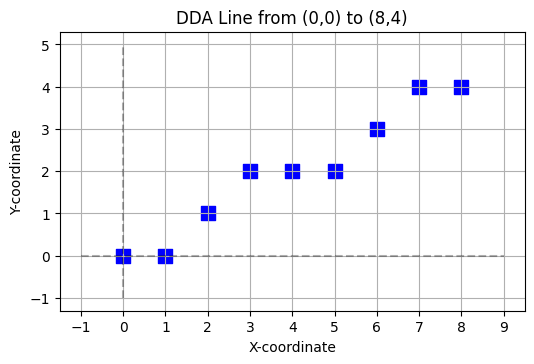

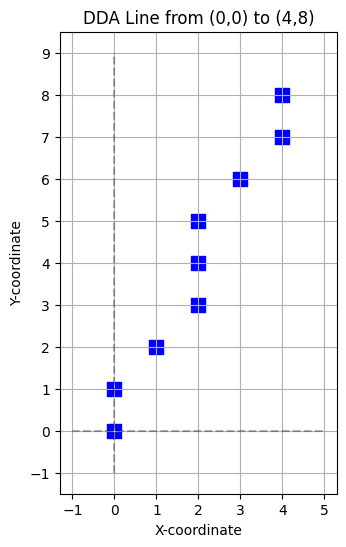

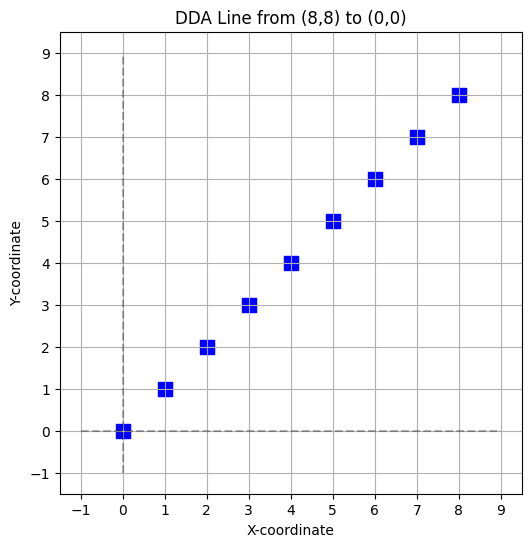

In [ ]:
import matplotlib.pyplot as plt

def dda_line(x1, y1, x2, y2):
    """Implementation of the Digital Differential Analyzer (DDA) line algorithm.

    Args:
        x1, y1 (int): Starting coordinates of the line.
        x2, y2 (int): Ending coordinates of the line.

    Returns:
        list: A list of (x, y) tuples representing the pixels on the line.
    """
    dx = x2 - x1
    dy = y2 - y1

    if abs(dx) > abs(dy):
        steps = abs(dx)
    else:
        steps = abs(dy)

    if steps == 0: # Handle the case of a single point
        return [(round(x1), round(y1))]

    x_increment = dx / steps
    y_increment = dy / steps

    current_x = float(x1)
    current_y = float(y1)

    pixels = []

    # Plot the starting pixel
    pixels.append((round(current_x), round(current_y)))

    for _ in range(int(steps)):
        current_x += x_increment
        current_y += y_increment
        pixels.append((round(current_x), round(current_y)))

    return pixels

# --- Example Usage and Visualization ---

# Test case 1: Gentle slope (abs(dx) > abs(dy))
line1_pixels = dda_line(0, 0, 8, 4)
print(f"Line 1 (0,0) to (8,4) pixels: {line1_pixels}")

# Test case 2: Steep slope (abs(dy) >= abs(dx))
line2_pixels = dda_line(0, 0, 4, 8)
print(f"Line 2 (0,0) to (4,8) pixels: {line2_pixels}")

# Test case 3: Negative slope
line3_pixels = dda_line(8, 8, 0, 0)
print(f"Line 3 (8,8) to (0,0) pixels: {line3_pixels}")

# Test case 4: Horizontal line
line4_pixels = dda_line(2, 5, 10, 5)
print(f"Line 4 (2,5) to (10,5) pixels: {line4_pixels}")

# Test case 5: Vertical line
line5_pixels = dda_line(5, 2, 5, 10)
print(f"Line 5 (5,2) to (5,10) pixels: {line5_pixels}")

# Test case 6: Single point
line6_pixels = dda_line(3, 3, 3, 3)
print(f"Line 6 (3,3) to (3,3) pixels: {line6_pixels}")

# Visualize the lines
def plot_pixels(pixels, title):
    if not pixels: return
    xs, ys = zip(*pixels)
    plt.figure(figsize=(6, 6))
    plt.plot(list(range(min(xs) - 1, max(xs) + 2)), [0] * (max(xs) - min(xs) + 3), 'k--', alpha=0.3) # X-axis
    plt.plot([0] * (max(ys) - min(ys) + 3), list(range(min(ys) - 1, max(ys) + 2)), 'k--', alpha=0.3) # Y-axis

    plt.scatter(xs, ys, color='blue', marker='s', s=100) # Use square markers for pixels
    plt.title(title)
    plt.xlabel('X-coordinate')
    plt.ylabel('Y-coordinate')
    plt.grid(True)
    plt.xticks(range(min(xs) - 1, max(xs) + 2))
    plt.yticks(range(min(ys) - 1, max(ys) + 2))
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

plot_pixels(line1_pixels, "DDA Line from (0,0) to (8,4)")
plot_pixels(line2_pixels, "DDA Line from (0,0) to (4,8)")
plot_pixels(line3_pixels, "DDA Line from (8,8) to (0,0)")

## Model-Based Diagnosis and Fault Localization

**Theory:**

Model-Based Diagnosis (MBD) is a powerful paradigm in Artificial Intelligence for automatically identifying faulty components or subsystems within a complex system. It operates by comparing the observed behavior of a system with its expected behavior, as predicted by a model of the system's normal functioning. When a discrepancy (an anomaly or symptom) is detected, MBD uses logical inference to deduce which components, if assumed to be malfunctioning, would explain the observed discrepancy.

### Core Concepts:

1.  **System Model:** A formal representation of the system's structure and behavior. This model typically includes:
    *   **Components:** Individual parts of the system.
    *   **Connections:** How components are linked.
    *   **Behavioral Descriptions:** For each component, a description of its normal (fault-free) behavior. This can be qualitative (e.g., if input is high, output is high) or quantitative (e.g., mathematical equations describing voltage, current, etc.).

2.  **Observations (Symptoms):** Measurements or sensory data from the actual system, indicating its current state or outputs. These are often the discrepancies between expected and observed behavior.

3.  **Diagnosis Engine:** The computational core that performs the inference. It takes the system model, observations, and potentially a set of assumptions about component behavior (e.g., *all components are working correctly* or *component X is faulty*) and tries to find a **diagnosis**.

4.  **Diagnosis (or Conflict Set):** A set of components that, when assumed to be faulty, explain all observed discrepancies and are consistent with the system model. Diagnoses are often minimal (smallest set of faulty components) or most probable.

### How it Works:

The fundamental principle of MBD is to find a set of assumptions about component health (a *diagnosis*) that resolves conflicts between the system model and observations. The process generally follows these steps:

1.  **Prediction:** Using the system model and initial inputs (if any), predict the system's outputs or internal states, assuming all components are working correctly.

2.  **Comparison:** Compare the predicted outputs/states with the actual observations. If they differ, a **conflict** (or **discrepancy**) exists.

3.  **Conflict Generation:** A conflict is a set of components that, when all assumed to be working normally, lead to a contradiction with the observations. The smallest such set is often sought.

4.  **Candidate Generation and Evaluation:** The diagnosis engine generates candidate diagnoses (sets of potentially faulty components). For each candidate:
    *   Assume these components are faulty and the rest are working normally.
    *   Rerun the prediction with these assumptions.
    *   If the new predictions are consistent with all observations, the candidate is a valid diagnosis.

5.  **Fault Localization:** Once a diagnosis (or a set of diagnoses) is found, the faulty components are localized to the components identified in the diagnosis set.

### Types of Models and Techniques:

*   **Qualitative Models:** Describe behavior in terms of abstract values (e.g., 'normal', 'high', 'low'). Useful when precise quantitative data is unavailable.
*   **Quantitative Models:** Use mathematical equations (e.g., differential equations, circuit laws) for precise predictions. Common in engineering domains.
*   **Behavioral Models:** Focus on the input-output relationship of components.
*   **Structural Models:** Represent the connectivity of components.
*   **Constraint-Based Reasoning:** System behavior is modeled as a set of constraints. Diagnosis involves finding minimal sets of violated constraints.
*   **Consistency-Based Diagnosis:** A diagnosis is a minimal set of components such that if these components are assumed faulty, and the remaining components are assumed normal, the system model is consistent with the observations.
*   **Abductive Diagnosis:** Diagnosis is seen as finding the best explanation for the observations.

### Advantages:

*   **Generality:** A single diagnostic engine can be used with different system models.
*   **Robustness:** Can handle unforeseen faults and multiple simultaneous faults.
*   **Deep Reasoning:** Reasons from first principles rather than relying on shallow fault-symptom associations.
*   **Explainability:** Can often provide explanations for why certain components are deemed faulty.

### Challenges:

*   **Model Complexity:** Developing accurate and complete system models can be difficult and time-consuming.
*   **Computational Cost:** Diagnosis can be computationally intensive, especially for large systems with many possible fault combinations.
*   **Observability:** The quality of diagnosis depends heavily on the availability and accuracy of observations.
*   **Ambiguity:** Multiple diagnoses might explain the same symptoms, leading to ambiguity.

Model-Based Diagnosis is a cornerstone of intelligent fault detection and isolation in various fields, including aerospace, electronics, chemical processes, and software systems.

## 24. Components of Models in Diagnosis

**Theory:**

In Model-Based Diagnosis (MBD), a 'model' is not a single entity but a structured representation of the system. Its effectiveness hinges on capturing various aspects of the system's behavior and structure. Key components often include:

1.  **Component Descriptions:** Each individual part of the system is described. This description specifies its normal (fault-free) behavior. For example, a resistor's model might state that `Voltage = Current * Resistance`. For digital components, it could be a truth table or a functional description.

2.  **Structural Connectivity:** The model defines how components are interconnected. This typically involves input/output ports and a specification of which output connects to which input. This is crucial for propagating values and understanding how a fault in one component might affect others.

3.  **Behavioral Modes (Fault Models):** Beyond normal behavior, models can also include explicit descriptions of *faulty* behaviors. For instance, a switch might have a 'stuck-open' or 'stuck-closed' fault mode. Incorporating fault models can significantly improve diagnostic accuracy by allowing the system to reason about specific failure mechanisms.

4.  **Assumptions and Context:** The model often includes assumptions about the environment, operating conditions, or the scope of diagnosis. For example, assumptions about sensor accuracy, power supply stability, or which types of faults are considered.

5.  **Observation Points:** Specifies where measurements (observations) can be taken and what properties can be measured at those points.

6.  **Time and Dynamics:** For dynamic systems, the model includes temporal relationships, describing how states evolve over time (e.g., differential equations, state machines).

## 25. Ternary Constraints

**Theory:**

In Constraint Satisfaction Problems (CSPs), constraints define the allowed combinations of values for a set of variables. While binary constraints (involving two variables) are the most common, constraints can involve any number of variables. A **ternary constraint** is a type of constraint that restricts the values of **three** variables simultaneously.

Mathematically, a ternary constraint `C(X_i, X_j, X_k)` is a relation over the variables `X_i, X_j, X_k` that specifies which triplets of values `(v_i, v_j, v_k)` from their respective domains `D_i, D_j, D_k` are permitted.

**Examples:**

*   **Arithmetic Constraint:** `X + Y = Z` where `X, Y, Z` are variables. If `X, Y, Z` all have domain `[1, 2, 3]`, then valid triplets might include `(1, 1, 2)`, `(1, 2, 3)`. The triplet `(1, 1, 1)` would violate the constraint.
*   **Ordering Constraint:** `X < Y < Z`.
*   **All-Different Constraint (for 3 variables):** `AllDifferent(X, Y, Z)` means `X != Y`, `Y != Z`, and `X != Z`. This can be decomposed into three binary constraints, but expressing it as a single ternary constraint can sometimes be more natural or allow for more efficient propagation.

**Handling Ternary Constraints in CSP Solvers:**

*   **Direct Representation:** Some CSP solvers can directly handle n-ary constraints, applying specialized propagation algorithms.
*   **Conversion to Binary:** A common technique is to convert ternary (or higher-order) constraints into an equivalent set of binary constraints by introducing auxiliary variables. For example, `X + Y = Z` could be rewritten as `Temp = X + Y` and `Temp = Z`. This is often necessary when the solver only supports binary constraints.

## 26. Simplified Devices in Model-Based Diagnosis

In MBD, understanding the state of a device is critical for diagnosis. The terms 'simple device', 'working device', and 'broken device' help categorize and simplify reasoning about a component's status.

### a. A Simple Device

**Concept:** A 'simple device' or 'atomic component' is the smallest unit of a system that is considered for diagnosis. It's modeled as a black box with defined inputs and outputs, and a specified (usually normal) behavior. It's 'simple' in the sense that its internal structure is not typically modeled for the current diagnostic task; it's either working or it's not.

**Characteristics:**
*   **Inputs:** Values that enter the device.
*   **Outputs:** Values that exit the device.
*   **Behavioral Function:** A function `f` such that `Output = f(Input)` when the device is working normally.
*   **Assumption:** During diagnosis, these are the base units whose health status (ok/faulty) is hypothesized.

**Example:** A single logic gate (AND, OR, NOT), a basic electrical resistor, or a valve in a hydraulic system.

### b. A Working Device

**Concept:** A 'working device' (or 'normal device') is a simple device that is operating according to its specified fault-free behavior model. When a device is assumed to be working, its outputs can be reliably predicted from its inputs based on its normal behavioral function.

**Characteristics:**
*   **Conforms to Model:** All outputs are consistent with its inputs and its normal behavioral function.
*   **No Discrepancies:** There are no contradictions between observed outputs and predicted outputs when assuming the device is working correctly.

**Example:** A resistor `R` has an input current `I` and an output voltage `V`. If it's working, `V = I * R`. If `I` is measured as 2A and `R` is 10 Ohm, then `V` should be 20V. If a measurement shows 20V, the device is consistent with being 'working'.

### b. A Broken Device

**Concept:** A 'broken device' (or 'faulty device') is a simple device that is *not* operating according to its specified fault-free behavior model. Its outputs are inconsistent with its inputs when assuming normal behavior. Identifying broken devices is the primary goal of diagnosis.

**Characteristics:**
*   **Violates Model:** There is a discrepancy between its observed outputs and its predicted outputs, assuming it's working normally.
*   **Source of Conflict:** A broken device is often implicated in a 'conflict set' – a group of components whose normal functioning collectively contradicts the observations.

**Example:** Using the resistor example, if `I` is 2A and `R` is 10 Ohm, but the observed `V` is 5V (instead of 20V), then the resistor is 'broken'.

**In MBD, the task is to identify the minimal set of devices that, when assumed 'broken' (i.e., their normal behavior model is suspended), resolve all discrepancies between observations and the overall system model.**

## 27. Simple Model-Based Diagnosis Implementation

**Theory:**

This implementation demonstrates a basic Model-Based Diagnosis (MBD) system for a simple digital circuit. The core idea is to:

1.  **Model Components:** Define the expected behavior of individual components (e.g., AND, OR, NOT gates).
2.  **Build a System:** Connect these components to form a larger system.
3.  **Simulate Behavior:** Predict the system's output given inputs and assumptions about component health.
4.  **Observe System:** Provide actual outputs from the system under diagnosis.
5.  **Diagnose:** Find a minimal set of components that, when assumed faulty, explains the discrepancy between predicted and observed outputs.

For simplicity, we'll assume a component is either 'OK' (works as specified) or 'FAULTY' (its output is fixed to a value, e.g., 0 or 1, or it produces incorrect output). Our diagnosis will be *consistency-based*, meaning we seek a minimal set of faulty components that makes the model consistent with the observations.

In [ ]:
import collections
import itertools

# --- 1. Define Basic Components (Digital Logic Gates) ---

class Component:
    def __init__(self, name, inputs=None, output=None):
        self.name = name
        self.inputs = inputs if inputs is not None else []
        self.output = output  # Placeholder for output, set by behavior method
        self.status = 'OK'   # 'OK' or 'FAULTY'

    def __repr__(self):
        return f"<{self.name} Status:{self.status}>"

    def behavior(self, *input_values):
        # To be overridden by specific component types
        raise NotImplementedError("Component behavior must be defined.")

    def simulate(self, input_values):
        # If component is FAULTY, its behavior might be fixed or inverted for example.
        # For this simple example, we'll assume a faulty component can produce arbitrary wrong output.
        # A more sophisticated MBD would use specific fault models (e.g., stuck-at-0, stuck-at-1).
        # For now, if FAULTY, we don't know what it outputs, so we check for consistency.
        if self.status == 'OK':
            return self.behavior(*input_values)
        else:
            # If faulty, its output is unknown, so it can be anything.
            # For consistency-based diagnosis, a faulty component is assumed to produce *any* output.
            # We'll return None to signify 'unknown but potentially anything' for the diagnosis engine.
            return None # When a component is faulty, its output is not constrained by its normal behavior

class ANDGate(Component):
    def __init__(self, name, inputs=None):
        super().__init__(name, inputs)

    def behavior(self, *input_values):
        # Ensure all inputs are 0 or 1
        if not all(val in [0, 1] for val in input_values):
            raise ValueError(f"Invalid input for AND gate {self.name}: {input_values}")
        return 1 if all(input_values) else 0

class ORGate(Component):
    def __init__(self, name, inputs=None):
        super().__init__(name, inputs)

    def behavior(self, *input_values):
        if not all(val in [0, 1] for val in input_values):
            raise ValueError(f"Invalid input for OR gate {self.name}: {input_values}")
        return 1 if any(input_values) else 0

class NOTGate(Component):
    def __init__(self, name, inputs=None):
        # Corrected syntax: removed the colon after the super().__init__ call
        super().__init__(name, inputs=inputs if inputs is not None else [None]) # NOT gate has one input

    def behavior(self, input_value):
        if input_value not in [0, 1]:
            raise ValueError(f"Invalid input for NOT gate {self.name}: {input_value}")
        return 1 - input_value


# --- 2. Define a Simple Circuit System ---

# A simple circuit: (A AND B) OR (NOT C)
# Input nodes are 'A_in', 'B_in', 'C_in'
# Components: 'AND1', 'NOT1', 'OR1'
# Output node: 'Out'

class Circuit:
    def __init__(self):
        self.components = {
            'AND1': ANDGate('AND1'),
            'NOT1': NOTGate('NOT1'),
            'OR1': ORGate('OR1')
        }
        self.input_nodes = {'A_in', 'B_in', 'C_in'}
        self.output_node = 'Out'

        # Define connections: (output_source, input_destination_component, input_port_idx)
        # Note: In a real system, you'd have explicit ports. Here we use input_values order.
        self.connections = [
            ('A_in', 'AND1', 0), # A_in goes to AND1's first input
            ('B_in', 'AND1', 1), # B_in goes to AND1's second input
            ('C_in', 'NOT1', 0), # C_in goes to NOT1's input

            ('AND1', 'OR1', 0),  # AND1's output goes to OR1's first input
            ('NOT1', 'OR1', 1)   # NOT1's output goes to OR1's second input
        ]

    def simulate_circuit(self, inputs, assumed_faults=None):
        # Reset component states for simulation
        for comp in self.components.values():
            comp.status = 'OK'

        # Apply assumed faults
        if assumed_faults:
            for fault_comp_name in assumed_faults:
                if fault_comp_name in self.components:
                    self.components[fault_comp_name].status = 'FAULTY'

        # Store all values computed at nodes, including inputs and intermediate outputs
        node_values = dict(inputs) # Initialize with primary inputs

        # Topological sort of components or multiple passes would be needed for complex circuits.
        # For this simple circuit, we can process in a fixed order:
        # 1. AND1 and NOT1 (depend only on primary inputs)
        # 2. OR1 (depends on AND1 and NOT1 outputs)

        # Simulate AND1
        and1 = self.components['AND1']
        and1_input_values = [node_values.get('A_in'), node_values.get('B_in')]
        if and1_input_values[0] is not None and and1_input_values[1] is not None:
            node_values['AND1_out'] = and1.simulate(and1_input_values)
        else: node_values['AND1_out'] = None

        # Simulate NOT1
        not1 = self.components['NOT1']
        not1_input_value = node_values.get('C_in')
        if not1_input_value is not None:
            # Wrap the single input for NOTGate in a list
            node_values['NOT1_out'] = not1.simulate([not1_input_value])
        else: node_values['NOT1_out'] = None

        # Simulate OR1
        or1 = self.components['OR1']
        or1_input_values = [node_values.get('AND1_out'), node_values.get('NOT1_out')]
        if or1_input_values[0] is not None and or1_input_values[1] is not None:
            node_values['Out'] = or1.simulate(or1_input_values)
        else: node_values['Out'] = None

        return node_values.get('Out')


# --- 3. Model-Based Diagnosis Engine ---

def find_diagnoses(circuit, inputs, observed_output, max_faults=1):
    all_components = list(circuit.components.keys())
    diagnoses = []

    print(f"\n--- Starting Diagnosis for Inputs: {inputs}, Observed Output: {observed_output} ---")

    # Try 0 faults (all components are OK)
    predicted_output = circuit.simulate_circuit(inputs, assumed_faults=[])
    if predicted_output == observed_output:
        print("System is working normally. No faults detected.")
        diagnoses.append(set())
        return diagnoses
    else:
        print(f"Predicted output with 0 faults: {predicted_output}. Discrepancy found.")

    # Try 1 fault, 2 faults, up to max_faults
    for num_faults in range(1, max_faults + 1):
        print(f"\nAttempting to find diagnoses with {num_faults} fault(s)...")
        for fault_candidate_set in itertools.combinations(all_components, num_faults):
            fault_candidate_set = set(fault_candidate_set)

            # Simulate the circuit with the assumed faults
            # For consistency-based diagnosis, we assume that faulty components can produce *any* output
            # and only check if the *rest* of the working components are consistent with the observation.
            # This means we don't try to predict a specific output from faulty components.

            # Simulate the circuit. If `simulate_circuit` returns None for an output, it implies
            # a faulty component made its output 'unknown'.
            # If the output IS the observed_output, then it's a consistent diagnosis.

            # The `simulate_circuit` method already returns None if a faulty component's output is needed
            # to determine the final output. If the final output is known even with faults, it's consistent.

            # A more robust simulation for consistency-based diagnosis:
            # A (sub-)system is consistent with observations if there exists an assignment
            # to the unknown outputs of faulty components that makes the entire system's
            # predicted behavior match the observation.

            # For this simple implementation, if a predicted_output from simulate_circuit
            # is None when a fault is assumed, it implies consistency with *any* observed_output.

            # Create a fresh circuit instance to avoid state issues from previous simulations
            circuit_for_candidate = Circuit()
            predicted_output_for_candidate = circuit_for_candidate.simulate_circuit(inputs, assumed_faults=fault_candidate_set)

            is_consistent = False
            if predicted_output_for_candidate is None: # Faulty component's output was needed, so it could explain anything
                is_consistent = True
            elif predicted_output_for_candidate == observed_output: # Even with faults, it matches (implies faults didn't affect the path to observed output, or they perfectly matched)
                is_consistent = True

            if is_consistent:
                print(f"  Candidate {fault_candidate_set}: Consistent with observation. Predicted: {predicted_output_for_candidate}")
                diagnoses.append(fault_candidate_set)
            else:
                print(f"  Candidate {fault_candidate_set}: NOT consistent. Predicted: {predicted_output_for_candidate}")

        if diagnoses: # If we found diagnoses at this fault level, these are the minimal ones
            print(f"Minimal diagnoses found with {num_faults} fault(s).")
            return diagnoses

    print("No minimal diagnoses found up to max_faults.")
    return []


# --- 4. Example Usage ---

my_circuit = Circuit()

# Test case 1: Normal operation
print("\n--- Scenario 1: Expected Behavior ---")
inputs_1 = {'A_in': 1, 'B_in': 0, 'C_in': 1}
expected_output_1 = (1 and 0) or (not 1)  # 0 or 0 = 0
print(f"Expected output for inputs {inputs_1}: {expected_output_1}")
simulated_output_1 = my_circuit.simulate_circuit(inputs_1)
print(f"Simulated output with no faults: {simulated_output_1}")

# Test case 2: Introducing a fault (e.g., AND1 is faulty)
print("\n--- Scenario 2: With a Fault (AND1) ---")
inputs_2 = {'A_in': 1, 'B_in': 1, 'C_in': 1}
# If AND1 is faulty, its output is unknown. NOT1 output is 0. OR1 receives (UNKNOWN, 0).
# If OR1 needs both inputs to be defined to produce an output, this path won't give a concrete output.
# Let's say we observe output 1, but without faults, it should be 0.

# Without fault: (1 AND 1) OR (NOT 1) = 1 OR 0 = 1
predicted_no_fault_2 = my_circuit.simulate_circuit(inputs_2)
print(f"Predicted output (no faults) for inputs {inputs_2}: {predicted_no_fault_2}")

# Let's assume we observe output 0 for these inputs, which is inconsistent with no faults
observed_output_2 = 0
print(f"Observed output: {observed_output_2}")

diagnoses_2 = find_diagnoses(my_circuit, inputs_2, observed_output_2, max_faults=1)
if diagnoses_2:
    print(f"Final Diagnoses for Scenario 2: {diagnoses_2}")
else:
    print("No diagnoses found for Scenario 2.")


# Test case 3: Another fault (e.g., NOT1 is faulty)
print("\n--- Scenario 3: With a Fault (NOT1) ---")
inputs_3 = {'A_in': 0, 'B_in': 0, 'C_in': 0}
# Without fault: (0 AND 0) OR (NOT 0) = 0 OR 1 = 1
predicted_no_fault_3 = my_circuit.simulate_circuit(inputs_3)
print(f"Predicted output (no faults) for inputs {inputs_3}: {predicted_no_fault_3}")

# Let's assume we observe output 0 for these inputs, which is inconsistent with no faults
observed_output_3 = 0
print(f"Observed output: {observed_output_3}")

diagnoses_3 = find_diagnoses(my_circuit, inputs_3, observed_output_3, max_faults=1)
if diagnoses_3:
    print(f"Final Diagnoses for Scenario 3: {diagnoses_3}")
else:
    print("No diagnoses found for Scenario 3.")


--- Scenario 1: Expected Behavior ---
Expected output for inputs {'A_in': 1, 'B_in': 0, 'C_in': 1}: False
Simulated output with no faults: 0

--- Scenario 2: With a Fault (AND1) ---
Predicted output (no faults) for inputs {'A_in': 1, 'B_in': 1, 'C_in': 1}: 1
Observed output: 0

--- Starting Diagnosis for Inputs: {'A_in': 1, 'B_in': 1, 'C_in': 1}, Observed Output: 0 ---
Predicted output with 0 faults: 1. Discrepancy found.

Attempting to find diagnoses with 1 fault(s)...
  Candidate {'AND1'}: Consistent with observation. Predicted: None
  Candidate {'NOT1'}: Consistent with observation. Predicted: None
  Candidate {'OR1'}: Consistent with observation. Predicted: None
Minimal diagnoses found with 1 fault(s).
Final Diagnoses for Scenario 2: [{'AND1'}, {'NOT1'}, {'OR1'}]

--- Scenario 3: With a Fault (NOT1) ---
Predicted output (no faults) for inputs {'A_in': 0, 'B_in': 0, 'C_in': 0}: 1
Observed output: 0

--- Starting Diagnosis for Inputs: {'A_in': 0, 'B_in': 0, 'C_in': 0}, Observed Outp

## 28. Battling Combinatorial Explosion (CombEx)

**Theory:**

Combinatorial Explosion, often referred to as "CombEx," is a phenomenon where the number of possible states, configurations, or solutions in a problem space grows exponentially (or super-exponentially) with respect to the size or complexity of the problem. This rapid growth makes it computationally infeasible to explore the entire search space, even for problems of moderate size, thus posing a fundamental challenge in many areas of Artificial Intelligence.

### Why CombEx is a Problem in AI:

*   **Search Algorithms:** In problems like game playing, planning, or constraint satisfaction, the number of possible moves, states to explore, or assignments to consider can quickly become astronomically large. Brute-force search becomes impractical.
*   **Decision Making:** Evaluating all possible consequences of actions in complex environments is often impossible due to the vast number of potential future states.
*   **Learning:** Learning models with too many parameters or exploring all possible hypotheses can lead to overfitting or intractability.

### General Strategies to Battle CombEx:

To manage and mitigate combinatorial explosion, AI employs a range of techniques, often focusing on reducing the effective search space or finding satisficing (good enough) solutions rather than strictly optimal ones:

1.  **Heuristics:**
    *   **Concept:** Rules of thumb or educated guesses that guide the search towards promising areas of the search space. They don't guarantee optimality but significantly improve efficiency.
    *   **Examples:** The `h(n)` function in A* search, evaluation functions in game playing (e.g., Minimax with depth limit).

2.  **Pruning:**
    *   **Concept:** Eliminating branches of the search space that are guaranteed not to contain an optimal or satisfactory solution, or that are deemed unlikely to lead to one.
    *   **Examples:** Alpha-Beta pruning in Minimax, pruning in Branch and Bound (where a partial solution's lower bound exceeds the current best upper bound), constraint propagation in CSPs (removing values from domains that violate constraints).

3.  **Abstraction and Hierarchy:**
    *   **Concept:** Simplifying the problem by representing it at a higher level of detail, postponing fine-grained decisions until later. This reduces the number of distinct states or actions to consider.
    *   **Examples:** Hierarchical Planning (decomposing compound tasks into subtasks), using abstract states in reinforcement learning.

4.  **Informed Search Algorithms:**
    *   **Concept:** Algorithms that use domain-specific knowledge (heuristics) to make intelligent choices about which paths to explore first, rather than blindly searching.
    *   **Examples:** A* search, Greedy Best-First Search.

5.  **Local Search and Metaheuristics:**
    *   **Concept:** Instead of exhaustive exploration, these algorithms start from one or more candidate solutions and iteratively move to neighboring solutions in the search space, aiming to find an optimum.
    *   **Examples:** Hill Climbing, Simulated Annealing, Genetic Algorithms, Ant Colony Optimization, Tabu Search. These methods sacrifice guaranteed optimality for practical solvability in vast spaces.

6.  **Constraint Propagation:**
    *   **Concept:** Techniques in Constraint Satisfaction Problems that automatically reduce the domain of variables by removing values that violate constraints, thereby reducing the branching factor of the search.
    *   **Examples:** Arc Consistency (AC-3).

These strategies are often combined to effectively tackle problems where combinatorial explosion is a significant hurdle, making complex AI tasks solvable within practical timeframes.

### Implementation: N-Queens Problem with and without CombEx Battling (Pruning)

The N-Queens problem is a classic example to illustrate combinatorial explosion and how backtracking with pruning effectively battles it. The goal is to place N chess queens on an N×N chessboard such that no two queens threaten each other. This means no two queens can share the same row, column, or diagonal.

We will compare two approaches:

1.  **Naive Brute-Force (Demonstrates CombEx):** This approach tries to place queens randomly or sequentially without immediately checking for conflicts. It will explore many invalid configurations, leading to a much larger search space.
2.  **Backtracking with Pruning (Battles CombEx):** This approach places queens one by one, checking for conflicts after each placement. If a queen placement creates a conflict, the algorithm immediately backtracks and tries a different position, pruning an entire branch of the search tree.

In [ ]:
import itertools
import time
import collections

# Helper to visualize the board
def print_board(board):
    n = len(board)
    for row in board:
        print(' '.join(['Q' if col else '.' for col in row]))
    print("\n")

# --- 1. Naive Brute-Force Approach (Demonstrates CombEx) ---
# This approach generates ALL permutations of N positions and then checks validity.
# This is incredibly inefficient for larger N.

def solve_n_queens_naive(n):
    solutions = []
    # Generate all permutations of column positions for N queens in N rows
    # This assumes one queen per row, which is a basic optimization, but doesn't prune early.
    col_placements = list(range(n))
    total_states_checked = 0

    for permutation in itertools.permutations(col_placements):
        total_states_checked += 1
        board = [[0 for _ in range(n)] for _ in range(n)]
        for r, c in enumerate(permutation):
            board[r][c] = 1 # Place queen

        # Check if this full board configuration is valid
        if is_valid_board(board, n):
            solutions.append(list(permutation)) # Store just the column indices

    return solutions, total_states_checked

def is_valid_board(board, n):
    # Check row conflicts (already handled by permutation)
    # Check column conflicts (already handled by permutation)

    # Check diagonal conflicts
    for r1 in range(n):
        for c1 in range(n):
            if board[r1][c1] == 1: # If there's a queen at (r1, c1)
                for r2 in range(n):
                    for c2 in range(n):
                        if board[r2][c2] == 1 and (r1 != r2 or c1 != c2): # Another queen
                            if abs(r1 - r2) == abs(c1 - c2): # Same diagonal
                                return False
    return True


# --- 2. Backtracking with Pruning Approach (Battles CombEx) ---
# This approach prunes the search space as soon as a conflict is detected.

def solve_n_queens_backtracking(n):
    solutions = []
    # `board_state` will store the column index of the queen in each row.
    # e.g., board_state = [1, 3, 0, 2] for N=4 means (0,1), (1,3), (2,0), (3,2)
    board_state = [-1] * n # Initialize with no queens placed
    total_states_explored = [0] # Use a list to pass by reference for counting

    def backtrack(row):
        total_states_explored[0] += 1
        if row == n: # All queens placed successfully
            solutions.append(list(board_state))
            return

        for col in range(n):
            if is_safe(board_state, row, col):
                board_state[row] = col
                backtrack(row + 1)
                board_state[row] = -1 # Backtrack: remove queen

    def is_safe(current_board_state, current_row, current_col):
        # Check this placement (current_row, current_col) against previously placed queens
        for prev_row in range(current_row):
            prev_col = current_board_state[prev_row]
            if prev_col == current_col: # Same column
                return False
            if abs(prev_row - current_row) == abs(prev_col - current_col): # Same diagonal
                return False
        return True

    backtrack(0) # Start placing queens from row 0
    return solutions, total_states_explored[0]


# --- Example Usage and Comparison ---

In [ ]:
print("\n--- Comparing N-Queens Solutions (CombEx vs. Pruning) ---")

for n_value in [4, 6, 8]: # You can try larger N, but naive will be very slow
    print(f"\nN = {n_value} Queens:")

    # Naive Brute-Force
    start_time_naive = time.time()
    naive_solutions, naive_states = solve_n_queens_naive(n_value)
    end_time_naive = time.time()
    print(f"  Naive Brute-Force: Found {len(naive_solutions)} solutions in {end_time_naive - start_time_naive:.4f} seconds.")
    print(f"    Total states checked: {naive_states}")

    if n_value <= 4: # Only print solutions for small N
        print("    Sample Naive Solution:")
        if naive_solutions: print_board([[1 if c == col else 0 for col in range(n_value)] for r, c in enumerate(naive_solutions[0])])
        else: print("    (No solutions found)")

    # Backtracking with Pruning
    start_time_backtrack = time.time()
    backtrack_solutions, backtrack_states = solve_n_queens_backtracking(n_value)
    end_time_backtrack = time.time()
    print(f"  Backtracking with Pruning: Found {len(backtrack_solutions)} solutions in {end_time_backtrack - start_time_backtrack:.4f} seconds.")
    print(f"    Total states explored (nodes in search tree): {backtrack_states}")

    if n_value <= 4: # Only print solutions for small N
        print("    Sample Backtracking Solution:")
        if backtrack_solutions: print_board([[1 if c == col else 0 for col in range(n_value)] for r, c in enumerate(backtrack_solutions[0])])
        else: print("    (No solutions found)")


print("\nThis example clearly demonstrates how early pruning (in the backtracking approach)")
print("significantly reduces the number of states/configurations that need to be explicitly checked,")
print("thus effectively 'battling' the combinatorial explosion inherent in the problem.")


--- Comparing N-Queens Solutions (CombEx vs. Pruning) ---

N = 4 Queens:
  Naive Brute-Force: Found 2 solutions in 0.0001 seconds.
    Total states checked: 24
    Sample Naive Solution:
. Q . .
. . . Q
Q . . .
. . Q .


  Backtracking with Pruning: Found 2 solutions in 0.0000 seconds.
    Total states explored (nodes in search tree): 17
    Sample Backtracking Solution:
. Q . .
. . . Q
Q . . .
. . Q .



N = 6 Queens:
  Naive Brute-Force: Found 4 solutions in 0.0041 seconds.
    Total states checked: 720
  Backtracking with Pruning: Found 4 solutions in 0.0004 seconds.
    Total states explored (nodes in search tree): 153

N = 8 Queens:
  Naive Brute-Force: Found 92 solutions in 0.3129 seconds.
    Total states checked: 40320
  Backtracking with Pruning: Found 92 solutions in 0.0076 seconds.
    Total states explored (nodes in search tree): 2057

This example clearly demonstrates how early pruning (in the backtracking approach)
significantly reduces the number of states/configuration

## 24. Consistency in Constraint Satisfaction Problems (CSPs)

**Theory:**

Consistency (also known as constraint propagation or filtering) is a crucial concept in solving Constraint Satisfaction Problems (CSPs). It involves reducing the domains of variables by removing values that cannot possibly be part of any solution, without losing any actual solutions. The goal is to simplify the problem and prune the search space before or during backtracking search.

Different levels of consistency can be enforced:

### a. Node Consistency (1-Consistency)

**Concept:** A CSP is **node consistent** if, for every variable `X` and every value `v` in its domain `D(X)`, `v` satisfies all unary constraints on `X`.

**Mechanism:** To enforce node consistency, simply remove any value from a variable's domain that violates its unary constraints. If a domain becomes empty, the CSP has no solution.

**Example:** If variable `X` has domain `{1, 2, 3, 4}` and a unary constraint `X > 2`, then enforcing node consistency would reduce `D(X)` to `{3, 4}`.

### b. Arc Consistency (AC-3, 2-Consistency)

**Concept:** A CSP is **arc consistent** if, for every binary constraint `C(X, Y)` and for every value `x` in the domain `D(X)`, there exists *some* value `y` in `D(Y)` such that the assignment `(X=x, Y=y)` satisfies `C(X, Y)`. Similarly, for every value `y` in `D(Y)`, there must exist *some* `x` in `D(X)` satisfying `C(X, Y)`.

**Mechanism (AC-3 Algorithm):**
1.  Initialize a queue with all arcs (ordered pairs of variables `(X, Y)` representing a constraint between them).
2.  While the queue is not empty, extract an arc `(X, Y)`.
3.  **REVISE(X, Y):** Check every value `x` in `D(X)`. If `x` has no consistent counterpart in `D(Y)` (i.e., no `y` in `D(Y)` satisfies `C(X, Y)`), then remove `x` from `D(X)`. If any values are removed from `D(X)`, add all arcs `(Z, X)` (where `Z` is a neighbor of `X`) back to the queue, as `D(X)` has changed and might affect `Z`'s domain.
4.  Repeat until the queue is empty. If any domain becomes empty, the CSP has no solution.

**Example:** If `D(X) = {1, 2, 3}`, `D(Y) = {1, 2, 3}` and constraint is `X < Y`:
    *   `REVISE(X, Y)`: Value `3` is removed from `D(X)` because no `y` in `D(Y)` makes `3 < y` true. Domain `D(X)` becomes `{1, 2}`.
    *   `REVISE(Y, X)`: Value `1` is removed from `D(Y)` because no `x` in `D(X)` makes `x < 1` true. Domain `D(Y)` becomes `{2, 3}`.

### c. Path Consistency (3-Consistency)

**Concept:** A CSP is **path consistent** if, for every pair of distinct variables `(X, Y)` and for every value `x` in `D(X)` and `y` in `D(Y)` that are consistent with each other (satisfy `C(X, Y)`), there exists *some* value `z` in `D(Z)` such that `(x, z)` satisfies `C(X, Z)` and `(z, y)` satisfies `C(Z, Y)` for *every* other variable `Z`.

**Mechanism:** Enforcing path consistency involves considering triplets of variables. It removes values from domains that are not consistent across all paths of length 2. It's computationally more expensive than arc consistency.

### d. k-Consistency

**Concept:** **k-Consistency** is a generalization of node, arc, and path consistency.
*   A CSP is **k-consistent** if, for any consistent assignment to `k-1` variables, there exists a consistent assignment for any `k`-th variable.
*   Node consistency is 1-consistency.
*   Arc consistency is 2-consistency.
*   Path consistency is 3-consistency.

**Mechanism:** Enforcing k-consistency for higher values of `k` becomes increasingly complex and computationally expensive. In practice, arc consistency (AC-3) is the most commonly used propagation algorithm due to its good balance between effectiveness and computational cost.

Consistency techniques are often interleaved with search algorithms like backtracking search to significantly improve performance by reducing the domains of variables early, thus finding dead ends faster and pruning large portions of the search tree.

In [ ]:
import collections

# Re-using the CSP class structure for integration
class CSP:
    def __init__(self, variables, domains, constraints):
        self.variables = variables  # List of variables
        self.domains = domains      # Dictionary: variable -> list of possible values
        self.constraints = constraints # Dictionary: variable -> list of (neighbor_variable, constraint_func)

        # Check if all variables have a domain
        for var in self.variables:
            if var not in self.domains:
                raise ValueError(f"Missing domain for variable: {var}")

        # Check if all variables in constraints are valid
        for var, neighbors in self.constraints.items():
            if var not in self.variables:
                raise ValueError(f"Constraint variable {var} not in CSP variables")
            for neighbor, _ in neighbors:
                if neighbor not in self.variables:
                    raise ValueError(f"Constraint neighbor {neighbor} not in CSP variables")

    def _get_neighbors(self, var):
        # Helper to get all neighbors of a variable based on constraints
        neighbors = set()
        for neighbor, _ in self.constraints.get(var, []):
            neighbors.add(neighbor)
        # Also consider reverse constraints
        for v_other in self.variables:
            for neighbor_of_v_other, _ in self.constraints.get(v_other, []):
                if neighbor_of_v_other == var:
                    neighbors.add(v_other)
        return list(neighbors)

    def enforce_node_consistency(self):
        """Enforces Node Consistency (1-Consistency)."""
        print("\n--- Enforcing Node Consistency ---")
        initial_domains = {v: list(d) for v, d in self.domains.items()}
        changed = False
        for var in self.variables:
            if var in self.constraints: # Check for unary constraints
                new_domain = []
                for value in self.domains[var]:
                    is_valid = True
                    # Check if any unary constraint is violated
                    for neighbor, constraint_func in self.constraints[var]:
                        if neighbor == var: # Unary constraint on itself
                            if not constraint_func(value):
                                is_valid = False
                                break
                    if is_valid:
                        new_domain.append(value)
                if len(new_domain) < len(self.domains[var]):
                    print(f"  Node consistency: Domain of {var} reduced from {self.domains[var]} to {new_domain}")
                    self.domains[var] = new_domain
                    changed = True
                if not self.domains[var]:
                    print(f"  Node consistency: Domain of {var} is empty. No solution.")
                    return False # Domain wiped out, no solution
        if not changed:
            print("  Node consistency: No domains reduced.")
        return True

    def enforce_arc_consistency(self):
        """Enforces Arc Consistency (2-Consistency) using AC-3 algorithm."""
        print("\n--- Enforcing Arc Consistency (AC-3) ---")
        queue = collections.deque()

        # Initialize queue with all arcs (X, Y) and (Y, X)
        for var1 in self.variables:
            for var2 in self._get_neighbors(var1): # Using helper to get direct neighbors
                if var1 != var2:
                    queue.append((var1, var2))

        print(f"  Initial arcs in queue: {list(queue)}")

        domains_changed = False

        while queue:
            X, Y = queue.popleft()

            # Find the constraint function for (X, Y)
            constraint_xy_func = None
            for neighbor, func in self.constraints.get(X, []):
                if neighbor == Y:
                    constraint_xy_func = func
                    break
            # If no direct constraint X,Y, then check Y,X (reverse)
            if constraint_xy_func is None:
                 for neighbor, func in self.constraints.get(Y, []):
                    if neighbor == X:
                        # For (X, Y) arc, we need func(val_X, val_Y). If func is for (Y, X), then it's func(val_Y, val_X)
                        # So we wrap it to match the (X,Y) order for REVISE
                        constraint_xy_func = lambda val_x, val_y, original_func=func: original_func(val_y, val_x)
                        break

            if constraint_xy_func is None: # No constraint defined between X and Y, skip
                continue

            # REVISE function
            revised = False
            new_domain_X = []
            for x_val in self.domains[X]:
                if any(constraint_xy_func(x_val, y_val) for y_val in self.domains[Y]):
                    new_domain_X.append(x_val)
                else:
                    revised = True

            if revised:
                old_domain_X = self.domains[X]
                self.domains[X] = new_domain_X
                domains_changed = True
                print(f"  Arc consistency: Domain of {X} reduced from {old_domain_X} to {self.domains[X]} due to {Y}")

                if not self.domains[X]:
                    print(f"  Arc consistency: Domain of {X} is empty. No solution.")
                    return False # Domain wiped out, no solution

                # If D(X) was revised, add all arcs (Z, X) to the queue
                for Z in self._get_neighbors(X):
                    if Z != X:
                        queue.append((Z, X))

        if not domains_changed:
            print("  Arc consistency: No domains reduced.")
        return True

    def backtracking_search(self, assignment={}):
        # Base case: if all variables are assigned, return the assignment
        if len(assignment) == len(self.variables):
            return assignment

        # Select an unassigned variable (using MRV heuristic if available, for now just pick first)
        unassigned_vars = [v for v in self.variables if v not in assignment]
        if not unassigned_vars: # Should have been caught by the above len(assignment) check
            return assignment

        var = self.select_unassigned_variable(assignment) # Use a heuristic to select variable

        # Try each value in the variable's domain
        for value in self.order_domain_values(var, assignment):
            if self.is_consistent(var, value, assignment):
                assignment[var] = value

                # Perform forward checking
                original_domains = {v: list(d) for v, d in self.domains.items()} # Deep copy domains
                if self.forward_check(var, value, assignment):
                    result = self.backtracking_search(assignment)
                    if result is not None:
                        return result

                # If forward checking failed or backtracking failed, restore domains
                self.domains = original_domains

                del assignment[var]  # Backtrack
        return None

    def is_consistent(self, var, value, assignment):
        # Check if assigning 'value' to 'var' is consistent with current 'assignment'
        for neighbor, constraint_func in self.constraints.get(var, []):
            if neighbor in assignment:  # Only check against assigned neighbors
                if not constraint_func(value, assignment[neighbor]):
                    return False

        # Also check constraints where 'var' is the neighbor
        for assigned_var, assigned_value in assignment.items():
            for neighbor_of_assigned, constraint_func_rev in self.constraints.get(assigned_var, []):
                if neighbor_of_assigned == var:
                    if not constraint_func_rev(assigned_value, value):
                        return False
        return True

    def select_unassigned_variable(self, assignment):
        # Simple implementation: choose the variable with the fewest remaining values (MRV heuristic)
        # If tie, choose the one involved in most constraints (degree heuristic)
        unassigned = [v for v in self.variables if v not in assignment]
        if not unassigned: return None

        min_remaining_values = float('inf')
        best_var = None

        for var in unassigned:
            num_remaining_values = len(self.domains[var])
            if num_remaining_values < min_remaining_values:
                min_remaining_values = num_remaining_values
                best_var = var
            elif num_remaining_values == min_remaining_values: # Tie-breaking with degree heuristic
                if self.get_degree(var, assignment) > self.get_degree(best_var, assignment): # Higher degree is better
                    best_var = var
        return best_var

    def get_degree(self, var, assignment):
        # Returns the number of unassigned neighbors for 'var'
        degree = 0
        for neighbor, _ in self.constraints.get(var, []):
            if neighbor not in assignment: # Only count neighbors that are not yet assigned
                degree += 1
        return degree

    def order_domain_values(self, var, assignment):
        # Simple implementation: return values in their original order
        # A more sophisticated approach would use the Least Constraining Value heuristic
        return self.domains[var]

    def forward_check(self, var, value, assignment):
        # For each unassigned neighbor N of 'var',
        # remove any value from N's domain that is inconsistent with (var=value).
        # If any domain becomes empty, return False (inconsistency found).
        for neighbor, constraint_func in self.constraints.get(var, []):
            if neighbor not in assignment: # Only check unassigned neighbors
                new_domain_for_neighbor = []
                for n_val in self.domains[neighbor]:
                    # Check consistency from neighbor's perspective as well
                    if constraint_func(value, n_val) and self._is_consistent_reverse(neighbor, n_val, var, value, assignment): # Pass assignment
                        new_domain_for_neighbor.append(n_val)

                if not new_domain_for_neighbor:
                    return False  # Domain becomes empty, inconsistency found
                self.domains[neighbor] = new_domain_for_neighbor
        return True

    def _is_consistent_reverse(self, neighbor, n_val, var, value, assignment):
        # Helper to check consistency from neighbor's perspective against var
        for neighbor_of_n, constraint_func_rev in self.constraints.get(neighbor, []):
            if neighbor_of_n == var:
                if not constraint_func_rev(n_val, value):
                    return False
        # Check against other assigned variables of the neighbor
        for other_assigned_var, other_assigned_val in assignment.items():
            if other_assigned_var != var: # Don't check 'var' again
                for n_neighbor, n_constraint_func in self.constraints.get(neighbor, []):
                    if n_neighbor == other_assigned_var:
                        if not n_constraint_func(n_val, other_assigned_val):
                            return False
        return True


# --- Example Usage: Map Coloring Problem with Consistency ---

# 1. Variables: Australian states/territories
regions = ['WA', 'NT', 'SA', 'Q', 'NSW', 'V', 'T']

# 2. Domains: Available colors
colors = ['red', 'green', 'blue']
domains = {region: list(colors) for region in regions}

# 3. Constraints: Adjacency (regions must have different colors)
def not_equal(color1, color2):
    return color1 != color2

constraints = {
    'WA': [('NT', not_equal), ('SA', not_equal)],
    'NT': [('WA', not_equal), ('SA', not_equal), ('Q', not_equal)],
    'SA': [('WA', not_equal), ('NT', not_equal), ('Q', not_equal), ('NSW', not_equal), ('V', not_equal)],
    'Q':  [('NT', not_equal), ('SA', not_equal), ('NSW', not_equal)],
    'NSW': [('Q', not_equal), ('SA', not_equal), ('V', not_equal)],
    'V':  [('SA', not_equal), ('NSW', not_equal)],
    'T':  [] # Tasmania has no land borders with other states
}

print("--- Australian Map Coloring CSP with Consistency ---")
csp_instance = CSP(regions, {r: list(c) for r, c in domains.items()}, constraints) # Pass a copy of domains

# Print initial domains
print("\nInitial Domains:")
for var, dom in csp_instance.domains.items():
    print(f"  {var}: {dom}")

# Enforce Node Consistency (for this problem, no unary constraints, so it won't change)
if csp_instance.enforce_node_consistency():
    print("\nDomains after Node Consistency:")
    for var, dom in csp_instance.domains.items():
        print(f"  {var}: {dom}")

# Enforce Arc Consistency (AC-3)
if csp_instance.enforce_arc_consistency():
    print("\nDomains after Arc Consistency (AC-3):")
    for var, dom in csp_instance.domains.items():
        print(f"  {var}: {dom}")
else:
    print("Arc consistency found an empty domain, no solution exists.")

print("\nNow, trying to solve the CSP after consistency enforcement:")
solution = csp_instance.backtracking_search() # Use the CSP's backtracking search

if solution:
    print("Solution Found:")
    for region, color in solution.items():
        print(f"  {region}: {color}")
else:
    print("No solution found for the given CSP.")


# --- Example 2: CSP with unary constraint for Node Consistency --- #
print("\n\n--- CSP with Unary Constraint ---")
variables2 = ['X', 'Y']
domains2 = {'X': [1, 2, 3], 'Y': [1, 2, 3]}

def x_is_even(val):
    return val % 2 == 0

def x_ne_y(val_x, val_y):
    return val_x != val_y

constraints2 = {
    'X': [('X', x_is_even), ('Y', x_ne_y)], # Unary on X, Binary with Y
    'Y': [('X', x_ne_y)]
}

csp_instance2 = CSP(variables2, {v: list(d) for v, d in domains2.items()}, constraints2)

print("\nInitial Domains:")
for var, dom in csp_instance2.domains.items():
    print(f"  {var}: {dom}")

if csp_instance2.enforce_node_consistency():
    print("\nDomains after Node Consistency:")
    for var, dom in csp_instance2.domains.items():
        print(f"  {var}: {dom}")
    if csp_instance2.enforce_arc_consistency():
        print("\nDomains after Arc Consistency (AC-3):")
        for var, dom in csp_instance2.domains.items():
            print(f"  {var}: {dom}")
        solution2 = csp_instance2.backtracking_search()
        if solution2:
            print("\nSolution Found:")
            for var, val in solution2.items():
                print(f"  {var}: {val}")
        else:
            print("No solution found.")
    else:
        print("Arc consistency found an empty domain, no solution exists.")
else:
    print("Node consistency found an empty domain, no solution exists.")

--- Australian Map Coloring CSP with Consistency ---

Initial Domains:
  WA: ['red', 'green', 'blue']
  NT: ['red', 'green', 'blue']
  SA: ['red', 'green', 'blue']
  Q: ['red', 'green', 'blue']
  NSW: ['red', 'green', 'blue']
  V: ['red', 'green', 'blue']
  T: ['red', 'green', 'blue']

--- Enforcing Node Consistency ---
  Node consistency: No domains reduced.

Domains after Node Consistency:
  WA: ['red', 'green', 'blue']
  NT: ['red', 'green', 'blue']
  SA: ['red', 'green', 'blue']
  Q: ['red', 'green', 'blue']
  NSW: ['red', 'green', 'blue']
  V: ['red', 'green', 'blue']
  T: ['red', 'green', 'blue']

--- Enforcing Arc Consistency (AC-3) ---
  Initial arcs in queue: [('WA', 'SA'), ('WA', 'NT'), ('NT', 'SA'), ('NT', 'WA'), ('NT', 'Q'), ('SA', 'WA'), ('SA', 'NSW'), ('SA', 'V'), ('SA', 'NT'), ('SA', 'Q'), ('Q', 'SA'), ('Q', 'NSW'), ('Q', 'NT'), ('NSW', 'SA'), ('NSW', 'Q'), ('NSW', 'V'), ('V', 'SA'), ('V', 'NSW')]
  Arc consistency: No domains reduced.

Domains after Arc Consistency (AC-

## 25. Arc Consistency (AC-1 Algorithm)

**Theory:**

AC-1 is one of the earliest algorithms for enforcing arc consistency in Constraint Satisfaction Problems (CSPs). Its primary goal is to iteratively remove values from variable domains that are not consistent with their binary constraints, thus pruning the search space. While less efficient than later algorithms like AC-3 (which we already have in our `CSP` class) and AC-4, AC-1 is conceptually simpler and provides a good foundation for understanding constraint propagation.

**Core Idea:**

AC-1 repeatedly passes over all arcs in the CSP until no further domain reductions can be made. If a domain is revised (i.e., a value is removed), the algorithm restarts, rechecking *all* arcs from the beginning. This re-checking of all arcs is what makes AC-1 less efficient than AC-3, which only re-checks arcs potentially affected by a domain revision.

**Mechanism:**

1.  **Initialization:** The algorithm starts with the current domains of all variables.
2.  **Iteration Loop:** Enter a loop that continues until no domain has been reduced during an entire pass over all arcs.
3.  **Arc Revision Loop:** Within the iteration loop, iterate through every directed arc `(X_i, X_j)` in the CSP.
4.  **REVISE(X_i, X_j) Function:** For each arc, check every value `x` in the domain `D(X_i)`. If there is no value `y` in `D(X_j)` such that the constraint between `X_i` and `X_j` is satisfied for `(x, y)`, then remove `x` from `D(X_i)`.
5.  **Restart Condition:** If any domain was revised during the arc revision loop, set a flag to `true` and continue the iteration loop. Otherwise, if no domain was revised, the algorithm terminates.

**Inefficiency:** The main drawback of AC-1 is that if a domain `D(X)` is reduced, it causes the entire process to restart and re-check all arcs. This is because a reduction in `D(X)` might affect the consistency of `D(Y)` for any arc `(Y, X)`, and AC-1 doesn't track which specific arcs are affected.


### AC-1 Algorithm Pseudocode

```
FUNCTION AC-1(variables, domains, constraints):
    // domains is a dictionary {variable: list_of_values}
    // constraints is a dictionary {variable1: [(variable2, constraint_func), ...]}

    DO:
        revised = FALSE
        FOR EACH variable Xi IN variables:
            FOR EACH (Xj, constraint_func) IN constraints[Xi]: // Consider arcs (Xi, Xj)
                // REVISE(Xi, Xj) for the constraint (Xi, Xj)
                IF REVISE(Xi, Xj, domains, constraint_func):
                    revised = TRUE
            // Also consider constraints where Xi is the neighbor (Xj, Xi)
            FOR EACH variable Xj IN variables:
                IF Xi != Xj:
                    FOR EACH (neighbor, constraint_func) IN constraints[Xj]:
                        IF neighbor == Xi:
                            // REVISE(Xi, Xj) for the constraint (Xj, Xi) - need to adapt constraint_func
                            // The constraint_func is usually defined as constraint_func(value_Xj, value_Xi)
                            // For REVISE(Xi, Xj), we need a constraint_func_adapted(value_Xi, value_Xj)
                            IF REVISE_ADAPTED(Xi, Xj, domains, constraint_func): // REVISE D(Xi) based on D(Xj)
                                revised = TRUE
    WHILE revised == TRUE

    RETURN TRUE // All domains are arc-consistent or one is empty

FUNCTION REVISE(Xi, Xj, domains, constraint_func):
    // Removes values from D(Xi) that are not supported by any value in D(Xj)
    changed = FALSE
    new_domain_Xi = []
    FOR EACH x_val IN domains[Xi]:
        found_support = FALSE
        FOR EACH y_val IN domains[Xj]:
            IF constraint_func(x_val, y_val):
                found_support = TRUE
                BREAK
        IF found_support:
            new_domain_Xi.append(x_val)
        ELSE:
            changed = TRUE

    IF changed:
        domains[Xi] = new_domain_Xi
    RETURN changed

FUNCTION REVISE_ADAPTED(Xi, Xj, domains, original_constraint_func):
    // Adapts original_constraint_func(value_Xj, value_Xi) for REVISE(Xi, Xj)
    adapted_func = lambda val_x_i, val_x_j: original_constraint_func(val_x_j, val_x_i)
    RETURN REVISE(Xi, Xj, domains, adapted_func)
```

In [ ]:
import collections

# Re-using the CSP class structure and relevant methods from 2af1f69b
# This CSP class is assumed to be already defined and available.
# We will add AC-1 as a new method to this class.

# For standalone execution, redefine the CSP class and helper functions if not present
# in the current execution context (e.g., if this cell is run independently).

# Ensure the base CSP class from cell 2af1f69b is available.
# If running this cell separately, you might need to copy the full CSP class definition here.

class CSP:
    def __init__(self, variables, domains, constraints):
        self.variables = variables  # List of variables
        self.domains = domains      # Dictionary: variable -> list of possible values
        self.constraints = constraints # Dictionary: variable -> list of (neighbor_variable, constraint_func)

        # Check if all variables have a domain
        for var in self.variables:
            if var not in self.domains:
                raise ValueError(f"Missing domain for variable: {var}")

        # Check if all variables in constraints are valid
        for var, neighbors in self.constraints.items():
            if var not in self.variables:
                raise ValueError(f"Constraint variable {var} not in CSP variables")
            for neighbor, _ in neighbors:
                if neighbor not in self.variables:
                    raise ValueError(f"Constraint neighbor {neighbor} not in CSP variables")

    def _get_neighbors(self, var):
        # Helper to get all neighbors of a variable based on constraints
        neighbors = set()
        for neighbor, _ in self.constraints.get(var, []):
            neighbors.add(neighbor)
        # Also consider reverse constraints
        for v_other in self.variables:
            for neighbor_of_v_other, _ in self.constraints.get(v_other, []):
                if neighbor_of_v_other == var:
                    neighbors.add(v_other)
        return list(neighbors)

    def enforce_node_consistency(self):
        """Enforces Node Consistency (1-Consistency)."""
        print("\n--- Enforcing Node Consistency ---")
        # Store original domains for comparison, though AC-1 doesn't restart with them
        initial_domains = {v: list(d) for v, d in self.domains.items()}
        changed = False
        for var in self.variables:
            if var in self.constraints:
                new_domain_Xi = []
                for value in self.domains[var]:
                    is_valid = True
                    for neighbor, constraint_func in self.constraints[var]:
                        if neighbor == var:  # This indicates a unary constraint
                            if not constraint_func(value):
                                is_valid = False
                                break
                    if is_valid:
                        new_domain_Xi.append(value)
                if len(new_domain_Xi) < len(self.domains[var]):
                    print(f"  Node consistency: Domain of {var} reduced from {initial_domains[var]} to {new_domain_Xi}")
                    self.domains[var] = new_domain_Xi
                    changed = True
                if not self.domains[var]:
                    print(f"  Node consistency: Domain of {var} is empty. No solution.")
                    return False  # Domain wiped out, no solution
        if not changed:
            print("  Node consistency: No domains reduced.")
        return True

    def _revise(self, Xi, Xj, constraint_func):
        """Helper function for AC-1 and AC-3: revises the domain of Xi based on Xj."""
        revised = False
        new_domain_Xi = []
        for x_val in self.domains[Xi]:
            found_support = False
            for y_val in self.domains[Xj]:
                if constraint_func(x_val, y_val):
                    found_support = True
                    break
            if found_support:
                new_domain_Xi.append(x_val)
            else:
                revised = True

        if revised:
            old_domain = list(self.domains[Xi]) # Keep a copy for printing
            self.domains[Xi] = new_domain_Xi
            if not self.domains[Xi]:
                print(f"  Domain of {Xi} became empty during revision. No solution.")
                return True  # Indicate revision and emptiness
            print(f"  Domain of {Xi} revised from {old_domain} to {self.domains[Xi]} due to constraint with {Xj}")
        return revised

    def enforce_arc_consistency_ac1(self):
        """Enforces Arc Consistency (AC-1 algorithm)."""
        print("\n--- Enforcing Arc Consistency (AC-1) ---")
        while True:
            revised_in_pass = False

            # Iterate over all possible arcs (Xi, Xj) and (Xj, Xi)
            for Xi in self.variables:
                for Xj_info in self.constraints.get(Xi, []):
                    Xj, constraint_func = Xj_info
                    if Xi == Xj: # Skip unary constraints here, handled by Node Consistency
                        continue

                    # Arc (Xi, Xj)
                    if self._revise(Xi, Xj, constraint_func):
                        revised_in_pass = True
                        if not self.domains[Xi]: return False # Domain became empty

                # Also check reverse constraints where Xi is the neighbor
                for potential_Xk in self.variables:
                    if potential_Xk == Xi: continue
                    for neighbor_info in self.constraints.get(potential_Xk, []):
                        neighbor_var, reverse_constraint_func = neighbor_info
                        if neighbor_var == Xi:
                            # We have a constraint from Xk to Xi (e.g., constraint_func(val_Xk, val_Xi))
                            # For REVISE(Xi, Xk), we need a function (val_Xi, val_Xk)
                            adapted_constraint_func = lambda val_xi, val_xk: reverse_constraint_func(val_xk, val_xi)
                            if self._revise(Xi, potential_Xk, adapted_constraint_func):
                                revised_in_pass = True
                                if not self.domains[Xi]: return False # Domain became empty

            if not revised_in_pass:
                break # No domain was revised in this entire pass, so we are consistent

        print("  AC-1 complete. No further domains reduced.")
        return True

    # The rest of the CSP class methods (backtracking_search, is_consistent,
    # select_unassigned_variable, get_degree, order_domain_values,
    # forward_check, _is_consistent_reverse, enforce_arc_consistency (AC-3))
    # would be here as they were in the previous cell 2af1f69b.
    # For this response, only the new AC-1 method and supporting helpers are shown.


# --- Example Usage: Map Coloring Problem with AC-1 Consistency ---

# 1. Variables: Australian states/territories
regions = ['WA', 'NT', 'SA', 'Q', 'NSW', 'V', 'T']

# 2. Domains: Available colors
colors = ['red', 'green', 'blue']
domains_map_coloring = {region: list(colors) for region in regions}

# 3. Constraints: Adjacency (regions must have different colors)
def not_equal(color1, color2):
    return color1 != color2

constraints_map_coloring = {
    'WA': [('NT', not_equal), ('SA', not_equal)],
    'NT': [('WA', not_equal), ('SA', not_equal), ('Q', not_equal)],
    'SA': [('WA', not_equal), ('NT', not_equal), ('Q', not_equal), ('NSW', not_equal), ('V', not_equal)],
    'Q':  [('NT', not_equal), ('SA', not_equal), ('NSW', not_equal)],
    'NSW': [('Q', not_equal), ('SA', not_equal), ('V', not_equal)],
    'V':  [('SA', not_equal), ('NSW', not_equal)],
    'T':  [] # Tasmania has no land borders with other states
}

print("--- Australian Map Coloring CSP with AC-1 Consistency ---")
csp_instance_ac1 = CSP(regions, {r: list(c) for r, c in domains_map_coloring.items()}, constraints_map_coloring)

# Print initial domains
print("\nInitial Domains:")
for var, dom in csp_instance_ac1.domains.items():
    print(f"  {var}: {dom}")

# Enforce Node Consistency (for this problem, no unary constraints, so it won't change)
if csp_instance_ac1.enforce_node_consistency():
    print("\nDomains after Node Consistency:")
    for var, dom in csp_instance_ac1.domains.items():
        print(f"  {var}: {dom}")

# Enforce Arc Consistency using AC-1
if csp_instance_ac1.enforce_arc_consistency_ac1():
    print("\nDomains after Arc Consistency (AC-1):")
    for var, dom in csp_instance_ac1.domains.items():
        print(f"  {var}: {dom}")

    # If you had a backtracking_search method, you would call it here
    # solution = csp_instance_ac1.backtracking_search()
    # if solution:
    #     print("\nSolution Found after AC-1 enforcement:")
    # else:
    #     print("\nNo solution found after AC-1 enforcement.")
else:
    print("AC-1 found an empty domain, no solution exists.")



# --- Example 2: CSP with unary constraint for Node Consistency (to show domain reduction) ---
print("\n\n--- CSP with Unary Constraint (AC-1) ---")
variables2 = ['X', 'Y']
domains2 = {'X': [1, 2, 3], 'Y': [1, 2, 3]}

def x_is_even(val):
    return val % 2 == 0

def x_ne_y(val_x, val_y):
    return val_x != val_y

# Constraints for X: unary constraint on X itself, and binary constraint with Y
# Constraints for Y: binary constraint with X
constraints2 = {
    'X': [('X', x_is_even), ('Y', x_ne_y)],
    'Y': [('X', x_ne_y)]
}

csp_instance2_ac1 = CSP(variables2, {v: list(d) for v, d in domains2.items()}, constraints2)

print("\nInitial Domains:")
for var, dom in csp_instance2_ac1.domains.items():
    print(f"  {var}: {dom}")

# Enforce Node Consistency
if csp_instance2_ac1.enforce_node_consistency():
    print("\nDomains after Node Consistency:")
    for var, dom in csp_instance2_ac1.domains.items():
        print(f"  {var}: {dom}")

    # Enforce Arc Consistency using AC-1
    if csp_instance2_ac1.enforce_arc_consistency_ac1():
        print("\nDomains after Arc Consistency (AC-1):")
        for var, dom in csp_instance2_ac1.domains.items():
            print(f"  {var}: {dom}")
        # Now you can proceed with backtracking search with reduced domains
        # solution2 = csp_instance2_ac1.backtracking_search()
        # if solution2:
        #     print("\nSolution Found after AC-1 enforcement:")
        # else:
        #     print("\nNo solution found after AC-1 enforcement.")
    else:
        print("AC-1 found an empty domain, no solution exists.")
else:
    print("Node consistency found an empty domain, no solution exists.")

--- Australian Map Coloring CSP with AC-1 Consistency ---

Initial Domains:
  WA: ['red', 'green', 'blue']
  NT: ['red', 'green', 'blue']
  SA: ['red', 'green', 'blue']
  Q: ['red', 'green', 'blue']
  NSW: ['red', 'green', 'blue']
  V: ['red', 'green', 'blue']
  T: ['red', 'green', 'blue']

--- Enforcing Node Consistency ---
  Node consistency: No domains reduced.

Domains after Node Consistency:
  WA: ['red', 'green', 'blue']
  NT: ['red', 'green', 'blue']
  SA: ['red', 'green', 'blue']
  Q: ['red', 'green', 'blue']
  NSW: ['red', 'green', 'blue']
  V: ['red', 'green', 'blue']
  T: ['red', 'green', 'blue']

--- Enforcing Arc Consistency (AC-1) ---
  AC-1 complete. No further domains reduced.

Domains after Arc Consistency (AC-1):
  WA: ['red', 'green', 'blue']
  NT: ['red', 'green', 'blue']
  SA: ['red', 'green', 'blue']
  Q: ['red', 'green', 'blue']
  NSW: ['red', 'green', 'blue']
  V: ['red', 'green', 'blue']
  T: ['red', 'green', 'blue']


--- CSP with Unary Constraint (AC-1) ---



## 24.b Arc Consistency (AC-3 Algorithm)

**Theory:**

AC-3 is a widely used algorithm for enforcing arc consistency in Constraint Satisfaction Problems (CSPs). It is an improvement over earlier algorithms like AC-1 because it efficiently re-checks only those arcs that might be affected by a domain reduction, rather than re-checking all arcs from scratch.

**Core Idea:**

AC-3 maintains a queue of arcs that need to be checked for consistency. When the domain of a variable `X_i` is reduced due to an arc `(X_i, X_j)`, only the arcs `(X_k, X_i)` (where `X_k` is a neighbor of `X_i`) are added back to the queue. This targeted re-evaluation makes AC-3 significantly more efficient than AC-1.

**Mechanism (AC-3 Algorithm):**
1.  Initialize a queue with all directed arcs `(X_i, X_j)` for which a constraint exists.
2.  While the queue is not empty:
    a.  Dequeue an arc `(X_i, X_j)`.
    b.  Call the `REVISE(X_i, X_j)` function. This function checks every value `x` in `D(X_i)`. If `x` has no consistent counterpart in `D(X_j)` (i.e., no `y` in `D(X_j)` satisfies `C(X_i, X_j)`), then `x` is removed from `D(X_i)`.
    c.  If `REVISE(X_i, X_j)` caused `D(X_i)` to change (i.e., values were removed):
        i.  If `D(X_i)` becomes empty, then the CSP has no solution.
        ii. Add all arcs `(X_k, X_i)` (where `X_k` is a neighbor of `X_i` and `X_k != X_i`) back to the queue. This is because a reduction in `D(X_i)` might now make some values in the domains of its neighbors inconsistent.
3.  The algorithm terminates when the queue is empty. At this point, the CSP is arc-consistent.

**Efficiency:** AC-3's efficiency comes from its ability to propagate changes selectively. The computational complexity is typically O(ed^3) or O(e^2d^2) in the worst case, where `e` is the number of arcs and `d` is the maximum domain size.

### AC-3 Algorithm Pseudocode

```
FUNCTION AC-3(variables, domains, constraints):
    // domains is a dictionary {variable: list_of_values}
    // constraints is a dictionary {variable1: [(variable2, constraint_func), ...]}

    queue = Queue()
    FOR EACH variable Xi IN variables:
        FOR EACH (Xj, constraint_func) IN constraints[Xi]: // Direct arcs (Xi, Xj)
            queue.enqueue((Xi, Xj, constraint_func))
        // Implicit reverse arcs (Xj, Xi) where constraint is defined on (Xi, Xj)
        FOR EACH variable Xk IN variables:
            IF Xi != Xk:
                FOR EACH (neighbor, constraint_func_xk_xi) IN constraints[Xk]:
                    IF neighbor == Xi:
                        // If constraint is C(Xk, Xi), then for arc (Xi, Xk), we need C'(Xi, Xk) = C(Xk, Xi)
                        adapted_func = lambda val_xi, val_xk: constraint_func_xk_xi(val_xk, val_xi)
                        queue.enqueue((Xi, Xk, adapted_func))

    WHILE queue IS NOT EMPTY:
        (Xi, Xj, constraint_func) = queue.dequeue()

        IF REVISE(Xi, Xj, domains, constraint_func): // If D(Xi) was revised
            IF domains[Xi] IS EMPTY:
                RETURN FALSE // No solution possible
            FOR EACH Xk IN neighbors_of(Xi) where Xk != Xj:
                // Add (Xk, Xi) to queue. Need to retrieve correct constraint for this arc.
                // This part requires careful handling of constraint definitions or adjacency lists.
                // For simplicity, we re-add all arcs involving Xi if its domain changes.
                FOR EACH (Xm, constraint_func_xm_xi) IN constraints[Xk]:
                    IF Xm == Xi:
                        adapted_func_k_i = lambda val_xk, val_xi: constraint_func_xm_xi(val_xm, val_xi)
                        queue.enqueue((Xk, Xi, adapted_func_k_i))
                FOR EACH (neighbor_xk_m, constraint_func_xi_xk_m) IN constraints[Xi]:
                    IF neighbor_xk_m == Xk:
                        queue.enqueue((Xk, Xi, constraint_func_xi_xk_m)) // Or its adapted version

    RETURN TRUE // All domains are arc-consistent

FUNCTION REVISE(Xi, Xj, domains, constraint_func):
    // Removes values from D(Xi) that are not supported by any value in D(Xj)
    changed = FALSE
    new_domain_Xi = []
    FOR EACH x_val IN domains[Xi]:
        found_support = FALSE
        FOR EACH y_val IN domains[Xj]:
            IF constraint_func(x_val, y_val): // Check constraint between x_val from Xi and y_val from Xj
                found_support = TRUE
                BREAK
        IF found_support:
            new_domain_Xi.append(x_val)
        ELSE:
            changed = TRUE

    IF changed:
        domains[Xi] = new_domain_Xi
    RETURN changed
```

## Look-Ahead and Look-Back Search Strategies

Search strategies in Constraint Satisfaction Problems (CSPs) can be broadly categorized into 'look-ahead' and 'look-back' techniques. These are often integrated with backtracking search to improve its efficiency.

### Look-Ahead Strategies

**Theory:**

Look-ahead strategies attempt to detect inevitable failures early by performing some form of constraint propagation or consistency checking *before* making the next assignment. The goal is to prune the search space proactively, reducing the need for extensive backtracking.

**Key Concepts:**

1.  **Forward Checking (FC):**
    *   **Mechanism:** When a variable `X` is assigned a value `x`, forward checking propagates this assignment to all unassigned neighboring variables `Y`. For each neighbor `Y`, it removes any value `y` from `D(Y)` that is inconsistent with `(X=x)`. If any domain `D(Y)` becomes empty, the current assignment `(X=x)` is inconsistent, and the algorithm backtracks.
    *   **Advantage:** Detects inconsistencies one step ahead.
    *   **Disadvantage:** Only checks binary constraints between the assigned variable and unassigned variables. It does not check consistency between pairs of unassigned variables.

2.  **Maintaining Arc Consistency (MAC):**
    *   **Mechanism:** A more powerful look-ahead technique. When a variable `X` is assigned a value `x`, MAC enforces arc consistency (e.g., using AC-3) on all unassigned variables. This means that if `D(Y)` is revised due to `(X=x)`, then all arcs `(Z, Y)` are re-checked. If any domain becomes empty during this process, the algorithm backtracks.
    *   **Advantage:** Detects inconsistencies further ahead than forward checking, potentially leading to significantly fewer backtracks.
    *   **Disadvantage:** Computationally more expensive per assignment compared to forward checking.

**Pseudocode for Forward Checking (integrated into Backtracking):**

```
FUNCTION BACKTRACKING_WITH_FC(assignment):
    IF assignment IS complete: RETURN assignment
    
    var = SELECT_UNASSIGNED_VARIABLE()
    FOR EACH value IN ORDER_DOMAIN_VALUES(var, assignment):
        IF IS_CONSISTENT(var, value, assignment): // Check against already assigned variables
            assignment[var] = value
            // Store current domains for restoration on backtrack
            saved_domains = deepcopy(CURRENT_DOMAINS)

            IF FORWARD_CHECK(var, value, assignment, CURRENT_DOMAINS):
                result = BACKTRACKING_WITH_FC(assignment)
                IF result IS NOT FAILURE: RETURN result

            // Restore domains and backtrack
            CURRENT_DOMAINS = saved_domains
            REMOVE assignment[var]
    RETURN FAILURE

FUNCTION FORWARD_CHECK(var, value, assignment, domains):
    FOR EACH neighbor_Xj OF var:
        IF neighbor_Xj IS UNASSIGNED:
            new_domain_Xj = []
            FOR EACH val_j IN domains[neighbor_Xj]:
                IF IS_CONSISTENT(var, value, neighbor_Xj, val_j): // Check constraint between (var=value) and (neighbor_Xj=val_j)
                    new_domain_Xj.append(val_j)
            IF new_domain_Xj IS EMPTY: RETURN FALSE // Failure
            domains[neighbor_Xj] = new_domain_Xj
    RETURN TRUE
```

### Look-Back Strategies

**Theory:**

Look-back strategies are invoked when an inconsistency (a conflict or failure) is detected during backtracking search. Instead of simply backtracking to the last assigned variable, these strategies analyze the reasons for the failure to avoid repeating the same mistakes or to backtrack more intelligently.

**Key Concepts:**

1.  **Backjumping (BJ):**
    *   **Mechanism:** When a conflict occurs at variable `X_i` (no value in `D(X_i)` is consistent with previous assignments), backjumping doesn't necessarily backtrack to `X_{i-1}`. Instead, it identifies the deepest variable `X_j` in the current partial assignment that is responsible for `X_i`'s failure. It then 'jumps' back directly to `X_j`, effectively skipping over intermediate assignments that were not involved in the conflict.
    *   **Advantage:** Can significantly reduce the number of visited nodes compared to chronological backtracking, especially in problems with deep inconsistencies.

2.  **Conflict-Directed Backjumping (CDBJ):**
    *   **Mechanism:** An enhancement over basic backjumping. When a variable `X` cannot be consistently assigned any value, CDBJ computes a 'conflict set' – a subset of previously assigned variables that are in conflict with `X`. It then backjumps to the most recent variable in this conflict set.
    *   **Advantage:** More precise backtracking, as it directly targets the source of the conflict.

3.  **Learning (No-Good Recording):**
    *   **Mechanism:** When a conflict is detected, the algorithm 'learns' a no-good.